# Serce modelu VPP — wersja po korekcie WDB / RDB net position

Notebook obejmuje pełne „serce” modelu VPP: prognozę OZE, prognozę zapotrzebowania na ciepło, prognozę SPOT, plan D-1, optymalizację MILP, symulację wykonania rzeczywistego, redispatch oraz rozliczenie PnL.

## Zakres zmian w tej wersji

- poprawiono koncepcję rozliczenia energii niezbilansowania zgodnie z WDB PSE: `NEN = CEN × EN`, bez kasowania znaku wolumenu przez `abs(EN)`,
- rozdzielono **cel operacyjny redispatchu** od rozliczenia finansowego: optymalizator minimalizuje pozostały wolumen niezbilansowania, a CEN jest używana dopiero w PnL,
- dodano wariant **Idealna prognoza D-1** jako benchmark kontraktowy: portfel znałby błąd prognozy dzień wcześniej, zakontraktowałby go po cenie SPOT/RDN i miałby zerowe niezbilansowanie,
- rozszerzono porównanie wariantów: `Plan D-1 forecast`, `Idealna prognoza D-1`, `Actual bez redispatch`, `Actual + redispatch RT / rolling horizon`, `Redispatch ex-post`,
- zmieniono nazewnictwo w PnL: `imbalance_settlement_*` oznacza podpisane rozliczenie finansowe, a `imbalance_cost_*` tylko ujemną część tego rozliczenia traktowaną jako koszt,
- zachowano ograniczenie, że redispatch nie powinien zwiększać bezwzględnego niezbilansowania względem stanu przed korektą, poza awaryjnym slackiem technicznym.

> Uwaga: wariant „Idealna prognoza D-1” jest benchmarkiem kontraktowym. Nie uruchamia ponownie całej optymalizacji fizycznej planu D-1 na danych rzeczywistych; pokazuje wpływ idealnego zakontraktowania błędu prognozy na brak rozliczenia CEN.


## Korekta v5 — RDB netto

- RDB jest raportowany i kontrolowany jako jedna pozycja netto dla danego interwału dostawy,
- dodano zakaz jednoczesnego kupna i sprzedaży RDB dla tego samego interwału,
- rolling horizon nie może w kolejnych oknach odwracać wcześniej zawartej pozycji RDB dla tego samego okresu dostawy,
- dodano wykres kontraktów portfela: RTT + SPOT D-1 + RDB.


## Wersja skorygowana — PnL i RDB

Wprowadzono następujące korekty:

- uwzględnienie kosztu zakupów energii na RDB w wariantach rolling horizon i ex-post,
- rozliczanie korekty gazowej według wolumenów i cen użytych przez model redispatchu,
- usunięcie podwójnego naliczania energii kotła elektrodowego i chłodni,
- uwzględnienie kosztu uruchomienia silnika w końcowym PnL,
- aktualizacja diagnostyki wartości ekonomicznej redispatchu,
- zmiana gate closure RDB z 60 do 75 minut i dopuszczenie handlu dokładnie 75 minut przed dostawą.

Wyniki zapisane w notebooku źródłowym zostały wyczyszczone, ponieważ po zmianach wymagane jest ponowne wykonanie wszystkich komórek.

## Korekta techniczna — bezpieczna refaktoryzacja

Wprowadzono poprawki porządkujące bez zmiany logiki obliczeniowej modelu:

- usunięto ostrzeżenie składniowe w ścieżce `Wyniki\wyniki...` przez przejście na `pathlib.Path`,
- dodano wspólne helpery do walidacji kolumn, konwersji czasu, tworzenia katalogów i pobierania Open-Meteo,
- skrócono powtarzające się funkcje pobierania pogody Open-Meteo dla ciepła i SPOT,
- jawnie nazwano długość interwału `INTERVAL_MINUTES`, `DT_H`, z zachowaniem aliasu `dt_h`,
- rozdzielono nazewnictwo kosztu zrzutu ciepła w planie D-1 i kary redispatchowej,
- ścieżka pliku CEN jest budowana z `FORECAST_DATE`, a nie wpisana na sztywno.

## 0. INSTALACJA PAKIETÓW — uruchom tylko, jeśli brakuje bibliotek


In [5]:
# !pip install pandas requests pvlib windpowerlib matplotlib openpyxl holidays pulp joblib


In [6]:
import requests
import joblib
import holidays
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

import pvlib
from windpowerlib import ModelChain, WindTurbine


## 0A. Tryb pracy notebooka

Notebook zachowuje pełną logikę modelu, ale został uporządkowany pod finalną prezentację wyników:

- tabele pośrednie są domyślnie ukryte,
- wykresy diagnostyczne w środku notebooka są domyślnie ukryte,
- zbiorczy raport z najważniejszymi wykresami znajduje się na końcu notebooka,
- obliczenia, optymalizacja ex-post, rolling horizon oraz rozliczenie PnL pozostają w tej samej kolejności logicznej.

Sterowanie widocznością znajduje się w komórce z ustawieniami prezentacji poniżej.


In [8]:

# =========================================================
# USTAWIENIA PREZENTACYJNE I FUNKCJE POMOCNICZE
# =========================================================
# SHOW_INTERMEDIATE_TABLES = True  -> pokazuje tabele pomocnicze w środku notebooka
# SHOW_INTERMEDIATE_PLOTS = True   -> pokazuje stare wykresy diagnostyczne w środku notebooka
# RUN_FINAL_REPORT = True          -> generuje końcowy, uporządkowany raport wykresów

SHOW_INTERMEDIATE_TABLES = False
SHOW_INTERMEDIATE_PLOTS = True
RUN_FINAL_REPORT = True
SHOW_FINAL_TABLES = False

# RUN_MASTER_EXCEL_EXPORT = True  -> na końcu notebooka tworzy audytowy Excel master
RUN_MASTER_EXCEL_EXPORT = True
OUTPUT_DIR = Path("wyniki")
MASTER_EXCEL_OUTPUT_DIR = OUTPUT_DIR



def maybe_display(*objects, **kwargs):
    """Opcjonalne wyświetlanie tabel pomocniczych."""
    if SHOW_INTERMEDIATE_TABLES:
        display(*objects, **kwargs)


def show_intermediate_plot():
    """Opcjonalne wyświetlanie wykresów pomocniczych w środku notebooka."""
    if SHOW_INTERMEDIATE_PLOTS:
        plt.tight_layout()
        plt.show()
    else:
        plt.close("all")


def ensure_no_duplicate_columns(df, df_name="DataFrame"):
    """Kontrola jakości: wykrywa zdublowane nazwy kolumn po merge/concat."""
    duplicated = df.columns[df.columns.duplicated()].tolist()
    if duplicated:
        raise ValueError(f"{df_name} ma zdublowane kolumny: {duplicated}")
    return df


def drop_duplicate_columns_keep_first(df, df_name="DataFrame"):
    """Usuwa zdublowane kolumny po concat, zachowując pierwszą wersję."""
    duplicated = df.columns[df.columns.duplicated()].tolist()
    if duplicated:
        print(f"UWAGA: {df_name} — usunięto zdublowane kolumny: {duplicated}")
        df = df.loc[:, ~df.columns.duplicated()].copy()
    return df


def ensure_directory(path):
    """Tworzy katalog dla ścieżki pliku/katalogu, jeżeli jeszcze nie istnieje."""
    path = Path(path)
    directory = path if path.suffix == "" else path.parent
    if str(directory) not in ["", "."]:
        directory.mkdir(parents=True, exist_ok=True)
    return path


def require_columns(df, required_cols, df_name="DataFrame"):
    """Sprawdza, czy DataFrame zawiera wymagane kolumny."""
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"{df_name} nie ma wymaganych kolumn: {missing}")
    return df


def ensure_datetime(df, col="timestamp"):
    """Zwraca kopię DataFrame z kolumną czasu przekonwertowaną do datetime."""
    out = df.copy()
    out[col] = pd.to_datetime(out[col])
    return out


def numeric_series_or_zero(df, col):
    """Zwraca kolumnę numeryczną albo serię zer, jeśli kolumna nie istnieje."""
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce").fillna(0.0)
    return pd.Series(0.0, index=df.index)


def add_missing_numeric_columns(df, cols, value=0.0):
    """Dodaje brakujące kolumny numeryczne i uzupełnia NaN wartością domyślną."""
    out = df.copy()
    for col in cols:
        if col not in out.columns:
            out[col] = value
        out[col] = pd.to_numeric(out[col], errors="coerce").fillna(value)
    return out


def download_open_meteo_hourly(
    lat,
    lon,
    start_date,
    end_date,
    hourly_vars,
    timezone=None,
    url="https://archive-api.open-meteo.com/v1/archive",
    time_col="timestamp",
    extra_params=None,
):
    """Wspólna funkcja pobierania godzinowych danych Open-Meteo."""
    if timezone is None:
        timezone = globals().get("TIMEZONE", "Europe/Warsaw")

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": str(start_date),
        "end_date": str(end_date),
        "hourly": hourly_vars,
        "timezone": timezone,
    }
    if extra_params:
        params.update(extra_params)

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()

    payload = response.json()
    if "hourly" not in payload:
        raise ValueError(f"Brak sekcji 'hourly' w odpowiedzi Open-Meteo: {payload}")

    out = pd.DataFrame(payload["hourly"])
    out[time_col] = pd.to_datetime(out["time"])
    return out.drop(columns=["time"], errors="ignore")


## USTAWIENIA CZASOWE


In [10]:
RUN_DATETIME = pd.Timestamp("2026-04-02 08:00:00")
FORECAST_DATE = pd.Timestamp("2026-04-03").date()

TIMEZONE = "Europe/Warsaw"

# =========================
# LOKALIZACJA VPP
# =========================

LATITUDE = 52.176
LONGITUDE = 21.587
ALTITUDE = 100


## PARAMETRY INSTALACJI PV


In [12]:
PV_POWER_KWP = 30000      # 10000 kWp = 10 MWp
PV_TILT = 30             # nachylenie paneli [stopnie]
PV_AZIMUTH = 180         # 180 = południe


## PARAMETRY FARMY WIATROWEJ


In [14]:
WIND_FARM_POWER_MW = 32
TURBINE_POWER_MW = 4
N_TURBINES = int(WIND_FARM_POWER_MW / TURBINE_POWER_MW)

HUB_HEIGHT = 120
LOSS_FACTOR = 0.90
ROUGHNESS_LENGTH = 0.1


## POBRANIE PROGNOZY POGODY OPEN-METEO


In [16]:
url = "https://previous-runs-api.open-meteo.com/v1/forecast"

params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": FORECAST_DATE.strftime("%Y-%m-%d"),
    "end_date": FORECAST_DATE.strftime("%Y-%m-%d"),
    "hourly": [
        "temperature_2m_previous_day1",
        "wind_speed_10m_previous_day1",
        "shortwave_radiation_previous_day1",
        "direct_normal_irradiance_previous_day1",
        "diffuse_radiation_previous_day1",
        "wind_speed_100m_previous_day1",
        "wind_direction_100m_previous_day1",
        "surface_pressure_previous_day1"
    ],
    "timezone": TIMEZONE,
    "wind_speed_unit": "ms"
}

response = requests.get(url, params=params, timeout=30)
response.raise_for_status()

data = response.json()
data = pd.DataFrame(data["hourly"])
data = data.rename(columns={
    "time": "timestamp",
    "temperature_2m_previous_day1": "temperature_2m",
    "wind_speed_10m_previous_day1": "wind_speed_10m",
    "shortwave_radiation_previous_day1": "shortwave_radiation",
    "direct_normal_irradiance_previous_day1": "direct_normal_irradiance",
    "diffuse_radiation_previous_day1": "diffuse_radiation",
    "wind_speed_100m_previous_day1": "wind_speed_100m",
    "wind_direction_100m_previous_day1": "wind_direction_100m",
    "surface_pressure_previous_day1": "surface_pressure"
})

print("Prognoza pogody Open-Meteo pobrana poprawnie.")


Prognoza pogody Open-Meteo pobrana poprawnie.


## PRZYGOTOWANIE DANYCH POGODOWYCH


In [18]:
weather = pd.DataFrame(data)

weather["time"] = pd.to_datetime(weather["timestamp"])
weather = weather.set_index("time")

weather = weather.rename(columns={
    "temperature_2m": "temp_air",
    "wind_speed_10m": "wind_speed",
    "shortwave_radiation": "ghi",
    "direct_normal_irradiance": "dni",
    "diffuse_radiation": "dhi",
    "wind_speed_100m": "wind_speed_100m_ms",
    "wind_direction_100m": "wind_direction_100m_deg",
    "surface_pressure": "pressure_hPa"
})

weather = weather.ffill().bfill()

# Jednostki potrzebne do windpowerlib
weather["temp_air_K"] = weather["temp_air"] + 273.15
weather["pressure_Pa"] = weather["pressure_hPa"] * 100

weather.head()


,timestamp,temp_air,wind_speed,ghi,dni,dhi,wind_speed_100m_ms,wind_direction_100m_deg,pressure_hPa,temp_air_K,pressure_Pa
time,,,,,,,,,,,
2026-04-03 00:00:00,2026-04-03T00:00,5.8,2.8,0.0,0.0,0.0,8.9,18,992.8,278.95,99280.0
2026-04-03 01:00:00,2026-04-03T01:00,5.4,2.3,0.0,0.0,0.0,8.0,33,992.5,278.55,99250.0
2026-04-03 02:00:00,2026-04-03T02:00,4.8,2.2,0.0,0.0,0.0,6.3,27,992.5,277.95,99250.0
2026-04-03 03:00:00,2026-04-03T03:00,4.2,2.1,0.0,0.0,0.0,6.0,37,991.9,277.35,99190.0
2026-04-03 04:00:00,2026-04-03T04:00,2.9,1.7,0.0,0.0,0.0,5.5,43,991.8,276.05,99180.0


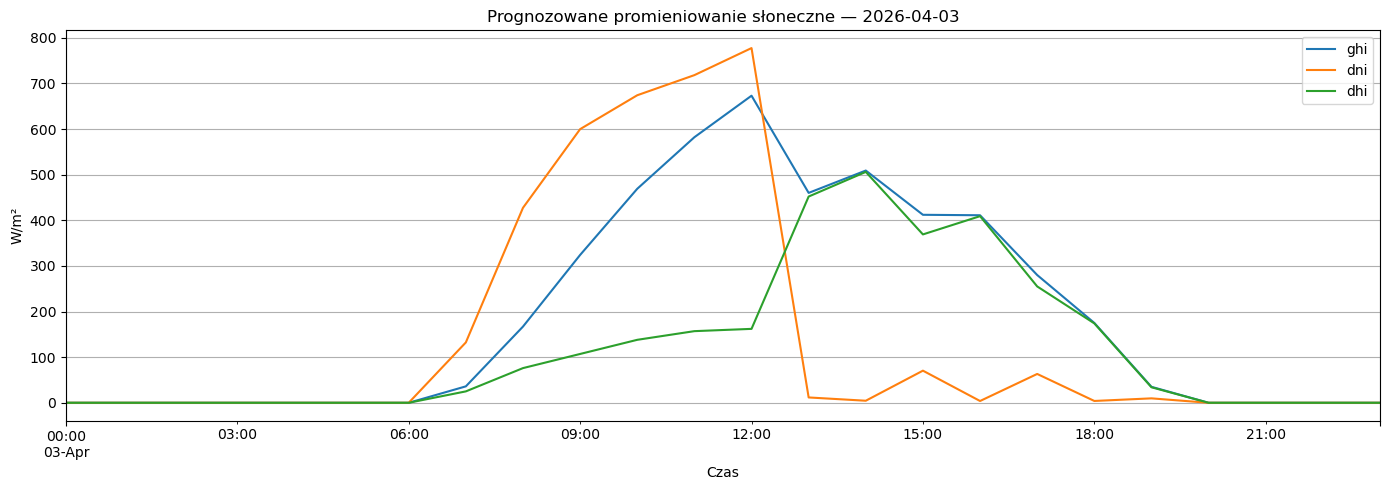

In [19]:
weather[["ghi", "dni", "dhi"]].plot(figsize=(14, 5))

plt.title(f"Prognozowane promieniowanie słoneczne — {FORECAST_DATE}")
plt.xlabel("Czas")
plt.ylabel("W/m²")
plt.grid(True)
show_intermediate_plot()


## RESAMPLING DO GRANULACJI 15-MINUTOWEJ


In [21]:
# 1. Upewniamy się, że indeks to DatetimeIndex
weather.index = pd.to_datetime(weather.index)

# 2. Wyciągamy ostatnią datę i tworzymy dla niej pełny zakres do 23:45
ostatnia_data = weather.index.max().normalize()  # Obcina godzinę do 00:00:00
pelny_koniec_dnia = ostatnia_data + pd.Timedelta(hours=23, minutes=45)

# 3. Rozszerzamy indeks tabeli o ten brakujący końcowy punkt
nowy_indeks = weather.index.union([pelny_koniec_dnia])
weather_extended = weather.reindex(nowy_indeks)

# 4. Teraz resample stworzy wszystkie kwadransy pomiędzy, a metoda "time" je uzupełni
weather_15min = weather_extended.resample("15min").interpolate(
    method="time", fill_value="extrapolate"
)

# Promieniowanie nie może być ujemne
for col in ["ghi", "dni", "dhi"]:
    weather_15min[col] = weather_15min[col].clip(lower=0)

print("Liczba rekordów godzinowych:", len(weather))
print("Liczba rekordów 15-min:", len(weather_15min))

weather_15min.head()


Liczba rekordów godzinowych: 24
Liczba rekordów 15-min: 96


C:\Users\milos\AppData\Local\Temp\ipykernel_21852\1795630109.py:13: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  weather_15min = weather_extended.resample("15min").interpolate(


,timestamp,temp_air,wind_speed,ghi,dni,dhi,wind_speed_100m_ms,wind_direction_100m_deg,pressure_hPa,temp_air_K,pressure_Pa
time,,,,,,,,,,,
2026-04-03 00:00:00,2026-04-03T00:00,5.8,2.800,0.0,0.0,0.0,8.900,18.00,992.800,278.95,99280.0
2026-04-03 00:15:00,NaN,5.7,2.675,0.0,0.0,0.0,8.675,21.75,992.725,278.85,99272.5
2026-04-03 00:30:00,NaN,5.6,2.550,0.0,0.0,0.0,8.450,25.50,992.650,278.75,99265.0
2026-04-03 00:45:00,NaN,5.5,2.425,0.0,0.0,0.0,8.225,29.25,992.575,278.65,99257.5
2026-04-03 01:00:00,2026-04-03T01:00,5.4,2.300,0.0,0.0,0.0,8.000,33.00,992.500,278.55,99250.0


## DANE WEJŚCIOWE DO MODELU PV


In [23]:
weather_pv = pd.DataFrame(index=weather_15min.index)

weather_pv["ghi"] = weather_15min["ghi"]
weather_pv["dni"] = weather_15min["dni"]
weather_pv["dhi"] = weather_15min["dhi"]
weather_pv["temp_air"] = weather_15min["temp_air"]
weather_pv["wind_speed"] = weather_15min["wind_speed"]

weather_pv.head()


,ghi,dni,dhi,temp_air,wind_speed
time,,,,,
2026-04-03 00:00:00,0.0,0.0,0.0,5.8,2.800
2026-04-03 00:15:00,0.0,0.0,0.0,5.7,2.675
2026-04-03 00:30:00,0.0,0.0,0.0,5.6,2.550
2026-04-03 00:45:00,0.0,0.0,0.0,5.5,2.425
2026-04-03 01:00:00,0.0,0.0,0.0,5.4,2.300


## MODEL PRODUKCJI PV


In [25]:
location = pvlib.location.Location(
    latitude=LATITUDE,
    longitude=LONGITUDE,
    tz=TIMEZONE,
    altitude=ALTITUDE,
    name="PV location"
)

temperature_model_parameters = pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS[
    "sapm"
]["open_rack_glass_glass"]

pv_system = pvlib.pvsystem.PVSystem(
    surface_tilt=PV_TILT,
    surface_azimuth=PV_AZIMUTH,
    module_parameters={
        "pdc0": PV_POWER_KWP,
        "gamma_pdc": -0.004
    },
    inverter_parameters={
        "pdc0": PV_POWER_KWP
    },
    temperature_model_parameters=temperature_model_parameters
)

pv_model = pvlib.modelchain.ModelChain.with_pvwatts(
    system=pv_system,
    location=location,
    aoi_model="physical",
    spectral_model="no_loss"
)

pv_model.run_model(weather_pv)

pv_power_ac_kW = pv_model.results.ac.clip(lower=0)
pv_energy_kWh_15min = pv_power_ac_kW * 0.25

print("Model PV wykonany poprawnie.")


Model PV wykonany poprawnie.


## WYNIKI PV


In [27]:
pv_result = pd.DataFrame(index=weather_15min.index)

pv_result["pv_power_ac_kW"] = pv_power_ac_kW
pv_result["pv_energy_kWh_15min"] = pv_energy_kWh_15min
pv_result["pv_profile_pu"] = pv_result["pv_power_ac_kW"] / PV_POWER_KWP

pv_result.head()


,pv_power_ac_kW,pv_energy_kWh_15min,pv_profile_pu
time,,,
2026-04-03 00:00:00,0.0,0.0,0.0
2026-04-03 00:15:00,0.0,0.0,0.0
2026-04-03 00:30:00,0.0,0.0,0.0
2026-04-03 00:45:00,0.0,0.0,0.0
2026-04-03 01:00:00,0.0,0.0,0.0


## DANE WEJŚCIOWE DO MODELU WIATROWEGO


In [29]:
weather_wpl = pd.DataFrame(index=weather_15min.index)

weather_wpl[("wind_speed", 10)] = weather_15min["wind_speed"]
weather_wpl[("wind_speed", 100)] = weather_15min["wind_speed_100m_ms"]

weather_wpl[("temperature", 2)] = weather_15min["temp_air_K"]
weather_wpl[("pressure", 0)] = weather_15min["pressure_Pa"]
weather_wpl[("roughness_length", 0)] = ROUGHNESS_LENGTH

weather_wpl.columns = pd.MultiIndex.from_tuples(weather_wpl.columns)

weather_wpl.head()


wind_speed        temperature pressure roughness_length
                           10     100         2        0                0  
time                                                                       
2026-04-03 00:00:00      2.800  8.900      278.95  99280.0              0.1
2026-04-03 00:15:00      2.675  8.675      278.85  99272.5              0.1
2026-04-03 00:30:00      2.550  8.450      278.75  99265.0              0.1
2026-04-03 00:45:00      2.425  8.225      278.65  99257.5              0.1
2026-04-03 01:00:00      2.300  8.000      278.55  99250.0              0.1

## KRZYWA MOCY TURBINY WIATROWEJ


In [31]:
power_curve = pd.DataFrame({
    "wind_speed": [
        0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
        14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25
    ],
    "value": [
        0, 0, 0, 0,
        100_000,
        300_000,
        650_000,
        1_100_000,
        1_700_000,
        2_400_000,
        3_100_000,
        3_700_000,
        4_000_000,
        4_000_000,
        4_000_000,
        4_000_000,
        4_000_000,
        4_000_000,
        4_000_000,
        4_000_000,
        4_000_000,
        4_000_000,
        4_000_000,
        4_000_000,
        4_000_000,
        0
    ]
})


## MODEL PRODUKCJI WIATROWEJ


In [33]:
wind_turbine = WindTurbine(
    nominal_power=TURBINE_POWER_MW * 1_000_000,
    hub_height=HUB_HEIGHT,
    power_curve=power_curve
)

wind_model = ModelChain(
    wind_turbine,
    wind_speed_model="logarithmic",
    density_model="ideal_gas",
    temperature_model="linear_gradient",
    power_output_model="power_curve",
    density_correction=True
)

wind_model.run_model(weather_wpl)

print("Model wiatrowy wykonany poprawnie.")


Model wiatrowy wykonany poprawnie.


## PRZELICZENIE NA FARMĘ WIATROWĄ


In [35]:
# windpowerlib zwraca moc jednej turbiny w W
turbine_power_W = wind_model.power_output

# W -> MW
turbine_power_MW = turbine_power_W / 1_000_000

# Moc brutto całej farmy
wind_farm_power_MW_gross = turbine_power_MW * N_TURBINES

# Moc netto po stratach
wind_farm_power_MW_net = wind_farm_power_MW_gross * LOSS_FACTOR

# Ograniczenie do mocy zainstalowanej farmy
wind_farm_power_MW_net = wind_farm_power_MW_net.clip(
    lower=0,
    upper=WIND_FARM_POWER_MW
)

# Energia w interwale 15-minutowym
wind_energy_MWh_15min = wind_farm_power_MW_net * 0.25

wind_farm_power_MW_net.head()


time
2026-04-03 00:00:00    17.951169
2026-04-03 00:15:00    16.793184
2026-04-03 00:30:00    15.634529
2026-04-03 00:45:00    14.475241
2026-04-03 01:00:00    13.315320
Freq: 15min, Name: feedin_power_plant, dtype: float64

## WYNIKI FW


In [37]:
wind_result = pd.DataFrame(index=weather_15min.index)

wind_result["wind_speed_10m_ms"] = weather_15min["wind_speed"]
wind_result["wind_speed_100m_ms"] = weather_15min["wind_speed_100m_ms"]
wind_result["wind_power_MW"] = wind_farm_power_MW_net
wind_result["wind_energy_MWh_15min"] = wind_energy_MWh_15min
wind_result["wind_profile_pu"] = wind_result["wind_power_MW"] / WIND_FARM_POWER_MW

wind_result.head()


,wind_speed_10m_ms,wind_speed_100m_ms,wind_power_MW,wind_energy_MWh_15min,wind_profile_pu
time,,,,,
2026-04-03 00:00:00,2.800,8.900,17.951169,4.487792,0.560974
2026-04-03 00:15:00,2.675,8.675,16.793184,4.198296,0.524787
2026-04-03 00:30:00,2.550,8.450,15.634529,3.908632,0.488579
2026-04-03 00:45:00,2.425,8.225,14.475241,3.618810,0.452351
2026-04-03 01:00:00,2.300,8.000,13.315320,3.328830,0.416104


## ZBIORCZY PLAN PRACY OZE DLA VPP


In [39]:
vpp_oze_plan = pd.DataFrame(index=weather_15min.index)

# PV
vpp_oze_plan["pv_power_MW"] = pv_result["pv_power_ac_kW"] / 1000
vpp_oze_plan["pv_energy_MWh_15min"] = pv_result["pv_energy_kWh_15min"] / 1000
vpp_oze_plan["pv_profile_pu"] = pv_result["pv_profile_pu"]

# Wiatr
vpp_oze_plan["wind_power_MW"] = wind_result["wind_power_MW"]
vpp_oze_plan["wind_energy_MWh_15min"] = wind_result["wind_energy_MWh_15min"]
vpp_oze_plan["wind_profile_pu"] = wind_result["wind_profile_pu"]

# Razem OZE
vpp_oze_plan["res_power_MW"] = (
    vpp_oze_plan["pv_power_MW"] +
    vpp_oze_plan["wind_power_MW"]
)

vpp_oze_plan["res_energy_MWh_15min"] = (
    vpp_oze_plan["pv_energy_MWh_15min"] +
    vpp_oze_plan["wind_energy_MWh_15min"]
)

vpp_oze_plan = vpp_oze_plan.reset_index().rename(columns={"time": "timestamp"})

vpp_oze_plan.head()


,timestamp,pv_power_MW,pv_energy_MWh_15min,pv_profile_pu,wind_power_MW,wind_energy_MWh_15min,wind_profile_pu,res_power_MW,res_energy_MWh_15min
0,2026-04-03 00:00:00,0.0,0.0,0.0,17.951169,4.487792,0.560974,17.951169,4.487792
1,2026-04-03 00:15:00,0.0,0.0,0.0,16.793184,4.198296,0.524787,16.793184,4.198296
2,2026-04-03 00:30:00,0.0,0.0,0.0,15.634529,3.908632,0.488579,15.634529,3.908632
3,2026-04-03 00:45:00,0.0,0.0,0.0,14.475241,3.618810,0.452351,14.475241,3.618810
4,2026-04-03 01:00:00,0.0,0.0,0.0,13.315320,3.328830,0.416104,13.315320,3.328830


## STATYSTYKI DOBOWE OZE


In [41]:
pv_daily_MWh = vpp_oze_plan["pv_energy_MWh_15min"].sum()
wind_daily_MWh = vpp_oze_plan["wind_energy_MWh_15min"].sum()
res_daily_MWh = vpp_oze_plan["res_energy_MWh_15min"].sum()

print("Prognozowana produkcja PV [MWh/d]:", round(pv_daily_MWh, 2))
print("Prognozowana produkcja FW [MWh/d]:", round(wind_daily_MWh, 2))
print("Prognozowana produkcja OZE razem [MWh/d]:", round(res_daily_MWh, 2))
print()
print("Maksymalna moc PV [MW]:", round(vpp_oze_plan["pv_power_MW"].max(), 2))
print("Maksymalna moc FW [MW]:", round(vpp_oze_plan["wind_power_MW"].max(), 2))
print("Maksymalna moc OZE razem [MW]:", round(vpp_oze_plan["res_power_MW"].max(), 2))


Prognozowana produkcja PV [MWh/d]: 138.86
Prognozowana produkcja FW [MWh/d]: 88.18
Prognozowana produkcja OZE razem [MWh/d]: 227.05

Maksymalna moc PV [MW]: 21.44
Maksymalna moc FW [MW]: 17.95
Maksymalna moc OZE razem [MW]: 21.59


## WYKRES PLANU PRACY OZE


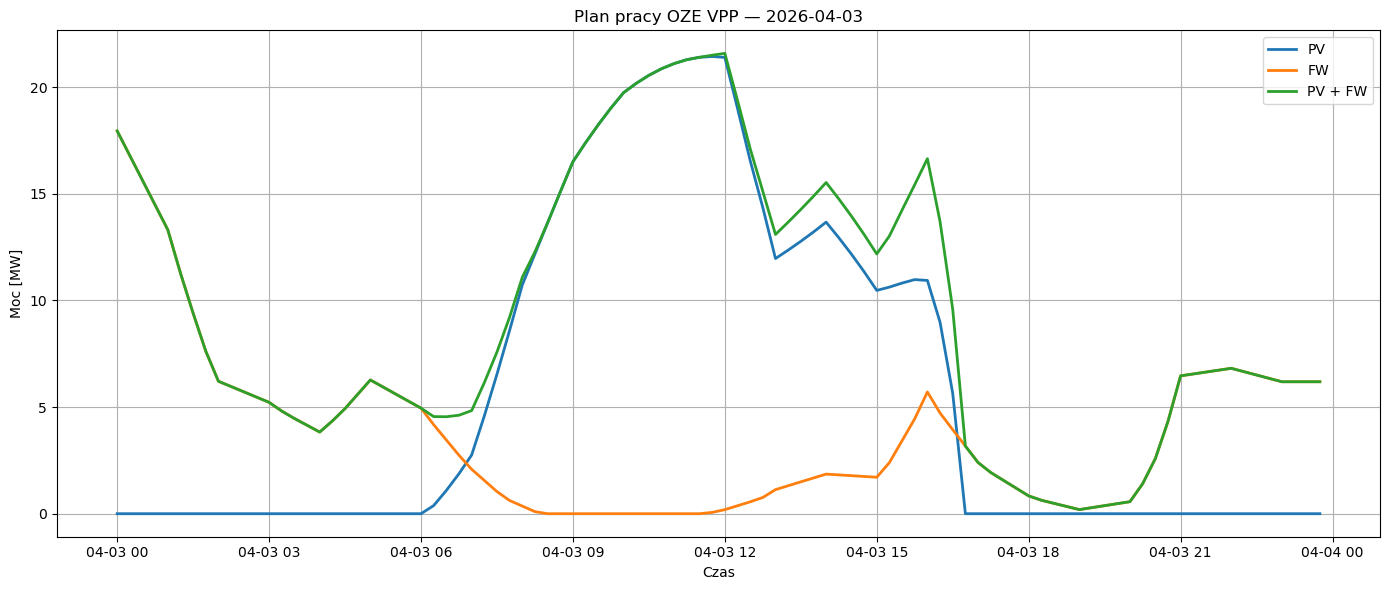

In [43]:
plt.figure(figsize=(14, 6))

plt.plot(
    vpp_oze_plan["timestamp"],
    vpp_oze_plan["pv_power_MW"],
    label="PV",
    linewidth=2
)

plt.plot(
    vpp_oze_plan["timestamp"],
    vpp_oze_plan["wind_power_MW"],
    label="FW",
    linewidth=2
)

plt.plot(
    vpp_oze_plan["timestamp"],
    vpp_oze_plan["res_power_MW"],
    label="PV + FW",
    linewidth=2
)

plt.title(f"Plan pracy OZE VPP — {FORECAST_DATE}")
plt.xlabel("Czas")
plt.ylabel("Moc [MW]")
plt.legend()
plt.grid(True)
show_intermediate_plot()


## USTAWIENIA — PROGNOZA CIEPŁA DAY-AHEAD


In [45]:
# Model zapisany w notebooku "Prognoza_zap_na_cieplo_uporzadkowane_v2.ipynb"
HEAT_MODEL_PATH = "heat_demand_forecast.pkl"

# Gotowy, wspólny plik z profilem Helsinek:
# - przeskalowany do mocy źródła,
# - przeliczony do 15-minutówek,
# - używany zarówno w treningu modelu, jak i tutaj.
SCALED_HELSINKI_15MIN_PATH = "helsinki_heat_scaled_15min.csv"

HELSINKI_LAT = 60.1699
HELSINKI_LON = 24.9384

HEAT_ANALOG_YEAR = 2024

# Przykład:
# FORECAST_DATE = 2026-04-03
# Dla ciepła bierzemy analogiczny dzień pogodowy z 2024: 2024-04-03.
HEAT_FORECAST_DATE = pd.Timestamp(
    f"{HEAT_ANALOG_YEAR}-{FORECAST_DATE.month:02d}-{FORECAST_DATE.day:02d}"
).date()

forecast_start = pd.Timestamp(f"{HEAT_FORECAST_DATE} 00:00:00")
forecast_end = pd.Timestamp(f"{HEAT_FORECAST_DATE} 23:45:00")

# Historia potrzebna do:
# - heat_lag_168h,
# - heat_roll_mean_168h_at_issue,
# - temperatury i rollingów.
# 10 dni daje bezpieczny zapas względem najdłuższego okna 168h.
history_start = forecast_start - pd.Timedelta(days=10)

print("Data VPP:", FORECAST_DATE)
print("Analogiczna data ciepła:", HEAT_FORECAST_DATE)
print("Zakres historii dla ciepła:", history_start, "->", forecast_end)


Data VPP: 2026-04-03
Analogiczna data ciepła: 2024-04-03
Zakres historii dla ciepła: 2024-03-24 00:00:00 -> 2024-04-03 23:45:00


## FUNKCJA POBIERANIA POGODY HISTORYCZNEJ OPEN-METEO


In [47]:
def download_open_meteo_weather(lat, lon, start_date, end_date):
    """
    Pobiera historyczne dane pogodowe Open-Meteo do modelu ciepła.

    Uwaga:
    Dla resamplingu z godzin do 15 minut warto pobrać pogodę do dnia następnego,
    żeby dało się interpolować wartości 23:15, 23:30 i 23:45.
    """
    hourly_vars = [
        "temperature_2m",
        "relative_humidity_2m",
        "wind_speed_10m",
        "cloud_cover",
        "shortwave_radiation",
        "precipitation",
    ]
    weather = download_open_meteo_hourly(
        lat=lat,
        lon=lon,
        start_date=start_date,
        end_date=end_date,
        hourly_vars=hourly_vars,
        timezone="UTC",
        time_col="datetime",
    )
    return weather

## FUNKCJA BUDOWY CECH DAY-AHEAD DLA CIEPŁA


In [49]:
def prepare_heat_day_ahead_features(df_heat_15min, issue_hour=8, base_temp=17):
    """
    Buduje cechy dla modelu day-ahead.

    Założenie:
    - prognoza jest wykonywana D-1 o godzinie issue_hour,
    - prognozujemy cały dzień D,
    - nie używamy krótkich lagów ciepła, które nie byłyby znane dla całego dnia D,
    - używamy tylko informacji dostępnych w momencie prognozy lub znanych z góry.
    """

    df = df_heat_15min.copy()
    df = df.sort_values("datetime").reset_index(drop=True)

    required_cols = [
        "datetime",
        "heat_MW",
        "temperature_2m",
        "relative_humidity_2m",
        "wind_speed_10m",
        "cloud_cover",
        "shortwave_radiation",
        "precipitation",
    ]

    missing_required = [col for col in required_cols if col not in df.columns]
    if missing_required:
        raise ValueError(f"Brakuje kolumn wejściowych do budowy cech: {missing_required}")

    # Cechy kalendarzowe
    df["year"] = df["datetime"].dt.year
    df["month"] = df["datetime"].dt.month
    df["day"] = df["datetime"].dt.day
    df["hour"] = df["datetime"].dt.hour
    df["minute"] = df["datetime"].dt.minute
    df["dayofweek"] = df["datetime"].dt.dayofweek
    df["dayofyear"] = df["datetime"].dt.dayofyear
    df["weekofyear"] = df["datetime"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

    df["hour_fraction"] = df["hour"] + df["minute"] / 60

    df["hour_sin"] = np.sin(2 * np.pi * df["hour_fraction"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour_fraction"] / 24)

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["dayofyear_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365)
    df["dayofyear_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365)

    # Stopniodni
    df["heating_degree"] = np.maximum(0, base_temp - df["temperature_2m"])
    df["cooling_degree"] = np.maximum(0, df["temperature_2m"] - base_temp)

    # Moment wydania prognozy dla każdego punktu dnia D
    df["issue_time"] = (
        df["datetime"].dt.normalize()
        - pd.Timedelta(days=1)
        + pd.Timedelta(hours=issue_hour)
    )

    heat_series = df.set_index("datetime")["heat_MW"]

    # Rollingi historyczne ciepła; używane w wartości z chwili wydania prognozy.
    heat_roll_24h_series = heat_series.rolling(96, min_periods=96).mean()
    heat_roll_48h_series = heat_series.rolling(192, min_periods=192).mean()
    heat_roll_168h_series = heat_series.rolling(672, min_periods=672).mean()

    df["heat_at_issue"] = (
        heat_series
        .reindex(df["issue_time"])
        .to_numpy()
    )

    df["heat_roll_mean_24h_at_issue"] = (
        heat_roll_24h_series
        .reindex(df["issue_time"])
        .to_numpy()
    )

    df["heat_roll_mean_48h_at_issue"] = (
        heat_roll_48h_series
        .reindex(df["issue_time"])
        .to_numpy()
    )

    df["heat_roll_mean_168h_at_issue"] = (
        heat_roll_168h_series
        .reindex(df["issue_time"])
        .to_numpy()
    )

    # Bezpieczne lagi ciepła dla prognozy D-1 08:00 na cały dzień D
    df["heat_lag_48h"] = (
        df["datetime"] - pd.Timedelta(hours=48)
    ).map(heat_series)

    df["heat_lag_168h"] = (
        df["datetime"] - pd.Timedelta(hours=168)
    ).map(heat_series)

    # Cechy temperatury — pogoda dla dnia D jest traktowana jako znana prognoza/scenariusz.
    temp_series = df.set_index("datetime")["temperature_2m"]

    df["temp_lag_1h"] = (
        df["datetime"] - pd.Timedelta(hours=1)
    ).map(temp_series)

    df["temp_lag_3h"] = (
        df["datetime"] - pd.Timedelta(hours=3)
    ).map(temp_series)

    df["temp_lag_6h"] = (
        df["datetime"] - pd.Timedelta(hours=6)
    ).map(temp_series)

    df["temp_lag_12h"] = (
        df["datetime"] - pd.Timedelta(hours=12)
    ).map(temp_series)

    df["temp_lag_24h"] = (
        df["datetime"] - pd.Timedelta(hours=24)
    ).map(temp_series)

    df["temp_lag_48h"] = (
        df["datetime"] - pd.Timedelta(hours=48)
    ).map(temp_series)

    temp_roll_3h_series = temp_series.rolling(12, min_periods=12).mean()
    temp_roll_6h_series = temp_series.rolling(24, min_periods=24).mean()
    temp_roll_12h_series = temp_series.rolling(48, min_periods=48).mean()
    temp_roll_24h_series = temp_series.rolling(96, min_periods=96).mean()

    df["temp_roll_mean_3h"] = (
        temp_roll_3h_series
        .reindex(df["datetime"])
        .to_numpy()
    )

    df["temp_roll_mean_6h"] = (
        temp_roll_6h_series
        .reindex(df["datetime"])
        .to_numpy()
    )

    df["temp_roll_mean_12h"] = (
        temp_roll_12h_series
        .reindex(df["datetime"])
        .to_numpy()
    )

    df["temp_roll_mean_24h"] = (
        temp_roll_24h_series
        .reindex(df["datetime"])
        .to_numpy()
    )

    return df


## PROGNOZA CIEPŁA DAY-AHEAD — NA GOTOWYM PLIKU 15-MIN


In [51]:
# 1. Wczytanie modelu
heat_bundle = joblib.load(HEAT_MODEL_PATH)

heat_model = heat_bundle["model"]
heat_features = heat_bundle["features"]
ISSUE_HOUR = heat_bundle.get("issue_hour", 8)
BASE_TEMP = heat_bundle.get("base_temp", 17)

# Jeżeli w modelu zapisano nazwę pliku wejściowego, używamy jej jako domyślnej,
# ale tylko jeśli taki plik istnieje w bieżącym katalogu.
bundle_scaled_file = heat_bundle.get("scaled_heat_file")
if bundle_scaled_file and os.path.exists(bundle_scaled_file):
    SCALED_HELSINKI_15MIN_PATH = bundle_scaled_file

print("Model ciepła załadowany.")
print("Opis:", heat_bundle.get("description"))
print("Target:", heat_bundle.get("target"))
print("Jednostka targetu:", heat_bundle.get("unit_target"))
print("Godzina wydania prognozy:", ISSUE_HOUR)
print("BASE_TEMP:", BASE_TEMP)
print("Plik ciepła 15-min:", SCALED_HELSINKI_15MIN_PATH)


# 2. Wczytanie gotowego pliku 15-min — bez ponownego skalowania
df_heat_15min = pd.read_csv(SCALED_HELSINKI_15MIN_PATH)

df_heat_15min["datetime"] = pd.to_datetime(df_heat_15min["datetime"])

required_heat_cols = ["datetime", "heat_MW", "heat_MWh_15min"]
missing_heat_cols = [col for col in required_heat_cols if col not in df_heat_15min.columns]

if missing_heat_cols:
    raise ValueError(
        f"Plik {SCALED_HELSINKI_15MIN_PATH} nie ma wymaganych kolumn: {missing_heat_cols}"
    )

df_heat_15min = df_heat_15min[required_heat_cols].copy()
df_heat_15min = df_heat_15min.sort_values("datetime").reset_index(drop=True)


# 3. Wybranie potrzebnego zakresu historii
df_heat_15min = df_heat_15min[
    (df_heat_15min["datetime"] >= history_start) &
    (df_heat_15min["datetime"] <= forecast_end)
].copy()

if df_heat_15min.empty:
    raise ValueError("Po filtrowaniu zakresu historii df_heat_15min jest pusty.")

print("Zakres danych ciepła po filtrowaniu:")
print(df_heat_15min["datetime"].min(), "->", df_heat_15min["datetime"].max())
print("Liczba wierszy:", len(df_heat_15min))


# 4. Pobranie pogody dla tego samego zakresu.
# Pobieramy do dnia następnego, żeby po resamplingu mieć 23:15, 23:30 i 23:45.
weather_end_date = HEAT_FORECAST_DATE + pd.Timedelta(days=1)

weather_heat_hourly = download_open_meteo_weather(
    lat=HELSINKI_LAT,
    lon=HELSINKI_LON,
    start_date=history_start.date(),
    end_date=weather_end_date
)

weather_heat_15min = (
    weather_heat_hourly
    .set_index("datetime")
    .resample("15min")
    .interpolate(method="time")
    .reset_index()
)

# Ograniczamy pogodę do dokładnie tego zakresu, którego potrzebujemy.
weather_heat_15min = weather_heat_15min[
    (weather_heat_15min["datetime"] >= history_start) &
    (weather_heat_15min["datetime"] <= forecast_end)
].copy()


# 5. Połączenie gotowego ciepła z pogodą
df_heat_15min = df_heat_15min.merge(
    weather_heat_15min,
    on="datetime",
    how="left"
)

weather_cols = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "cloud_cover",
    "shortwave_radiation",
    "precipitation",
]

if df_heat_15min[weather_cols].isna().any().any():
    print(df_heat_15min[weather_cols].isna().sum())
    missing_rows = df_heat_15min[df_heat_15min[weather_cols].isna().any(axis=1)]
    maybe_display(missing_rows.head(10))
    raise ValueError("Są braki w danych pogodowych po merge.")


# 6. Budowa cech day-ahead
df_heat_features = prepare_heat_day_ahead_features(
    df_heat_15min=df_heat_15min,
    issue_hour=ISSUE_HOUR,
    base_temp=BASE_TEMP
)


# 7. Wybranie dnia prognozy
df_heat_forecast_day = df_heat_features[
    (df_heat_features["datetime"] >= forecast_start) &
    (df_heat_features["datetime"] <= forecast_end)
].copy()

if len(df_heat_forecast_day) != 96:
    raise ValueError(
        f"Dzień prognozy powinien mieć 96 interwałów 15-min, a ma: {len(df_heat_forecast_day)}"
    )

missing_features = [
    col for col in heat_features
    if col not in df_heat_forecast_day.columns
]

if missing_features:
    raise ValueError(f"Brakuje cech do modelu ciepła: {missing_features}")

X_heat = df_heat_forecast_day[heat_features].copy()

if X_heat.isna().any().any():
    missing_cols = X_heat.columns[X_heat.isna().any()].tolist()
    print("Kolumny z brakami:", missing_cols)
    maybe_display(df_heat_forecast_day[["datetime"] + missing_cols].head(20))
    raise ValueError(f"Braki NaN w cechach modelu ciepła: {missing_cols}")


# 8. Predykcja modelu
df_heat_forecast_day["heat_demand_MW"] = heat_model.predict(X_heat)
df_heat_forecast_day["heat_demand_MW"] = df_heat_forecast_day["heat_demand_MW"].clip(lower=0)

df_heat_forecast_day["heat_demand_MWh_15min"] = (
    df_heat_forecast_day["heat_demand_MW"] * 0.25
)


# 9. Przemapowanie timestampu z 2024 na dzień VPP, np. 2026
heat_plan_15min = df_heat_forecast_day[
    [
        "datetime",
        "heat_MW",
        "heat_MWh_15min",
        "heat_demand_MW",
        "heat_demand_MWh_15min",
    ]
].copy()

heat_plan_15min = heat_plan_15min.rename(
    columns={
        "datetime": "timestamp_2024",
        "heat_MW": "actual_heat_MW_2024",
        "heat_MWh_15min": "actual_heat_MWh_15min_2024",
    }
)

heat_plan_15min["timestamp"] = pd.date_range(
    start=pd.Timestamp(f"{FORECAST_DATE} 00:00:00"),
    periods=len(heat_plan_15min),
    freq="15min",
)

heat_plan_15min = heat_plan_15min[
    [
        "timestamp",
        "timestamp_2024",
        "actual_heat_MW_2024",
        "actual_heat_MWh_15min_2024",
        "heat_demand_MW",
        "heat_demand_MWh_15min",
    ]
].copy()

print("Prognoza ciepła gotowa.")
print("Liczba interwałów:", len(heat_plan_15min))
print("Rzeczywiste ciepło 2024 [MWh]:", round(heat_plan_15min["actual_heat_MWh_15min_2024"].sum(), 2))
print("Prognozowane ciepło [MWh]:", round(heat_plan_15min["heat_demand_MWh_15min"].sum(), 2))
print("Maks. rzeczywista moc 2024 [MW]:", round(heat_plan_15min["actual_heat_MW_2024"].max(), 2))
print("Maks. prognozowana moc [MW]:", round(heat_plan_15min["heat_demand_MW"].max(), 2))

heat_plan_15min.head()


Model ciepła załadowany.
Opis: Model day-ahead zapotrzebowania na ciepło. Prognoza D-1 08:00 na cały dzień D. Dane wejściowe: Helsinki przeskalowane raz do 15 minut.
Target: heat_MW
Jednostka targetu: MW
Godzina wydania prognozy: 8
BASE_TEMP: 17
Plik ciepła 15-min: helsinki_heat_scaled_15min.csv
Zakres danych ciepła po filtrowaniu:
2024-03-24 00:00:00 -> 2024-04-03 23:45:00
Liczba wierszy: 1056
Prognoza ciepła gotowa.
Liczba interwałów: 96
Rzeczywiste ciepło 2024 [MWh]: 551.56
Prognozowane ciepło [MWh]: 556.83
Maks. rzeczywista moc 2024 [MW]: 25.71
Maks. prognozowana moc [MW]: 26.09


,timestamp,timestamp_2024,actual_heat_MW_2024,actual_heat_MWh_15min_2024,heat_demand_MW,heat_demand_MWh_15min
960,2026-04-03 00:00:00,2024-04-03 00:00:00,19.539306,4.884827,20.273481,5.068370
961,2026-04-03 00:15:00,2024-04-03 00:15:00,19.593813,4.898453,20.420668,5.105167
962,2026-04-03 00:30:00,2024-04-03 00:30:00,19.648319,4.912080,20.523067,5.130767
963,2026-04-03 00:45:00,2024-04-03 00:45:00,19.702826,4.925707,20.686810,5.171702
964,2026-04-03 01:00:00,2024-04-03 01:00:00,19.757333,4.939333,20.449202,5.112300


## WYKRES: RZECZYWISTE 2024 VS PROGNOZA MODELU


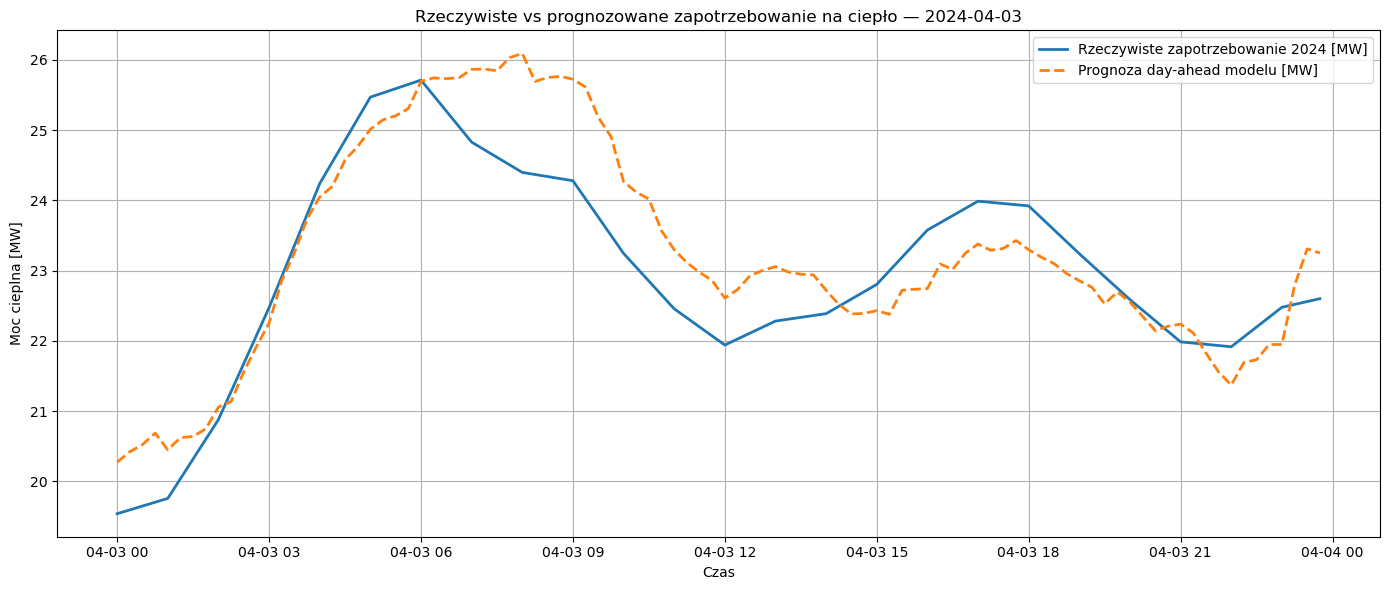

In [53]:
plt.figure(figsize=(14, 6))

plt.plot(
    heat_plan_15min["timestamp_2024"],
    heat_plan_15min["actual_heat_MW_2024"],
    label="Rzeczywiste zapotrzebowanie 2024 [MW]",
    linewidth=2,
)

plt.plot(
    heat_plan_15min["timestamp_2024"],
    heat_plan_15min["heat_demand_MW"],
    label="Prognoza day-ahead modelu [MW]",
    linewidth=2,
    linestyle="--",
)

plt.title(
    f"Rzeczywiste vs prognozowane zapotrzebowanie na ciepło — {HEAT_FORECAST_DATE}"
)
plt.xlabel("Czas")
plt.ylabel("Moc cieplna [MW]")
plt.legend()
plt.grid(True)
show_intermediate_plot()


## METRYKI DLA DNIA ANALOGOWEGO


In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def calculate_heat_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    non_zero = y_true != 0
    if non_zero.sum() == 0:
        mape = np.nan
    else:
        mape = np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100

    return mae, rmse, mape, r2

mae, rmse, mape, r2 = calculate_heat_metrics(
    heat_plan_15min["actual_heat_MW_2024"],
    heat_plan_15min["heat_demand_MW"]
)

summary_heat_quality = pd.DataFrame([
    {
        "data_analogowa": HEAT_FORECAST_DATE,
        "MAE_MW": mae,
        "RMSE_MW": rmse,
        "MAPE_%": mape,
        "R2": r2,
        "actual_heat_MWh": heat_plan_15min["actual_heat_MWh_15min_2024"].sum(),
        "forecast_heat_MWh": heat_plan_15min["heat_demand_MWh_15min"].sum(),
        "error_total_MWh": (
            heat_plan_15min["heat_demand_MWh_15min"].sum()
            - heat_plan_15min["actual_heat_MWh_15min_2024"].sum()
        ),
    }
])

summary_heat_quality


,data_analogowa,MAE_MW,RMSE_MW,MAPE_%,R2,actual_heat_MWh,forecast_heat_MWh,error_total_MWh
0,2024-04-03,0.591905,0.716624,2.568543,0.752568,551.55852,556.825439,5.26692


## POŁĄCZENIE PLANU OZE I PROGNOZY CIEPŁA


In [57]:
vpp_plan = vpp_oze_plan.merge(
    heat_plan_15min[
        [
            "timestamp",
            "timestamp_2024",
            "actual_heat_MW_2024",
            "actual_heat_MWh_15min_2024",
            "heat_demand_MW",
            "heat_demand_MWh_15min",
        ]
    ],
    on="timestamp",
    how="left",
)

if vpp_plan["heat_demand_MWh_15min"].isna().any():
    raise ValueError("Po połączeniu OZE i ciepła pojawiły się braki danych.")

print("Połączony plan VPP gotowy.")
print("Liczba wierszy:", len(vpp_plan))

vpp_plan.head()


Połączony plan VPP gotowy.
Liczba wierszy: 96


,timestamp,pv_power_MW,pv_energy_MWh_15min,pv_profile_pu,wind_power_MW,wind_energy_MWh_15min,wind_profile_pu,res_power_MW,res_energy_MWh_15min,timestamp_2024,actual_heat_MW_2024,actual_heat_MWh_15min_2024,heat_demand_MW,heat_demand_MWh_15min
0,2026-04-03 00:00:00,0.0,0.0,0.0,17.951169,4.487792,0.560974,17.951169,4.487792,2024-04-03 00:00:00,19.539306,4.884827,20.273481,5.068370
1,2026-04-03 00:15:00,0.0,0.0,0.0,16.793184,4.198296,0.524787,16.793184,4.198296,2024-04-03 00:15:00,19.593813,4.898453,20.420668,5.105167
2,2026-04-03 00:30:00,0.0,0.0,0.0,15.634529,3.908632,0.488579,15.634529,3.908632,2024-04-03 00:30:00,19.648319,4.912080,20.523067,5.130767
3,2026-04-03 00:45:00,0.0,0.0,0.0,14.475241,3.618810,0.452351,14.475241,3.618810,2024-04-03 00:45:00,19.702826,4.925707,20.686810,5.171702
4,2026-04-03 01:00:00,0.0,0.0,0.0,13.315320,3.328830,0.416104,13.315320,3.328830,2024-04-03 01:00:00,19.757333,4.939333,20.449202,5.112300


## WYKRES: OZE VS ZAPOTRZEBOWANIE NA CIEPŁO


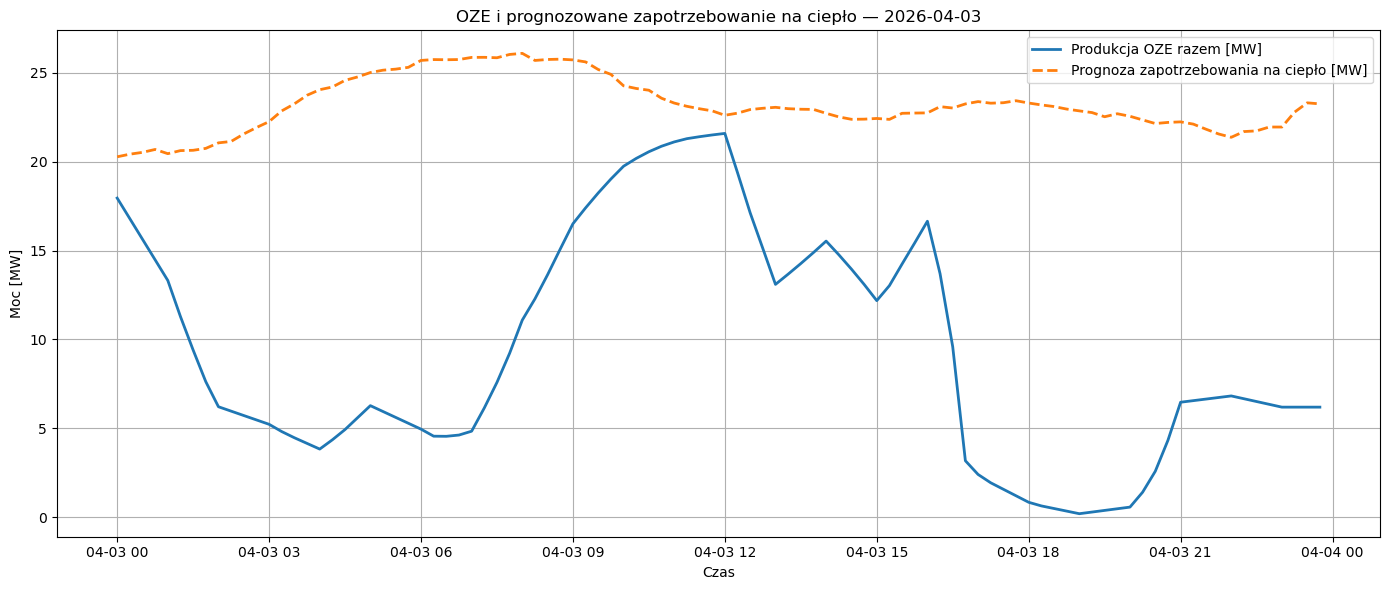

In [59]:
plt.figure(figsize=(14, 6))

plt.plot(
    vpp_plan["timestamp"],
    vpp_plan["res_power_MW"],
    label="Produkcja OZE razem [MW]",
    linewidth=2,
)

plt.plot(
    vpp_plan["timestamp"],
    vpp_plan["heat_demand_MW"],
    label="Prognoza zapotrzebowania na ciepło [MW]",
    linewidth=2,
    linestyle="--",
)

plt.title(f"OZE i prognozowane zapotrzebowanie na ciepło — {FORECAST_DATE}")
plt.xlabel("Czas")
plt.ylabel("Moc [MW]")
plt.legend()
plt.grid(True)
show_intermediate_plot()


## OCZYSZCZENIE KOLUMN TECHNICZNYCH PO MERGE CIEPŁA


In [61]:
vpp_plan = vpp_plan.drop(columns=["timestamp_2024"], errors="ignore")
vpp_plan.head()


,timestamp,pv_power_MW,pv_energy_MWh_15min,pv_profile_pu,wind_power_MW,wind_energy_MWh_15min,wind_profile_pu,res_power_MW,res_energy_MWh_15min,actual_heat_MW_2024,actual_heat_MWh_15min_2024,heat_demand_MW,heat_demand_MWh_15min
0,2026-04-03 00:00:00,0.0,0.0,0.0,17.951169,4.487792,0.560974,17.951169,4.487792,19.539306,4.884827,20.273481,5.068370
1,2026-04-03 00:15:00,0.0,0.0,0.0,16.793184,4.198296,0.524787,16.793184,4.198296,19.593813,4.898453,20.420668,5.105167
2,2026-04-03 00:30:00,0.0,0.0,0.0,15.634529,3.908632,0.488579,15.634529,3.908632,19.648319,4.912080,20.523067,5.130767
3,2026-04-03 00:45:00,0.0,0.0,0.0,14.475241,3.618810,0.452351,14.475241,3.618810,19.702826,4.925707,20.686810,5.171702
4,2026-04-03 01:00:00,0.0,0.0,0.0,13.315320,3.328830,0.416104,13.315320,3.328830,19.757333,4.939333,20.449202,5.112300


## DOŁĄCZENIE PLANU ZUŻYCIA ODBIORCY PRZEMYSŁOWEGO


In [63]:
zapotrzebowanie_e_e = pd.read_csv("industrial_load_schedule_2026_15min.xls")
zapotrzebowanie_e_e["timestamp"] = pd.to_datetime(zapotrzebowanie_e_e["timestamp"])
zapotrzebowanie_e_e.head()


,timestamp,industrial_load_kW,industrial_load_MW,industrial_load_MW_scaled,industrial_load_MWh_15min_scaled
0,2026-01-01 00:00:00,136.814310,0.136814,3.871761,0.967940
1,2026-01-01 00:15:00,119.761499,0.119761,3.389177,0.847294
2,2026-01-01 00:30:00,123.168654,0.123169,3.485597,0.871399
3,2026-01-01 00:45:00,131.686542,0.131687,3.726648,0.931662
4,2026-01-01 01:00:00,114.650767,0.114651,3.244546,0.811137


## MERGE VPP + PLAN ODBIORCY PRZEMYSŁOWEGO


In [65]:
vpp_plan["timestamp"] = pd.to_datetime(vpp_plan["timestamp"])
zapotrzebowanie_e_e["timestamp"] = pd.to_datetime(zapotrzebowanie_e_e["timestamp"])

vpp_plan = vpp_plan.merge(
    zapotrzebowanie_e_e,
    on="timestamp",
    how="left",
)

vpp_plan.head()


,timestamp,pv_power_MW,pv_energy_MWh_15min,pv_profile_pu,wind_power_MW,wind_energy_MWh_15min,wind_profile_pu,res_power_MW,res_energy_MWh_15min,actual_heat_MW_2024,actual_heat_MWh_15min_2024,heat_demand_MW,heat_demand_MWh_15min,industrial_load_kW,industrial_load_MW,industrial_load_MW_scaled,industrial_load_MWh_15min_scaled
0,2026-04-03 00:00:00,0.0,0.0,0.0,17.951169,4.487792,0.560974,17.951169,4.487792,19.539306,4.884827,20.273481,5.068370,186.252129,0.186252,5.270821,1.317705
1,2026-04-03 00:15:00,0.0,0.0,0.0,16.793184,4.198296,0.524787,16.793184,4.198296,19.593813,4.898453,20.420668,5.105167,150.442930,0.150443,4.257442,1.064361
2,2026-04-03 00:30:00,0.0,0.0,0.0,15.634529,3.908632,0.488579,15.634529,3.908632,19.648319,4.912080,20.523067,5.130767,145.332198,0.145332,4.112812,1.028203
3,2026-04-03 00:45:00,0.0,0.0,0.0,14.475241,3.618810,0.452351,14.475241,3.618810,19.702826,4.925707,20.686810,5.171702,170.902896,0.170903,4.836447,1.209112
4,2026-04-03 01:00:00,0.0,0.0,0.0,13.315320,3.328830,0.416104,13.315320,3.328830,19.757333,4.939333,20.449202,5.112300,153.850085,0.153850,4.353863,1.088466


## USTAWIENIA — PROGNOZA CEN SPOT D+1


In [67]:
SPOT_MODEL_PATH = "spot_price_forecast_model.pkl"
SPOT_HISTORY_PATH = "SPOT_2026.xlsx"

# Prognoza SPOT jest wykonywana razem z sercem modelu, np. D-1 o 08:00.
SPOT_FORECAST_RUN_TIME = RUN_DATETIME

# Prognozujemy ten sam dzień co OZE i VPP.
SPOT_FORECAST_DATE = pd.Timestamp(FORECAST_DATE).date()

# Lokalizacja pogodowa do cech modelu SPOT.
# Jeżeli model był trenowany na pogodzie dla Warszawy/Polski centralnej, zostawiamy Warszawę.
SPOT_LAT = 52.2297
SPOT_LON = 21.0122

spot_forecast_start = pd.Timestamp(f"{SPOT_FORECAST_DATE} 00:00:00")
spot_forecast_end = pd.Timestamp(f"{SPOT_FORECAST_DATE} 23:00:00")

# Do lagów i rollingów w modelu SPOT potrzebujemy historii.
spot_history_start = spot_forecast_start - pd.Timedelta(hours=240)

# W momencie D-1 08:00 znamy ceny do końca D-1.
spot_last_known_price_time = pd.Timestamp(
    f"{(pd.Timestamp(SPOT_FORECAST_DATE) - pd.Timedelta(days=1)).date()} 23:00:00"
)

print("Data prognozy SPOT:", SPOT_FORECAST_DATE)
print("Moment wykonania prognozy:", SPOT_FORECAST_RUN_TIME)
print("Zakres historii SPOT:", spot_history_start, "->", spot_forecast_end)
print("Ostatnia znana cena SPOT:", spot_last_known_price_time)


Data prognozy SPOT: 2026-04-03
Moment wykonania prognozy: 2026-04-02 08:00:00
Zakres historii SPOT: 2026-03-24 00:00:00 -> 2026-04-03 23:00:00
Ostatnia znana cena SPOT: 2026-04-02 23:00:00


## FUNKCJE POMOCNICZE — PROGNOZA SPOT D+1


In [69]:
from urllib.parse import quote
import pandas as pd
import requests

def download_pse_pk5l_wp(start_date, end_date):
    base_url = "https://api.raporty.pse.pl/api/pk5l-wp"

    dates = pd.date_range(start_date, end_date, freq="D")
    all_rows = []

    for d in dates:
        date_str = d.strftime("%Y-%m-%d")

        filter_text = f"business_date eq '{date_str}'"
        url = base_url + "?$filter=" + quote(filter_text, safe=" '$")

        response = requests.get(url, timeout=30)

        print(date_str, "PSE status:", response.status_code)

        if response.status_code != 200:
            print(response.text[:500])
            continue

        data = response.json()

        if isinstance(data, dict) and "value" in data:
            rows = data["value"]
        elif isinstance(data, list):
            rows = data
        else:
            rows = []

        all_rows.extend(rows)

    df = pd.DataFrame(all_rows)

    if df.empty:
        raise ValueError("Nie udało się pobrać danych PSE dla żadnego dnia.")

    print("Pobrano wierszy PSE:", len(df))
    print("Zakres business_date:", df["business_date"].min(), "->", df["business_date"].max())

    return df


def download_open_meteo_weather_spot(lat, lon, start_date, end_date):
    """Pobiera pogodę godzinową Open-Meteo do modelu SPOT."""
    hourly_vars = [
        "temperature_2m",
        "relative_humidity_2m",
        "wind_speed_10m",
        "cloud_cover",
    ]
    return download_open_meteo_hourly(
        lat=lat,
        lon=lon,
        start_date=start_date,
        end_date=end_date,
        hourly_vars=hourly_vars,
        timezone=TIMEZONE,
        time_col="timestamp",
    )

def prepare_pse_forecast_for_spot(load_raw):
    """
    Standaryzuje dane PSE do kolumn:
    timestamp, load, pv_gen, fw_gen.
    """

    pse_forecast = load_raw.copy()

    required_raw_cols = [
        "plan_dtime",
        "grid_demand_fcst",
        "fcst_pv_tot_gen",
        "fcst_wi_tot_gen",
    ]

    missing_raw_cols = [
        col for col in required_raw_cols
        if col not in pse_forecast.columns
    ]

    if missing_raw_cols:
        print("Kolumny zwrócone przez PSE:")
        print(pse_forecast.columns.tolist())
        raise ValueError(f"Brakuje oczekiwanych kolumn PSE: {missing_raw_cols}")

    pse_forecast = pse_forecast.rename(
        columns={
            "plan_dtime": "timestamp",
            "grid_demand_fcst": "load",
            "fcst_pv_tot_gen": "pv_gen",
            "fcst_wi_tot_gen": "fw_gen",
        }
    )

    # Obsługa oznaczeń czasu typu 03a przy zmianie czasu.
    pse_forecast["timestamp_raw"] = pse_forecast["timestamp"].astype(str)

    pse_forecast["timestamp"] = (
        pse_forecast["timestamp_raw"]
        .str.replace("03a", "03", regex=False)
    )

    pse_forecast["timestamp"] = pd.to_datetime(
        pse_forecast["timestamp"],
        errors="coerce",
    )

    for col in ["load", "pv_gen", "fw_gen"]:
        pse_forecast[col] = pd.to_numeric(pse_forecast[col], errors="coerce")

    pse_forecast = (
        pse_forecast
        .dropna(subset=["timestamp", "load", "pv_gen", "fw_gen"])
        .groupby("timestamp", as_index=False)[["load", "pv_gen", "fw_gen"]]
        .mean()
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    return pse_forecast[["timestamp", "load", "pv_gen", "fw_gen"]]


## PROGNOZA CEN SPOT D+1


In [71]:
# 1. Wczytanie modelu SPOT
spot_model_package = joblib.load(SPOT_MODEL_PATH)

spot_model = spot_model_package["best_model"]
spot_features = spot_model_package["features"]

print("Model SPOT:", spot_model_package.get("best_model_name", type(spot_model).__name__))
print("Liczba cech SPOT:", len(spot_features))


# 2. Wczytanie historii cen SPOT
spot_hist = pd.read_excel(SPOT_HISTORY_PATH)

spot_hist["timestamp"] = pd.to_datetime(spot_hist["timestamp"])
spot_hist["price_spot"] = pd.to_numeric(spot_hist["price_spot"], errors="coerce")

spot_hist = (
    spot_hist
    .dropna(subset=["timestamp", "price_spot"])
    .drop_duplicates(subset=["timestamp"])
    .sort_values("timestamp")
    .reset_index(drop=True)
)

# Dla prognozy D+1 wykonywanej D-1 o 08:00 znamy ceny do końca D-1.
spot_hist = spot_hist[
    spot_hist["timestamp"] <= spot_last_known_price_time
].copy()

if spot_hist.empty:
    raise ValueError("Historia SPOT po odcięciu do ostatniej znanej ceny jest pusta.")

print("Zakres znanych cen SPOT:")
print(spot_hist["timestamp"].min(), "->", spot_hist["timestamp"].max())


# 3. Ramka bazowa godzinowa dla historii + dnia prognozy
spot_full_index = pd.date_range(
    start=spot_history_start,
    end=spot_forecast_end,
    freq="h",
)

spot_base = pd.DataFrame({"timestamp": spot_full_index})


# 4. Pobranie prognoz PSE
pse_start = spot_history_start.strftime("%Y-%m-%d")
pse_end = spot_forecast_end.strftime("%Y-%m-%d")

load_raw = download_pse_pk5l_wp(
    start_date=pse_start,
    end_date=pse_end,
)

pse_forecast = prepare_pse_forecast_for_spot(load_raw)


# 5. Połączenie historii cen i cech systemowych
spot_base = spot_base.merge(
    spot_hist[["timestamp", "price_spot"]],
    on="timestamp",
    how="left",
)

spot_base = spot_base.merge(
    pse_forecast[["timestamp", "load", "pv_gen", "fw_gen"]],
    on="timestamp",
    how="left",
)

# Interpolujemy cechy systemowe, ale NIE interpolujemy ceny dla dnia prognozy.
cols_to_interpolate = ["load", "pv_gen", "fw_gen"]

spot_base = spot_base.sort_values("timestamp").reset_index(drop=True)

spot_base[cols_to_interpolate] = (
    spot_base[cols_to_interpolate]
    .interpolate(method="linear", limit_direction="both")
)

if spot_base[cols_to_interpolate].isna().any().any():
    print(spot_base[cols_to_interpolate].isna().sum())
    raise ValueError("Są braki w cechach PSE po interpolacji.")


# 6. Pogoda do modelu SPOT
weather_spot = download_open_meteo_weather_spot(
    lat=SPOT_LAT,
    lon=SPOT_LON,
    start_date=spot_base["timestamp"].min().strftime("%Y-%m-%d"),
    end_date=spot_base["timestamp"].max().strftime("%Y-%m-%d"),
)

spot_base = spot_base.merge(
    weather_spot,
    on="timestamp",
    how="left",
)

weather_spot_cols = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "cloud_cover",
]

if spot_base[weather_spot_cols].isna().any().any():
    print(spot_base[weather_spot_cols].isna().sum())
    raise ValueError("Są braki w pogodzie SPOT po merge.")


# 7. Feature engineering zgodny z notebookiem SPOT_D_+_1
df_spot_pred = spot_base.copy()

df_spot_pred["year"] = df_spot_pred["timestamp"].dt.year
df_spot_pred["month"] = df_spot_pred["timestamp"].dt.month
df_spot_pred["day"] = df_spot_pred["timestamp"].dt.day
df_spot_pred["hour"] = df_spot_pred["timestamp"].dt.hour
df_spot_pred["dayofweek"] = df_spot_pred["timestamp"].dt.dayofweek
df_spot_pred["dayofyear"] = df_spot_pred["timestamp"].dt.dayofyear
df_spot_pred["is_weekend"] = df_spot_pred["dayofweek"].isin([5, 6]).astype(int)

df_spot_pred["hour_sin"] = np.sin(2 * np.pi * df_spot_pred["hour"] / 24)
df_spot_pred["hour_cos"] = np.cos(2 * np.pi * df_spot_pred["hour"] / 24)

df_spot_pred["month_sin"] = np.sin(2 * np.pi * df_spot_pred["month"] / 12)
df_spot_pred["month_cos"] = np.cos(2 * np.pi * df_spot_pred["month"] / 12)

df_spot_pred["dayofyear_sin"] = np.sin(2 * np.pi * df_spot_pred["dayofyear"] / 365)
df_spot_pred["dayofyear_cos"] = np.cos(2 * np.pi * df_spot_pred["dayofyear"] / 365)

df_spot_pred["res_gen"] = df_spot_pred["fw_gen"] + df_spot_pred["pv_gen"]
df_spot_pred["residual_load"] = df_spot_pred["load"] - df_spot_pred["res_gen"]

df_spot_pred["res_share"] = df_spot_pred["res_gen"] / df_spot_pred["load"]
df_spot_pred["pv_share"] = df_spot_pred["pv_gen"] / df_spot_pred["load"]
df_spot_pred["fw_share"] = df_spot_pred["fw_gen"] / df_spot_pred["load"]

BASE_TEMP_HEATING = 18
BASE_TEMP_COOLING = 22

df_spot_pred["heating_degree"] = np.maximum(
    0,
    BASE_TEMP_HEATING - df_spot_pred["temperature_2m"],
)

df_spot_pred["cooling_degree"] = np.maximum(
    0,
    df_spot_pred["temperature_2m"] - BASE_TEMP_COOLING,
)

pl_holidays = holidays.Poland(years=sorted(df_spot_pred["year"].unique()))

df_spot_pred["date"] = df_spot_pred["timestamp"].dt.date
df_spot_pred["is_holiday"] = df_spot_pred["date"].isin(pl_holidays).astype(int)

df_spot_pred["is_weekend_or_holiday"] = (
    (df_spot_pred["is_weekend"] == 1) |
    (df_spot_pred["is_holiday"] == 1)
).astype(int)

price_lags = [24, 48, 72, 168]

for lag in price_lags:
    df_spot_pred[f"price_lag_{lag}h"] = df_spot_pred["price_spot"].shift(lag)

system_lags = [24, 48, 72, 168]

for lag in system_lags:
    df_spot_pred[f"load_lag_{lag}h"] = df_spot_pred["load"].shift(lag)
    df_spot_pred[f"pv_lag_{lag}h"] = df_spot_pred["pv_gen"].shift(lag)
    df_spot_pred[f"fw_lag_{lag}h"] = df_spot_pred["fw_gen"].shift(lag)
    df_spot_pred[f"residual_load_lag_{lag}h"] = df_spot_pred["residual_load"].shift(lag)

rolling_windows = [24, 48, 72, 168]

for window in rolling_windows:
    df_spot_pred[f"price_roll_mean_{window}h"] = (
        df_spot_pred["price_spot"].shift(24).rolling(window).mean()
    )

    df_spot_pred[f"price_roll_std_{window}h"] = (
        df_spot_pred["price_spot"].shift(24).rolling(window).std()
    )

    df_spot_pred[f"residual_load_roll_mean_{window}h"] = (
        df_spot_pred["residual_load"].shift(24).rolling(window).mean()
    )

    df_spot_pred[f"load_roll_mean_{window}h"] = (
        df_spot_pred["load"].shift(24).rolling(window).mean()
    )


# 8. Wybranie dnia prognozy i predykcja
spot_forecast_rows = df_spot_pred[
    (df_spot_pred["timestamp"] >= spot_forecast_start) &
    (df_spot_pred["timestamp"] <= spot_forecast_end)
].copy()

if len(spot_forecast_rows) != 24:
    raise ValueError(
        f"Prognoza SPOT powinna mieć 24 godziny, a ma: {len(spot_forecast_rows)}"
    )

missing_spot_features = [
    col for col in spot_features
    if col not in spot_forecast_rows.columns
]

if missing_spot_features:
    raise ValueError(f"Brakuje cech wymaganych przez model SPOT: {missing_spot_features}")

X_spot_forecast = spot_forecast_rows[spot_features].copy()

if X_spot_forecast.isna().any().any():
    missing_cols = X_spot_forecast.columns[X_spot_forecast.isna().any()].tolist()
    print("Kolumny SPOT z brakami:", missing_cols)
    maybe_display(spot_forecast_rows[["timestamp"] + missing_cols].head(24))
    raise ValueError(f"Są braki w X_spot_forecast: {missing_cols}")

spot_forecast_rows["price_spot_forecast"] = spot_model.predict(X_spot_forecast)

spot_forecast_d1 = spot_forecast_rows[
    [
        "timestamp",
        "price_spot_forecast",
        "load",
        "pv_gen",
        "fw_gen",
        "residual_load",
        "temperature_2m",
    ]
].copy()

print("Prognoza SPOT gotowa.")
print("Średnia cena [PLN/MWh]:", round(spot_forecast_d1["price_spot_forecast"].mean(), 2))
print("Min cena [PLN/MWh]:", round(spot_forecast_d1["price_spot_forecast"].min(), 2))
print("Max cena [PLN/MWh]:", round(spot_forecast_d1["price_spot_forecast"].max(), 2))

spot_forecast_d1.head()


Model SPOT: XGBoost
Liczba cech SPOT: 60
Zakres znanych cen SPOT:
2026-03-08 00:00:00 -> 2026-04-02 23:00:00
2026-03-24 PSE status: 200
2026-03-25 PSE status: 200
2026-03-26 PSE status: 200
2026-03-27 PSE status: 200
2026-03-28 PSE status: 200
2026-03-29 PSE status: 200
2026-03-30 PSE status: 200
2026-03-31 PSE status: 200
2026-04-01 PSE status: 200
2026-04-02 PSE status: 200
2026-04-03 PSE status: 200
Pobrano wierszy PSE: 263
Zakres business_date: 2026-03-24 -> 2026-04-03
Prognoza SPOT gotowa.
Średnia cena [PLN/MWh]: 400.13
Min cena [PLN/MWh]: 64.98
Max cena [PLN/MWh]: 750.72


,timestamp,price_spot_forecast,load,pv_gen,fw_gen,residual_load,temperature_2m
240,2026-04-03 00:00:00,546.541138,17520.0,0.0,1127.0,16393.0,7.3
241,2026-04-03 01:00:00,497.947083,15814.0,0.0,1278.0,14536.0,6.0
242,2026-04-03 02:00:00,484.591095,15607.0,0.0,1251.0,14356.0,5.3
243,2026-04-03 03:00:00,482.231812,14767.0,0.0,1262.0,13505.0,4.5
244,2026-04-03 04:00:00,486.560913,14849.0,0.0,1466.0,13383.0,3.4


## WYKRES PROGNOZY CEN SPOT D+1


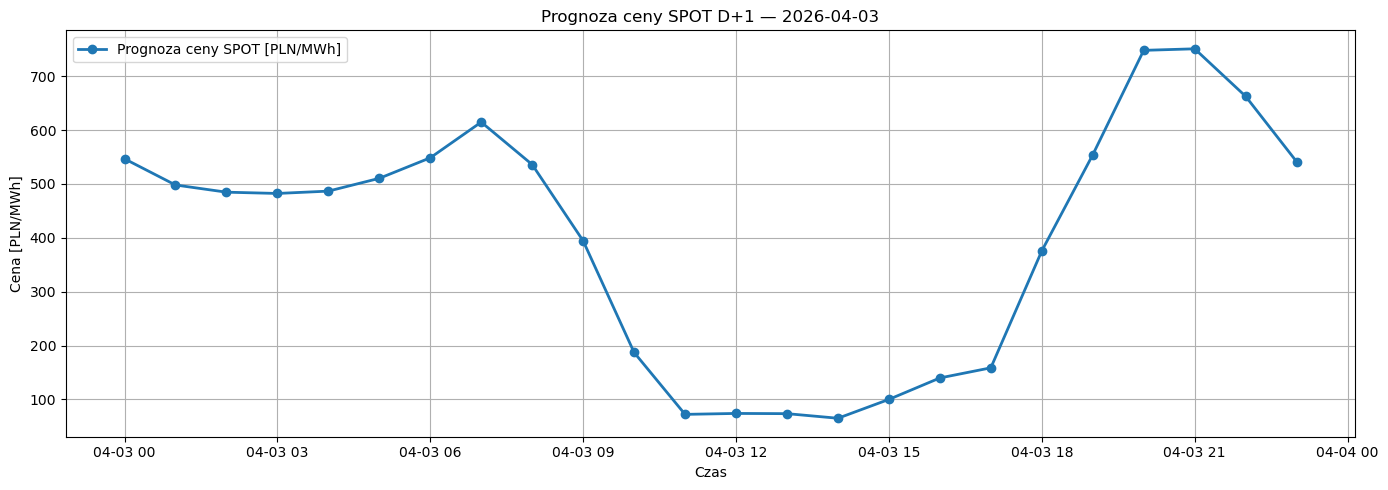

In [73]:
plt.figure(figsize=(14, 5))

plt.plot(
    spot_forecast_d1["timestamp"],
    spot_forecast_d1["price_spot_forecast"],
    marker="o",
    linewidth=2,
    label="Prognoza ceny SPOT [PLN/MWh]",
)

plt.title(f"Prognoza ceny SPOT D+1 — {SPOT_FORECAST_DATE}")
plt.xlabel("Czas")
plt.ylabel("Cena [PLN/MWh]")
plt.grid(True)
plt.legend()
show_intermediate_plot()


## DODANIE PROGNOZY SPOT DO PLANU VPP 15-MIN


In [75]:
vpp_plan = vpp_plan.copy()
spot_forecast_d1 = spot_forecast_d1.copy()

vpp_plan["timestamp"] = pd.to_datetime(vpp_plan["timestamp"])
spot_forecast_d1["timestamp"] = pd.to_datetime(spot_forecast_d1["timestamp"])

# Cena SPOT jest godzinowa, więc przypisujemy ją do każdego interwału 15-min w danej godzinie.
vpp_plan["timestamp_hour"] = vpp_plan["timestamp"].dt.floor("h")

spot_to_merge = spot_forecast_d1.rename(
    columns={
        "timestamp": "timestamp_hour",
        "load": "kse_load_forecast_MW",
        "pv_gen": "kse_pv_forecast_MW",
        "fw_gen": "kse_wind_forecast_MW",
        "residual_load": "kse_residual_load_forecast_MW",
        "temperature_2m": "spot_weather_temperature_2m",
    }
)

vpp_plan = vpp_plan.merge(
    spot_to_merge[
        [
            "timestamp_hour",
            "price_spot_forecast",
            "kse_load_forecast_MW",
            "kse_pv_forecast_MW",
            "kse_wind_forecast_MW",
            "kse_residual_load_forecast_MW",
            "spot_weather_temperature_2m",
        ]
    ],
    on="timestamp_hour",
    how="left",
)

if vpp_plan["price_spot_forecast"].isna().any():
    missing_rows = vpp_plan[
        vpp_plan["price_spot_forecast"].isna()
    ][["timestamp", "timestamp_hour"]]

    maybe_display(missing_rows.head(20))
    raise ValueError("Po dodaniu SPOT pojawiły się braki w price_spot_forecast.")

print("Prognoza SPOT dodana do vpp_plan.")
print("Liczba wierszy VPP:", len(vpp_plan))
print("Liczba unikalnych godzin SPOT:", vpp_plan["timestamp_hour"].nunique())

vpp_plan.head()


Prognoza SPOT dodana do vpp_plan.
Liczba wierszy VPP: 96
Liczba unikalnych godzin SPOT: 24


,timestamp,pv_power_MW,pv_energy_MWh_15min,pv_profile_pu,wind_power_MW,wind_energy_MWh_15min,wind_profile_pu,res_power_MW,res_energy_MWh_15min,actual_heat_MW_2024,...,industrial_load_MW,industrial_load_MW_scaled,industrial_load_MWh_15min_scaled,timestamp_hour,price_spot_forecast,kse_load_forecast_MW,kse_pv_forecast_MW,kse_wind_forecast_MW,kse_residual_load_forecast_MW,spot_weather_temperature_2m
0,2026-04-03 00:00:00,0.0,0.0,0.0,17.951169,4.487792,0.560974,17.951169,4.487792,19.539306,...,0.186252,5.270821,1.317705,2026-04-03 00:00:00,546.541138,17520.0,0.0,1127.0,16393.0,7.3
1,2026-04-03 00:15:00,0.0,0.0,0.0,16.793184,4.198296,0.524787,16.793184,4.198296,19.593813,...,0.150443,4.257442,1.064361,2026-04-03 00:00:00,546.541138,17520.0,0.0,1127.0,16393.0,7.3
2,2026-04-03 00:30:00,0.0,0.0,0.0,15.634529,3.908632,0.488579,15.634529,3.908632,19.648319,...,0.145332,4.112812,1.028203,2026-04-03 00:00:00,546.541138,17520.0,0.0,1127.0,16393.0,7.3
3,2026-04-03 00:45:00,0.0,0.0,0.0,14.475241,3.618810,0.452351,14.475241,3.618810,19.702826,...,0.170903,4.836447,1.209112,2026-04-03 00:00:00,546.541138,17520.0,0.0,1127.0,16393.0,7.3
4,2026-04-03 01:00:00,0.0,0.0,0.0,13.315320,3.328830,0.416104,13.315320,3.328830,19.757333,...,0.153850,4.353863,1.088466,2026-04-03 01:00:00,497.947083,15814.0,0.0,1278.0,14536.0,6.0


## PORÓWNANIE PROGNOZY SPOT Z RZECZYWISTĄ CENĄ


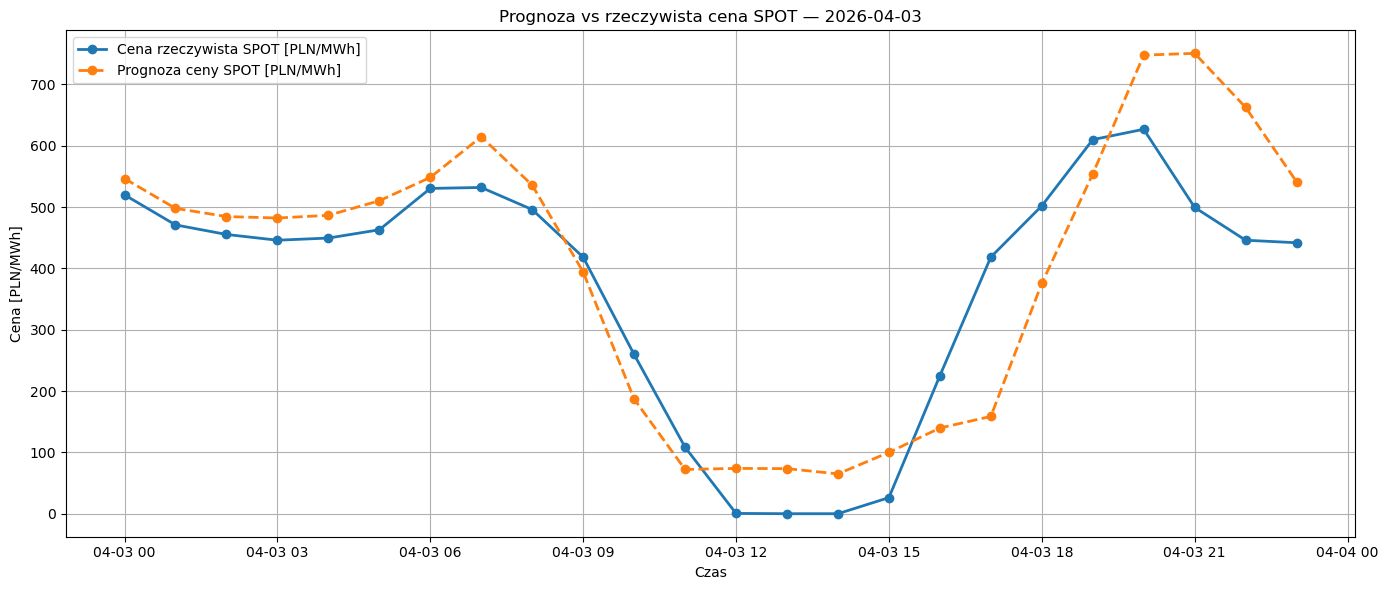

,timestamp,price_spot_forecast,price_spot_actual,error_PLN_MWh
0,2026-04-03 00:00:00,546.541138,519.99,26.551138
1,2026-04-03 01:00:00,497.947083,471.00,26.947083
2,2026-04-03 02:00:00,484.591095,455.40,29.191095
3,2026-04-03 03:00:00,482.231812,446.00,36.231812
4,2026-04-03 04:00:00,486.560913,449.52,37.040913
5,2026-04-03 05:00:00,510.313141,463.00,47.313141
6,2026-04-03 06:00:00,548.398071,530.44,17.958071
7,2026-04-03 07:00:00,614.652039,532.01,82.642039
8,2026-04-03 08:00:00,535.828918,496.00,39.828918
9,2026-04-03 09:00:00,394.275055,418.34,-24.064945


In [77]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Wczytanie rzeczywistych cen SPOT
spot_actual = pd.read_excel(SPOT_HISTORY_PATH)

spot_actual["timestamp"] = pd.to_datetime(spot_actual["timestamp"])
spot_actual["price_spot"] = pd.to_numeric(
    spot_actual["price_spot"],
    errors="coerce"
)

spot_actual = (
    spot_actual
    .dropna(subset=["timestamp", "price_spot"])
    .drop_duplicates(subset=["timestamp"])
    .sort_values("timestamp")
    .reset_index(drop=True)
)

# 2. Wybranie rzeczywistych cen dla prognozowanego dnia
spot_actual_day = spot_actual[
    (spot_actual["timestamp"] >= spot_forecast_start) &
    (spot_actual["timestamp"] <= spot_forecast_end)
][["timestamp", "price_spot"]].copy()

spot_actual_day = spot_actual_day.rename(
    columns={
        "price_spot": "price_spot_actual"
    }
)

# 3. Połączenie forecast + actual
spot_compare = spot_forecast_d1[
    [
        "timestamp",
        "price_spot_forecast"
    ]
].copy()

spot_compare["timestamp"] = pd.to_datetime(spot_compare["timestamp"])
spot_actual_day["timestamp"] = pd.to_datetime(spot_actual_day["timestamp"])

spot_compare = spot_compare.merge(
    spot_actual_day,
    on="timestamp",
    how="left"
)

# 4. Kontrola, czy mamy rzeczywiste ceny
if spot_compare["price_spot_actual"].isna().any():
    missing_hours = spot_compare[
        spot_compare["price_spot_actual"].isna()
    ][["timestamp"]]

    maybe_display(missing_hours)

    raise ValueError(
        "Brakuje rzeczywistych cen SPOT dla części godzin. "
        "Sprawdź, czy plik SPOT_2026.xlsx zawiera rzeczywiste ceny dla prognozowanego dnia."
    )

# 5. Metryki błędu
mae_spot = mean_absolute_error(
    spot_compare["price_spot_actual"],
    spot_compare["price_spot_forecast"]
)

rmse_spot = np.sqrt(
    mean_squared_error(
        spot_compare["price_spot_actual"],
        spot_compare["price_spot_forecast"]
    )
)

r2_spot = r2_score(
    spot_compare["price_spot_actual"],
    spot_compare["price_spot_forecast"]
)

mape_spot = np.mean(
    np.abs(
        (
            spot_compare["price_spot_actual"]
            - spot_compare["price_spot_forecast"]
        )
        / spot_compare["price_spot_actual"]
    )
) * 100

spot_compare["error_PLN_MWh"] = (
    spot_compare["price_spot_forecast"]
    - spot_compare["price_spot_actual"]
)

summary_spot_quality = pd.DataFrame([
    {
        "data_prognozy": SPOT_FORECAST_DATE,
        "MAE_PLN_MWh": mae_spot,
        "RMSE_PLN_MWh": rmse_spot,
        "MAPE_%": mape_spot,
        "R2": r2_spot,
        "actual_avg_PLN_MWh": spot_compare["price_spot_actual"].mean(),
        "forecast_avg_PLN_MWh": spot_compare["price_spot_forecast"].mean(),
        "actual_min_PLN_MWh": spot_compare["price_spot_actual"].min(),
        "forecast_min_PLN_MWh": spot_compare["price_spot_forecast"].min(),
        "actual_max_PLN_MWh": spot_compare["price_spot_actual"].max(),
        "forecast_max_PLN_MWh": spot_compare["price_spot_forecast"].max(),
    }
])

maybe_display(summary_spot_quality)

# 6. Wykres forecast vs actual
plt.figure(figsize=(14, 6))

plt.plot(
    spot_compare["timestamp"],
    spot_compare["price_spot_actual"],
    marker="o",
    linewidth=2,
    label="Cena rzeczywista SPOT [PLN/MWh]"
)

plt.plot(
    spot_compare["timestamp"],
    spot_compare["price_spot_forecast"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Prognoza ceny SPOT [PLN/MWh]"
)

plt.title(f"Prognoza vs rzeczywista cena SPOT — {SPOT_FORECAST_DATE}")
plt.xlabel("Czas")
plt.ylabel("Cena [PLN/MWh]")
plt.legend()
plt.grid(True)
show_intermediate_plot()

spot_compare


## WYKRES BŁĘDU PROGNOZY SPOT


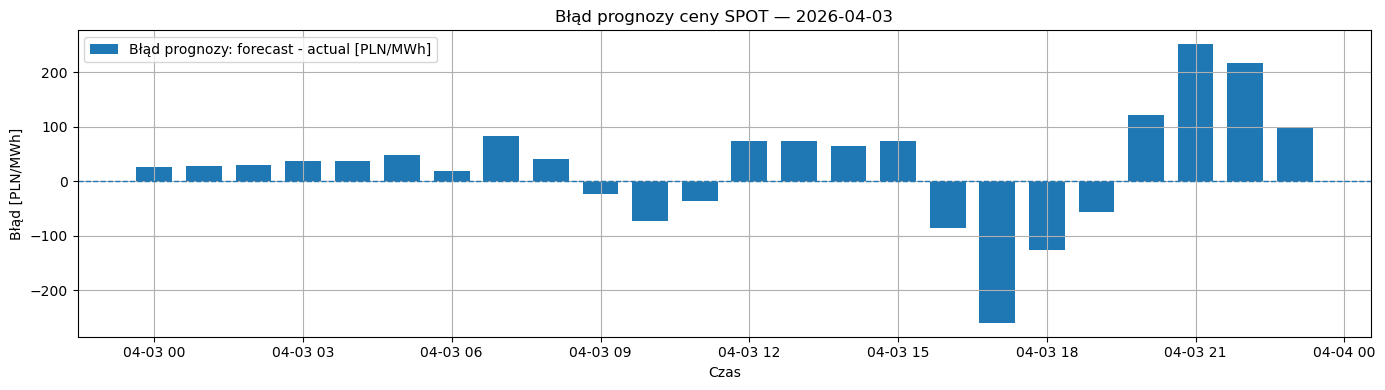

In [79]:
plt.figure(figsize=(14, 4))

plt.bar(
    spot_compare["timestamp"],
    spot_compare["error_PLN_MWh"],
    width=0.03,
    label="Błąd prognozy: forecast - actual [PLN/MWh]"
)

plt.axhline(0, linewidth=1, linestyle="--")

plt.title(f"Błąd prognozy ceny SPOT — {SPOT_FORECAST_DATE}")
plt.xlabel("Czas")
plt.ylabel("Błąd [PLN/MWh]")
plt.legend()
plt.grid(True)
show_intermediate_plot()


In [80]:
Dane_rynkowe_SG = pd.read_excel("Dane rynkowe.xlsx")
Dane_rynkowe_SG["timestamp"] = pd.to_datetime(Dane_rynkowe_SG["timestamp"])
Dane_rynkowe_SG["Doba gazowa"] = pd.to_datetime(Dane_rynkowe_SG["Doba gazowa"])

# Zużycie własne chłodni wentylatorowych
cooling_fan_aux_MWh_per_MWh_heat = 0.02
Dane_rynkowe_SG = Dane_rynkowe_SG.set_index("timestamp")

# 2. Resampling do 15 minut - tworzy nowe wiersze z wartościami NaN
Dane_rynkowe_SG_15m = Dane_rynkowe_SG.resample("15min").asfreq()

# 3. Definiujemy, jak traktować poszczególne kolumny:
# Kolumny cenowe i datę gazową chcemy skopiować (Forward Fill)
kolumny_cenowe_i_inne = [
    "Doba gazowa",
    "RTT_e.e - cena (sprzedaż) PLN/ MWh",
    "Cena RDN PLN/MWh",
    "RTT_gaz - cena (zakup) PLN/MWh HHV",
    "Cena RDNg PLN/MWh HHV",
    "Cena CO_2  PLN/t CO_2",
]

# Kolumny wolumenowe chcemy podzielić przez 4 (ponieważ godzina ma cztery kwadransy)
kolumny_wolumenowe = [
    "RTT_e.e - wolumen (sprzedaż) MWh",
    "RTT_gaz - wolumen (zakup) MWh HHV",
]

# Wypełniamy ceny i datę gazową wartościami z "góry" (ffill)
Dane_rynkowe_SG_15m[kolumny_cenowe_i_inne] = Dane_rynkowe_SG_15m[kolumny_cenowe_i_inne].ffill()

# Dla wolumenów: najpierw kopiujemy wartość godzinową, a potem dzielimy przez 4
Dane_rynkowe_SG_15m[kolumny_wolumenowe] = Dane_rynkowe_SG_15m[kolumny_wolumenowe].ffill() / 4

# 4. Przywrócenie timestampu jako zwykłej kolumny i zresetowanie indeksu
Dane_rynkowe_SG_15m = Dane_rynkowe_SG_15m.reset_index()

# Podgląd wyniku
print(Dane_rynkowe_SG_15m.head(8))


            timestamp         Doba gazowa  RTT_e.e - wolumen (sprzedaż) MWh  \
0 2026-01-01 00:00:00 2025-12-31 18:00:00                             11.25   
1 2026-01-01 00:15:00 2025-12-31 18:00:00                             11.25   
2 2026-01-01 00:30:00 2025-12-31 18:00:00                             11.25   
3 2026-01-01 00:45:00 2025-12-31 18:00:00                             11.25   
4 2026-01-01 01:00:00 2025-12-31 19:00:00                             11.25   
5 2026-01-01 01:15:00 2025-12-31 19:00:00                             11.25   
6 2026-01-01 01:30:00 2025-12-31 19:00:00                             11.25   
7 2026-01-01 01:45:00 2025-12-31 19:00:00                             11.25   

   RTT_gaz - wolumen (zakup) MWh HHV  RTT_e.e - cena (sprzedaż) PLN/ MWh  \
0                              27.25                              453.92   
1                              27.25                              453.92   
2                              27.25                        

## MERGE VPP + DANE RYNKOWE SG / RTT / GAZ / CO2


In [82]:
Dane_rynkowe_SG_15m = Dane_rynkowe_SG_15m.drop(columns=["Doba gazowa"], errors="ignore")

vpp_plan["timestamp"] = pd.to_datetime(vpp_plan["timestamp"])
Dane_rynkowe_SG_15m["timestamp"] = pd.to_datetime(Dane_rynkowe_SG_15m["timestamp"])

vpp_plan = vpp_plan.merge(
    Dane_rynkowe_SG_15m,
    on="timestamp",
    how="left",
)

vpp_plan.head()


,timestamp,pv_power_MW,pv_energy_MWh_15min,pv_profile_pu,wind_power_MW,wind_energy_MWh_15min,wind_profile_pu,res_power_MW,res_energy_MWh_15min,actual_heat_MW_2024,...,kse_wind_forecast_MW,kse_residual_load_forecast_MW,spot_weather_temperature_2m,RTT_e.e - wolumen (sprzedaż) MWh,RTT_gaz - wolumen (zakup) MWh HHV,RTT_e.e - cena (sprzedaż) PLN/ MWh,Cena RDN PLN/MWh,RTT_gaz - cena (zakup) PLN/MWh HHV,Cena RDNg PLN/MWh HHV,Cena CO_2 PLN/t CO_2
0,2026-04-03 00:00:00,0.0,0.0,0.0,17.951169,4.487792,0.560974,17.951169,4.487792,19.539306,...,1127.0,16393.0,7.3,7.5,18.25,453.92,NaN,134.98,231.28,309.99
1,2026-04-03 00:15:00,0.0,0.0,0.0,16.793184,4.198296,0.524787,16.793184,4.198296,19.593813,...,1127.0,16393.0,7.3,7.5,18.25,453.92,NaN,134.98,231.28,309.99
2,2026-04-03 00:30:00,0.0,0.0,0.0,15.634529,3.908632,0.488579,15.634529,3.908632,19.648319,...,1127.0,16393.0,7.3,7.5,18.25,453.92,NaN,134.98,231.28,309.99
3,2026-04-03 00:45:00,0.0,0.0,0.0,14.475241,3.618810,0.452351,14.475241,3.618810,19.702826,...,1127.0,16393.0,7.3,7.5,18.25,453.92,NaN,134.98,231.28,309.99
4,2026-04-03 01:00:00,0.0,0.0,0.0,13.315320,3.328830,0.416104,13.315320,3.328830,19.757333,...,1278.0,14536.0,6.0,7.5,18.25,453.92,NaN,134.98,231.28,309.99


## UTWORZENIE RAMKI WEJŚCIOWEJ DO OPTYMALIZATORA


In [84]:
optimizer_input = vpp_plan.copy()


In [85]:
optimizer_input["timestamp"] = pd.to_datetime(optimizer_input["timestamp"])
optimizer_input["timestamp_hour"] = pd.to_datetime(optimizer_input["timestamp_hour"])

optimizer_input = (
    optimizer_input
    .sort_values("timestamp")
    .reset_index(drop=True)
)

print("Liczba wierszy:", len(optimizer_input))
print("Zakres:", optimizer_input["timestamp"].min(), "->", optimizer_input["timestamp"].max())

optimizer_input.head()


Liczba wierszy: 96
Zakres: 2026-04-03 00:00:00 -> 2026-04-03 23:45:00


,timestamp,pv_power_MW,pv_energy_MWh_15min,pv_profile_pu,wind_power_MW,wind_energy_MWh_15min,wind_profile_pu,res_power_MW,res_energy_MWh_15min,actual_heat_MW_2024,...,kse_wind_forecast_MW,kse_residual_load_forecast_MW,spot_weather_temperature_2m,RTT_e.e - wolumen (sprzedaż) MWh,RTT_gaz - wolumen (zakup) MWh HHV,RTT_e.e - cena (sprzedaż) PLN/ MWh,Cena RDN PLN/MWh,RTT_gaz - cena (zakup) PLN/MWh HHV,Cena RDNg PLN/MWh HHV,Cena CO_2 PLN/t CO_2
0,2026-04-03 00:00:00,0.0,0.0,0.0,17.951169,4.487792,0.560974,17.951169,4.487792,19.539306,...,1127.0,16393.0,7.3,7.5,18.25,453.92,NaN,134.98,231.28,309.99
1,2026-04-03 00:15:00,0.0,0.0,0.0,16.793184,4.198296,0.524787,16.793184,4.198296,19.593813,...,1127.0,16393.0,7.3,7.5,18.25,453.92,NaN,134.98,231.28,309.99
2,2026-04-03 00:30:00,0.0,0.0,0.0,15.634529,3.908632,0.488579,15.634529,3.908632,19.648319,...,1127.0,16393.0,7.3,7.5,18.25,453.92,NaN,134.98,231.28,309.99
3,2026-04-03 00:45:00,0.0,0.0,0.0,14.475241,3.618810,0.452351,14.475241,3.618810,19.702826,...,1127.0,16393.0,7.3,7.5,18.25,453.92,NaN,134.98,231.28,309.99
4,2026-04-03 01:00:00,0.0,0.0,0.0,13.315320,3.328830,0.416104,13.315320,3.328830,19.757333,...,1278.0,14536.0,6.0,7.5,18.25,453.92,NaN,134.98,231.28,309.99


## 3. STANDARYZACJA KOLUMN DO OPTYMALIZATORA


In [87]:
optimizer_input = optimizer_input.rename(columns={
    "pv_power_MW": "pv_MW",
    "pv_energy_MWh_15min": "pv_MWh",
    "wind_power_MW": "wind_MW",
    "wind_energy_MWh_15min": "wind_MWh",
    "res_power_MW": "res_MW",
    "res_energy_MWh_15min": "res_MWh",
    "heat_demand_MW": "heat_demand_MW",
    "heat_demand_MWh_15min": "heat_demand_MWh",
    "industrial_load_MW_scaled": "ee_load_MW",
    "industrial_load_MWh_15min_scaled": "ee_load_MWh",
    "price_spot_forecast": "spot_price",
    "RTT_e.e - wolumen (sprzedaż) MWh": "rtt_ee_sell_MWh",
    "RTT_gaz - wolumen (zakup) MWh HHV": "rtt_gas_buy_MWh_HHV",
    "RTT_e.e - cena (sprzedaż) PLN/ MWh": "rtt_ee_sell_price",
    "Cena RDN PLN/MWh": "spot_price_actual",
    "RTT_gaz - cena (zakup) PLN/MWh HHV": "rtt_gas_price",
    "Cena RDNg PLN/MWh HHV": "gas_spot_price",
    "Cena CO_2  PLN/t CO_2": "co2_price"
})

# Jeżeli Cena RDN jest pusta, używamy prognozy SPOT
optimizer_input["spot_price_used"] = optimizer_input["spot_price"]

optimizer_input.head()


,timestamp,pv_MW,pv_MWh,pv_profile_pu,wind_MW,wind_MWh,wind_profile_pu,res_MW,res_MWh,actual_heat_MW_2024,...,kse_residual_load_forecast_MW,spot_weather_temperature_2m,rtt_ee_sell_MWh,rtt_gas_buy_MWh_HHV,rtt_ee_sell_price,spot_price_actual,rtt_gas_price,gas_spot_price,co2_price,spot_price_used
0,2026-04-03 00:00:00,0.0,0.0,0.0,17.951169,4.487792,0.560974,17.951169,4.487792,19.539306,...,16393.0,7.3,7.5,18.25,453.92,NaN,134.98,231.28,309.99,546.541138
1,2026-04-03 00:15:00,0.0,0.0,0.0,16.793184,4.198296,0.524787,16.793184,4.198296,19.593813,...,16393.0,7.3,7.5,18.25,453.92,NaN,134.98,231.28,309.99,546.541138
2,2026-04-03 00:30:00,0.0,0.0,0.0,15.634529,3.908632,0.488579,15.634529,3.908632,19.648319,...,16393.0,7.3,7.5,18.25,453.92,NaN,134.98,231.28,309.99,546.541138
3,2026-04-03 00:45:00,0.0,0.0,0.0,14.475241,3.618810,0.452351,14.475241,3.618810,19.702826,...,16393.0,7.3,7.5,18.25,453.92,NaN,134.98,231.28,309.99,546.541138
4,2026-04-03 01:00:00,0.0,0.0,0.0,13.315320,3.328830,0.416104,13.315320,3.328830,19.757333,...,14536.0,6.0,7.5,18.25,453.92,NaN,134.98,231.28,309.99,497.947083


## 4. BILANS PORTFELA PRZED OPTYMALIZACJĄ


In [89]:
optimizer_input["natural_generation_MWh"] = (
    optimizer_input["pv_MWh"]
    + optimizer_input["wind_MWh"]
)

optimizer_input["natural_obligation_MWh"] = (
    optimizer_input["ee_load_MWh"]
    + optimizer_input["rtt_ee_sell_MWh"]
)

optimizer_input["net_position_before_dispatch_MWh"] = (
    optimizer_input["natural_generation_MWh"]
    - optimizer_input["natural_obligation_MWh"]
)

optimizer_input["net_position_before_dispatch_MW"] = (
    optimizer_input["net_position_before_dispatch_MWh"] / 0.25
)

summary_balance = pd.DataFrame([{
    "OZE_MWh": optimizer_input["natural_generation_MWh"].sum(),
    "load_ee_MWh": optimizer_input["ee_load_MWh"].sum(),
    "RTT_ee_sell_MWh": optimizer_input["rtt_ee_sell_MWh"].sum(),
    "net_position_MWh": optimizer_input["net_position_before_dispatch_MWh"].sum(),
    "heat_demand_MWh": optimizer_input["heat_demand_MWh"].sum(),
    "avg_spot_price": optimizer_input["spot_price_used"].mean(),
    "avg_gas_spot_price": optimizer_input["gas_spot_price"].mean(),
    "avg_co2_price": optimizer_input["co2_price"].mean()
}])

summary_balance


,OZE_MWh,load_ee_MWh,RTT_ee_sell_MWh,net_position_MWh,heat_demand_MWh,avg_spot_price,avg_gas_spot_price,avg_co2_price
0,227.048076,204.079667,720.0,-697.031592,556.825439,400.132477,233.035,309.99


## 5. WYKRES: POZYCJA PORTFELA PRZED OPTYMALIZACJĄ


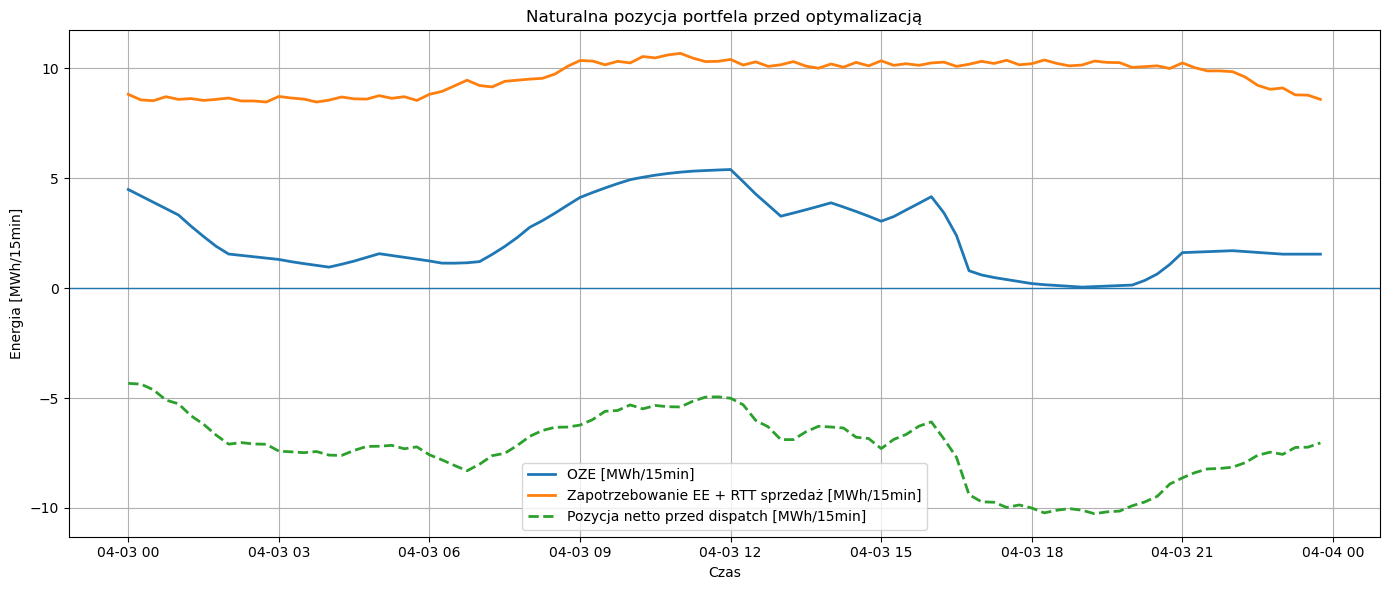

In [91]:
plt.figure(figsize=(14, 6))

plt.plot(
    optimizer_input["timestamp"],
    optimizer_input["natural_generation_MWh"],
    label="OZE [MWh/15min]",
    linewidth=2
)

plt.plot(
    optimizer_input["timestamp"],
    optimizer_input["natural_obligation_MWh"],
    label="Zapotrzebowanie EE + RTT sprzedaż [MWh/15min]",
    linewidth=2
)

plt.plot(
    optimizer_input["timestamp"],
    optimizer_input["net_position_before_dispatch_MWh"],
    label="Pozycja netto przed dispatch [MWh/15min]",
    linewidth=2,
    linestyle="--"
)

plt.axhline(0, linewidth=1)
plt.title("Naturalna pozycja portfela przed optymalizacją")
plt.xlabel("Czas")
plt.ylabel("Energia [MWh/15min]")
plt.legend()
plt.grid(True)
show_intermediate_plot()


## 6. PARAMETRY TECHNICZNE PORTFELA


In [93]:
INTERVAL_MINUTES = 15
DT_H = INTERVAL_MINUTES / 60
dt_h = DT_H  # alias używany w dalszych komórkach
Ilosc_silnikow = 5

params = {
    # Silnik gazowy Jenbacher
    "engine_p_el_max_MW": 10.606 * Ilosc_silnikow,
    "engine_p_el_min_MW": 0.30 * 10.606 * Ilosc_silnikow,
    "engine_p_heat_max_MW": 10.3 * Ilosc_silnikow,
    "engine_heat_to_el_ratio": 10.3 / 10.606,

    # Kocioł elektrodowy
    "electrode_boiler_heat_max_MW": 18.0,
    "electrode_boiler_efficiency": 0.99,

    # Magazyn energii
    "battery_charge_max_MW": 5.0,
    "battery_discharge_max_MW": 5.0,
    "battery_capacity_MWh": 20.0,
    "battery_soc_min_MWh": 0.10 * 20.0,
    "battery_soc_max_MWh": 0.90 * 20.0,
    "battery_roundtrip_eff": 0.85,
    "battery_eta_charge": np.sqrt(0.85),
    "battery_eta_discharge": np.sqrt(0.85),

    # Emisyjność gazu
    "gas_emission_factor_tCO2_per_MWh_HHV": 0.179899276,

    # Konwersja LHV -> HHV
    "HHV_LHV_RATIO": 1.108,

    # Kary za niedobory techniczne
    "unserved_heat_penalty_PLN_MWh": 100000,
    "unserved_ee_penalty_PLN_MWh": 100000,

    # Chłodnie wentylatorowe — zużycie własne przy zrzucie ciepła
    "cooling_fan_aux_MWh_per_MWh_heat": 0.02,

    # Minimalny czas pracy silnika po uruchomieniu
    "engine_min_uptime_h": 2,
}

cooling_fan_aux_MWh_per_MWh_heat = params["cooling_fan_aux_MWh_per_MWh_heat"]
engine_min_uptime_h = params["engine_min_uptime_h"]
engine_min_uptime_steps = int(engine_min_uptime_h / dt_h)

print("Minimalny czas pracy silnika [interwały]:", engine_min_uptime_steps)
params


Minimalny czas pracy silnika [interwały]: 8


{'engine_p_el_max_MW': 53.03,
 'engine_p_el_min_MW': 15.908999999999999,
 'engine_p_heat_max_MW': 51.5,
 'engine_heat_to_el_ratio': 0.9711484065623233,
 'electrode_boiler_heat_max_MW': 18.0,
 'electrode_boiler_efficiency': 0.99,
 'battery_charge_max_MW': 5.0,
 'battery_discharge_max_MW': 5.0,
 'battery_capacity_MWh': 20.0,
 'battery_soc_min_MWh': 2.0,
 'battery_soc_max_MWh': 18.0,
 'battery_roundtrip_eff': 0.85,
 'battery_eta_charge': 0.9219544457292888,
 'battery_eta_discharge': 0.9219544457292888,
 'gas_emission_factor_tCO2_per_MWh_HHV': 0.179899276,
 'HHV_LHV_RATIO': 1.108,
 'unserved_heat_penalty_PLN_MWh': 100000,
 'unserved_ee_penalty_PLN_MWh': 100000,
 'cooling_fan_aux_MWh_per_MWh_heat': 0.02,
 'engine_min_uptime_h': 2}

## PARAMETRY CZASOWE SILNIKA — KONTROLA


In [95]:
print("Minimalny czas pracy silnika [h]:", engine_min_uptime_h)
print("Minimalny czas pracy silnika [interwały 15-min]:", engine_min_uptime_steps)


Minimalny czas pracy silnika [h]: 2
Minimalny czas pracy silnika [interwały 15-min]: 8


## 7. IMPORT SOLVERA MILP


In [97]:
import pulp


## 8. PRZYGOTOWANIE DANYCH DO OPTYMALIZATORA


In [99]:
df_opt = optimizer_input.copy().reset_index(drop=True)

T = range(len(df_opt))
dt_h = 0.25

required_cols = [
    "timestamp",
    "pv_MWh",
    "wind_MWh",
    "ee_load_MWh",
    "heat_demand_MWh",
    "rtt_ee_sell_MWh",
    "spot_price_used",
    "rtt_gas_price",
    "gas_spot_price",
    "co2_price"
]

missing_cols = [col for col in required_cols if col not in df_opt.columns]

if missing_cols:
    raise ValueError(f"Brakuje kolumn do optymalizatora: {missing_cols}")

print("Liczba interwałów:", len(df_opt))
print("Zakres:", df_opt["timestamp"].min(), "->", df_opt["timestamp"].max())

df_opt[required_cols].head()


Liczba interwałów: 96
Zakres: 2026-04-03 00:00:00 -> 2026-04-03 23:45:00


,timestamp,pv_MWh,wind_MWh,ee_load_MWh,heat_demand_MWh,rtt_ee_sell_MWh,spot_price_used,rtt_gas_price,gas_spot_price,co2_price
0,2026-04-03 00:00:00,0.0,4.487792,1.317705,5.068370,7.5,546.541138,134.98,231.28,309.99
1,2026-04-03 00:15:00,0.0,4.198296,1.064361,5.105167,7.5,546.541138,134.98,231.28,309.99
2,2026-04-03 00:30:00,0.0,3.908632,1.028203,5.130767,7.5,546.541138,134.98,231.28,309.99
3,2026-04-03 00:45:00,0.0,3.618810,1.209112,5.171702,7.5,546.541138,134.98,231.28,309.99
4,2026-04-03 01:00:00,0.0,3.328830,1.088466,5.112300,7.5,497.947083,134.98,231.28,309.99


## 9. PARAMETRY MODELU


In [101]:
engine_p_el_max = params["engine_p_el_max_MW"]
engine_p_el_min = params["engine_p_el_min_MW"]

engine_eta_el = 0.44
engine_heat_to_el_ratio = params["engine_heat_to_el_ratio"]

boiler_heat_max = params["electrode_boiler_heat_max_MW"]
boiler_eta = params["electrode_boiler_efficiency"]

battery_charge_max = params["battery_charge_max_MW"]
battery_discharge_max = params["battery_discharge_max_MW"]
battery_soc_min = params["battery_soc_min_MWh"]
battery_soc_max = params["battery_soc_max_MWh"]
battery_capacity = params["battery_capacity_MWh"]
battery_eta_charge = params["battery_eta_charge"]
battery_eta_discharge = params["battery_eta_discharge"]

emission_factor = params["gas_emission_factor_tCO2_per_MWh_HHV"]

unserved_heat_penalty = params["unserved_heat_penalty_PLN_MWh"]
unserved_ee_penalty = params["unserved_ee_penalty_PLN_MWh"]

# Koszty techniczne / degradacyjne — na start symboliczne
engine_variable_om_PLN_MWh_el = 10
battery_cycle_cost_PLN_MWh = 5

initial_soc = battery_soc_min

print("Min silnika [MW]:", engine_p_el_min)
print("Max silnika [MW]:", engine_p_el_max)
print("Max kotłów elektrodowych [MWt]:", boiler_heat_max)
print("SOC początkowy [MWh]:", initial_soc)


Min silnika [MW]: 15.908999999999999
Max silnika [MW]: 53.03
Max kotłów elektrodowych [MWt]: 18.0
SOC początkowy [MWh]: 2.0


## 10. MODEL MILP — ZMIENNE DECYZYJNE


In [103]:
model = pulp.LpProblem(
    "VPP_Portfolio_Dispatch",
    pulp.LpMaximize
)

# Silnik gazowy
engine_on = pulp.LpVariable.dicts(
    "engine_on",
    T,
    lowBound=0,
    upBound=1,
    cat="Binary"
)

engine_el_MW = pulp.LpVariable.dicts(
    "engine_el_MW",
    T,
    lowBound=0,
    cat="Continuous"
)

engine_heat_MW = pulp.LpVariable.dicts(
    "engine_heat_MW",
    T,
    lowBound=0,
    cat="Continuous"
)

engine_gas_MWh = pulp.LpVariable.dicts(
    "engine_gas_MWh",
    T,
    lowBound=0,
    cat="Continuous"
)

engine_startup = pulp.LpVariable.dicts(
    "engine_startup",
    T,
    lowBound=0,
    upBound=1,
    cat="Binary"
)

cooling_fan_el_MWh = pulp.LpVariable.dicts(
    "cooling_fan_el_MWh",
    T,
    lowBound=0,
    cat="Continuous"
)

# Kotły elektrodowe
boiler_heat_MW = pulp.LpVariable.dicts(
    "boiler_heat_MW",
    T,
    lowBound=0,
    cat="Continuous"
)

boiler_el_MW = pulp.LpVariable.dicts(
    "boiler_el_MW",
    T,
    lowBound=0,
    cat="Continuous"
)

# Magazyn
battery_charge_MW = pulp.LpVariable.dicts(
    "battery_charge_MW",
    T,
    lowBound=0,
    cat="Continuous"
)

battery_discharge_MW = pulp.LpVariable.dicts(
    "battery_discharge_MW",
    T,
    lowBound=0,
    cat="Continuous"
)

battery_soc_MWh = pulp.LpVariable.dicts(
    "battery_soc_MWh",
    T,
    lowBound=battery_soc_min,
    upBound=battery_soc_max,
    cat="Continuous"
)

battery_charge_on = pulp.LpVariable.dicts(
    "battery_charge_on",
    T,
    lowBound=0,
    upBound=1,
    cat="Binary"
)

battery_discharge_on = pulp.LpVariable.dicts(
    "battery_discharge_on",
    T,
    lowBound=0,
    upBound=1,
    cat="Binary"
)

# Rynek SPOT
market_buy_MWh = pulp.LpVariable.dicts(
    "market_buy_MWh",
    T,
    lowBound=0,
    cat="Continuous"
)

market_sell_MWh = pulp.LpVariable.dicts(
    "market_sell_MWh",
    T,
    lowBound=0,
    cat="Continuous"
)

# Slack techniczny
unserved_heat_MWh = pulp.LpVariable.dicts(
    "unserved_heat_MWh",
    T,
    lowBound=0,
    cat="Continuous"
)

unserved_ee_MWh = pulp.LpVariable.dicts(
    "unserved_ee_MWh",
    T,
    lowBound=0,
    cat="Continuous"
)

# Rynek gazu SPOT
gas_spot_buy_MWh = pulp.LpVariable.dicts(
    "gas_spot_buy_MWh",
    T,
    lowBound=0,
    cat="Continuous"
)

gas_spot_sell_MWh = pulp.LpVariable.dicts(
    "gas_spot_sell_MWh",
    T,
    lowBound=0,
    cat="Continuous"
)

# Ciepło oddane do otoczenia / chłodni wentylatorowych
heat_dump_MWh = pulp.LpVariable.dicts(
    "heat_dump_MWh",
    T,
    lowBound=0,
    cat="Continuous"
)


## 11. OGRANICZENIA MODELU


In [105]:
for t in T:

    # -------------------------
    # Silnik gazowy
    # -------------------------
    model += (
        engine_el_MW[t] <= engine_p_el_max * engine_on[t],
        f"engine_max_power_{t}"
    )

    model += (
        engine_el_MW[t] >= engine_p_el_min * engine_on[t],
        f"engine_min_power_{t}"
    )

    # Ciepło proporcjonalne do mocy elektrycznej silnika
    model += (
        engine_heat_MW[t] == engine_el_MW[t] * engine_heat_to_el_ratio,
        f"engine_heat_relation_{t}"
    )

    # Zużycie gazu HHV — uproszczenie ze stałą sprawnością elektryczną
    model += (
        engine_gas_MWh[t] == engine_el_MW[t] * dt_h / engine_eta_el,
        f"engine_gas_consumption_{t}"
    )

    # -------------------------
    # Kotły elektrodowe
    # -------------------------
    model += (
        boiler_heat_MW[t] <= boiler_heat_max,
        f"boiler_heat_max_{t}"
    )

    model += (
        boiler_heat_MW[t] == boiler_el_MW[t] * boiler_eta,
        f"boiler_efficiency_{t}"
    )

    # -------------------------
    # Magazyn energii
    # -------------------------
    model += (
        battery_charge_MW[t] <= battery_charge_max * battery_charge_on[t],
        f"battery_charge_max_{t}"
    )

    model += (
        battery_discharge_MW[t] <= battery_discharge_max * battery_discharge_on[t],
        f"battery_discharge_max_{t}"
    )

    model += (
        battery_charge_on[t] + battery_discharge_on[t] <= 1,
        f"battery_no_simultaneous_charge_discharge_{t}"
    )

    if t == 0:
        model += (
            battery_soc_MWh[t]
            == initial_soc
            + battery_charge_MW[t] * battery_eta_charge * dt_h
            - battery_discharge_MW[t] / battery_eta_discharge * dt_h,
            f"battery_soc_balance_{t}"
        )
    else:
        model += (
            battery_soc_MWh[t]
            == battery_soc_MWh[t - 1]
            + battery_charge_MW[t] * battery_eta_charge * dt_h
            - battery_discharge_MW[t] / battery_eta_discharge * dt_h,
            f"battery_soc_balance_{t}"
        )

    # -------------------------
    # Bilans ciepła
    # -------------------------
    # Nadwyżka ciepła z silnika może zostać oddana do otoczenia
    # na chłodniach wentylatorowych.
    model += (
        engine_heat_MW[t] * dt_h
        + boiler_heat_MW[t] * dt_h
        + unserved_heat_MWh[t]
        ==
        df_opt.loc[t, "heat_demand_MWh"]
        + heat_dump_MWh[t],
        f"heat_balance_{t}"
    )

    # Zużycie własne chłodni wentylatorowych
    model += (
        cooling_fan_el_MWh[t]
        == heat_dump_MWh[t] * cooling_fan_aux_MWh_per_MWh_heat,
        f"cooling_fan_el_consumption_{t}"
    )

    # -------------------------
    # Bilans energii elektrycznej
    # -------------------------
    model += (
        df_opt.loc[t, "pv_MWh"]
        + df_opt.loc[t, "wind_MWh"]
        + engine_el_MW[t] * dt_h
        + battery_discharge_MW[t] * dt_h
        + market_buy_MWh[t]
        + unserved_ee_MWh[t]
        ==
        df_opt.loc[t, "ee_load_MWh"]
        + df_opt.loc[t, "rtt_ee_sell_MWh"]
        + boiler_el_MW[t] * dt_h
        + battery_charge_MW[t] * dt_h
        + cooling_fan_el_MWh[t]
        + market_sell_MWh[t],
        f"electricity_balance_{t}"
    )

    # -------------------------
    # Bilans gazu
    # -------------------------
    model += (
        df_opt.loc[t, "rtt_gas_buy_MWh_HHV"]
        + gas_spot_buy_MWh[t]
        ==
        engine_gas_MWh[t]
        + gas_spot_sell_MWh[t],
        f"gas_balance_{t}"
    )

    # -------------------------
    # Logika uruchomienia silnika
    # -------------------------
    if t == 0:
        # Zakładamy, że przed początkiem doby silnik był wyłączony.
        model += (
            engine_startup[t] >= engine_on[t],
            f"engine_startup_logic_{t}"
        )
    else:
        model += (
            engine_startup[t] >= engine_on[t] - engine_on[t - 1],
            f"engine_startup_logic_{t}"
        )

# -------------------------
# Minimalny czas pracy silnika po uruchomieniu
# -------------------------
for t in T:
    if t <= len(df_opt) - engine_min_uptime_steps:
        model += (
            pulp.lpSum(engine_on[k] for k in range(t, t + engine_min_uptime_steps))
            >= engine_min_uptime_steps * engine_startup[t],
            f"engine_min_uptime_{t}"
        )
    else:
        # Nie pozwalamy uruchomić silnika pod koniec horyzontu,
        # jeśli nie ma już pełnych 2 godzin pracy.
        model += (
            engine_startup[t] == 0,
            f"engine_no_late_startup_{t}"
        )

# Opcjonalnie: końcowy SOC taki sam jak początkowy
model += (
    battery_soc_MWh[len(df_opt) - 1] == initial_soc,
    "battery_final_soc_equal_initial"
)


## 12. FUNKCJA CELU — MAKSYMALIZACJA MARŻY PORTFELA


In [107]:
objective_terms = []
D1_HEAT_DUMP_COST_PLN_MWh = 0.1
heat_dump_cost_PLN_MWh = D1_HEAT_DUMP_COST_PLN_MWh

for t in T:

    spot_price = df_opt.loc[t, "spot_price_used"]
    rtt_ee_price = df_opt.loc[t, "rtt_ee_sell_price"] if "rtt_ee_sell_price" in df_opt.columns else spot_price

    # Jeżeli gaz zakontraktowany jest tańszy/droższy od spot,
    # na start używamy ceny RTT jako ceny paliwa dla silnika.
    gas_price = df_opt.loc[t, "rtt_gas_price"]
    co2_price = df_opt.loc[t, "co2_price"]

    # Przychód z RTT EE — kontrakt jest stały, niezależny od dispatchu.
    # Można go uwzględnić dla pełnej marży portfela.
    revenue_rtt_ee = df_opt.loc[t, "rtt_ee_sell_MWh"] * rtt_ee_price

    # Przychód ze sprzedaży SPOT
    revenue_spot_sell = market_sell_MWh[t] * spot_price

    # Koszt zakupu SPOT
    cost_spot_buy = market_buy_MWh[t] * spot_price

    # Koszt stały zakontraktowanego gazu RTT
    # To jest koszt portfelowy niezależny od tego, czy silnik pracuje.
    cost_rtt_gas = (
        df_opt.loc[t, "rtt_gas_buy_MWh_HHV"]
        * df_opt.loc[t, "rtt_gas_price"]
    )
    
    # Koszt dokupu gazu na SPOT, jeśli kontraktu jest za mało
    cost_gas_spot_buy = (
        gas_spot_buy_MWh[t]
        * df_opt.loc[t, "gas_spot_price"]
    )
    
    # Przychód z odsprzedaży nadwyżki gazu na SPOT
    revenue_gas_spot_sell = (
        gas_spot_sell_MWh[t]
        * df_opt.loc[t, "gas_spot_price"]
    )

    # Koszt CO2
    cost_co2 = engine_gas_MWh[t] * emission_factor * co2_price

    # Koszt zmienny O&M silnika
    cost_engine_om = engine_el_MW[t] * dt_h * engine_variable_om_PLN_MWh_el

    # Koszt degradacji / użycia magazynu
    cost_battery = (
        battery_charge_MW[t] * dt_h
        + battery_discharge_MW[t] * dt_h
    ) * battery_cycle_cost_PLN_MWh

    # Kary techniczne
    cost_unserved_heat = unserved_heat_MWh[t] * unserved_heat_penalty
    cost_unserved_ee = unserved_ee_MWh[t] * unserved_ee_penalty

    cost_heat_dump = heat_dump_MWh[t] * heat_dump_cost_PLN_MWh

    objective_terms.append(
        revenue_rtt_ee
        + revenue_spot_sell
        - cost_spot_buy
        - cost_co2
        - cost_engine_om
        - cost_battery
        - cost_unserved_heat
        - cost_unserved_ee
        + revenue_gas_spot_sell
        - cost_rtt_gas
        - cost_gas_spot_buy
        - cost_heat_dump
    )

model += pulp.lpSum(objective_terms)


## 13. ROZWIĄZANIE MODELU


In [109]:
solver = pulp.PULP_CBC_CMD(
    msg=True,
    timeLimit=120,
    gapRel=0.001
)

model.solve(solver)

status = pulp.LpStatus[model.status]

print("Status modelu:", status)
print("Wartość funkcji celu [PLN]:", pulp.value(model.objective))

if status not in ["Optimal", "Feasible"]:
    raise ValueError(f"Solver nie znalazł rozwiązania. Status: {status}")


Status modelu: Optimal
Wartość funkcji celu [PLN]: 97498.55727208129


## 14. WYNIKI OPTYMALIZACJI


In [111]:
results = df_opt[[
    "timestamp",
    "pv_MWh",
    "wind_MWh",
    "ee_load_MWh",
    "heat_demand_MWh",
    "rtt_ee_sell_MWh",
    "spot_price_used",
    "rtt_gas_price",
    "rtt_ee_sell_price",
    "co2_price",
    "rtt_gas_buy_MWh_HHV",
    'gas_spot_price'
]].copy()

results["engine_on"] = [pulp.value(engine_on[t]) for t in T]
results["engine_el_MW"] = [pulp.value(engine_el_MW[t]) for t in T]
results["engine_heat_MW"] = [pulp.value(engine_heat_MW[t]) for t in T]
results["engine_gas_MWh"] = [pulp.value(engine_gas_MWh[t]) for t in T]

results["boiler_heat_MW"] = [pulp.value(boiler_heat_MW[t]) for t in T]
results["boiler_el_MW"] = [pulp.value(boiler_el_MW[t]) for t in T]

results["battery_charge_MW"] = [pulp.value(battery_charge_MW[t]) for t in T]
results["battery_discharge_MW"] = [pulp.value(battery_discharge_MW[t]) for t in T]
results["battery_soc_MWh"] = [pulp.value(battery_soc_MWh[t]) for t in T]

results["market_buy_MWh"] = [pulp.value(market_buy_MWh[t]) for t in T]
results["market_sell_MWh"] = [pulp.value(market_sell_MWh[t]) for t in T]

results["unserved_heat_MWh"] = [pulp.value(unserved_heat_MWh[t]) for t in T]
results["unserved_ee_MWh"] = [pulp.value(unserved_ee_MWh[t]) for t in T]

results["engine_el_MWh"] = results["engine_el_MW"] * dt_h
results["engine_heat_MWh"] = results["engine_heat_MW"] * dt_h
results["boiler_heat_MWh"] = results["boiler_heat_MW"] * dt_h
results["boiler_el_MWh"] = results["boiler_el_MW"] * dt_h
results["battery_charge_MWh"] = results["battery_charge_MW"] * dt_h
results["battery_discharge_MWh"] = results["battery_discharge_MW"] * dt_h

results["gas_spot_buy_MWh"] = [pulp.value(gas_spot_buy_MWh[t]) for t in T]
results["gas_spot_sell_MWh"] = [pulp.value(gas_spot_sell_MWh[t]) for t in T]

results["gas_contract_MWh"] = results["rtt_gas_buy_MWh_HHV"]
results["gas_balance_check_MWh"] = (
    results["gas_contract_MWh"]
    + results["gas_spot_buy_MWh"]
    - results["engine_gas_MWh"]
    - results["gas_spot_sell_MWh"]
)

results["heat_dump_MWh"] = [pulp.value(heat_dump_MWh[t]) for t in T]
results["heat_dump_MW"] = results["heat_dump_MWh"] / dt_h

results["cooling_fan_el_MWh"] = [
    pulp.value(cooling_fan_el_MWh[t]) for t in T
]

results["cooling_fan_el_MW"] = (
    results["cooling_fan_el_MWh"] / dt_h
)

results.head()


,timestamp,pv_MWh,wind_MWh,ee_load_MWh,heat_demand_MWh,rtt_ee_sell_MWh,spot_price_used,rtt_gas_price,rtt_ee_sell_price,co2_price,...,battery_charge_MWh,battery_discharge_MWh,gas_spot_buy_MWh,gas_spot_sell_MWh,gas_contract_MWh,gas_balance_check_MWh,heat_dump_MWh,heat_dump_MW,cooling_fan_el_MWh,cooling_fan_el_MW
0,2026-04-03 00:00:00,0.0,4.487792,1.317705,5.068370,7.5,546.541138,134.98,453.92,309.99,...,0.0,0.0,0.0,6.388761,18.25,2.000000e-07,0.0,0.0,0.0,0.0
1,2026-04-03 00:15:00,0.0,4.198296,1.064361,5.105167,7.5,546.541138,134.98,453.92,309.99,...,0.0,0.0,0.0,6.302648,18.25,2.000000e-07,0.0,0.0,0.0,0.0
2,2026-04-03 00:30:00,0.0,3.908632,1.028203,5.130767,7.5,546.541138,134.98,453.92,309.99,...,0.0,0.0,0.0,6.242738,18.25,4.000000e-07,0.0,0.0,0.0,0.0
3,2026-04-03 00:45:00,0.0,3.618810,1.209112,5.171702,7.5,546.541138,134.98,453.92,309.99,...,0.0,0.0,0.0,6.146938,18.25,-3.000000e-07,0.0,0.0,0.0,0.0
4,2026-04-03 01:00:00,0.0,3.328830,1.088466,5.112300,7.5,497.947083,134.98,453.92,309.99,...,0.0,0.0,0.0,6.285954,18.25,3.000000e-07,0.0,0.0,0.0,0.0


## 15. PODSUMOWANIE OPTYMALIZACJI


In [113]:
summary_optimization = pd.DataFrame([{
    "objective_PLN": pulp.value(model.objective),

    "pv_MWh": results["pv_MWh"].sum(),
    "wind_MWh": results["wind_MWh"].sum(),
    "ee_load_MWh": results["ee_load_MWh"].sum(),
    "heat_demand_MWh": results["heat_demand_MWh"].sum(),
    "rtt_ee_sell_MWh": results["rtt_ee_sell_MWh"].sum(),

    "engine_el_MWh": results["engine_el_MWh"].sum(),
    "engine_heat_MWh": results["engine_heat_MWh"].sum(),
    "engine_gas_MWh": results["engine_gas_MWh"].sum(),

    "boiler_heat_MWh": results["boiler_heat_MWh"].sum(),
    "boiler_el_MWh": results["boiler_el_MWh"].sum(),

    "battery_charge_MWh": results["battery_charge_MWh"].sum(),
    "battery_discharge_MWh": results["battery_discharge_MWh"].sum(),

    "market_buy_MWh": results["market_buy_MWh"].sum(),
    "market_sell_MWh": results["market_sell_MWh"].sum(),

    "unserved_heat_MWh": results["unserved_heat_MWh"].sum(),
    "unserved_ee_MWh": results["unserved_ee_MWh"].sum(),

    "avg_spot_price_PLN_MWh": results["spot_price_used"].mean(),
    "avg_gas_price_PLN_MWh": results["rtt_gas_price"].mean(),
    "avg_co2_price_PLN_t": results["co2_price"].mean(),

    "rtt_gas_buy_MWh": results["rtt_gas_buy_MWh_HHV"].sum(),
    "gas_spot_buy_MWh": results["gas_spot_buy_MWh"].sum(),
    "gas_spot_sell_MWh": results["gas_spot_sell_MWh"].sum(),

    "heat_dump_MWh": results["heat_dump_MWh"].sum(),
    "max_heat_dump_MW": results["heat_dump_MW"].max(),

    "cooling_fan_el_MWh": results["cooling_fan_el_MWh"].sum(),
    
}])

summary_optimization


,objective_PLN,pv_MWh,wind_MWh,ee_load_MWh,heat_demand_MWh,rtt_ee_sell_MWh,engine_el_MWh,engine_heat_MWh,engine_gas_MWh,boiler_heat_MWh,...,unserved_ee_MWh,avg_spot_price_PLN_MWh,avg_gas_price_PLN_MWh,avg_co2_price_PLN_t,rtt_gas_buy_MWh,gas_spot_buy_MWh,gas_spot_sell_MWh,heat_dump_MWh,max_heat_dump_MW,cooling_fan_el_MWh
0,97498.557272,138.864556,88.18352,204.079667,556.825439,720.0,571.358128,554.873535,1298.541196,60.703709,...,0.0,400.132477,134.98,309.99,1752.0,95.045456,548.504257,58.751817,29.941845,1.175036


## WYKRES: BILANS CIEPŁA Z NADWYŻKĄ DO CHŁODNI


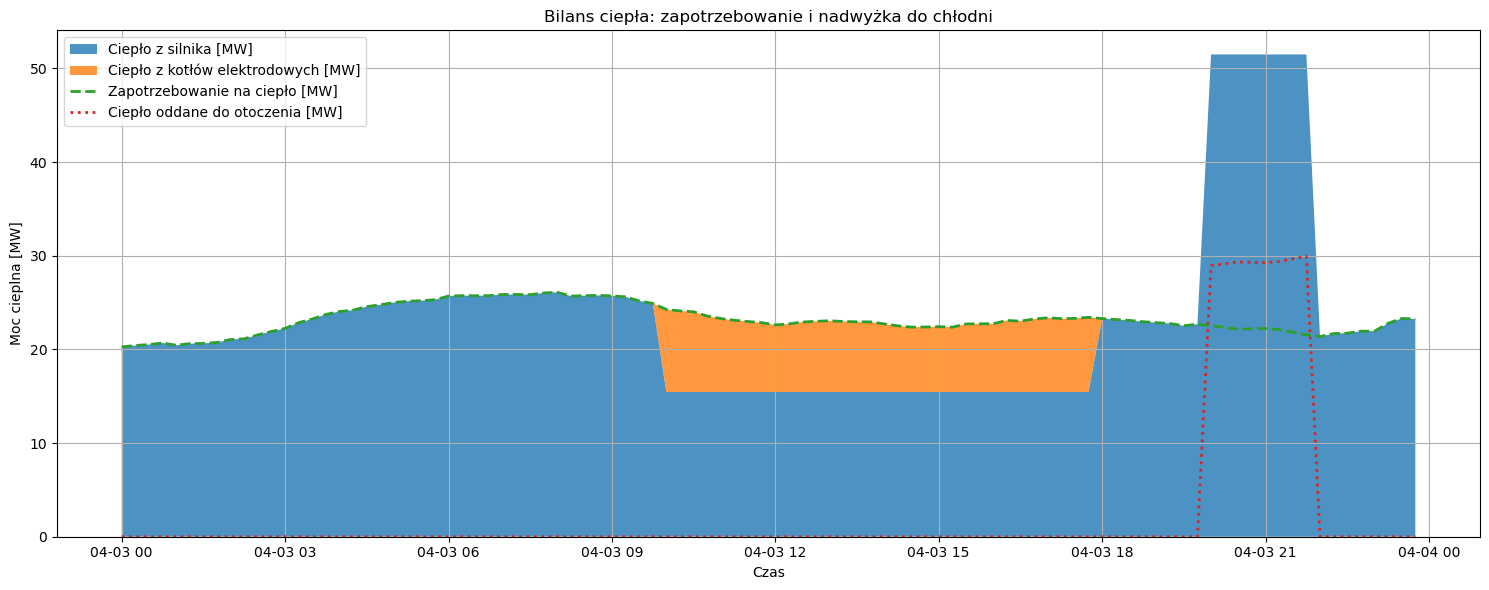

In [115]:
plt.figure(figsize=(15, 6))

plt.stackplot(
    results["timestamp"],
    results["engine_heat_MW"],
    results["boiler_heat_MW"],
    labels=[
        "Ciepło z silnika [MW]",
        "Ciepło z kotłów elektrodowych [MW]"
    ],
    alpha=0.8
)

plt.plot(
    results["timestamp"],
    results["heat_demand_MWh"] / dt_h,
    label="Zapotrzebowanie na ciepło [MW]",
    linewidth=2,
    linestyle="--"
)

plt.plot(
    results["timestamp"],
    results["heat_dump_MW"],
    label="Ciepło oddane do otoczenia [MW]",
    linewidth=2,
    linestyle=":"
)

plt.title("Bilans ciepła: zapotrzebowanie i nadwyżka do chłodni")
plt.xlabel("Czas")
plt.ylabel("Moc cieplna [MW]")
plt.legend(loc="upper left")
plt.grid(True)
show_intermediate_plot()


## 17. WYKRES: BILANS ENERGII ELEKTRYCZNEJ


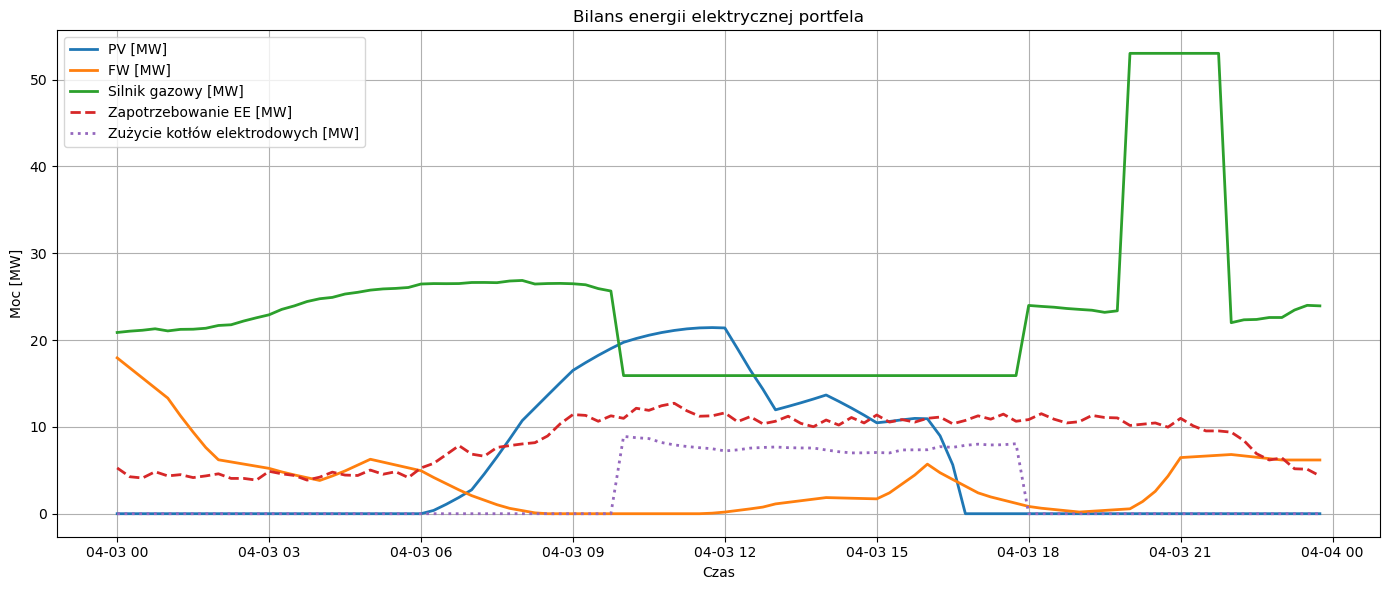

In [117]:
plt.figure(figsize=(14, 6))

plt.plot(
    results["timestamp"],
    results["pv_MWh"] / dt_h,
    label="PV [MW]",
    linewidth=2
)

plt.plot(
    results["timestamp"],
    results["wind_MWh"] / dt_h,
    label="FW [MW]",
    linewidth=2
)

plt.plot(
    results["timestamp"],
    results["engine_el_MW"],
    label="Silnik gazowy [MW]",
    linewidth=2
)

plt.plot(
    results["timestamp"],
    results["ee_load_MWh"] / dt_h,
    label="Zapotrzebowanie EE [MW]",
    linewidth=2,
    linestyle="--"
)

plt.plot(
    results["timestamp"],
    results["boiler_el_MW"],
    label="Zużycie kotłów elektrodowych [MW]",
    linewidth=2,
    linestyle=":"
)

plt.title("Bilans energii elektrycznej portfela")
plt.xlabel("Czas")
plt.ylabel("Moc [MW]")
plt.legend()
plt.grid(True)
show_intermediate_plot()


## 18. WYKRES: MAGAZYN ENERGII


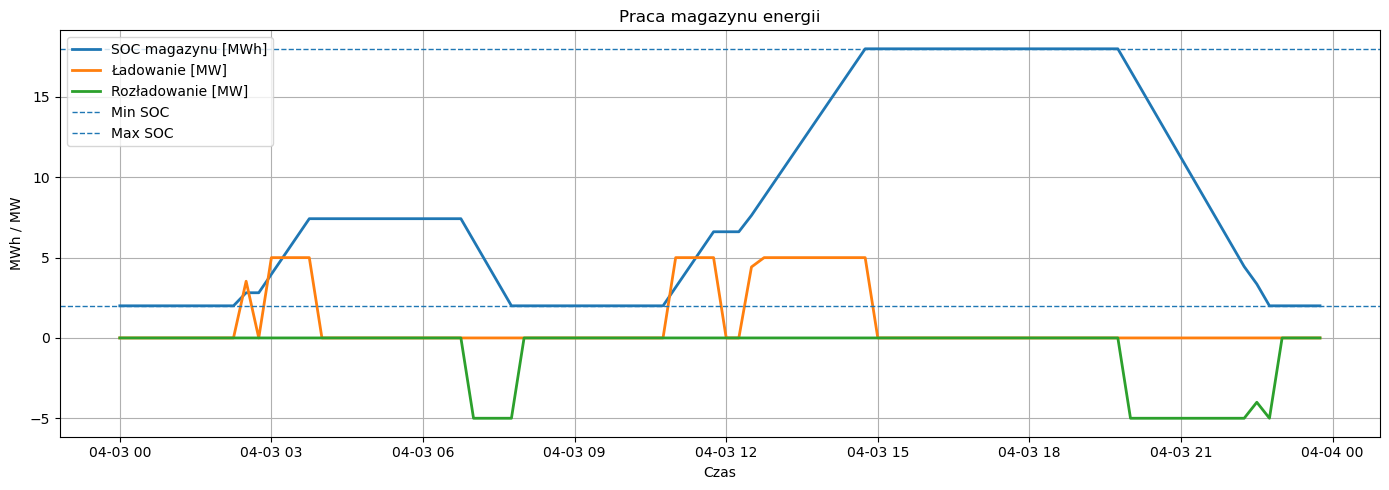

In [119]:
plt.figure(figsize=(14, 5))

plt.plot(
    results["timestamp"],
    results["battery_soc_MWh"],
    label="SOC magazynu [MWh]",
    linewidth=2
)

plt.plot(
    results["timestamp"],
    results["battery_charge_MW"],
    label="Ładowanie [MW]",
    linewidth=2
)

plt.plot(
    results["timestamp"],
    -results["battery_discharge_MW"],
    label="Rozładowanie [MW]",
    linewidth=2
)

plt.axhline(battery_soc_min, linestyle="--", linewidth=1, label="Min SOC")
plt.axhline(battery_soc_max, linestyle="--", linewidth=1, label="Max SOC")

plt.title("Praca magazynu energii")
plt.xlabel("Czas")
plt.ylabel("MWh / MW")
plt.legend()
plt.grid(True)
show_intermediate_plot()


## WYKRES: ZAKUP / SPRZEDAŻ SPOT JAKO SŁUPKI + CENA NA OSI POMOCNICZEJ


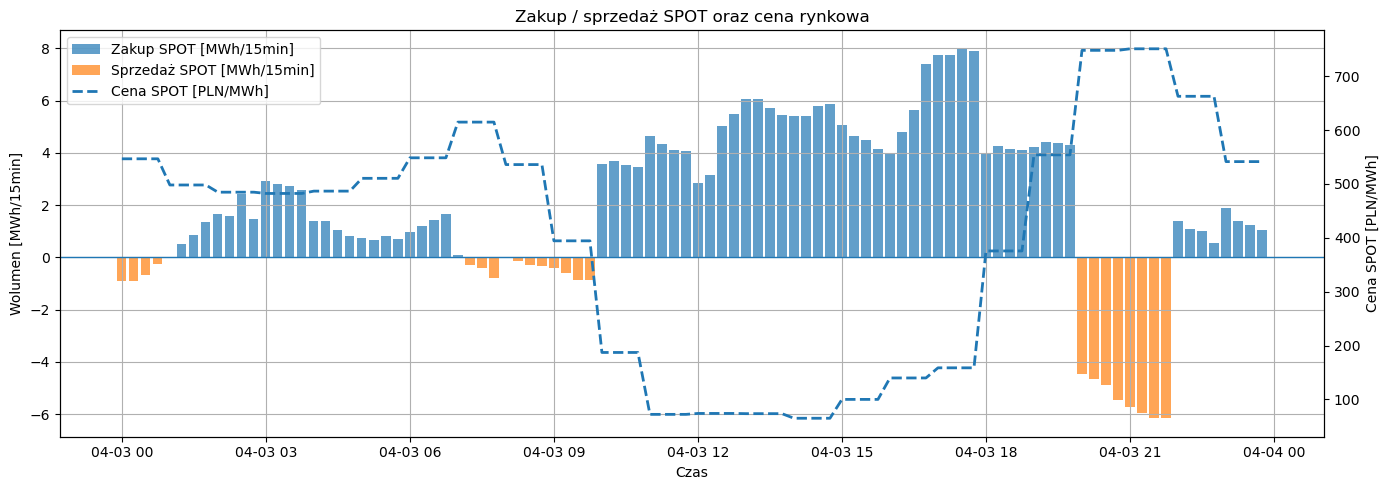

In [121]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(
    results["timestamp"],
    results["market_buy_MWh"],
    width=0.008,
    label="Zakup SPOT [MWh/15min]",
    alpha=0.7
)

ax1.bar(
    results["timestamp"],
    -results["market_sell_MWh"],
    width=0.008,
    label="Sprzedaż SPOT [MWh/15min]",
    alpha=0.7
)

ax1.axhline(0, linewidth=1)
ax1.set_xlabel("Czas")
ax1.set_ylabel("Wolumen [MWh/15min]")
ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(
    results["timestamp"],
    results["spot_price_used"],
    label="Cena SPOT [PLN/MWh]",
    linewidth=2,
    linestyle="--"
)

ax2.set_ylabel("Cena SPOT [PLN/MWh]")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left"
)

plt.title("Zakup / sprzedaż SPOT oraz cena rynkowa")
show_intermediate_plot()


## ZAPIS WYNIKÓW OPTYMALIZACJI DO EXCELA


In [123]:
OUTPUT_OPTIMIZATION_PATH = ensure_directory(
    Path("Wyniki") / "wyniki_optymalizacji_portfela.xlsx"
)

with pd.ExcelWriter(OUTPUT_OPTIMIZATION_PATH, engine="openpyxl") as writer:
    
    # Dane wejściowe do optymalizatora
    df_opt.to_excel(
        writer,
        sheet_name="Dane_wejsciowe",
        index=False
    )
    
    # Wyniki godzinowe / 15-minutowe
    results.to_excel(
        writer,
        sheet_name="Wyniki_15min",
        index=False
    )
    
    # Podsumowanie dobowe
    summary_optimization.to_excel(
        writer,
        sheet_name="Podsumowanie",
        index=False
    )
    
    # Parametry techniczne
    params_df = pd.DataFrame(
        list(params.items()),
        columns=["parametr", "wartosc"]
    )
    
    params_df.to_excel(
        writer,
        sheet_name="Parametry",
        index=False
    )

print(f"Zapisano wyniki do pliku: {OUTPUT_OPTIMIZATION_PATH}")

Zapisano wyniki do pliku: Wyniki\wyniki_optymalizacji_portfela.xlsx


## 20. KOLUMNY POMOCNICZE DO WYKRESÓW


In [125]:
results_plot = results.copy()

# Moce z energii 15-min
results_plot["pv_MW"] = results_plot["pv_MWh"] / dt_h
results_plot["wind_MW"] = results_plot["wind_MWh"] / dt_h
results_plot["ee_load_MW"] = results_plot["ee_load_MWh"] / dt_h
results_plot["rtt_ee_sell_MW"] = results_plot["rtt_ee_sell_MWh"] / dt_h
results_plot["market_buy_MW"] = results_plot["market_buy_MWh"] / dt_h
results_plot["market_sell_MW"] = results_plot["market_sell_MWh"] / dt_h

# Pozycja netto przed dispatch
results_plot["net_position_before_dispatch_MWh"] = (
    results_plot["pv_MWh"]
    + results_plot["wind_MWh"]
    - results_plot["ee_load_MWh"]
    - results_plot["rtt_ee_sell_MWh"]
)

# Pozycja netto po dispatch, dodatnia = sprzedaż na SPOT, ujemna = zakup ze SPOT
results_plot["net_position_after_dispatch_MWh"] = (
    results_plot["market_sell_MWh"]
    - results_plot["market_buy_MWh"]
)

results_plot["net_position_before_dispatch_MW"] = (
    results_plot["net_position_before_dispatch_MWh"] / dt_h
)

results_plot["net_position_after_dispatch_MW"] = (
    results_plot["net_position_after_dispatch_MWh"] / dt_h
)

# Koszty i przychody techniczne
results_plot["spot_revenue_PLN"] = (
    results_plot["market_sell_MWh"] * results_plot["spot_price_used"]
)

results_plot["spot_purchase_cost_PLN"] = (
    results_plot["market_buy_MWh"] * results_plot["spot_price_used"]
)

results_plot["rtt_gas_cost_PLN"] = (
    results_plot["rtt_gas_buy_MWh_HHV"] * results_plot["rtt_gas_price"]
)

results_plot["gas_spot_buy_cost_PLN"] = (
    results_plot["gas_spot_buy_MWh"] * results_plot["gas_spot_price"]
)

results_plot["gas_spot_sell_revenue_PLN"] = (
    results_plot["gas_spot_sell_MWh"] * results_plot["gas_spot_price"]
)

results_plot["net_gas_cost_PLN"] = (
    results_plot["rtt_gas_cost_PLN"]
    + results_plot["gas_spot_buy_cost_PLN"]
    - results_plot["gas_spot_sell_revenue_PLN"]
)

results_plot["co2_cost_PLN"] = (
    results_plot["engine_gas_MWh"] * emission_factor * results_plot["co2_price"]
)

results_plot["engine_om_cost_PLN"] = (
    results_plot["engine_el_MWh"] * engine_variable_om_PLN_MWh_el
)

results_plot["battery_cost_PLN"] = (
    (
        results_plot["battery_charge_MWh"]
        + results_plot["battery_discharge_MWh"]
    ) * battery_cycle_cost_PLN_MWh
)

if "rtt_ee_sell_price" not in results_plot.columns:
    results_plot["rtt_ee_sell_price"] = results_plot["spot_price_used"]

results_plot["rtt_ee_revenue_PLN"] = (
    results_plot["rtt_ee_sell_MWh"] * results_plot["rtt_ee_sell_price"]
)

results_plot["heat_dump_cost_PLN"] = (
    results_plot.get("heat_dump_MWh", 0) * heat_dump_cost_PLN_MWh
)

results_plot["portfolio_margin_PLN"] = (
    results_plot["rtt_ee_revenue_PLN"]
    + results_plot["spot_revenue_PLN"]
    - results_plot["spot_purchase_cost_PLN"]
    - results_plot["net_gas_cost_PLN"]
    - results_plot["co2_cost_PLN"]
    - results_plot["engine_om_cost_PLN"]
    - results_plot["battery_cost_PLN"]
    - results_plot["heat_dump_cost_PLN"]
)

results_plot["cumulative_margin_PLN"] = (
    results_plot["portfolio_margin_PLN"].cumsum()
)

results_plot.head()


,timestamp,pv_MWh,wind_MWh,ee_load_MWh,heat_demand_MWh,rtt_ee_sell_MWh,spot_price_used,rtt_gas_price,rtt_ee_sell_price,co2_price,...,gas_spot_buy_cost_PLN,gas_spot_sell_revenue_PLN,net_gas_cost_PLN,co2_cost_PLN,engine_om_cost_PLN,battery_cost_PLN,rtt_ee_revenue_PLN,heat_dump_cost_PLN,portfolio_margin_PLN,cumulative_margin_PLN
0,2026-04-03 00:00:00,0.0,4.487792,1.317705,5.068370,7.5,546.541138,134.98,453.92,309.99,...,0.0,1477.592598,985.792402,661.465437,52.189453,0.0,3404.4,0.0,2190.845389,2190.845389
1,2026-04-03 00:15:00,0.0,4.198296,1.064361,5.105167,7.5,546.541138,134.98,453.92,309.99,...,0.0,1457.676383,1005.708617,666.267699,52.568350,0.0,3404.4,0.0,2166.697958,4357.543347
2,2026-04-03 00:30:00,0.0,3.908632,1.028203,5.130767,7.5,546.541138,134.98,453.92,309.99,...,0.0,1443.820352,1019.564648,669.608699,52.831955,0.0,3404.4,0.0,2025.092897,6382.636244
3,2026-04-03 00:45:00,0.0,3.618810,1.209112,5.171702,7.5,546.541138,134.98,453.92,309.99,...,0.0,1421.663890,1041.721110,674.951175,53.253473,0.0,3404.4,0.0,1762.936381,8145.572626
4,2026-04-03 01:00:00,0.0,3.328830,1.088466,5.112300,7.5,497.947083,134.98,453.92,309.99,...,0.0,1453.815372,1009.569628,667.198673,52.641805,0.0,3404.4,0.0,1677.252923,9822.825548


## 21. STACK: POKRYCIE ZAPOTRZEBOWANIA EE


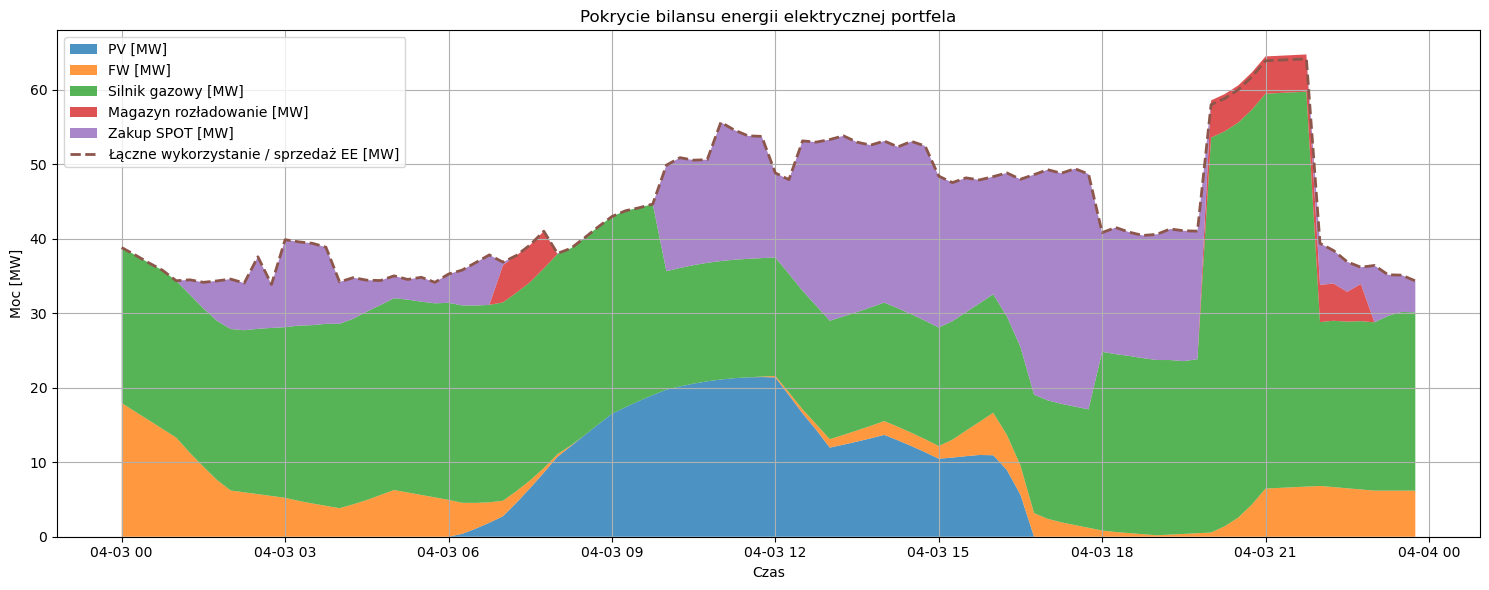

In [127]:
plt.figure(figsize=(15, 6))

plt.stackplot(
    results_plot["timestamp"],
    results_plot["pv_MW"],
    results_plot["wind_MW"],
    results_plot["engine_el_MW"],
    results_plot["battery_discharge_MW"],
    results_plot["market_buy_MW"],
    labels=[
        "PV [MW]",
        "FW [MW]",
        "Silnik gazowy [MW]",
        "Magazyn rozładowanie [MW]",
        "Zakup SPOT [MW]"
    ],
    alpha=0.8
)

plt.plot(
    results_plot["timestamp"],
    results_plot["ee_load_MW"]
    + results_plot["boiler_el_MW"]
    + results_plot["battery_charge_MW"]
    + results_plot["rtt_ee_sell_MW"]
    + results_plot["market_sell_MW"],
    label="Łączne wykorzystanie / sprzedaż EE [MW]",
    linewidth=2,
    linestyle="--"
)

plt.title("Pokrycie bilansu energii elektrycznej portfela")
plt.xlabel("Czas")
plt.ylabel("Moc [MW]")
plt.legend(loc="upper left")
plt.grid(True)
show_intermediate_plot()


## WYKRES: PRODUKCJA CIEPŁA, WYKORZYSTANIE I ZRZUT


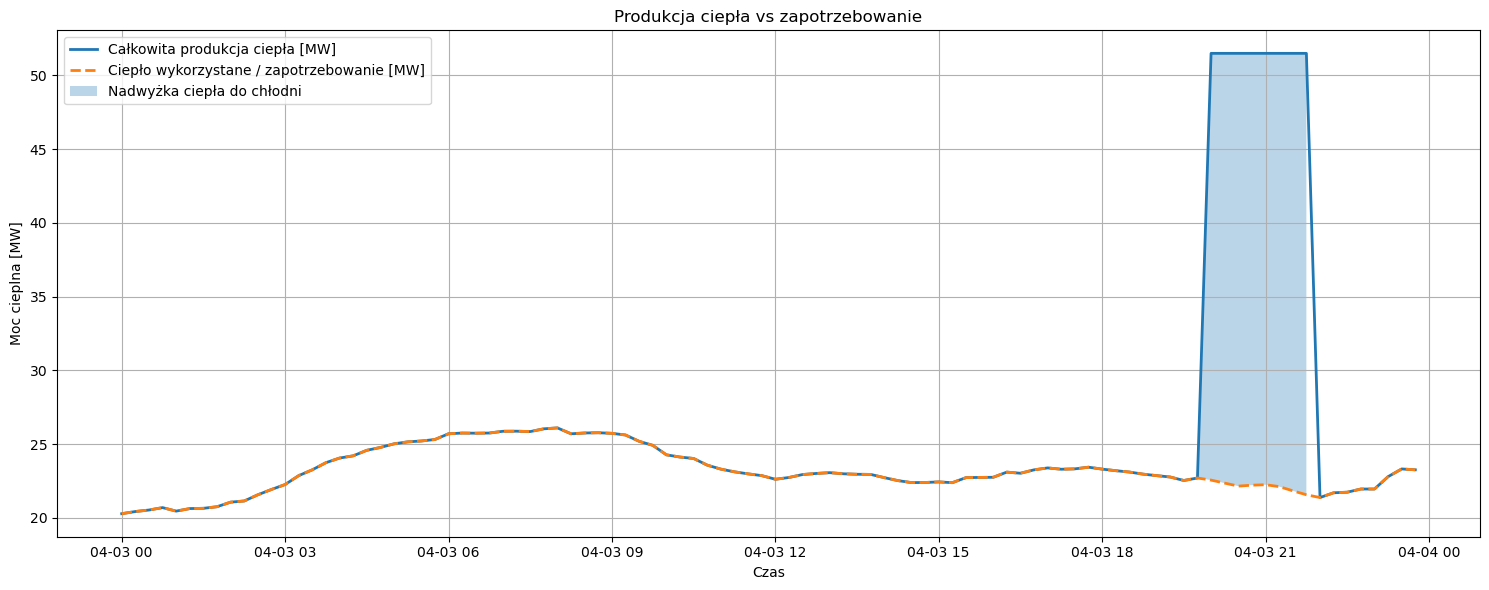

In [129]:
results["total_heat_production_MW"] = (
    results["engine_heat_MW"] + results["boiler_heat_MW"]
)

results["heat_used_MW"] = results["heat_demand_MWh"] / dt_h

plt.figure(figsize=(15, 6))

plt.plot(
    results["timestamp"],
    results["total_heat_production_MW"],
    label="Całkowita produkcja ciepła [MW]",
    linewidth=2
)

plt.plot(
    results["timestamp"],
    results["heat_used_MW"],
    label="Ciepło wykorzystane / zapotrzebowanie [MW]",
    linewidth=2,
    linestyle="--"
)

plt.fill_between(
    results["timestamp"],
    results["heat_used_MW"],
    results["total_heat_production_MW"],
    where=results["total_heat_production_MW"] >= results["heat_used_MW"],
    alpha=0.3,
    label="Nadwyżka ciepła do chłodni"
)

plt.title("Produkcja ciepła vs zapotrzebowanie")
plt.xlabel("Czas")
plt.ylabel("Moc cieplna [MW]")
plt.legend()
plt.grid(True)
show_intermediate_plot()


## 22. STACK: POKRYCIE ZAPOTRZEBOWANIA NA CIEPŁO


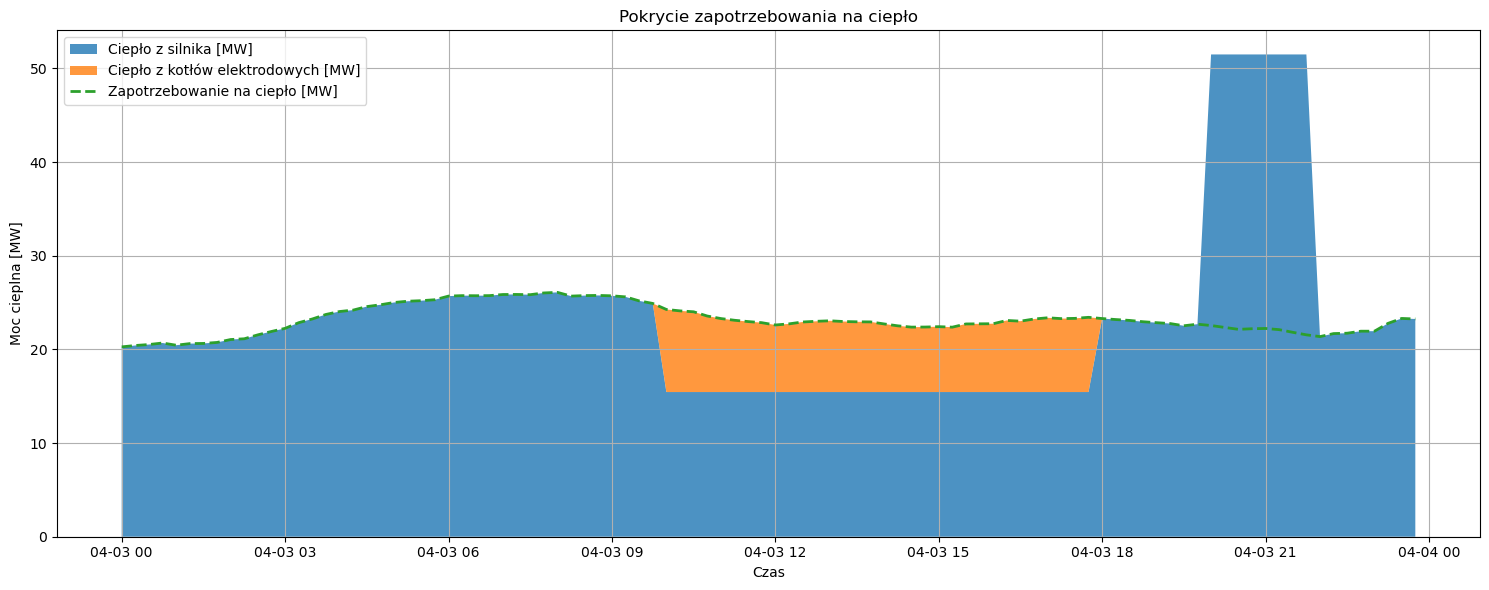

In [131]:
plt.figure(figsize=(15, 6))

plt.stackplot(
    results_plot["timestamp"],
    results_plot["engine_heat_MW"],
    results_plot["boiler_heat_MW"],
    labels=[
        "Ciepło z silnika [MW]",
        "Ciepło z kotłów elektrodowych [MW]"
    ],
    alpha=0.8
)

plt.plot(
    results_plot["timestamp"],
    results_plot["heat_demand_MWh"] / dt_h,
    label="Zapotrzebowanie na ciepło [MW]",
    linewidth=2,
    linestyle="--"
)

plt.title("Pokrycie zapotrzebowania na ciepło")
plt.xlabel("Czas")
plt.ylabel("Moc cieplna [MW]")
plt.legend(loc="upper left")
plt.grid(True)
show_intermediate_plot()


## 23. PRACA SILNIKA VS CENA SPOT


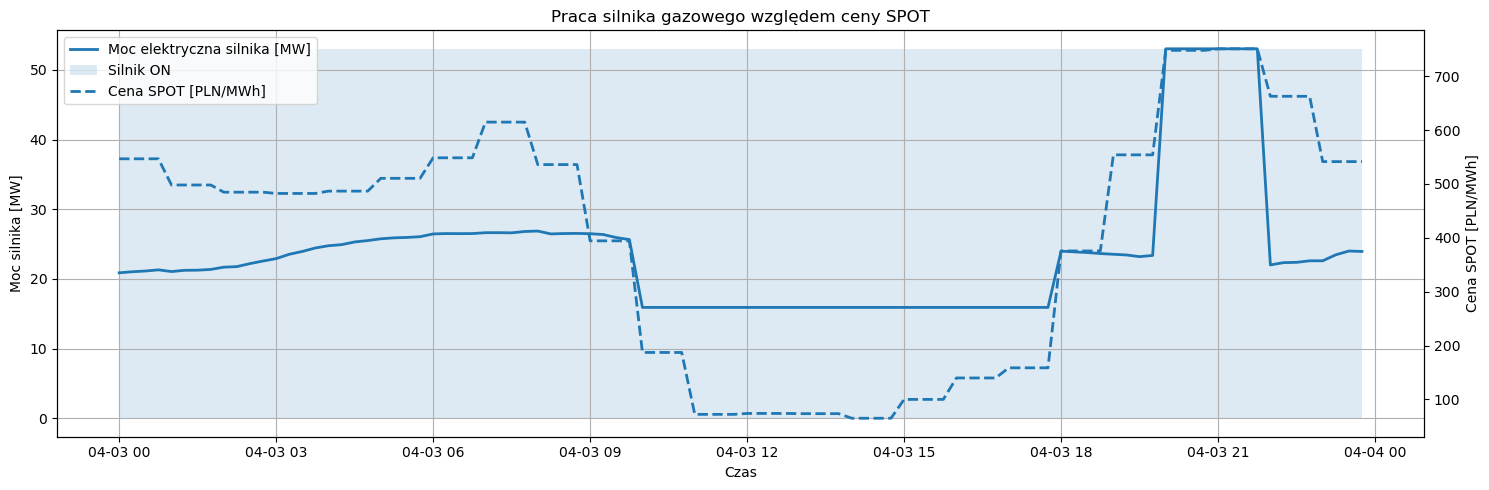

In [133]:
fig, ax1 = plt.subplots(figsize=(15, 5))

ax1.plot(
    results_plot["timestamp"],
    results_plot["engine_el_MW"],
    label="Moc elektryczna silnika [MW]",
    linewidth=2
)

ax1.fill_between(
    results_plot["timestamp"],
    0,
    results_plot["engine_on"] * engine_p_el_max,
    alpha=0.15,
    label="Silnik ON"
)

ax1.set_xlabel("Czas")
ax1.set_ylabel("Moc silnika [MW]")
ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(
    results_plot["timestamp"],
    results_plot["spot_price_used"],
    label="Cena SPOT [PLN/MWh]",
    linewidth=2,
    linestyle="--"
)

ax2.set_ylabel("Cena SPOT [PLN/MWh]")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left"
)

plt.title("Praca silnika gazowego względem ceny SPOT")
show_intermediate_plot()


## WYKRES: BILANS GAZU


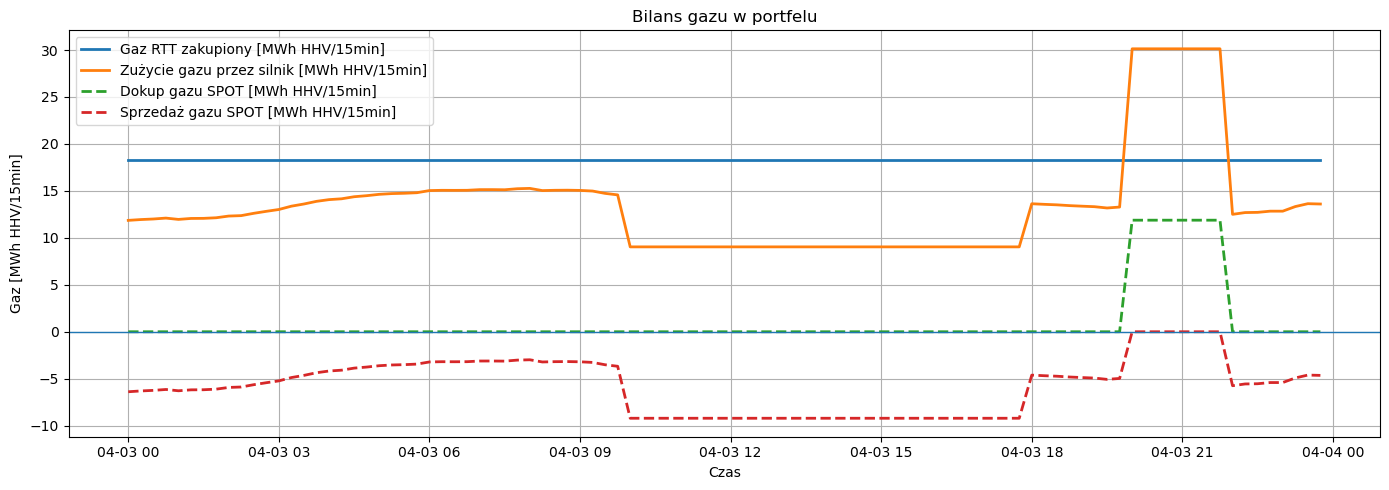

In [135]:
plt.figure(figsize=(14, 5))

plt.plot(
    results["timestamp"],
    results["rtt_gas_buy_MWh_HHV"],
    label="Gaz RTT zakupiony [MWh HHV/15min]",
    linewidth=2
)

plt.plot(
    results["timestamp"],
    results["engine_gas_MWh"],
    label="Zużycie gazu przez silnik [MWh HHV/15min]",
    linewidth=2
)

plt.plot(
    results["timestamp"],
    results["gas_spot_buy_MWh"],
    label="Dokup gazu SPOT [MWh HHV/15min]",
    linewidth=2,
    linestyle="--"
)

plt.plot(
    results["timestamp"],
    -results["gas_spot_sell_MWh"],
    label="Sprzedaż gazu SPOT [MWh HHV/15min]",
    linewidth=2,
    linestyle="--"
)

plt.axhline(0, linewidth=1)

plt.title("Bilans gazu w portfelu")
plt.xlabel("Czas")
plt.ylabel("Gaz [MWh HHV/15min]")
plt.legend()
plt.grid(True)
show_intermediate_plot()


## 24. POZYCJA NETTO PORTFELA PRZED I PO DISPATCHU


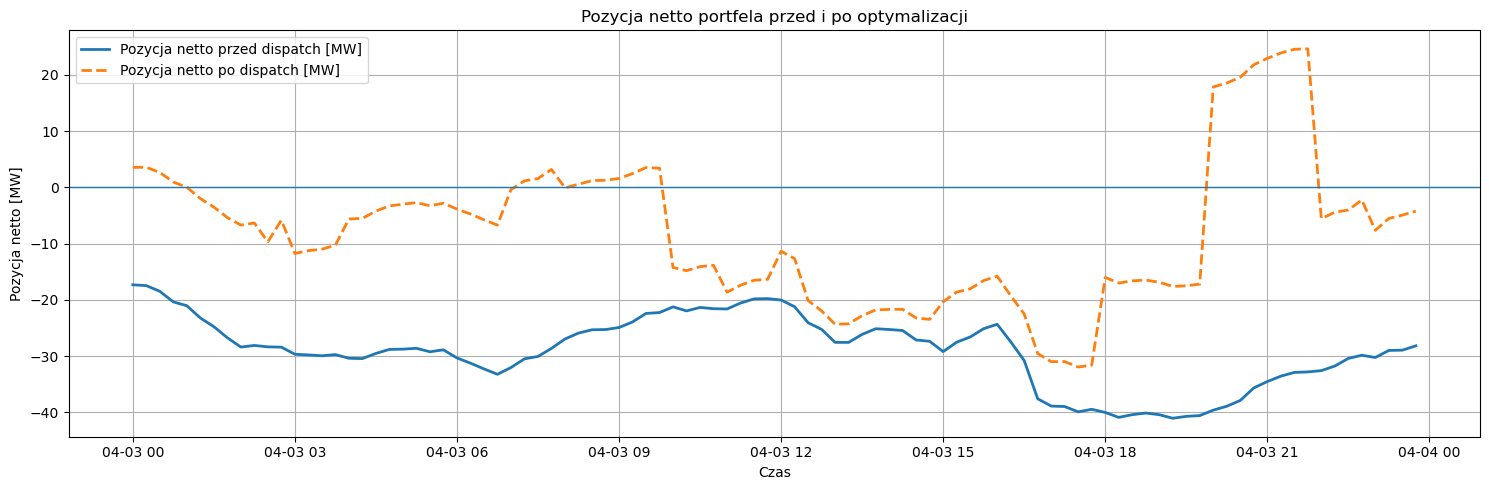

In [137]:
plt.figure(figsize=(15, 5))

plt.plot(
    results_plot["timestamp"],
    results_plot["net_position_before_dispatch_MW"],
    label="Pozycja netto przed dispatch [MW]",
    linewidth=2
)

plt.plot(
    results_plot["timestamp"],
    results_plot["net_position_after_dispatch_MW"],
    label="Pozycja netto po dispatch [MW]",
    linewidth=2,
    linestyle="--"
)

plt.axhline(0, linewidth=1)

plt.title("Pozycja netto portfela przed i po optymalizacji")
plt.xlabel("Czas")
plt.ylabel("Pozycja netto [MW]")
plt.legend()
plt.grid(True)
show_intermediate_plot()


## 25. MAGAZYN ENERGII — PRACA I SOC


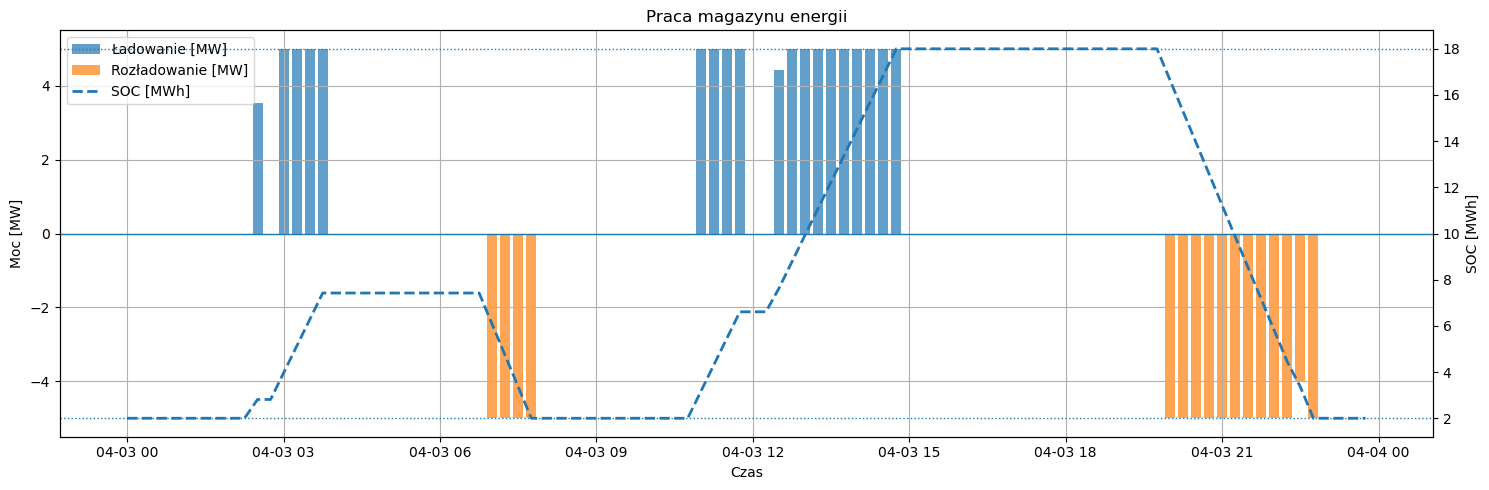

In [139]:
fig, ax1 = plt.subplots(figsize=(15, 5))

ax1.bar(
    results_plot["timestamp"],
    results_plot["battery_charge_MW"],
    width=0.008,
    label="Ładowanie [MW]",
    alpha=0.7
)

ax1.bar(
    results_plot["timestamp"],
    -results_plot["battery_discharge_MW"],
    width=0.008,
    label="Rozładowanie [MW]",
    alpha=0.7
)

ax1.axhline(0, linewidth=1)
ax1.set_xlabel("Czas")
ax1.set_ylabel("Moc [MW]")
ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(
    results_plot["timestamp"],
    results_plot["battery_soc_MWh"],
    label="SOC [MWh]",
    linewidth=2,
    linestyle="--"
)

ax2.axhline(battery_soc_min, linewidth=1, linestyle=":")
ax2.axhline(battery_soc_max, linewidth=1, linestyle=":")

ax2.set_ylabel("SOC [MWh]")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left"
)

plt.title("Praca magazynu energii")
show_intermediate_plot()


## 26. STRUKTURA KOSZTÓW PORTFELA


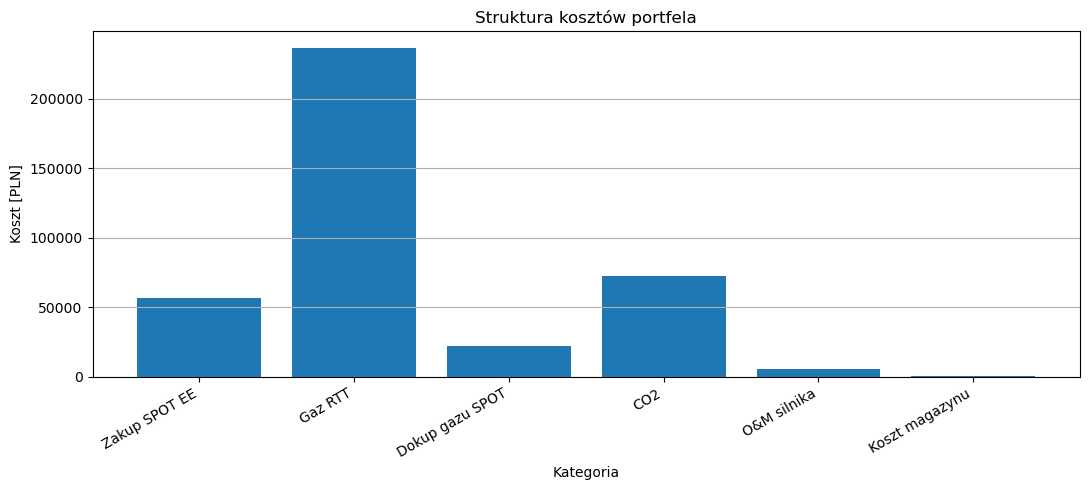

,kategoria,wartosc_PLN
0,Zakup SPOT EE,56544.857982
1,Gaz RTT,236484.960000
2,Dokup gazu SPOT,22204.519431
3,CO2,72415.716449
4,O&M silnika,5713.581285
5,Koszt magazynu,214.940303


In [141]:
cost_summary = pd.DataFrame({
    "kategoria": [
        "Zakup SPOT EE",
        "Gaz RTT",
        "Dokup gazu SPOT",
        "CO2",
        "O&M silnika",
        "Koszt magazynu"
    ],
    "wartosc_PLN": [
        results_plot["spot_purchase_cost_PLN"].sum(),
        results_plot["rtt_gas_cost_PLN"].sum(),
        results_plot["gas_spot_buy_cost_PLN"].sum(),
        results_plot["co2_cost_PLN"].sum(),
        results_plot["engine_om_cost_PLN"].sum(),
        results_plot["battery_cost_PLN"].sum()
    ]
})

plt.figure(figsize=(11, 5))
plt.bar(cost_summary["kategoria"], cost_summary["wartosc_PLN"])
plt.title("Struktura kosztów portfela")
plt.xlabel("Kategoria")
plt.ylabel("Koszt [PLN]")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
show_intermediate_plot()

cost_summary


## 27. STRUKTURA PRZYCHODÓW PORTFELA


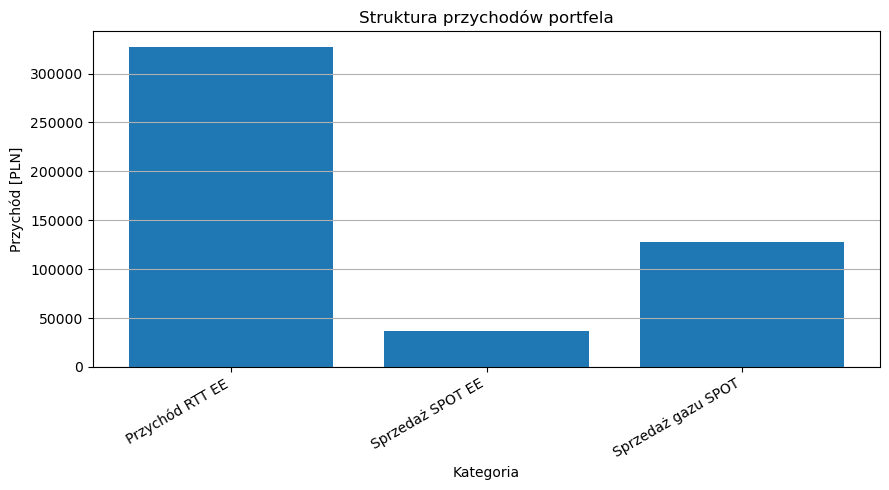

,kategoria,wartosc_PLN
0,Przychód RTT EE,326822.400000
1,Sprzedaż SPOT EE,36404.137612
2,Sprzedaż gazu SPOT,127856.470292


In [143]:
revenue_summary = pd.DataFrame({
    "kategoria": [
        "Przychód RTT EE",
        "Sprzedaż SPOT EE",
        "Sprzedaż gazu SPOT"
    ],
    "wartosc_PLN": [
        results_plot["rtt_ee_revenue_PLN"].sum(),
        results_plot["spot_revenue_PLN"].sum(),
        results_plot["gas_spot_sell_revenue_PLN"].sum()
    ]
})

plt.figure(figsize=(9, 5))
plt.bar(revenue_summary["kategoria"], revenue_summary["wartosc_PLN"])
plt.title("Struktura przychodów portfela")
plt.xlabel("Kategoria")
plt.ylabel("Przychód [PLN]")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
show_intermediate_plot()

revenue_summary


## WYKRES: BILANS GAZU I CENA GAZU SPOT


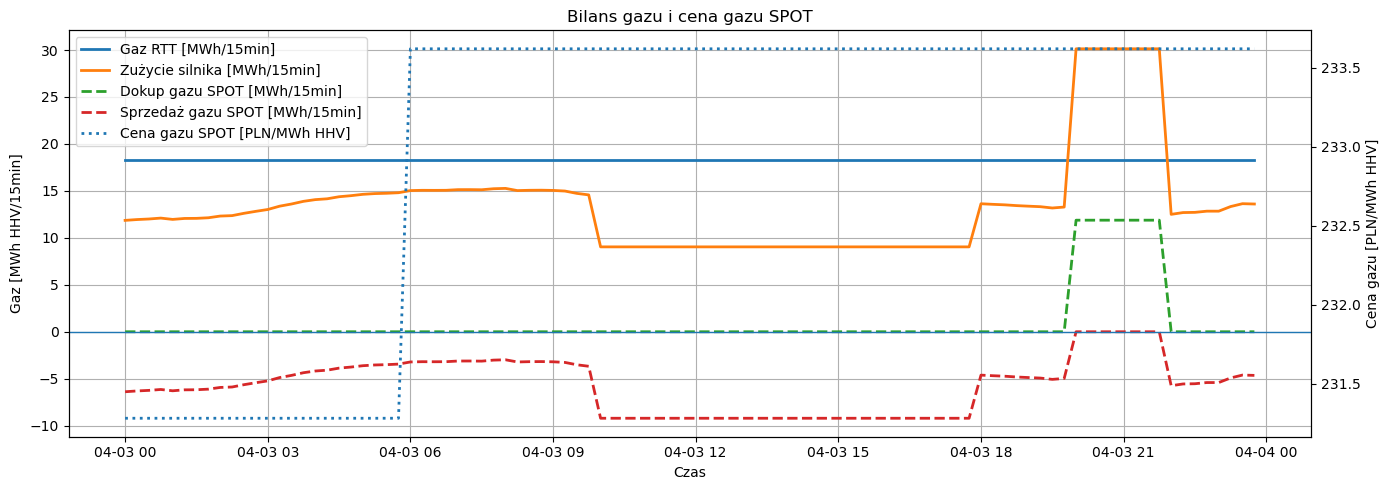

In [145]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(results["timestamp"], results["rtt_gas_buy_MWh_HHV"], label="Gaz RTT [MWh/15min]", linewidth=2)
ax1.plot(results["timestamp"], results["engine_gas_MWh"], label="Zużycie silnika [MWh/15min]", linewidth=2)
ax1.plot(results["timestamp"], results["gas_spot_buy_MWh"], label="Dokup gazu SPOT [MWh/15min]", linewidth=2, linestyle="--")
ax1.plot(results["timestamp"], -results["gas_spot_sell_MWh"], label="Sprzedaż gazu SPOT [MWh/15min]", linewidth=2, linestyle="--")

ax1.axhline(0, linewidth=1)
ax1.set_xlabel("Czas")
ax1.set_ylabel("Gaz [MWh HHV/15min]")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(results["timestamp"], results["gas_spot_price"], label="Cena gazu SPOT [PLN/MWh HHV]", linewidth=2, linestyle=":")
ax2.set_ylabel("Cena gazu [PLN/MWh HHV]")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.title("Bilans gazu i cena gazu SPOT")
show_intermediate_plot()


## 28. MARŻA PORTFELA W CZASIE


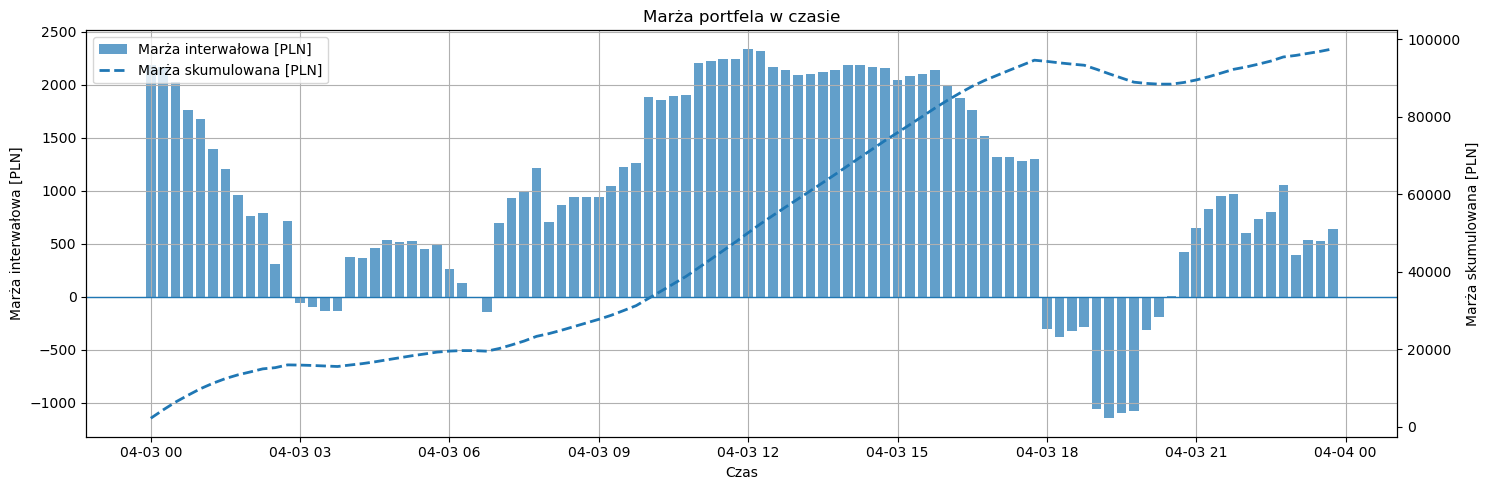

In [147]:
fig, ax1 = plt.subplots(figsize=(15, 5))

ax1.bar(
    results_plot["timestamp"],
    results_plot["portfolio_margin_PLN"],
    width=0.008,
    label="Marża interwałowa [PLN]",
    alpha=0.7
)

ax1.axhline(0, linewidth=1)
ax1.set_xlabel("Czas")
ax1.set_ylabel("Marża interwałowa [PLN]")
ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(
    results_plot["timestamp"],
    results_plot["cumulative_margin_PLN"],
    label="Marża skumulowana [PLN]",
    linewidth=2,
    linestyle="--"
)

ax2.set_ylabel("Marża skumulowana [PLN]")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left"
)

plt.title("Marża portfela w czasie")
show_intermediate_plot()


## 29. SPARK SPREAD VS PRACA SILNIKA


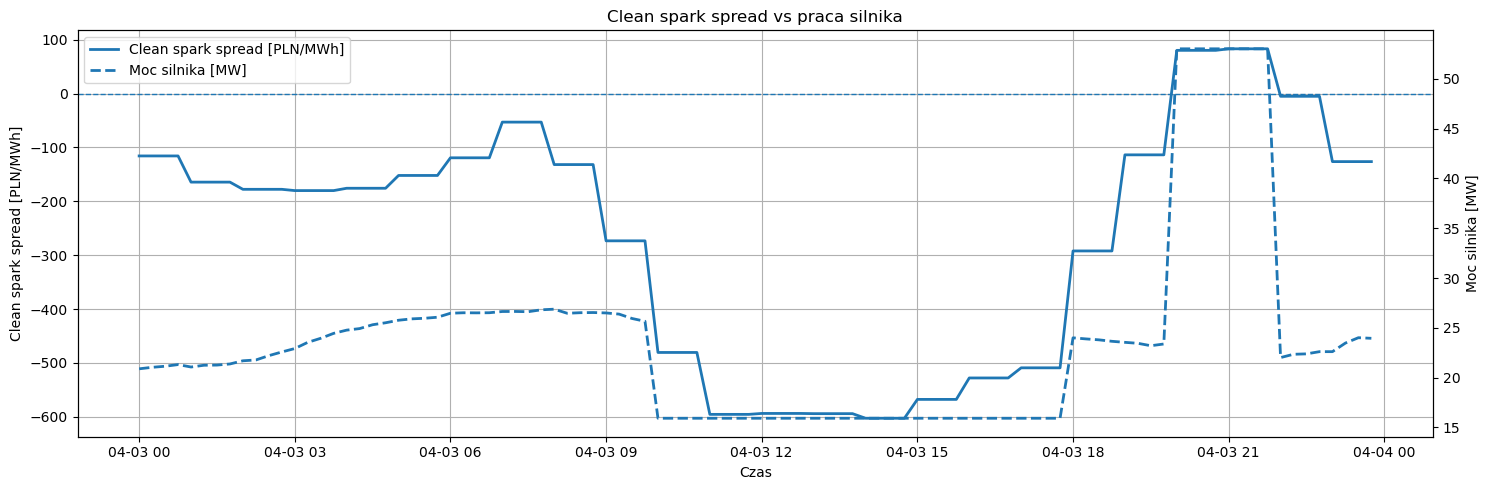

In [149]:
# Uproszczony koszt zmienny produkcji 1 MWh EE z silnika
results_plot["engine_variable_cost_PLN_MWh"] = (
    results_plot["gas_spot_price"] / engine_eta_el
    + results_plot["co2_price"] * emission_factor / engine_eta_el
    + engine_variable_om_PLN_MWh_el
)

results_plot["clean_spark_spread_PLN_MWh"] = (
    results_plot["spot_price_used"]
    - results_plot["engine_variable_cost_PLN_MWh"]
)

fig, ax1 = plt.subplots(figsize=(15, 5))

ax1.plot(
    results_plot["timestamp"],
    results_plot["clean_spark_spread_PLN_MWh"],
    label="Clean spark spread [PLN/MWh]",
    linewidth=2
)

ax1.axhline(0, linewidth=1, linestyle="--")
ax1.set_xlabel("Czas")
ax1.set_ylabel("Clean spark spread [PLN/MWh]")
ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(
    results_plot["timestamp"],
    results_plot["engine_el_MW"],
    label="Moc silnika [MW]",
    linewidth=2,
    linestyle="--"
)

ax2.set_ylabel("Moc silnika [MW]")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left"
)

plt.title("Clean spark spread vs praca silnika")
show_intermediate_plot()


## WYKRES: DECYZJA PORTFELOWA — SILNIK VS SPRZEDAŻ GAZU


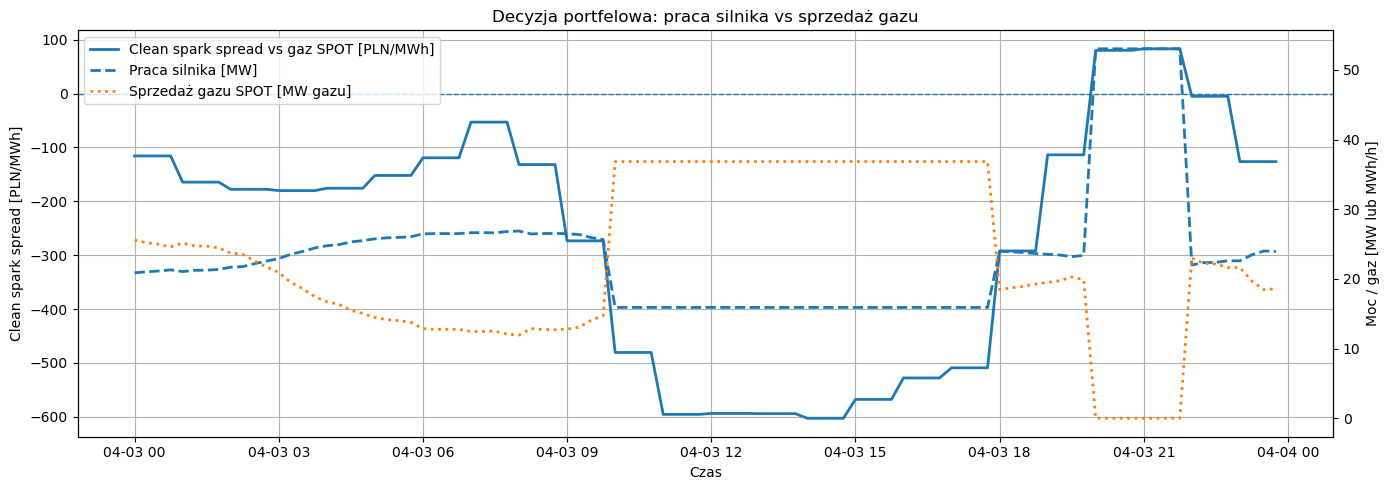

In [151]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(
    results_plot["timestamp"],
    results_plot["clean_spark_spread_PLN_MWh"],
    label="Clean spark spread vs gaz SPOT [PLN/MWh]",
    linewidth=2
)

ax1.axhline(0, linewidth=1, linestyle="--")
ax1.set_xlabel("Czas")
ax1.set_ylabel("Clean spark spread [PLN/MWh]")
ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(
    results_plot["timestamp"],
    results_plot["engine_el_MW"],
    label="Praca silnika [MW]",
    linewidth=2,
    linestyle="--"
)

ax2.plot(
    results_plot["timestamp"],
    results_plot["gas_spot_sell_MWh"] / dt_h,
    label="Sprzedaż gazu SPOT [MW gazu]",
    linewidth=2,
    linestyle=":"
)

ax2.set_ylabel("Moc / gaz [MW lub MWh/h]")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.title("Decyzja portfelowa: praca silnika vs sprzedaż gazu")
show_intermediate_plot()


## PARAMETRY REDISPATCH — GAZ I KOTŁY


In [153]:
gas_imbalance_buy_markup = 0.10
gas_imbalance_sell_discount = 0.10

boiler_redispatch_enabled = True

## 31A. RZECZYWISTA POGODA DLA OZE — OPEN-METEO ARCHIVE


In [155]:
def download_actual_weather_oze_open_meteo(
    lat,
    lon,
    start_date,
    end_date,
    timezone="Europe/Warsaw"
):
    """
    Pobiera rzeczywistą pogodę historyczną dla modelu PV i FW.
    Zakres zmiennych jest zgodny z tym, czego używaliśmy w forecast OZE.
    """

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": str(start_date),
        "end_date": str(end_date),
        "hourly": [
            "temperature_2m",
            "wind_speed_10m",
            "shortwave_radiation",
            "direct_normal_irradiance",
            "diffuse_radiation",
            "wind_speed_100m",
            "wind_direction_100m",
            "surface_pressure"
        ],
        "timezone": timezone,
        "wind_speed_unit": "ms"
    }

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()

    data = response.json()["hourly"]
    data = pd.DataFrame(data)

    data = data.rename(columns={
        "time": "timestamp",
        "temperature_2m": "temperature_2m",
        "wind_speed_10m": "wind_speed_10m",
        "shortwave_radiation": "shortwave_radiation",
        "direct_normal_irradiance": "direct_normal_irradiance",
        "diffuse_radiation": "diffuse_radiation",
        "wind_speed_100m": "wind_speed_100m",
        "wind_direction_100m": "wind_direction_100m",
        "surface_pressure": "surface_pressure"
    })

    data["timestamp"] = pd.to_datetime(data["timestamp"])

    return data


## 31B. PRZYGOTOWANIE POGODY OZE DO 15 MIN — POPRAWIONE


In [157]:
def prepare_oze_weather_15min(weather_hourly):
    """
    Przygotowuje pogodę do modelu PV i FW tak samo jak w forecast:
    - rename kolumn,
    - konwersje jednostek,
    - resampling do 15 minut,
    - uzupełnienie końcówki dnia do 23:45.

    Poprawka:
    interpolujemy wyłącznie kolumny numeryczne, żeby Pandas nie próbował
    interpolować kolumn datetime/object.
    """

    weather = weather_hourly.copy()

    # Ustawienie indeksu czasu
    weather["time"] = pd.to_datetime(weather["timestamp"])
    weather = weather.set_index("time")

    # Usuwamy kolumny nienumeryczne, które przeszkadzają w interpolate(method="time")
    weather = weather.drop(
        columns=["timestamp"],
        errors="ignore"
    )

    # Rename zgodny z forecastem
    weather = weather.rename(columns={
        "temperature_2m": "temp_air",
        "wind_speed_10m": "wind_speed",
        "shortwave_radiation": "ghi",
        "direct_normal_irradiance": "dni",
        "diffuse_radiation": "dhi",
        "wind_speed_100m": "wind_speed_100m_ms",
        "wind_direction_100m": "wind_direction_100m_deg",
        "surface_pressure": "pressure_hPa"
    })

    # Wszystko na numeric
    for col in weather.columns:
        weather[col] = pd.to_numeric(weather[col], errors="coerce")

    weather = weather.ffill().bfill()

    # Konwersje jednostek
    weather["temp_air_K"] = weather["temp_air"] + 273.15
    weather["pressure_Pa"] = weather["pressure_hPa"] * 100

    weather.index = pd.to_datetime(weather.index)

    ostatnia_data = weather.index.max().normalize()
    pelny_koniec_dnia = ostatnia_data + pd.Timedelta(hours=23, minutes=45)

    nowy_indeks = weather.index.union([pelny_koniec_dnia])
    weather_extended = weather.reindex(nowy_indeks)

    # Resampling/interpolacja tylko po kolumnach numerycznych
    weather_15min = (
        weather_extended
        .resample("15min")
        .interpolate(method="time")
        .ffill()
        .bfill()
    )

    for col in ["ghi", "dni", "dhi"]:
        if col in weather_15min.columns:
            weather_15min[col] = weather_15min[col].clip(lower=0)

    return weather_15min


## 31C. RZECZYWISTA PRODUKCJA PV — PVLIB, TAK JAK FORECAST


In [159]:
def calculate_actual_pv_same_as_forecast(weather_15min):
    """
    Liczy rzeczywistą produkcję PV tak samo jak forecast:
    pvlib + ModelChain.with_pvwatts.
    Wykorzystuje globalne parametry:
    LATITUDE, LONGITUDE, TIMEZONE, ALTITUDE,
    PV_TILT, PV_AZIMUTH, PV_POWER_KWP.
    """

    weather_pv_actual = pd.DataFrame(index=weather_15min.index)

    weather_pv_actual["ghi"] = weather_15min["ghi"]
    weather_pv_actual["dni"] = weather_15min["dni"]
    weather_pv_actual["dhi"] = weather_15min["dhi"]
    weather_pv_actual["temp_air"] = weather_15min["temp_air"]
    weather_pv_actual["wind_speed"] = weather_15min["wind_speed"]

    location_actual = pvlib.location.Location(
        latitude=LATITUDE,
        longitude=LONGITUDE,
        tz=TIMEZONE,
        altitude=ALTITUDE,
        name="PV actual location"
    )

    temperature_model_parameters = pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS[
        "sapm"
    ]["open_rack_glass_glass"]

    pv_system_actual = pvlib.pvsystem.PVSystem(
        surface_tilt=PV_TILT,
        surface_azimuth=PV_AZIMUTH,
        module_parameters={
            "pdc0": PV_POWER_KWP,
            "gamma_pdc": -0.004
        },
        inverter_parameters={
            "pdc0": PV_POWER_KWP
        },
        temperature_model_parameters=temperature_model_parameters
    )

    pv_model_actual = pvlib.modelchain.ModelChain.with_pvwatts(
        system=pv_system_actual,
        location=location_actual,
        aoi_model="physical",
        spectral_model="no_loss"
    )

    pv_model_actual.run_model(weather_pv_actual)

    pv_power_ac_kW_actual = pv_model_actual.results.ac.clip(lower=0)
    pv_energy_kWh_15min_actual = pv_power_ac_kW_actual * 0.25

    pv_actual = pd.DataFrame(index=weather_15min.index)
    pv_actual["timestamp"] = weather_15min.index
    pv_actual["pv_actual_power_MW"] = pv_power_ac_kW_actual / 1000
    pv_actual["pv_actual_MWh"] = pv_energy_kWh_15min_actual / 1000
    pv_actual["pv_actual_profile_pu"] = pv_power_ac_kW_actual / PV_POWER_KWP

    return pv_actual.reset_index(drop=True)


## 31D. RZECZYWISTA PRODUKCJA FW — WINDPOWERLIB, TAK JAK FORECAST


In [161]:
def calculate_actual_wind_same_as_forecast(weather_15min):
    """
    Liczy rzeczywistą produkcję FW tak samo jak forecast:
    windpowerlib + ModelChain + krzywa mocy turbiny.
    Wykorzystuje globalne parametry:
    TURBINE_POWER_MW, HUB_HEIGHT, N_TURBINES,
    LOSS_FACTOR, WIND_FARM_POWER_MW, ROUGHNESS_LENGTH, power_curve.
    """

    weather_wpl_actual = pd.DataFrame(index=weather_15min.index)

    weather_wpl_actual[("wind_speed", 10)] = weather_15min["wind_speed"]
    weather_wpl_actual[("wind_speed", 100)] = weather_15min["wind_speed_100m_ms"]

    weather_wpl_actual[("temperature", 2)] = weather_15min["temp_air_K"]
    weather_wpl_actual[("pressure", 0)] = weather_15min["pressure_Pa"]
    weather_wpl_actual[("roughness_length", 0)] = ROUGHNESS_LENGTH

    weather_wpl_actual.columns = pd.MultiIndex.from_tuples(weather_wpl_actual.columns)

    wind_turbine_actual = WindTurbine(
        nominal_power=TURBINE_POWER_MW * 1_000_000,
        hub_height=HUB_HEIGHT,
        power_curve=power_curve
    )

    wind_model_actual = ModelChain(
        wind_turbine_actual,
        wind_speed_model="logarithmic",
        density_model="ideal_gas",
        temperature_model="linear_gradient",
        power_output_model="power_curve",
        density_correction=True
    )

    wind_model_actual.run_model(weather_wpl_actual)

    turbine_power_W_actual = wind_model_actual.power_output
    turbine_power_MW_actual = turbine_power_W_actual / 1_000_000

    wind_farm_power_MW_gross_actual = turbine_power_MW_actual * N_TURBINES
    wind_farm_power_MW_net_actual = wind_farm_power_MW_gross_actual * LOSS_FACTOR

    wind_farm_power_MW_net_actual = wind_farm_power_MW_net_actual.clip(
        lower=0,
        upper=WIND_FARM_POWER_MW
    )

    wind_actual = pd.DataFrame(index=weather_15min.index)
    wind_actual["timestamp"] = weather_15min.index
    wind_actual["wind_actual_power_MW"] = wind_farm_power_MW_net_actual
    wind_actual["wind_actual_MWh"] = wind_farm_power_MW_net_actual * 0.25
    wind_actual["wind_actual_profile_pu"] = (
        wind_farm_power_MW_net_actual / WIND_FARM_POWER_MW
    )

    return wind_actual.reset_index(drop=True)


## 31E. RZECZYWISTE ZAPOTRZEBOWANIE NA CIEPŁO


In [163]:
def attach_actual_heat_demand(actual_df):
    """
    Dołącza rzeczywiste zapotrzebowanie na ciepło.
    Preferowane źródło: heat_plan_15min, gdzie mamy actual_heat_MW_2024.
    """

    out = actual_df.copy()

    if "heat_plan_15min" not in globals():
        raise ValueError(
            "Brakuje heat_plan_15min. "
            "Najpierw uruchom blok prognozy ciepła, który zawiera actual_heat_MW_2024."
        )

    required_cols = [
        "timestamp",
        "actual_heat_MW_2024",
        "actual_heat_MWh_15min_2024"
    ]

    missing_cols = [
        col for col in required_cols
        if col not in heat_plan_15min.columns
    ]

    if missing_cols:
        raise ValueError(
            f"heat_plan_15min nie ma kolumn rzeczywistego ciepła: {missing_cols}"
        )

    heat_actual = heat_plan_15min[required_cols].copy()

    heat_actual = heat_actual.rename(columns={
        "actual_heat_MW_2024": "heat_demand_actual_MW",
        "actual_heat_MWh_15min_2024": "heat_demand_actual_MWh"
    })

    out["timestamp"] = pd.to_datetime(out["timestamp"])
    heat_actual["timestamp"] = pd.to_datetime(heat_actual["timestamp"])

    out = out.drop(
        columns=[
            col for col in ["heat_demand_actual_MW", "heat_demand_actual_MWh"]
            if col in out.columns
        ],
        errors="ignore"
    )

    out = out.merge(
        heat_actual,
        on="timestamp",
        how="left"
    )

    if out[["heat_demand_actual_MW", "heat_demand_actual_MWh"]].isna().any().any():
        print(out[["timestamp", "heat_demand_actual_MW", "heat_demand_actual_MWh"]].head())
        raise ValueError("Nie udało się poprawnie dołączyć rzeczywistego ciepła.")

    return out


## 31F. RZECZYWISTY PROFIL ODBIORCY EE — BŁĄD WZGLĘDEM PLANU


In [165]:
def simulate_actual_industrial_load_from_forecast_error(
    df,
    seed=456,
    random_error_std=0.015,
    block_error_std=0.030,
    block_size=8,
    min_error=-0.10,
    max_error=0.10
):
    """
    Tworzy rzeczywisty profil odbiorcy przemysłowego.
    Zakładamy, że odbiorca podał plan D-1, ale wykonanie odchyla się od planu.
    block_size=8 oznacza błąd blokowy 2h przy interwale 15-min.
    """

    out = df.copy()

    np.random.seed(seed)

    random_error = np.random.normal(0, random_error_std, len(out))

    n_blocks = int(np.ceil(len(out) / block_size))
    block_errors = np.random.normal(0, block_error_std, n_blocks)
    block_error_series = np.repeat(block_errors, block_size)[:len(out)]

    total_error = random_error + block_error_series
    total_error = np.clip(total_error, min_error, max_error)

    out["load_error_pct"] = total_error

    out["ee_load_actual_MWh"] = (
        out["ee_load_MWh"] * (1 + total_error)
    ).clip(lower=0)

    out["ee_load_actual_MW"] = out["ee_load_actual_MWh"] / 0.25

    return out


## 31. RZECZYWISTE WYKONANIE DNIA DOSTAWY — FINALNA WERSJA


In [167]:
actual = results.copy()

actual["timestamp"] = pd.to_datetime(actual["timestamp"])
delivery_day = actual["timestamp"].dt.date.min()

# 1. Rzeczywista pogoda dla OZE.
# Używamy tej samej lokalizacji i parametrów co w forecast.
weather_actual_hourly = download_actual_weather_oze_open_meteo(
    lat=LATITUDE,
    lon=LONGITUDE,
    start_date=delivery_day,
    end_date=delivery_day,
    timezone=TIMEZONE
)

weather_actual_15min = prepare_oze_weather_15min(weather_actual_hourly)

# Ograniczamy do dokładnego zakresu z results
weather_actual_15min = weather_actual_15min[
    (weather_actual_15min.index >= actual["timestamp"].min())
    & (weather_actual_15min.index <= actual["timestamp"].max())
].copy()

if len(weather_actual_15min) != len(actual):
    raise ValueError(
        f"Pogoda actual ma {len(weather_actual_15min)} wierszy, "
        f"a results ma {len(actual)}. Sprawdź zakres dat."
    )

# 2. Actual PV — ta sama metoda co forecast
pv_actual = calculate_actual_pv_same_as_forecast(weather_actual_15min)

# 3. Actual FW — ta sama metoda co forecast
wind_actual = calculate_actual_wind_same_as_forecast(weather_actual_15min)

# 4. Dołączenie actual PV/FW
actual = actual.merge(
    pv_actual[["timestamp", "pv_actual_power_MW", "pv_actual_MWh"]],
    on="timestamp",
    how="left"
)

actual = actual.merge(
    wind_actual[["timestamp", "wind_actual_power_MW", "wind_actual_MWh"]],
    on="timestamp",
    how="left"
)

# 5. Rzeczywiste ciepło — znane z profilu rzeczywistego / analogowego
actual = attach_actual_heat_demand(actual)

# 6. Rzeczywisty odbiorca przemysłowy — błąd wykonania względem planu
actual = simulate_actual_industrial_load_from_forecast_error(actual)

# 7. Kontrola
required_actual_cols = [
    "pv_actual_MWh",
    "wind_actual_MWh",
    "heat_demand_actual_MWh",
    "ee_load_actual_MWh"
]

if actual[required_actual_cols].isna().any().any():
    print(actual[required_actual_cols].isna().sum())
    raise ValueError("Są braki w actual profiles.")

print("Rzeczywiste wykonanie dnia dostawy gotowe.")
print("PV forecast MWh:", round(actual["pv_MWh"].sum(), 2))
print("PV actual MWh:", round(actual["pv_actual_MWh"].sum(), 2))
print("FW forecast MWh:", round(actual["wind_MWh"].sum(), 2))
print("FW actual MWh:", round(actual["wind_actual_MWh"].sum(), 2))
print("Heat forecast MWh:", round(actual["heat_demand_MWh"].sum(), 2))
print("Heat actual MWh:", round(actual["heat_demand_actual_MWh"].sum(), 2))
print("Load forecast MWh:", round(actual["ee_load_MWh"].sum(), 2))
print("Load actual MWh:", round(actual["ee_load_actual_MWh"].sum(), 2))

actual[
    [
        "timestamp",
        "pv_MWh",
        "pv_actual_MWh",
        "wind_MWh",
        "wind_actual_MWh",
        "heat_demand_MWh",
        "heat_demand_actual_MWh",
        "ee_load_MWh",
        "ee_load_actual_MWh"
    ]
].head()


Rzeczywiste wykonanie dnia dostawy gotowe.
PV forecast MWh: 138.86
PV actual MWh: 130.99
FW forecast MWh: 88.18
FW actual MWh: 95.0
Heat forecast MWh: 556.83
Heat actual MWh: 551.56
Load forecast MWh: 204.08
Load actual MWh: 204.23


,timestamp,pv_MWh,pv_actual_MWh,wind_MWh,wind_actual_MWh,heat_demand_MWh,heat_demand_actual_MWh,ee_load_MWh,ee_load_actual_MWh
0,2026-04-03 00:00:00,0.0,0.0,4.487792,1.751352,5.068370,4.884827,1.317705,1.307786
1,2026-04-03 00:15:00,0.0,0.0,4.198296,1.818554,5.105167,4.898453,1.064361,1.059062
2,2026-04-03 00:30:00,0.0,0.0,3.908632,1.885776,5.130767,4.912080,1.028203,1.040308
3,2026-04-03 00:45:00,0.0,0.0,3.618810,1.953020,5.171702,4.925707,1.209112,1.222442
4,2026-04-03 01:00:00,0.0,0.0,3.328830,2.033641,5.112300,4.939333,1.088466,1.113231


## 32. NIEZBILANSOWANIE PRZED REDISPATCH


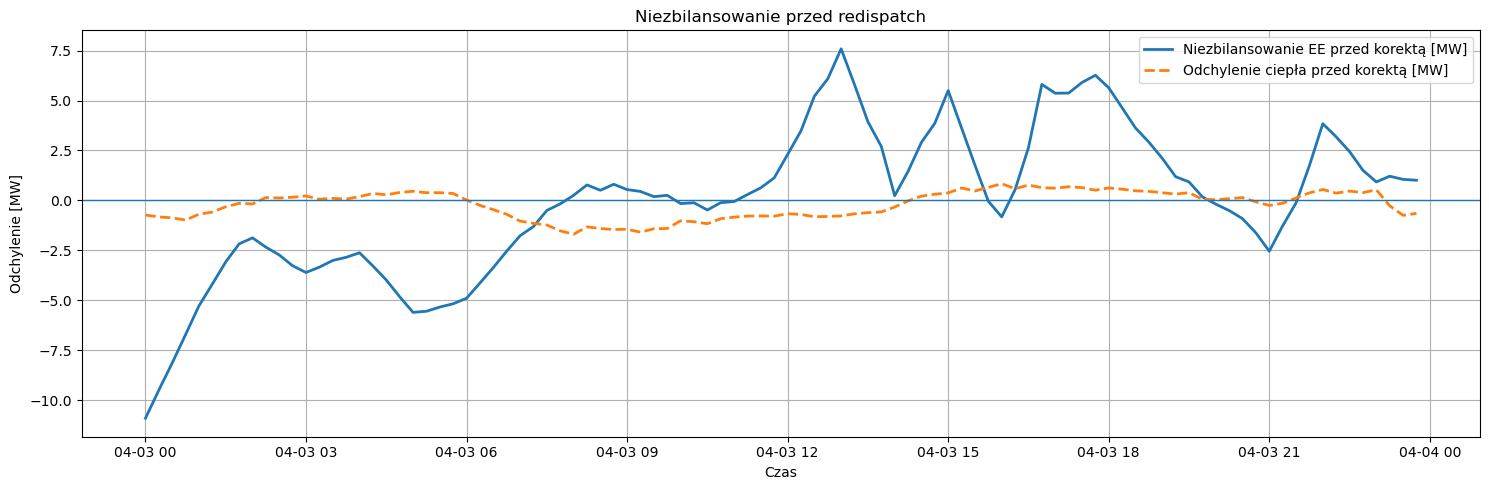

In [169]:
imbalance = actual.copy()

# Odchylenia od planu
imbalance["delta_pv_MWh"] = (
    imbalance["pv_actual_MWh"] - imbalance["pv_MWh"]
)

imbalance["delta_wind_MWh"] = (
    imbalance["wind_actual_MWh"] - imbalance["wind_MWh"]
)

imbalance["delta_load_MWh"] = (
    imbalance["ee_load_actual_MWh"] - imbalance["ee_load_MWh"]
)

imbalance["delta_heat_MWh"] = (
    imbalance["heat_demand_actual_MWh"] - imbalance["heat_demand_MWh"]
)

# Niezbilansowanie EE przed korektą:
# dodatnie = nadwyżka energii
# ujemne = niedobór energii
imbalance["ee_imbalance_before_MWh"] = (
    imbalance["delta_pv_MWh"]
    + imbalance["delta_wind_MWh"]
    - imbalance["delta_load_MWh"]
)

imbalance["ee_imbalance_before_MW"] = (
    imbalance["ee_imbalance_before_MWh"] / dt_h
)

# Niezbilansowanie ciepła:
# dodatnie = większy pobór ciepła niż plan
# ujemne = mniejszy pobór ciepła niż plan
imbalance["heat_imbalance_before_MWh"] = imbalance["delta_heat_MWh"]
imbalance["heat_imbalance_before_MW"] = imbalance["delta_heat_MWh"] / dt_h

summary_imbalance_before = pd.DataFrame([{
    "ee_imbalance_abs_MWh_before": imbalance["ee_imbalance_before_MWh"].abs().sum(),
    "ee_imbalance_sum_MWh_before": imbalance["ee_imbalance_before_MWh"].sum(),
    "ee_imbalance_max_surplus_MW": imbalance["ee_imbalance_before_MW"].max(),
    "ee_imbalance_max_shortage_MW": imbalance["ee_imbalance_before_MW"].min(),

    "heat_imbalance_abs_MWh_before": imbalance["heat_imbalance_before_MWh"].abs().sum(),
    "heat_imbalance_sum_MWh_before": imbalance["heat_imbalance_before_MWh"].sum(),
    "heat_imbalance_max_extra_demand_MW": imbalance["heat_imbalance_before_MW"].max(),
    "heat_imbalance_max_lower_demand_MW": imbalance["heat_imbalance_before_MW"].min(),
}])

maybe_display(summary_imbalance_before)

# Wykres niezbilansowania przed korektą
plt.figure(figsize=(15, 5))

plt.plot(
    imbalance["timestamp"],
    imbalance["ee_imbalance_before_MW"],
    label="Niezbilansowanie EE przed korektą [MW]",
    linewidth=2
)

plt.plot(
    imbalance["timestamp"],
    imbalance["heat_imbalance_before_MW"],
    label="Odchylenie ciepła przed korektą [MW]",
    linewidth=2,
    linestyle="--"
)

plt.axhline(0, linewidth=1)

plt.title("Niezbilansowanie przed redispatch")
plt.xlabel("Czas")
plt.ylabel("Odchylenie [MW]")
plt.legend()
plt.grid(True)
show_intermediate_plot()


## 32A. PROGNOZA CENY NIEZBILANSOWANIA DO DECYZJI REDISPATCH

Ten blok musi być uruchomiony po policzeniu `imbalance`, ale przed utworzeniem `redispatch_df`.


In [171]:
# =========================================================
# PROGNOZA CENY NIEZBILANSOWANIA — DANE POMOCNICZE
# =========================================================
# Prognoza CEN nie wycenia bezpośrednio pozostałego niezbilansowania
# w funkcji celu redispatchu. Jest zachowywana do analiz diagnostycznych
# oraz do pomocniczego skalowania miękkiej kary terminalnego SOC BESS.
#
# Loader obsługuje pliki jedno- i wielodniowe. Z pliku wybierane są
# wyłącznie interwały odpowiadające dacie FORECAST_DATE.

from pathlib import Path
import os

IMBALANCE_PRICE_FORECAST_PATH = "prognoza_cen_niezbilansowania.xlsx"
IMBALANCE_PRICE_FORECAST_SHEET = "ag-grid"
DEFAULT_IMBALANCE_PRICE_FORECAST_PLN_MWh = 1000.0


def _resolve_imbalance_forecast_file(
    preferred_path=IMBALANCE_PRICE_FORECAST_PATH,
    sheet_name=IMBALANCE_PRICE_FORECAST_SHEET,
):
    """Zwraca plik prognozy CEN zawierający dane dla FORECAST_DATE."""
    preferred = Path(preferred_path)
    target_day = pd.Timestamp(FORECAST_DATE).normalize()

    def _contains_target_day(candidate):
        try:
            preview = pd.read_excel(candidate, sheet_name=sheet_name)
            timestamp_col = next(
                (
                    col for col in preview.columns
                    if str(col).strip().lower() in {
                        "timestamp", "czas", "datetime", "data_czas", "data i czas"
                    }
                ),
                None,
            )
            if timestamp_col is None:
                return False

            days = pd.to_datetime(
                preview[timestamp_col], errors="coerce"
            ).dt.normalize()
            return bool((days == target_day).any())
        except Exception:
            return False

    if preferred.exists() and _contains_target_day(preferred):
        return preferred

    candidates = sorted(Path(".").glob("prognoza_cen_niezbilansowania*.xlsx"))
    matching = [
        candidate for candidate in candidates
        if _contains_target_day(candidate)
    ]

    if len(matching) == 1:
        print(f"Automatycznie wybrano plik prognozy CEN: {matching[0]}")
        return matching[0]

    if len(matching) > 1:
        raise ValueError(
            "Znaleziono kilka plików prognozy CEN zawierających FORECAST_DATE. "
            "Ustaw jednoznacznie IMBALANCE_PRICE_FORECAST_PATH. Pliki: "
            + ", ".join(str(path) for path in matching)
        )

    return None


def load_imbalance_price_forecast(
    path=IMBALANCE_PRICE_FORECAST_PATH,
    sheet_name=IMBALANCE_PRICE_FORECAST_SHEET,
):
    """
    Oczekiwane kolumny:
    - timestamp,
    - imbalance_price_forecast_PLN_MWh.

    Plik może obejmować jedną lub wiele dób. Funkcja wybiera dane dla
    FORECAST_DATE i kontroluje kompletność względem osi czasu modelu.
    """
    resolved_path = _resolve_imbalance_forecast_file(path, sheet_name)

    expected_timestamps = pd.DatetimeIndex(
        pd.to_datetime(imbalance["timestamp"], errors="coerce")
        .dt.floor("15min")
        .dropna()
        .drop_duplicates()
        .sort_values()
    )

    if resolved_path is None:
        print(
            f"UWAGA: Nie znaleziono pliku prognozy CEN dla {FORECAST_DATE}. "
            f"Używam stałej wartości "
            f"{DEFAULT_IMBALANCE_PRICE_FORECAST_PLN_MWh} PLN/MWh."
        )
        return pd.DataFrame({
            "timestamp": expected_timestamps,
            "imbalance_price_forecast_PLN_MWh": (
                DEFAULT_IMBALANCE_PRICE_FORECAST_PLN_MWh
            ),
        })

    price_forecast = pd.read_excel(
        resolved_path,
        sheet_name=sheet_name,
    )

    rename_map = {}
    for col in price_forecast.columns:
        normalized = (
            str(col)
            .replace("\n", " ")
            .strip()
            .lower()
        )

        if normalized in {
            "timestamp", "czas", "datetime", "data_czas", "data i czas"
        }:
            rename_map[col] = "timestamp"

        if normalized in {
            "imbalance_price_forecast_pln_mwh",
            "imbalance_price_pln_mwh",
            "cen",
            "cena_niezbilansowania",
            "cena niezbilansowania",
            "cena_niezbilansowania_pln_mwh",
            "cena niezbilansowania pln/mwh",
        }:
            rename_map[col] = "imbalance_price_forecast_PLN_MWh"

    price_forecast = price_forecast.rename(columns=rename_map)

    required_cols = [
        "timestamp",
        "imbalance_price_forecast_PLN_MWh",
    ]
    missing_cols = [
        col for col in required_cols
        if col not in price_forecast.columns
    ]
    if missing_cols:
        raise ValueError(
            "Brakuje kolumn w pliku prognozy CEN: "
            f"{missing_cols}. Dostępne kolumny: "
            f"{price_forecast.columns.tolist()}"
        )

    price_forecast = price_forecast[required_cols].copy()
    price_forecast["timestamp"] = (
        pd.to_datetime(price_forecast["timestamp"], errors="coerce")
        .dt.floor("15min")
    )
    price_forecast["imbalance_price_forecast_PLN_MWh"] = pd.to_numeric(
        price_forecast["imbalance_price_forecast_PLN_MWh"],
        errors="coerce",
    )

    day_start = pd.Timestamp(FORECAST_DATE).normalize()
    day_end = day_start + pd.Timedelta(days=1)
    price_forecast = price_forecast.loc[
        (price_forecast["timestamp"] >= day_start)
        & (price_forecast["timestamp"] < day_end)
    ].copy()

    duplicate_mask = price_forecast["timestamp"].duplicated(keep=False)
    if duplicate_mask.any():
        maybe_display(
            price_forecast.loc[duplicate_mask].sort_values("timestamp")
        )
        raise ValueError(
            "W prognozie CEN występują powtórzone znaczniki czasu "
            f"dla dnia {FORECAST_DATE}."
        )

    invalid_mask = (
        price_forecast["timestamp"].isna()
        | price_forecast["imbalance_price_forecast_PLN_MWh"].isna()
    )
    if invalid_mask.any():
        maybe_display(price_forecast.loc[invalid_mask].head(20))
        raise ValueError(
            "W prognozie CEN występują puste lub błędne wartości."
        )

    price_forecast = (
        price_forecast
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    actual_timestamps = pd.DatetimeIndex(price_forecast["timestamp"])
    missing_timestamps = expected_timestamps.difference(actual_timestamps)
    unexpected_timestamps = actual_timestamps.difference(expected_timestamps)

    if len(missing_timestamps) > 0 or len(unexpected_timestamps) > 0:
        print("Brakujące timestampy:", missing_timestamps[:20].tolist())
        print("Nadmiarowe timestampy:", unexpected_timestamps[:20].tolist())
        raise ValueError(
            "Prognoza CEN nie pokrywa dokładnie osi czasu modelu dla "
            f"{FORECAST_DATE}. Oczekiwano {len(expected_timestamps)} interwałów, "
            f"znaleziono {len(actual_timestamps)}."
        )

    print(
        f"OK: prognoza CEN z pliku {resolved_path.name}; "
        f"zakres {price_forecast['timestamp'].min()} -> "
        f"{price_forecast['timestamp'].max()}, "
        f"rekordów: {len(price_forecast)}."
    )
    return price_forecast


imbalance_price_forecast = load_imbalance_price_forecast()

imbalance["timestamp"] = (
    pd.to_datetime(imbalance["timestamp"], errors="coerce")
    .dt.floor("15min")
)
imbalance_price_forecast["timestamp"] = (
    pd.to_datetime(
        imbalance_price_forecast["timestamp"],
        errors="coerce",
    )
    .dt.floor("15min")
)

imbalance = imbalance.drop(
    columns=["imbalance_price_forecast_PLN_MWh"],
    errors="ignore",
)
imbalance = imbalance.merge(
    imbalance_price_forecast,
    on="timestamp",
    how="left",
    validate="one_to_one",
)

if imbalance["imbalance_price_forecast_PLN_MWh"].isna().any():
    maybe_display(
        imbalance.loc[
            imbalance["imbalance_price_forecast_PLN_MWh"].isna(),
            ["timestamp"],
        ].head(20)
    )
    raise ValueError(
        "Brakuje prognozy CEN dla części interwałów osi modelu."
    )

maybe_display(
    imbalance[
        [
            "timestamp",
            "ee_imbalance_before_MWh",
            "imbalance_price_forecast_PLN_MWh",
        ]
    ].head()
)

OK: prognoza CEN z pliku prognoza_cen_niezbilansowania.xlsx; zakres 2026-04-03 00:00:00 -> 2026-04-03 23:45:00, rekordów: 96.


## 32B. PROGNOZA / ŚCIEŻKI RDB DO KOREKTY POZYCJI

Ten blok dodaje do modelu rynek dnia bieżącego (RDB). Na razie, jeśli nie ma pliku Excel, generowana jest przykładowa ścieżka cen kupna/sprzedaży oraz dostępnego wolumenu. Później można podmienić ją na dane z Excela.

Ważne: w rolling horizon transakcja RDB może zostać zawarta tylko dla interwałów, które nie są jeszcze zamknięte względem okna gate closure.

In [173]:

# =========================================================
# PROGNOZA / ŚCIEŻKI RDB DO OPTYMALIZACJI
# =========================================================
# RDB nie zastępuje redispatchu fizycznego. Jest kolejnym narzędziem korekty:
# - przy niedoborze możemy kupić energię na RDB,
# - przy nadwyżce możemy sprzedać energię na RDB,
# - jeżeli cena/limit RDB są gorsze od aktywów, VPP wybierze aktywa.
#
# W rolling horizon obowiązuje gate closure: dla najbliższych interwałów
# transakcja na RDB nie jest już możliwa, więc zostają aktywa fizyczne albo RB.

import os
import numpy as np
import pandas as pd

RDB_PRICE_PATH = "sciezki_RDB.xlsx"
RDB_PRICE_SHEET = 0

# Dla produktów 15-minutowych przyjęto zamknięcie bramki RDB
# 75 minut przed rozpoczęciem dostawy. Przy interwale 15-min daje to 5 kroków.
# Modelowo ustawiamy to parametrycznie, żeby dało się łatwo zmienić.
RDB_USE_IN_OPTIMIZATION = True
RDB_GATE_CLOSURE_MINUTES = 75
RDB_INTERVAL_MINUTES = int(round(dt_h * 60))
RDB_GATE_CLOSURE_STEPS = int(np.ceil(RDB_GATE_CLOSURE_MINUTES / RDB_INTERVAL_MINUTES))
RDB_ALLOW_EXACT_GATE_CLOSURE = True  # True: handel jest dopuszczony dokładnie 75 min przed dostawą

# Benchmark ex-post zakłada pełną wiedzę z góry, więc pozwalamy mu dobrać RDB
# dla całej doby. Realistyczne ograniczenie okna czasowego jest w rolling horizon.
RDB_EXPOST_ALLOW_TRADING_ALL_INTERVALS = True

# Ograniczenie płynności / wielkości transakcji w jednym interwale 15-min.
# Później można je podmienić z Excela na realny limit/założenie płynności.
RDB_DEFAULT_MAX_TRADE_MWh_PER_INTERVAL = max(
    5.0,
    0.25 * (
        params["battery_discharge_max_MW"]
        + params["engine_p_el_max_MW"]
        + params["electrode_boiler_heat_max_MW"] / params["electrode_boiler_efficiency"]
    )
)

RDB_MIN_SPREAD_PLN_MWh = 10.0
RDB_RELATIVE_SPREAD = 0.04
RDB_RANDOM_SEED = 2026


def _standardize_rdb_input_columns(df):
    """Ujednolica nazwy kolumn RDB z Excela."""
    out = df.copy()
    rename_map = {}

    for col in out.columns:
        col_lower = str(col).strip().lower()
        if col_lower in ["timestamp", "czas", "datetime", "data_czas", "data i czas"]:
            rename_map[col] = "timestamp"
        elif col_lower in [
            "rdb_buy_price_forecast_pln_mwh",
            "rdb_buy_price_pln_mwh",
            "cena_kupna_rdb",
            "rdb_buy",
            "buy_price",
        ]:
            rename_map[col] = "rdb_buy_price_forecast_PLN_MWh"
        elif col_lower in [
            "rdb_sell_price_forecast_pln_mwh",
            "rdb_sell_price_pln_mwh",
            "cena_sprzedazy_rdb",
            "rdb_sell",
            "sell_price",
        ]:
            rename_map[col] = "rdb_sell_price_forecast_PLN_MWh"
        elif col_lower in [
            "rdb_mid_price_forecast_pln_mwh",
            "rdb_price_forecast_pln_mwh",
            "rdb_price_pln_mwh",
            "cena_rdb",
            "rdb_mid",
            "price",
        ]:
            rename_map[col] = "rdb_mid_price_forecast_PLN_MWh"
        elif col_lower in ["rdb_buy_available_mwh", "buy_available_mwh", "limit_kupna_mwh"]:
            rename_map[col] = "rdb_buy_available_MWh"
        elif col_lower in ["rdb_sell_available_mwh", "sell_available_mwh", "limit_sprzedazy_mwh"]:
            rename_map[col] = "rdb_sell_available_MWh"

    out = out.rename(columns=rename_map)
    return out


def generate_synthetic_rdb_paths(base_df, seed=RDB_RANDOM_SEED):
    """Generuje przykładowe ścieżki cen RDB i płynności do czasu pozyskania danych z Excela."""
    out = pd.DataFrame({"timestamp": pd.to_datetime(base_df["timestamp"])})
    rng = np.random.default_rng(seed)
    n = len(out)

    # Baza: rzeczywisty/planowany SPOT, jeżeli jest dostępny.
    if "spot_price_actual" in base_df.columns:
        spot_base = pd.to_numeric(base_df["spot_price_actual"], errors="coerce")
    elif "spot_price_used" in base_df.columns:
        spot_base = pd.to_numeric(base_df["spot_price_used"], errors="coerce")
    else:
        spot_base = pd.Series(500.0, index=base_df.index)

    spot_base = spot_base.ffill().bfill().fillna(500.0).astype(float).reset_index(drop=True)

    # Lekka presja kierunkowa: przy niedoborze portfela cena zakupu jest statystycznie wyższa,
    # przy nadwyżce cena sprzedaży może być niższa. To tylko syntetyczna ścieżka testowa.
    if "ee_imbalance_before_MWh" in base_df.columns:
        imbalance = pd.to_numeric(base_df["ee_imbalance_before_MWh"], errors="coerce").fillna(0).reset_index(drop=True)
    else:
        imbalance = pd.Series(0.0, index=range(n))

    scarcity_component = -np.sign(imbalance) * np.minimum(np.abs(imbalance), 10.0) * 6.0
    intraday_noise = rng.normal(0, 35, n)
    intraday_profile = 20 * np.sin(np.linspace(0, 2 * np.pi, n, endpoint=False))

    mid = spot_base + scarcity_component + intraday_noise + intraday_profile
    spread = np.maximum(RDB_MIN_SPREAD_PLN_MWh, np.abs(mid) * RDB_RELATIVE_SPREAD + rng.uniform(0, 20, n))

    out["rdb_mid_price_forecast_PLN_MWh"] = mid
    out["rdb_buy_price_forecast_PLN_MWh"] = mid + spread / 2
    out["rdb_sell_price_forecast_PLN_MWh"] = mid - spread / 2

    # Dostępny wolumen: im większe odchylenie, tym zakładamy większą próbę pozyskania płynności,
    # ale ograniczamy to parametrem domyślnym.
    base_liquidity = RDB_DEFAULT_MAX_TRADE_MWh_PER_INTERVAL
    liquidity_noise = rng.uniform(0.65, 1.15, n)
    needed = np.maximum(np.abs(imbalance) * 1.25, 1.0)
    available = np.minimum(base_liquidity * liquidity_noise, np.maximum(needed, 0.25 * base_liquidity))

    out["rdb_buy_available_MWh"] = available
    out["rdb_sell_available_MWh"] = available
    out["rdb_is_synthetic"] = True
    return out


def load_or_generate_rdb_paths(base_df, path=RDB_PRICE_PATH, sheet_name=RDB_PRICE_SHEET):
    """
    Wczytuje ścieżki cenowe RDB i dopasowuje je do osi czasu modelu.

    Oczekiwany Excel:
    - timestamp
    - rdb_buy_price_forecast_PLN_MWh
    - rdb_sell_price_forecast_PLN_MWh

    Opcjonalnie:
    - rdb_mid_price_forecast_PLN_MWh
    - rdb_buy_available_MWh
    - rdb_sell_available_MWh

    Plik może mieć rozdzielczość 15-minutową lub godzinową.
    Jeżeli dane są godzinowe, cena z początku godziny jest przypisywana
    do czterech interwałów 15-minutowych należących do tej godziny.
    """
    if not os.path.exists(path):
        print(f"UWAGA: Nie znaleziono pliku {path}. Generuję syntetyczne ścieżki RDB.")
        return generate_synthetic_rdb_paths(base_df)

    rdb = pd.read_excel(path, sheet_name=sheet_name)
    rdb = _standardize_rdb_input_columns(rdb)

    if "timestamp" not in rdb.columns:
        raise ValueError("Plik RDB musi zawierać kolumnę timestamp/czas/data_czas.")

    # Ujednolicenie czasu. Model i plik RDB są łączone po czasie lokalnym
    # zapisanym bez informacji o strefie czasowej.
    rdb["timestamp"] = pd.to_datetime(rdb["timestamp"], errors="coerce")
    if getattr(rdb["timestamp"].dt, "tz", None) is not None:
        rdb["timestamp"] = rdb["timestamp"].dt.tz_convert(None)

    rdb = (
        rdb.dropna(subset=["timestamp"])
        .sort_values("timestamp")
        .drop_duplicates("timestamp", keep="last")
        .reset_index(drop=True)
    )

    if (
        "rdb_buy_price_forecast_PLN_MWh" not in rdb.columns
        or "rdb_sell_price_forecast_PLN_MWh" not in rdb.columns
    ):
        if "rdb_mid_price_forecast_PLN_MWh" not in rdb.columns:
            raise ValueError(
                "Plik RDB musi mieć ceny buy/sell albo kolumnę "
                "rdb_mid_price_forecast_PLN_MWh."
            )

        mid = pd.to_numeric(
            rdb["rdb_mid_price_forecast_PLN_MWh"],
            errors="coerce",
        )
        spread = np.maximum(
            RDB_MIN_SPREAD_PLN_MWh,
            np.abs(mid) * RDB_RELATIVE_SPREAD,
        )
        rdb["rdb_buy_price_forecast_PLN_MWh"] = mid + spread / 2
        rdb["rdb_sell_price_forecast_PLN_MWh"] = mid - spread / 2

    price_cols = [
        "rdb_buy_price_forecast_PLN_MWh",
        "rdb_sell_price_forecast_PLN_MWh",
    ]
    for col in price_cols:
        rdb[col] = pd.to_numeric(rdb[col], errors="coerce")

    equal_price_share = np.isclose(
        rdb["rdb_buy_price_forecast_PLN_MWh"],
        rdb["rdb_sell_price_forecast_PLN_MWh"],
        equal_nan=False,
    ).mean()
    if equal_price_share > 0.95:
        print(
            "UWAGA: Ceny kupna i sprzedaży RDB są identyczne w ponad 95% rekordów. "
            "Model przyjmie brak spreadu bid-ask."
        )

    zero_price_rows = (
        (rdb["rdb_buy_price_forecast_PLN_MWh"] == 0)
        & (rdb["rdb_sell_price_forecast_PLN_MWh"] == 0)
    ).sum()
    if zero_price_rows > 0:
        print(
            f"UWAGA: W pliku RDB znaleziono {zero_price_rows} rekordów z ceną 0 PLN/MWh. "
            "Są one traktowane jako prawidłowe ceny, a nie jako braki danych."
        )

    if "rdb_mid_price_forecast_PLN_MWh" not in rdb.columns:
        rdb["rdb_mid_price_forecast_PLN_MWh"] = (
            rdb["rdb_buy_price_forecast_PLN_MWh"]
            + rdb["rdb_sell_price_forecast_PLN_MWh"]
        ) / 2
    else:
        rdb["rdb_mid_price_forecast_PLN_MWh"] = pd.to_numeric(
            rdb["rdb_mid_price_forecast_PLN_MWh"],
            errors="coerce",
        )

    if "rdb_buy_available_MWh" not in rdb.columns:
        rdb["rdb_buy_available_MWh"] = RDB_DEFAULT_MAX_TRADE_MWh_PER_INTERVAL
    else:
        rdb["rdb_buy_available_MWh"] = pd.to_numeric(
            rdb["rdb_buy_available_MWh"],
            errors="coerce",
        )

    if "rdb_sell_available_MWh" not in rdb.columns:
        rdb["rdb_sell_available_MWh"] = RDB_DEFAULT_MAX_TRADE_MWh_PER_INTERVAL
    else:
        rdb["rdb_sell_available_MWh"] = pd.to_numeric(
            rdb["rdb_sell_available_MWh"],
            errors="coerce",
        )

    rdb["rdb_is_synthetic"] = False

    # Oś czasu wymagana przez model (zwykle 96 interwałów po 15 minut).
    target = pd.DataFrame({
        "timestamp": pd.to_datetime(base_df["timestamp"], errors="coerce")
    })
    if getattr(target["timestamp"].dt, "tz", None) is not None:
        target["timestamp"] = target["timestamp"].dt.tz_convert(None)

    if target["timestamp"].isna().any():
        raise ValueError("Oś czasu modelu zawiera niepoprawne znaczniki timestamp.")

    target = (
        target.drop_duplicates("timestamp")
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    source_step = rdb["timestamp"].diff().dropna().median()
    if pd.notna(source_step) and source_step > pd.Timedelta(minutes=RDB_INTERVAL_MINUTES):
        print(
            "INFO: Plik RDB ma rozdzielczość "
            f"{source_step}. Ceny zostaną przeniesione na interwały "
            f"{RDB_INTERVAL_MINUTES}-minutowe metodą forward-fill w obrębie godziny."
        )

    # merge_asof przypisuje ostatnią znaną cenę z początku produktu godzinowego.
    # Tolerancja 59 minut pozwala utworzyć kwadranse :00, :15, :30 i :45,
    # ale nie maskuje braku całej kolejnej godziny w danych źródłowych.
    aligned = pd.merge_asof(
        target,
        rdb.sort_values("timestamp"),
        on="timestamp",
        direction="backward",
        tolerance=pd.Timedelta(minutes=59),
    )

    return aligned


rdb_paths = load_or_generate_rdb_paths(imbalance)

# Dołączamy RDB do imbalance po timestamp.
imbalance["timestamp"] = pd.to_datetime(imbalance["timestamp"])
rdb_paths["timestamp"] = pd.to_datetime(rdb_paths["timestamp"])

imbalance = imbalance.drop(
    columns=[
        "rdb_mid_price_forecast_PLN_MWh",
        "rdb_buy_price_forecast_PLN_MWh",
        "rdb_sell_price_forecast_PLN_MWh",
        "rdb_buy_available_MWh",
        "rdb_sell_available_MWh",
        "rdb_is_synthetic",
    ],
    errors="ignore",
)

imbalance = imbalance.merge(rdb_paths, on="timestamp", how="left")

rdb_required_cols = [
    "rdb_buy_price_forecast_PLN_MWh",
    "rdb_sell_price_forecast_PLN_MWh",
    "rdb_buy_available_MWh",
    "rdb_sell_available_MWh",
]

if imbalance[rdb_required_cols].isna().any().any():
    missing_preview = imbalance.loc[
        imbalance[rdb_required_cols].isna().any(axis=1),
        ["timestamp"] + rdb_required_cols,
    ].head(10)
    maybe_display(missing_preview)
    raise ValueError("Brakuje danych RDB dla części interwałów.")

print(
    "OK: ścieżki RDB dołączone. "
    f"Gate closure = {RDB_GATE_CLOSURE_MINUTES} min, "
    f"czyli {RDB_GATE_CLOSURE_STEPS} interwały 15-min."
)
maybe_display(
    imbalance[
        [
            "timestamp",
            "ee_imbalance_before_MWh",
            "rdb_buy_price_forecast_PLN_MWh",
            "rdb_sell_price_forecast_PLN_MWh",
            "rdb_buy_available_MWh",
            "rdb_sell_available_MWh",
            "rdb_is_synthetic",
        ]
    ].head(12)
)


UWAGA: Ceny kupna i sprzedaży RDB są identyczne w ponad 95% rekordów. Model przyjmie brak spreadu bid-ask.
UWAGA: W pliku RDB znaleziono 424 rekordów z ceną 0 PLN/MWh. Są one traktowane jako prawidłowe ceny, a nie jako braki danych.
INFO: Plik RDB ma rozdzielczość 0 days 01:00:00. Ceny zostaną przeniesione na interwały 15-minutowe metodą forward-fill w obrębie godziny.
OK: ścieżki RDB dołączone. Gate closure = 75 min, czyli 5 interwały 15-min.


## 33. REDISPATCH OPTIMIZER — BESS + SILNIK GAZOWY


In [175]:

# Kontrola połączenia prognozy CEN z tabelą imbalance
required_redispatch_cols = [
    "timestamp",
    "ee_imbalance_before_MWh",
    "imbalance_price_forecast_PLN_MWh",
    "rdb_buy_price_forecast_PLN_MWh",
    "rdb_sell_price_forecast_PLN_MWh",
    "rdb_buy_available_MWh",
    "rdb_sell_available_MWh",
]

missing_redispatch_cols = [
    col for col in required_redispatch_cols
    if col not in imbalance.columns
]

if missing_redispatch_cols:
    raise RuntimeError(
        "Brakuje kolumn wymaganych do redispatch: "
        f"{missing_redispatch_cols}. "
        "Sprawdź komórki 32A oraz 32B z prognozą CEN i ścieżkami RDB."
    )

print("OK: prognoza CEN oraz ścieżki RDB zostały dołączone do imbalance.")
maybe_display(imbalance[required_redispatch_cols].head())


OK: prognoza CEN oraz ścieżki RDB zostały dołączone do imbalance.


In [176]:
redispatch_df = imbalance.copy().reset_index(drop=True)
T2 = range(len(redispatch_df))

# RDB — kolumny wymagane przez optymalizator handlowo-techniczny.
required_rdb_cols_for_redispatch = [
    "rdb_buy_price_forecast_PLN_MWh",
    "rdb_sell_price_forecast_PLN_MWh",
    "rdb_buy_available_MWh",
    "rdb_sell_available_MWh",
]
missing_rdb_cols_for_redispatch = [
    col for col in required_rdb_cols_for_redispatch
    if col not in redispatch_df.columns
]
if missing_rdb_cols_for_redispatch:
    raise RuntimeError(
        "Brakuje kolumn RDB w redispatch_df: "
        f"{missing_rdb_cols_for_redispatch}. Uruchom komórkę 32B."
    )

# Parametry kosztów i logiki ekonomicznego redispatch
# CEN nie steruje już celem optymalizatora. Zgodnie z koncepcją VPP
# redispatch ma redukować wolumen niezbilansowania, a nie arbitrażować RB.
# CEN jest używana dopiero w PnL jako podpisane rozliczenie EN * CEN.
REDISPATCH_IMBALANCE_PRICE_COL = "imbalance_price_forecast_PLN_MWh"

if REDISPATCH_IMBALANCE_PRICE_COL not in redispatch_df.columns:
    raise RuntimeError(
        "Brakuje kolumny imbalance_price_forecast_PLN_MWh w redispatch_df. "
        "Uruchom najpierw komórkę '32A. PROGNOZA CENY NIEZBILANSOWANIA DO DECYZJI REDISPATCH' "
        "po policzeniu imbalance i przed startem redispatchu."
    )

if "DEFAULT_IMBALANCE_PRICE_FORECAST_PLN_MWh" not in globals():
    DEFAULT_IMBALANCE_PRICE_FORECAST_PLN_MWh = 1000.0

# Model ma redukować bezwzględne niezbilansowanie. Pozostały wolumen
# dostaje dodatnią wagę techniczną, niezależną od znaku i poziomu CEN.
REDISPATCH_RESIDUAL_IMBALANCE_WEIGHT_PLN_MWh = 100_000

# Dodatkowo blokujemy celowe zwiększanie abs(niezbilansowania).
REDISPATCH_PREVENT_INTENTIONAL_IMBALANCE_INCREASE = True

# Nie ustawiamy tego jako twardego ograniczenia, bo może powodować Infeasible.
# Przykład: kocioł elektrodowy z planu trzeba zredukować przy niższym rzeczywistym
# zapotrzebowaniu na ciepło albo BESS nie ma już technicznie miejsca w SOC.
# Zamiast tego używamy bardzo wysokiej kary za wzrost abs(niezbilansowania).
REDISPATCH_STRICT_NO_IMBALANCE_INCREASE = False

# Bardzo wysoka kara awaryjna za wzrost abs(niezbilansowania).
# Ma blokować celowe pogorszenie bilansu, ale nie wywracać modelu do Infeasible,
# gdy niewielkie pogorszenie jest wymuszone ograniczeniami technicznymi.
REDISPATCH_IMBALANCE_INCREASE_PENALTY_PLN_MWh = 10_000_000

# Benchmark ex-post powinien mieć co najmniej taką samą elastyczność jak rolling horizon.
# Dlatego pozwalamy mu uruchamiać silnik, ale z kosztem startu i minimalnym czasem pracy.
REDISPATCH_EXPOST_ALLOW_ENGINE_START = True
REDISPATCH_EXPOST_ENGINE_START_COST_PLN = 1000

# Terminalny SOC BESS w ex-post jest miękki. Twarde równanie końcowego SOC potrafiło
# wymuszać ładowanie/rozładowanie pogarszające niezbilansowanie albo powodować Infeasible.
REDISPATCH_FINAL_SOC_PENALTY_PLN_MWh = 10 * REDISPATCH_RESIDUAL_IMBALANCE_WEIGHT_PLN_MWh

# RDB w modelu ma reprezentować korektę pozycji netto, a nie sztuczny obrót brutto.
# Dlatego w jednym interwale dostawy nie dopuszczamy jednoczesnego kupna i sprzedaży RDB.
# W rolling horizon dodatkowo nie pozwalamy odwracać wcześniej zawartej pozycji RDB
# dla tego samego interwału dostawy.
RDB_ENFORCE_SINGLE_DIRECTION_PER_INTERVAL = True
RDB_EPS_MWH = 1e-7

redispatch_battery_cost_PLN_MWh = battery_cycle_cost_PLN_MWh

# Początkowy SOC dla benchmarku ex-post musi być rzeczywistym SOC na początku doby,
# a nie SOC-em z pierwszego wiersza planu po wykonaniu pierwszego interwału.
# Poprzednia wersja przesuwała ścieżkę SOC i mogła wymuszać dodatkowe ruchy BESS,
# które sztucznie zwiększały niezbilansowanie.
bess_initial_soc_expost_MWh = float(globals().get("initial_soc", redispatch_df.loc[0, "battery_soc_MWh"]))

# Zrzut ciepła dotyczy tylko nadmiaru ciepła z silnika gazowego.
# Nie dotyczy kotła elektrodowego.
REDISPATCH_HEAT_DUMP_PENALTY_PLN_MWh = 50
redispatch_heat_dump_cost_PLN_MWh = REDISPATCH_HEAT_DUMP_PENALTY_PLN_MWh

# Cena referencyjna do miękkiego terminalnego SOC w rolling horizon.
redispatch_soc_terminal_price_reference_PLN_MWh = max(
    DEFAULT_IMBALANCE_PRICE_FORECAST_PLN_MWh,
    redispatch_df[REDISPATCH_IMBALANCE_PRICE_COL].abs().median()
)

# Parametry silnika
engine_adjust_cost_extra_OM_PLN_MWh = engine_variable_om_PLN_MWh_el

redispatch_model = pulp.LpProblem(
    "VPP_Redispatch_Imbalance_Minimization",
    pulp.LpMinimize
)

# -------------------------
# Zmienne decyzyjne BESS
# -------------------------

bess_charge_actual_MW = pulp.LpVariable.dicts(
    "bess_charge_actual_MW",
    T2,
    lowBound=0,
    cat="Continuous"
)

bess_discharge_actual_MW = pulp.LpVariable.dicts(
    "bess_discharge_actual_MW",
    T2,
    lowBound=0,
    cat="Continuous"
)

bess_soc_actual_MWh = pulp.LpVariable.dicts(
    "bess_soc_actual_MWh",
    T2,
    lowBound=battery_soc_min,
    upBound=battery_soc_max,
    cat="Continuous"
)

bess_charge_on_actual = pulp.LpVariable.dicts(
    "bess_charge_on_actual",
    T2,
    lowBound=0,
    upBound=1,
    cat="Binary"
)

bess_discharge_on_actual = pulp.LpVariable.dicts(
    "bess_discharge_on_actual",
    T2,
    lowBound=0,
    upBound=1,
    cat="Binary"
)

# -------------------------
# Zmienne decyzyjne silnika
# -------------------------

engine_el_actual_MW = pulp.LpVariable.dicts(
    "engine_el_actual_MW",
    T2,
    lowBound=0,
    cat="Continuous"
)

engine_heat_actual_MW = pulp.LpVariable.dicts(
    "engine_heat_actual_MW",
    T2,
    lowBound=0,
    cat="Continuous"
)

engine_heat_to_city_actual_MWh = pulp.LpVariable.dicts(
    "engine_heat_to_city_actual_MWh",
    T2,
    lowBound=0,
    cat="Continuous"
)

engine_gas_actual_MWh = pulp.LpVariable.dicts(
    "engine_gas_actual_MWh",
    T2,
    lowBound=0,
    cat="Continuous"
)

engine_on_actual = pulp.LpVariable.dicts(
    "engine_on_actual",
    T2,
    lowBound=0,
    upBound=1,
    cat="Binary"
)

engine_startup_actual = pulp.LpVariable.dicts(
    "engine_startup_actual",
    T2,
    lowBound=0,
    upBound=1,
    cat="Binary"
)

heat_dump_actual_MWh = pulp.LpVariable.dicts(
    "heat_dump_actual_MWh",
    T2,
    lowBound=0,
    cat="Continuous"
)

unserved_heat_actual_MWh = pulp.LpVariable.dicts(
    "unserved_heat_actual_MWh",
    T2,
    lowBound=0,
    cat="Continuous"
)

cooling_fan_el_actual_MWh = pulp.LpVariable.dicts(
    "cooling_fan_el_actual_MWh",
    T2,
    lowBound=0,
    cat="Continuous"
)

# -------------------------
# Pozostałe niezbilansowanie EE po korekcie
# -------------------------

ee_short_after_MWh = pulp.LpVariable.dicts(
    "ee_short_after_MWh",
    T2,
    lowBound=0,
    cat="Continuous"
)

ee_long_after_MWh = pulp.LpVariable.dicts(
    "ee_long_after_MWh",
    T2,
    lowBound=0,
    cat="Continuous"
)

ee_after_is_long = pulp.LpVariable.dicts(
    "ee_after_is_long",
    T2,
    lowBound=0,
    upBound=1,
    cat="Binary"
)

ee_imbalance_abs_increase_MWh = pulp.LpVariable.dicts(
    "ee_imbalance_abs_increase_MWh",
    T2,
    lowBound=0,
    cat="Continuous"
)

# -------------------------
# Kotły elektrodowe — actual redispatch
# -------------------------

boiler_heat_actual_MW = pulp.LpVariable.dicts(
    "boiler_heat_actual_MW",
    T2,
    lowBound=0,
    upBound=boiler_heat_max,
    cat="Continuous"
)

boiler_el_actual_MW = pulp.LpVariable.dicts(
    "boiler_el_actual_MW",
    T2,
    lowBound=0,
    cat="Continuous"
)

# -------------------------
# Gaz operacyjny — niezbilansowanie gazu
# -------------------------

gas_imbalance_buy_MWh = pulp.LpVariable.dicts(
    "gas_imbalance_buy_MWh",
    T2,
    lowBound=0,
    cat="Continuous"
)

gas_imbalance_sell_MWh = pulp.LpVariable.dicts(
    "gas_imbalance_sell_MWh",
    T2,
    lowBound=0,
    cat="Continuous"
)

# -------------------------
# RDB — korekta kontraktowa na rynku dnia bieżącego
# -------------------------

rdb_buy_MWh = pulp.LpVariable.dicts(
    "rdb_buy_MWh",
    T2,
    lowBound=0,
    cat="Continuous"
)

rdb_sell_MWh = pulp.LpVariable.dicts(
    "rdb_sell_MWh",
    T2,
    lowBound=0,
    cat="Continuous"
)

rdb_trade_is_buy = pulp.LpVariable.dicts(
    "rdb_trade_is_buy",
    T2,
    lowBound=0,
    upBound=1,
    cat="Binary"
)


# -------------------------
# Miękki terminalny SOC BESS — benchmark ex-post
# -------------------------

bess_final_soc_above_MWh = pulp.LpVariable(
    "bess_final_soc_above_MWh",
    lowBound=0,
    cat="Continuous"
)

bess_final_soc_below_MWh = pulp.LpVariable(
    "bess_final_soc_below_MWh",
    lowBound=0,
    cat="Continuous"
)


## 34. OGRANICZENIA REDISPATCH


In [178]:
for t in T2:

    planned_engine_on = redispatch_df.loc[t, "engine_on"]

    # -------------------------
    # BESS — ograniczenia mocy
    # -------------------------
    redispatch_model += (
        bess_charge_actual_MW[t] <= battery_charge_max * bess_charge_on_actual[t],
        f"bess_charge_max_{t}"
    )

    redispatch_model += (
        bess_discharge_actual_MW[t] <= battery_discharge_max * bess_discharge_on_actual[t],
        f"bess_discharge_max_{t}"
    )

    redispatch_model += (
        bess_charge_on_actual[t] + bess_discharge_on_actual[t] <= 1,
        f"bess_no_simultaneous_charge_discharge_{t}"
    )

    # -------------------------
    # BESS — SOC
    # -------------------------
    if t == 0:
        redispatch_model += (
            bess_soc_actual_MWh[t]
            ==
            bess_initial_soc_expost_MWh
            + bess_charge_actual_MW[t] * battery_eta_charge * dt_h
            - bess_discharge_actual_MW[t] / battery_eta_discharge * dt_h,
            f"bess_soc_actual_{t}"
        )
    else:
        redispatch_model += (
            bess_soc_actual_MWh[t]
            ==
            bess_soc_actual_MWh[t - 1]
            + bess_charge_actual_MW[t] * battery_eta_charge * dt_h
            - bess_discharge_actual_MW[t] / battery_eta_discharge * dt_h,
            f"bess_soc_actual_{t}"
        )

    # -------------------------
    # Silnik gazowy — benchmark ex-post z pełną elastycznością
    # -------------------------
    # Poprzednio ex-post mógł tylko korygować pracę silnika już uruchomionego w planie,
    # podczas gdy rolling horizon miał prawo uruchomić silnik. To sprawiało, że ex-post
    # mógł wypadać gorzej niż RT. Teraz benchmark ex-post ma tę samą klasę elastyczności,
    # ale z kosztem startu i minimalnym czasem pracy.
    if REDISPATCH_EXPOST_ALLOW_ENGINE_START:
        redispatch_model += (
            engine_el_actual_MW[t] <= engine_p_el_max * engine_on_actual[t],
            f"engine_actual_max_{t}"
        )

        redispatch_model += (
            engine_el_actual_MW[t] >= engine_p_el_min * engine_on_actual[t],
            f"engine_actual_min_{t}"
        )

        if t == 0:
            previous_engine_on = int(round(redispatch_df.loc[t, "engine_on"]))
            redispatch_model += (
                engine_startup_actual[t] >= engine_on_actual[t] - previous_engine_on,
                f"engine_actual_startup_{t}"
            )
        else:
            redispatch_model += (
                engine_startup_actual[t] >= engine_on_actual[t] - engine_on_actual[t - 1],
                f"engine_actual_startup_{t}"
            )

        if t + engine_min_uptime_steps <= len(redispatch_df):
            redispatch_model += (
                pulp.lpSum(engine_on_actual[k] for k in range(t, t + engine_min_uptime_steps))
                >= engine_min_uptime_steps * engine_startup_actual[t],
                f"engine_actual_min_uptime_{t}"
            )
        else:
            redispatch_model += (
                engine_startup_actual[t] == 0,
                f"engine_actual_no_late_start_{t}"
            )
    else:
        redispatch_model += (
            engine_on_actual[t] == planned_engine_on,
            f"engine_actual_follow_plan_on_{t}"
        )

        redispatch_model += (
            engine_startup_actual[t] == 0,
            f"engine_actual_no_start_{t}"
        )

        redispatch_model += (
            engine_el_actual_MW[t] <= engine_p_el_max * planned_engine_on,
            f"engine_actual_max_{t}"
        )

        redispatch_model += (
            engine_el_actual_MW[t] >= engine_p_el_min * planned_engine_on,
            f"engine_actual_min_{t}"
        )

    redispatch_model += (
        engine_heat_actual_MW[t] == engine_el_actual_MW[t] * engine_heat_to_el_ratio,
        f"engine_actual_heat_{t}"
    )

    redispatch_model += (
        engine_gas_actual_MWh[t] == engine_el_actual_MW[t] * dt_h / engine_eta_el,
        f"engine_actual_gas_{t}"
    )

    # -------------------------
    # Kotły elektrodowe actual
    # -------------------------
    
    redispatch_model += (
        boiler_heat_actual_MW[t] == boiler_el_actual_MW[t] * boiler_eta,
        f"boiler_actual_efficiency_{t}"
    )
    
    redispatch_model += (
        boiler_heat_actual_MW[t] <= boiler_heat_max,
        f"boiler_actual_heat_max_{t}"
    )

    # -------------------------
    # Bilans ciepła rzeczywisty
    # -------------------------
    # Silnik gazowy produkuje ciepło skojarzone.
    # Nadmiar ciepła z silnika może zostać zrzucony na chłodnice/wentylatory.
    #
    # Kocioł elektrodowy produkuje wyłącznie ciepło użyteczne dla miasta.
    # Nie dopuszczamy zrzutu ciepła z kotła elektrodowego, bo nie ma magazynu ciepła.
    # -------------------------
    
    redispatch_model += (
        engine_heat_to_city_actual_MWh[t]
        + heat_dump_actual_MWh[t]
        ==
        engine_heat_actual_MW[t] * dt_h,
        f"engine_heat_split_to_city_or_dump_{t}"
    )
    
    redispatch_model += (
        engine_heat_to_city_actual_MWh[t]
        + boiler_heat_actual_MW[t] * dt_h
        + unserved_heat_actual_MWh[t]
        ==
        redispatch_df.loc[t, "heat_demand_actual_MWh"],
        f"actual_heat_balance_no_boiler_dump_{t}"
    )

    redispatch_model += (
        cooling_fan_el_actual_MWh[t]
        == heat_dump_actual_MWh[t] * cooling_fan_aux_MWh_per_MWh_heat,
        f"cooling_fan_el_actual_{t}"
    )


    # -------------------------
    # RDB — limity transakcji w benchmarku ex-post
    # -------------------------
    # Ex-post ma pełną wiedzę o dobie, więc domyślnie może dobrać transakcje RDB
    # dla całej doby. Ograniczenie gate closure stosujemy w wariancie rolling horizon.
    rdb_trade_allowed_expost = 1 if (RDB_USE_IN_OPTIMIZATION and RDB_EXPOST_ALLOW_TRADING_ALL_INTERVALS) else 0

    if RDB_ENFORCE_SINGLE_DIRECTION_PER_INTERVAL:
        redispatch_model += (
            rdb_buy_MWh[t]
            <= redispatch_df.loc[t, "rdb_buy_available_MWh"]
            * rdb_trade_allowed_expost
            * rdb_trade_is_buy[t],
            f"rdb_buy_limit_expost_{t}"
        )

        redispatch_model += (
            rdb_sell_MWh[t]
            <= redispatch_df.loc[t, "rdb_sell_available_MWh"]
            * rdb_trade_allowed_expost
            * (1 - rdb_trade_is_buy[t]),
            f"rdb_sell_limit_expost_{t}"
        )
    else:
        redispatch_model += (
            rdb_buy_MWh[t]
            <= redispatch_df.loc[t, "rdb_buy_available_MWh"] * rdb_trade_allowed_expost,
            f"rdb_buy_limit_expost_{t}"
        )

        redispatch_model += (
            rdb_sell_MWh[t]
            <= redispatch_df.loc[t, "rdb_sell_available_MWh"] * rdb_trade_allowed_expost,
            f"rdb_sell_limit_expost_{t}"
        )

    # -------------------------
    # Bilans niezbilansowania EE po redispatch
    # -------------------------
    # Zmienna korekta względem planu:
    # + więcej generacji silnika
    # + więcej discharge
    # - więcej charge
    # względem planu D-1.
    
    engine_delta_MWh = (
        engine_el_actual_MW[t] * dt_h
        - redispatch_df.loc[t, "engine_el_MWh"]
    )

    bess_delta_MWh = (
        bess_discharge_actual_MW[t] * dt_h
        - redispatch_df.loc[t, "battery_discharge_MWh"]
        - bess_charge_actual_MW[t] * dt_h
        + redispatch_df.loc[t, "battery_charge_MWh"]
    )

    cooling_fan_delta_MWh = (
        cooling_fan_el_actual_MWh[t]
        - redispatch_df.loc[t, "cooling_fan_el_MWh"]
    )

    boiler_delta_MWh = (
    boiler_el_actual_MW[t] * dt_h
    - redispatch_df.loc[t, "boiler_el_MWh"]
    )

    # Bilans:
    # imbalance_before + korekty = long_after - short_after
    redispatch_model += (
        redispatch_df.loc[t, "ee_imbalance_before_MWh"]
        + engine_delta_MWh
        + bess_delta_MWh
        + rdb_buy_MWh[t]
        - rdb_sell_MWh[t]
        - boiler_delta_MWh
        - cooling_fan_delta_MWh
        ==
        ee_long_after_MWh[t]
        - ee_short_after_MWh[t],
        f"ee_imbalance_after_balance_{t}"
    )
    # -------------------------
    # Logika abs(niezbilansowania)
    # -------------------------
    # ee_long_after_MWh + ee_short_after_MWh = abs(niezbilansowania po redispatch)
    # Warunek binarny blokuje jednoczesny niedobór i nadwyżkę.
    # Dodatkowo model nie powinien zwiększać abs(niezbilansowania)
    # względem stanu przed redispatch, chyba że jest to technicznie wymuszone.
    # -------------------------
    
    ee_abs_before_MWh = abs(redispatch_df.loc[t, "ee_imbalance_before_MWh"])
    
    ee_big_m_MWh = max(
        1.0,
        ee_abs_before_MWh
        + engine_p_el_max * dt_h
        + battery_discharge_max * dt_h
        + battery_charge_max * dt_h
        + boiler_heat_max / boiler_eta * dt_h
        + redispatch_df.loc[t, "rdb_buy_available_MWh"]
        + redispatch_df.loc[t, "rdb_sell_available_MWh"]
    )
    
    redispatch_model += (
        ee_long_after_MWh[t] <= ee_big_m_MWh * ee_after_is_long[t],
        f"ee_long_sign_logic_{t}"
    )
    
    redispatch_model += (
        ee_short_after_MWh[t] <= ee_big_m_MWh * (1 - ee_after_is_long[t]),
        f"ee_short_sign_logic_{t}"
    )
    
    if REDISPATCH_PREVENT_INTENTIONAL_IMBALANCE_INCREASE:
        if REDISPATCH_STRICT_NO_IMBALANCE_INCREASE:
            redispatch_model += (
                ee_long_after_MWh[t]
                + ee_short_after_MWh[t]
                <=
                ee_abs_before_MWh,
                f"strict_no_ee_imbalance_increase_{t}"
            )
            redispatch_model += (
                ee_imbalance_abs_increase_MWh[t] == 0,
                f"strict_no_ee_imbalance_increase_slack_zero_{t}"
            )
        else:
            redispatch_model += (
                ee_long_after_MWh[t]
                + ee_short_after_MWh[t]
                <=
                ee_abs_before_MWh
                + ee_imbalance_abs_increase_MWh[t],
                f"prevent_intentional_ee_imbalance_increase_{t}"
            )

    # -------------------------
    # Bilans gazu operacyjnego
    # -------------------------
    # Jeśli silnik po redispatch zużywa więcej gazu niż w planie,
    # dokupujemy gaz po cenie SPOT + 10%.
    # Jeśli zużywa mniej, sprzedajemy gaz po cenie SPOT - 10%.
    
    redispatch_model += (
        redispatch_df.loc[t, "engine_gas_MWh"]
        + gas_imbalance_buy_MWh[t]
        ==
        engine_gas_actual_MWh[t]
        + gas_imbalance_sell_MWh[t],
        f"gas_operational_balance_{t}"
    )

# Miękki warunek końcowego SOC taki jak w planie D-1.
# Nie może być twardy, bo w połączeniu z zakazem pogarszania niezbilansowania
# wymuszał nierealne ruchy BESS albo dawał Infeasible.
bess_final_idx = len(redispatch_df) - 1
bess_final_soc_target_MWh = float(redispatch_df.loc[bess_final_idx, "battery_soc_MWh"])

redispatch_model += (
    bess_soc_actual_MWh[bess_final_idx]
    - bess_final_soc_target_MWh
    == bess_final_soc_above_MWh - bess_final_soc_below_MWh,
    "bess_final_soc_soft_equal_planned"
)


## 35. FUNKCJA CELU REDISPATCH


In [180]:
redispatch_objective_terms = []

for t in T2:

    gas_price = redispatch_df.loc[t, "gas_spot_price"]
    co2_price = redispatch_df.loc[t, "co2_price"]

    planned_gas = redispatch_df.loc[t, "engine_gas_MWh"]
    actual_gas = engine_gas_actual_MWh[t]

    # Dodatkowy koszt paliwa i CO2 tylko względem planu.
    # Jeśli silnik zjedzie z mocą, ten składnik może być ujemny
    # jako oszczędność kosztu.
    delta_gas = actual_gas - planned_gas

    gas_imbalance_buy_price = gas_price * (1 + gas_imbalance_buy_markup)
    gas_imbalance_sell_price = gas_price * (1 - gas_imbalance_sell_discount)
    
    cost_gas_imbalance_buy = (
        gas_imbalance_buy_MWh[t] * gas_imbalance_buy_price
    )
    
    revenue_gas_imbalance_sell = (
        gas_imbalance_sell_MWh[t] * gas_imbalance_sell_price
    )
    cost_delta_co2 = delta_gas * emission_factor * co2_price

    delta_engine_el_MWh = (
        engine_el_actual_MW[t] * dt_h
        - redispatch_df.loc[t, "engine_el_MWh"]
    )

    cost_delta_engine_om = (
        delta_engine_el_MWh * engine_adjust_cost_extra_OM_PLN_MWh
    )

    planned_boiler_el_MWh = redispatch_df.loc[t, "boiler_el_MWh"]

    actual_boiler_el_MWh = boiler_el_actual_MW[t] * dt_h
    
    delta_boiler_el_MWh = actual_boiler_el_MWh - planned_boiler_el_MWh
    
    cost_delta_boiler_el = (
        delta_boiler_el_MWh * redispatch_df.loc[t, "spot_price_used"]
    )

    # Koszt / przychód z korekty pozycji na RDB.
    # Kupno RDB zmniejsza niedobór, sprzedaż RDB zmniejsza nadwyżkę.
    cost_rdb_trade = (
        rdb_buy_MWh[t] * redispatch_df.loc[t, "rdb_buy_price_forecast_PLN_MWh"]
        - rdb_sell_MWh[t] * redispatch_df.loc[t, "rdb_sell_price_forecast_PLN_MWh"]
    )

    # Koszt użycia BESS liczony od rzeczywistego throughputu
    cost_bess = (
        bess_charge_actual_MW[t] * dt_h
        + bess_discharge_actual_MW[t] * dt_h
    ) * redispatch_battery_cost_PLN_MWh

    # Funkcja celu nie używa CEN jako bodźca ekonomicznego.
    # Operacyjnie VPP ma minimalizować pozostały wolumen niezbilansowania,
    # natomiast podpisane rozliczenie EN * CEN jest liczone dopiero w PnL.
    cost_residual_imbalance = (
        ee_short_after_MWh[t]
        + ee_long_after_MWh[t]
    ) * REDISPATCH_RESIDUAL_IMBALANCE_WEIGHT_PLN_MWh
    
    cost_imbalance_increase_penalty = (
        ee_imbalance_abs_increase_MWh[t]
        * REDISPATCH_IMBALANCE_INCREASE_PENALTY_PLN_MWh
    )
    cost_heat_dump = (
        heat_dump_actual_MWh[t] * redispatch_heat_dump_cost_PLN_MWh
    )

    cost_unserved_heat = (
        unserved_heat_actual_MWh[t] * unserved_heat_penalty
    )

    cost_engine_start = (
        engine_startup_actual[t] * REDISPATCH_EXPOST_ENGINE_START_COST_PLN
    )

    redispatch_objective_terms.append(
        cost_residual_imbalance
        + cost_imbalance_increase_penalty
        + cost_gas_imbalance_buy
        - revenue_gas_imbalance_sell
        + cost_delta_co2
        + cost_delta_engine_om
        + cost_delta_boiler_el
        + cost_rdb_trade
        + cost_bess
        + cost_heat_dump
        + cost_unserved_heat
        + cost_engine_start
    )
    

# Miękki koszt odchylenia końcowego SOC od ścieżki planowanej.
# Jest niższy niż kara za wzrost niezbilansowania, więc BESS nie będzie
# pogarszać bilansu tylko po to, żeby idealnie wrócić do planowanego SOC.
redispatch_objective_terms.append(
    (bess_final_soc_above_MWh + bess_final_soc_below_MWh)
    * REDISPATCH_FINAL_SOC_PENALTY_PLN_MWh
)

redispatch_model += pulp.lpSum(redispatch_objective_terms)


## 36. ROZWIĄZANIE REDISPATCH


In [182]:
redispatch_solver = pulp.PULP_CBC_CMD(
    msg=True,
    timeLimit=120,
    gapRel=0.001
)

redispatch_model.solve(redispatch_solver)

redispatch_status = pulp.LpStatus[redispatch_model.status]

print("Status redispatch:", redispatch_status)
print("Wartość funkcji celu redispatch [PLN]:", pulp.value(redispatch_model.objective))

if redispatch_status not in ["Optimal", "Feasible"]:
    raise ValueError(f"Redispatch nie znalazł rozwiązania. Status: {redispatch_status}")


Status redispatch: Optimal
Wartość funkcji celu redispatch [PLN]: 3259.5564844051237


## 37. WYNIKI REDISPATCH


In [184]:
redispatch_results = redispatch_df[[
    "timestamp",
    "pv_MWh",
    "pv_actual_MWh",
    "wind_MWh",
    "wind_actual_MWh",
    "ee_load_MWh",
    "ee_load_actual_MWh",
    "heat_demand_MWh",
    "heat_demand_actual_MWh",
    "ee_imbalance_before_MWh",
    "imbalance_price_forecast_PLN_MWh",
    "rdb_buy_price_forecast_PLN_MWh",
    "rdb_sell_price_forecast_PLN_MWh",
    "rdb_buy_available_MWh",
    "rdb_sell_available_MWh",
    "heat_imbalance_before_MWh",
    "engine_on",
    "engine_el_MWh",
    "engine_heat_MWh",
    "engine_gas_MWh",
    "boiler_heat_MWh",
    "battery_charge_MWh",
    "battery_discharge_MWh",
    "battery_soc_MWh",
    "cooling_fan_el_MWh",
    "spot_price_used",
    "gas_spot_price",
    "co2_price"
]].copy()

redispatch_results["bess_charge_actual_MW"] = [
    pulp.value(bess_charge_actual_MW[t]) for t in T2
]

redispatch_results["bess_discharge_actual_MW"] = [
    pulp.value(bess_discharge_actual_MW[t]) for t in T2
]

redispatch_results["bess_soc_actual_MWh"] = [
    pulp.value(bess_soc_actual_MWh[t]) for t in T2
]

redispatch_results["engine_el_actual_MW"] = [
    pulp.value(engine_el_actual_MW[t]) for t in T2
]

redispatch_results["engine_on_actual"] = [
    pulp.value(engine_on_actual[t]) for t in T2
]

redispatch_results["engine_startup_actual"] = [
    pulp.value(engine_startup_actual[t]) for t in T2
]

redispatch_results["engine_heat_actual_MW"] = [
    pulp.value(engine_heat_actual_MW[t]) for t in T2
]

redispatch_results["engine_heat_to_city_actual_MWh"] = [
    pulp.value(engine_heat_to_city_actual_MWh[t]) for t in T2
]

redispatch_results["engine_gas_actual_MWh"] = [
    pulp.value(engine_gas_actual_MWh[t]) for t in T2
]

redispatch_results["heat_dump_actual_MWh"] = [
    pulp.value(heat_dump_actual_MWh[t]) for t in T2
]

redispatch_results["unserved_heat_actual_MWh"] = [
    pulp.value(unserved_heat_actual_MWh[t]) for t in T2
]

redispatch_results["ee_short_after_MWh"] = [
    pulp.value(ee_short_after_MWh[t]) for t in T2
]

redispatch_results["ee_long_after_MWh"] = [
    pulp.value(ee_long_after_MWh[t]) for t in T2
]

redispatch_results["ee_imbalance_after_MWh"] = (
    redispatch_results["ee_long_after_MWh"]
    - redispatch_results["ee_short_after_MWh"]
)

redispatch_results["ee_imbalance_abs_after_MWh"] = (
    redispatch_results["ee_long_after_MWh"]
    + redispatch_results["ee_short_after_MWh"]
)

redispatch_results["ee_imbalance_abs_before_MWh"] = (
    redispatch_results["ee_imbalance_before_MWh"].abs()
)

redispatch_results["ee_imbalance_abs_increase_MWh"] = [
    pulp.value(ee_imbalance_abs_increase_MWh[t]) for t in T2
]

for _stage, _vol_col in [
    ("before", "ee_imbalance_before_MWh"),
    ("after", "ee_imbalance_after_MWh"),
]:
    _settlement_col = f"imbalance_settlement_forecast_{_stage}_PLN"
    _revenue_col = f"imbalance_revenue_forecast_{_stage}_PLN"
    _cost_col = f"imbalance_cost_forecast_{_stage}_PLN"
    _penalty_col = f"residual_imbalance_penalty_forecast_{_stage}_PLN"

    redispatch_results[_settlement_col] = (
        redispatch_results[_vol_col]
        * redispatch_results["imbalance_price_forecast_PLN_MWh"]
    )
    redispatch_results[_revenue_col] = (
        redispatch_results[_settlement_col].clip(lower=0)
    )
    redispatch_results[_cost_col] = (
        -redispatch_results[_settlement_col].clip(upper=0)
    )
    redispatch_results[_penalty_col] = (
        redispatch_results[_vol_col].abs()
        * REDISPATCH_RESIDUAL_IMBALANCE_WEIGHT_PLN_MWh
    )

redispatch_results["ee_imbalance_before_MW"] = (
    redispatch_results["ee_imbalance_before_MWh"] / dt_h
)

redispatch_results["ee_imbalance_after_MW"] = (
    redispatch_results["ee_imbalance_after_MWh"] / dt_h
)

# Diagnostyka: żadna korekta nie powinna zwiększać bezwzględnego niezbilansowania.
redispatch_results["ee_imbalance_abs_before_MWh"] = redispatch_results["ee_imbalance_before_MWh"].abs()
redispatch_results["ee_imbalance_abs_after_MWh"] = redispatch_results["ee_imbalance_after_MWh"].abs()
redispatch_results["ee_imbalance_abs_increase_realized_MWh"] = (
    redispatch_results["ee_imbalance_abs_after_MWh"]
    - redispatch_results["ee_imbalance_abs_before_MWh"]
).clip(lower=0)

redispatch_results["bess_final_soc_deviation_MWh"] = 0.0
redispatch_results.loc[
    redispatch_results.index[-1],
    "bess_final_soc_deviation_MWh"
] = (
    redispatch_results.loc[redispatch_results.index[-1], "bess_soc_actual_MWh"]
    - bess_final_soc_target_MWh
)

redispatch_results["bess_charge_actual_MWh"] = (
    redispatch_results["bess_charge_actual_MW"] * dt_h
)

redispatch_results["bess_discharge_actual_MWh"] = (
    redispatch_results["bess_discharge_actual_MW"] * dt_h
)

redispatch_results["engine_el_actual_MWh"] = (
    redispatch_results["engine_el_actual_MW"] * dt_h
)

redispatch_results["engine_heat_actual_MWh"] = (
    redispatch_results["engine_heat_actual_MW"] * dt_h
)

redispatch_results["engine_el_delta_MWh"] = (
    redispatch_results["engine_el_actual_MWh"]
    - redispatch_results["engine_el_MWh"]
)

redispatch_results["bess_net_delta_MWh"] = (
    redispatch_results["bess_discharge_actual_MWh"]
    - redispatch_results["battery_discharge_MWh"]
    - redispatch_results["bess_charge_actual_MWh"]
    + redispatch_results["battery_charge_MWh"]
)

redispatch_results["cooling_fan_el_actual_MWh"] = [
    pulp.value(cooling_fan_el_actual_MWh[t]) for t in T2
]

redispatch_results["cooling_fan_el_actual_MW"] = (
    redispatch_results["cooling_fan_el_actual_MWh"] / dt_h
)

redispatch_results["cooling_fan_el_delta_MWh"] = (
    redispatch_results["cooling_fan_el_actual_MWh"]
    - redispatch_results["cooling_fan_el_MWh"]
)

# -------------------------
# Kotły elektrodowe — wyniki redispatch
# -------------------------

redispatch_results["boiler_heat_actual_MW"] = [
    pulp.value(boiler_heat_actual_MW[t]) for t in T2
]

redispatch_results["boiler_el_actual_MW"] = [
    pulp.value(boiler_el_actual_MW[t]) for t in T2
]

redispatch_results["boiler_heat_actual_MWh"] = (
    redispatch_results["boiler_heat_actual_MW"] * dt_h
)

redispatch_results["boiler_el_actual_MWh"] = (
    redispatch_results["boiler_el_actual_MW"] * dt_h
)

# Odtworzenie planowanego zużycia EE kotłów, jeśli brakuje kolumny
if "boiler_el_MWh" not in redispatch_results.columns:
    redispatch_results["boiler_el_MWh"] = (
        redispatch_results["boiler_heat_MWh"] / boiler_eta
    )

redispatch_results["boiler_el_delta_MWh"] = (
    redispatch_results["boiler_el_actual_MWh"]
    - redispatch_results["boiler_el_MWh"]
)

redispatch_results["gas_imbalance_buy_MWh"] = [
    pulp.value(gas_imbalance_buy_MWh[t]) for t in T2
]

redispatch_results["gas_imbalance_sell_MWh"] = [
    pulp.value(gas_imbalance_sell_MWh[t]) for t in T2
]

redispatch_results["gas_imbalance_buy_price_PLN_MWh"] = (
    redispatch_results["gas_spot_price"] * (1 + gas_imbalance_buy_markup)
)

redispatch_results["gas_imbalance_sell_price_PLN_MWh"] = (
    redispatch_results["gas_spot_price"] * (1 - gas_imbalance_sell_discount)
)

# -------------------------
# RDB — wyniki korekty kontraktowej
# -------------------------
redispatch_results["rdb_buy_MWh"] = [
    pulp.value(rdb_buy_MWh[t]) for t in T2
]

redispatch_results["rdb_sell_MWh"] = [
    pulp.value(rdb_sell_MWh[t]) for t in T2
]

redispatch_results["rdb_net_buy_MWh"] = (
    redispatch_results["rdb_buy_MWh"]
    - redispatch_results["rdb_sell_MWh"]
)
redispatch_results["rdb_net_position_MWh"] = redispatch_results["rdb_net_buy_MWh"]
redispatch_results["rdb_simultaneous_buy_sell_MWh"] = np.minimum(
    redispatch_results["rdb_buy_MWh"].abs(),
    redispatch_results["rdb_sell_MWh"].abs()
)

redispatch_results["rdb_cost_PLN"] = (
    redispatch_results["rdb_buy_MWh"]
    * redispatch_results["rdb_buy_price_forecast_PLN_MWh"]
)

redispatch_results["rdb_revenue_PLN"] = (
    redispatch_results["rdb_sell_MWh"]
    * redispatch_results["rdb_sell_price_forecast_PLN_MWh"]
)

redispatch_results["rdb_net_cost_PLN"] = (
    redispatch_results["rdb_cost_PLN"]
    - redispatch_results["rdb_revenue_PLN"]
)

summary_redispatch = pd.DataFrame([{
    "ee_abs_imbalance_before_MWh": redispatch_results["ee_imbalance_before_MWh"].abs().sum(),
    "ee_abs_imbalance_after_MWh": redispatch_results["ee_imbalance_after_MWh"].abs().sum(),
    "ee_imbalance_reduction_MWh": (
        redispatch_results["ee_imbalance_before_MWh"].abs().sum()
        - redispatch_results["ee_imbalance_after_MWh"].abs().sum()
    ),
    "ee_imbalance_reduction_pct": (
        1
        - redispatch_results["ee_imbalance_after_MWh"].abs().sum()
        / redispatch_results["ee_imbalance_before_MWh"].abs().sum()
    ) * 100,
    "engine_delta_MWh": redispatch_results["engine_el_delta_MWh"].sum(),
    "bess_net_delta_MWh": redispatch_results["bess_net_delta_MWh"].sum(),
    "rdb_buy_MWh": redispatch_results["rdb_buy_MWh"].sum(),
    "rdb_sell_MWh": redispatch_results["rdb_sell_MWh"].sum(),
    "rdb_net_position_MWh": redispatch_results["rdb_net_position_MWh"].sum(),
    "rdb_simultaneous_buy_sell_MWh": redispatch_results["rdb_simultaneous_buy_sell_MWh"].sum(),
    "rdb_net_cost_PLN": redispatch_results["rdb_net_cost_PLN"].sum(),
    "heat_dump_actual_MWh": redispatch_results["heat_dump_actual_MWh"].sum(),
    "unserved_heat_actual_MWh": redispatch_results["unserved_heat_actual_MWh"].sum(),
    "imbalance_settlement_forecast_before_PLN": redispatch_results["imbalance_settlement_forecast_before_PLN"].sum(),
    "imbalance_settlement_forecast_after_PLN": redispatch_results["imbalance_settlement_forecast_after_PLN"].sum(),
    "imbalance_cost_forecast_before_PLN": redispatch_results["imbalance_cost_forecast_before_PLN"].sum(),
    "imbalance_cost_forecast_after_PLN": redispatch_results["imbalance_cost_forecast_after_PLN"].sum(),
    "residual_imbalance_penalty_forecast_after_PLN": redispatch_results["residual_imbalance_penalty_forecast_after_PLN"].sum(),
    "ee_imbalance_abs_increase_MWh": redispatch_results["ee_imbalance_abs_increase_MWh"].sum(),
    "engine_heat_to_city_actual_MWh": redispatch_results["engine_heat_to_city_actual_MWh"].sum(),
    "redispatch_objective_PLN": pulp.value(redispatch_model.objective)
}])

maybe_display(summary_redispatch)

redispatch_results.head()


,timestamp,pv_MWh,pv_actual_MWh,wind_MWh,wind_actual_MWh,ee_load_MWh,ee_load_actual_MWh,heat_demand_MWh,heat_demand_actual_MWh,ee_imbalance_before_MWh,...,gas_imbalance_buy_price_PLN_MWh,gas_imbalance_sell_price_PLN_MWh,rdb_buy_MWh,rdb_sell_MWh,rdb_net_buy_MWh,rdb_net_position_MWh,rdb_simultaneous_buy_sell_MWh,rdb_cost_PLN,rdb_revenue_PLN,rdb_net_cost_PLN
0,2026-04-03 00:00:00,0.0,0.0,4.487792,1.751352,1.317705,1.307786,5.068370,4.884827,-2.726521,...,254.408,208.152,2.915518,0.0,2.915518,2.915518,0.0,1723.297706,0.0,1723.297706
1,2026-04-03 00:15:00,0.0,0.0,4.198296,1.818554,1.064361,1.059062,5.105167,4.898453,-2.374443,...,254.408,208.152,2.587298,0.0,2.587298,2.587298,0.0,1529.294278,0.0,1529.294278
2,2026-04-03 00:30:00,0.0,0.0,3.908632,1.885776,1.028203,1.040308,5.130767,4.912080,-2.034961,...,254.408,208.152,2.260145,0.0,2.260145,2.260145,0.0,1335.921353,0.0,1335.921353
3,2026-04-03 00:45:00,0.0,0.0,3.618810,1.953020,1.209112,1.222442,5.171702,4.925707,-1.679120,...,254.408,208.152,1.932425,0.0,1.932425,1.932425,0.0,1142.213227,0.0,1142.213227
4,2026-04-03 01:00:00,0.0,0.0,3.328830,2.033641,1.088466,1.113231,5.112300,4.939333,-1.319954,...,254.408,208.152,1.498060,0.0,1.498060,1.498060,0.0,826.579866,0.0,826.579866


## 37A. REDISPATCH ROLLING HORIZON — REALISTYCZNA KOREKTA W CZASIE RZECZYWISTYM

Ta sekcja dodaje wariant MPC / rolling horizon. Dotychczasowy `redispatch_results` zostaje najpierw zachowany jako `redispatch_results_expost`, czyli benchmark z pełną wiedzą o całej dobie.

W nowym wariancie model w każdym interwale 15-min:
- zna rzeczywiste odchylenie tylko dla bieżącego interwału,
- dla przyszłości używa krótkiego nowcastu, a nie przyszłych wartości actual,
- optymalizuje horyzont np. 4h, ale wdraża wyłącznie pierwszą decyzję,
- przenosi rzeczywisty SOC BESS oraz status silnika między kolejnymi interwałami.

Dalsze wykresy i PnL mogą korzystać z tego wariantu, bo na końcu sekcji `redispatch_results` zostaje nadpisany przez `redispatch_rolling_results`. Benchmark ex-post jest zachowany osobno.


In [186]:
# Zachowujemy dotychczasowy redispatch jako benchmark ex-post / perfect foresight.
redispatch_results_expost = redispatch_results.copy()
summary_redispatch_expost = summary_redispatch.copy()

# =========================================================
# REDISPATCH ROLLING HORIZON / MPC
# =========================================================
# Idea:
# - w chwili t znamy rzeczywiste odchylenie tylko dla bieżącego interwału,
# - dla przyszłości używamy krótkiego nowcastu, a nie rzeczywistych danych z końca doby,
# - optymalizujemy okno t:t+H, ale wdrażamy wyłącznie pierwszą decyzję,
# - SOC BESS oraz status silnika przenosimy jako stan między kolejnymi krokami.

ROLLING_HORIZON_STEPS = 16          # 16 * 15 min = 4 godziny
ROLLING_FORECAST_MODE = "persistence"  # "persistence", "plan" albo "actual_for_debug"
ROLLING_FORECAST_ERROR_DECAY = 0.85
ROLLING_SOLVER_TIME_LIMIT_SEC = 10
ROLLING_SOLVER_GAP_REL = 0.005
ROLLING_ALLOW_ENGINE_START = True
ROLLING_ENGINE_START_COST_PLN = 1000
ROLLING_SOC_TERMINAL_PENALTY_PLN_MWh = (
    0.35 * redispatch_soc_terminal_price_reference_PLN_MWh
)


def _v(var, default=0.0):
    """Bezpieczny odczyt wartości zmiennej PuLP."""
    value = pulp.value(var)
    if value is None:
        return default
    return float(value)


def _row_value(row, col, default=0.0):
    if col in row.index and pd.notna(row[col]):
        return float(row[col])
    return float(default)


def _build_rolling_signal(redispatch_df, start_idx, abs_idx):
    """
    Buduje informację dostępną dla optymalizatora w chwili start_idx.

    Dla abs_idx == start_idx używamy rzeczywistego wykonania bieżącego interwału.
    Dla przyszłości nie podglądamy actual z całej doby:
    - plan: zakładamy brak przyszłego błędu prognozy,
    - persistence: przenosimy bieżący błąd prognozy w przyszłość z zanikiem,
    - actual_for_debug: tryb kontrolny, używa actual także dla przyszłości.
    """
    current = redispatch_df.loc[start_idx]
    row = redispatch_df.loc[abs_idx]
    lead = abs_idx - start_idx

    if lead == 0 or ROLLING_FORECAST_MODE == "actual_for_debug":
        pv_expected = _row_value(row, "pv_actual_MWh", _row_value(row, "pv_MWh"))
        wind_expected = _row_value(row, "wind_actual_MWh", _row_value(row, "wind_MWh"))
        load_expected = _row_value(row, "ee_load_actual_MWh", _row_value(row, "ee_load_MWh"))
        heat_expected = _row_value(row, "heat_demand_actual_MWh", _row_value(row, "heat_demand_MWh"))
    elif ROLLING_FORECAST_MODE == "plan":
        pv_expected = _row_value(row, "pv_MWh")
        wind_expected = _row_value(row, "wind_MWh")
        load_expected = _row_value(row, "ee_load_MWh")
        heat_expected = _row_value(row, "heat_demand_MWh")
    elif ROLLING_FORECAST_MODE == "persistence":
        decay = ROLLING_FORECAST_ERROR_DECAY ** lead

        delta_pv_now = _row_value(current, "pv_actual_MWh", _row_value(current, "pv_MWh")) - _row_value(current, "pv_MWh")
        delta_wind_now = _row_value(current, "wind_actual_MWh", _row_value(current, "wind_MWh")) - _row_value(current, "wind_MWh")
        delta_load_now = _row_value(current, "ee_load_actual_MWh", _row_value(current, "ee_load_MWh")) - _row_value(current, "ee_load_MWh")
        delta_heat_now = _row_value(current, "heat_demand_actual_MWh", _row_value(current, "heat_demand_MWh")) - _row_value(current, "heat_demand_MWh")

        pv_expected = max(0.0, _row_value(row, "pv_MWh") + delta_pv_now * decay)
        wind_expected = max(0.0, _row_value(row, "wind_MWh") + delta_wind_now * decay)
        load_expected = max(0.0, _row_value(row, "ee_load_MWh") + delta_load_now * decay)
        heat_expected = max(0.0, _row_value(row, "heat_demand_MWh") + delta_heat_now * decay)
    else:
        raise ValueError(
            "Nieznany ROLLING_FORECAST_MODE. Użyj: 'persistence', 'plan' albo 'actual_for_debug'."
        )

    ee_imbalance_expected_MWh = (
        pv_expected
        - _row_value(row, "pv_MWh")
        + wind_expected
        - _row_value(row, "wind_MWh")
        - (load_expected - _row_value(row, "ee_load_MWh"))
    )

    return {
        "ee_imbalance_expected_MWh": ee_imbalance_expected_MWh,
        "heat_demand_expected_MWh": heat_expected,
        "pv_expected_MWh": pv_expected,
        "wind_expected_MWh": wind_expected,
        "ee_load_expected_MWh": load_expected,
    }


def solve_redispatch_window_rolling(
    redispatch_df,
    start_idx,
    current_soc_MWh,
    current_engine_on_state,
    engine_forced_on_until,
    rdb_committed_net_MWh,
):
    """Rozwiązuje pojedyncze okno MPC i zwraca tylko pierwszą decyzję."""
    n = len(redispatch_df)
    end_idx = min(start_idx + ROLLING_HORIZON_STEPS, n)
    W = list(range(end_idx - start_idx))
    abs_ids = [start_idx + w for w in W]

    m = pulp.LpProblem(
        f"VPP_Redispatch_Rolling_Horizon_{start_idx}",
        pulp.LpMinimize
    )

    # -------------------------
    # Zmienne BESS
    # -------------------------
    bess_charge = pulp.LpVariable.dicts("rh_bess_charge_MW", W, lowBound=0, cat="Continuous")
    bess_discharge = pulp.LpVariable.dicts("rh_bess_discharge_MW", W, lowBound=0, cat="Continuous")
    bess_soc = pulp.LpVariable.dicts(
        "rh_bess_soc_MWh", W,
        lowBound=battery_soc_min,
        upBound=battery_soc_max,
        cat="Continuous"
    )
    bess_charge_on = pulp.LpVariable.dicts("rh_bess_charge_on", W, lowBound=0, upBound=1, cat="Binary")
    bess_discharge_on = pulp.LpVariable.dicts("rh_bess_discharge_on", W, lowBound=0, upBound=1, cat="Binary")

    # -------------------------
    # Zmienne silnika
    # -------------------------
    engine_on_rh = pulp.LpVariable.dicts("rh_engine_on", W, lowBound=0, upBound=1, cat="Binary")
    engine_startup_rh = pulp.LpVariable.dicts("rh_engine_startup", W, lowBound=0, upBound=1, cat="Binary")
    engine_el = pulp.LpVariable.dicts("rh_engine_el_MW", W, lowBound=0, cat="Continuous")
    engine_heat = pulp.LpVariable.dicts("rh_engine_heat_MW", W, lowBound=0, cat="Continuous")
    engine_gas = pulp.LpVariable.dicts("rh_engine_gas_MWh", W, lowBound=0, cat="Continuous")
    engine_heat_to_city = pulp.LpVariable.dicts(
        "rh_engine_heat_to_city_MWh",
        W,
        lowBound=0,
        cat="Continuous"
    )

    # -------------------------
    # Kocioł, ciepło, gaz, niezbilansowanie
    # -------------------------
    boiler_heat = pulp.LpVariable.dicts("rh_boiler_heat_MW", W, lowBound=0, upBound=boiler_heat_max, cat="Continuous")
    boiler_el = pulp.LpVariable.dicts("rh_boiler_el_MW", W, lowBound=0, cat="Continuous")
    heat_dump = pulp.LpVariable.dicts("rh_heat_dump_MWh", W, lowBound=0, cat="Continuous")
    unserved_heat = pulp.LpVariable.dicts("rh_unserved_heat_MWh", W, lowBound=0, cat="Continuous")
    cooling_fan_el = pulp.LpVariable.dicts("rh_cooling_fan_el_MWh", W, lowBound=0, cat="Continuous")

    ee_short_after = pulp.LpVariable.dicts("rh_ee_short_after_MWh", W, lowBound=0, cat="Continuous")
    ee_long_after = pulp.LpVariable.dicts("rh_ee_long_after_MWh", W, lowBound=0, cat="Continuous")

    ee_after_is_long = pulp.LpVariable.dicts(
        "rh_ee_after_is_long",
        W,
        lowBound=0,
        upBound=1,
        cat="Binary"
    )
    
    ee_imbalance_abs_increase = pulp.LpVariable.dicts(
        "rh_ee_imbalance_abs_increase_MWh",
        W,
        lowBound=0,
        cat="Continuous"
    )

    gas_buy = pulp.LpVariable.dicts("rh_gas_imbalance_buy_MWh", W, lowBound=0, cat="Continuous")
    gas_sell = pulp.LpVariable.dicts("rh_gas_imbalance_sell_MWh", W, lowBound=0, cat="Continuous")

    # RDB: nowe zlecenia zawierane w chwili start_idx dla przyszłych interwałów.
    # Pozycja dla danego okresu dostawy jest kontrolowana netto.
    # Dzięki temu rolling horizon nie mieli RDB przez kupno i sprzedaż dla tego samego interwału.
    rdb_buy = pulp.LpVariable.dicts("rh_rdb_buy_MWh", W, lowBound=0, cat="Continuous")
    rdb_sell = pulp.LpVariable.dicts("rh_rdb_sell_MWh", W, lowBound=0, cat="Continuous")
    rdb_trade_is_buy = pulp.LpVariable.dicts("rh_rdb_trade_is_buy", W, lowBound=0, upBound=1, cat="Binary")

    soc_terminal_above = pulp.LpVariable("rh_soc_terminal_above_MWh", lowBound=0, cat="Continuous")
    soc_terminal_below = pulp.LpVariable("rh_soc_terminal_below_MWh", lowBound=0, cat="Continuous")

    objective_terms = []

    for w in W:
        abs_idx = start_idx + w
        row = redispatch_df.loc[abs_idx]
        signal = _build_rolling_signal(redispatch_df, start_idx, abs_idx)

        # -------------------------
        # BESS
        # -------------------------
        m += bess_charge[w] <= battery_charge_max * bess_charge_on[w], f"rh_bess_charge_max_{w}"
        m += bess_discharge[w] <= battery_discharge_max * bess_discharge_on[w], f"rh_bess_discharge_max_{w}"
        m += bess_charge_on[w] + bess_discharge_on[w] <= 1, f"rh_bess_no_simultaneous_{w}"

        if w == 0:
            m += (
                bess_soc[w]
                == current_soc_MWh
                + bess_charge[w] * battery_eta_charge * dt_h
                - bess_discharge[w] / battery_eta_discharge * dt_h
            ), f"rh_bess_soc_{w}"
        else:
            m += (
                bess_soc[w]
                == bess_soc[w - 1]
                + bess_charge[w] * battery_eta_charge * dt_h
                - bess_discharge[w] / battery_eta_discharge * dt_h
            ), f"rh_bess_soc_{w}"

        # -------------------------
        # Silnik gazowy
        # -------------------------
        planned_engine_on = int(round(_row_value(row, "engine_on")))

        if ROLLING_ALLOW_ENGINE_START:
            if abs_idx < engine_forced_on_until:
                m += engine_on_rh[w] == 1, f"rh_engine_forced_on_{w}"
        else:
            m += engine_on_rh[w] == planned_engine_on, f"rh_engine_follow_plan_{w}"

        m += engine_el[w] <= engine_p_el_max * engine_on_rh[w], f"rh_engine_max_{w}"
        m += engine_el[w] >= engine_p_el_min * engine_on_rh[w], f"rh_engine_min_{w}"
        m += engine_heat[w] == engine_el[w] * engine_heat_to_el_ratio, f"rh_engine_heat_{w}"
        m += engine_gas[w] == engine_el[w] * dt_h / engine_eta_el, f"rh_engine_gas_{w}"

        if w == 0:
            previous_engine_on = int(round(current_engine_on_state))
            m += engine_startup_rh[w] >= engine_on_rh[w] - previous_engine_on, f"rh_engine_startup_{w}"
        else:
            m += engine_startup_rh[w] >= engine_on_rh[w] - engine_on_rh[w - 1], f"rh_engine_startup_{w}"

        # Minimalny czas pracy dla startów planowanych w oknie.
        # Starty zbyt blisko końca okna są blokowane, bo ich konsekwencji nie widać w horyzoncie.
        if ROLLING_ALLOW_ENGINE_START:
            if w + engine_min_uptime_steps <= len(W) and abs_idx + engine_min_uptime_steps <= n:
                m += (
                    pulp.lpSum(engine_on_rh[k] for k in range(w, w + engine_min_uptime_steps))
                    >= engine_min_uptime_steps * engine_startup_rh[w]
                ), f"rh_engine_min_uptime_{w}"
            else:
                m += engine_startup_rh[w] == 0, f"rh_engine_no_late_start_{w}"
        else:
            m += engine_startup_rh[w] == 0, f"rh_engine_no_start_committed_only_{w}"

        # -------------------------
        # Kocioł elektrodowy i bilans ciepła
        # -------------------------
        m += boiler_heat[w] == boiler_el[w] * boiler_eta, f"rh_boiler_efficiency_{w}"
        m += boiler_heat[w] <= boiler_heat_max, f"rh_boiler_heat_max_{w}"

        # Silnik: ciepło może iść do miasta albo na zrzut.
        m += (
            engine_heat_to_city[w]
            + heat_dump[w]
            ==
            engine_heat[w] * dt_h
        ), f"rh_engine_heat_split_to_city_or_dump_{w}"
        
        # Kocioł elektrodowy: tylko ciepło użyteczne dla miasta, bez zrzutu.
        m += (
            engine_heat_to_city[w]
            + boiler_heat[w] * dt_h
            + unserved_heat[w]
            ==
            signal["heat_demand_expected_MWh"]
        ), f"rh_heat_balance_no_boiler_dump_{w}"

        m += (
            cooling_fan_el[w]
            == heat_dump[w] * cooling_fan_aux_MWh_per_MWh_heat
        ), f"rh_cooling_fan_{w}"

        # -------------------------
        # RDB — decyzje handlowe z ograniczeniem gate closure
        # -------------------------
        rdb_lead_steps = abs_idx - start_idx
        if RDB_ALLOW_EXACT_GATE_CLOSURE:
            rdb_gate_open = rdb_lead_steps >= RDB_GATE_CLOSURE_STEPS
        else:
            rdb_gate_open = rdb_lead_steps > RDB_GATE_CLOSURE_STEPS

        rdb_trade_allowed = 1 if (RDB_USE_IN_OPTIMIZATION and rdb_gate_open) else 0

        rdb_committed_net = float(rdb_committed_net_MWh[abs_idx])
        rdb_buy_available = _row_value(row, "rdb_buy_available_MWh", RDB_DEFAULT_MAX_TRADE_MWh_PER_INTERVAL)
        rdb_sell_available = _row_value(row, "rdb_sell_available_MWh", RDB_DEFAULT_MAX_TRADE_MWh_PER_INTERVAL)

        # Jeżeli dla danego interwału zawarto już pozycję RDB, nie odwracamy jej
        # w późniejszych oknach MPC. Możemy ją co najwyżej zwiększać w tym samym kierunku.
        if rdb_committed_net > RDB_EPS_MWH:
            rdb_buy_remaining = max(0.0, rdb_buy_available - rdb_committed_net)
            rdb_sell_remaining = 0.0
        elif rdb_committed_net < -RDB_EPS_MWH:
            rdb_buy_remaining = 0.0
            rdb_sell_remaining = max(0.0, rdb_sell_available - abs(rdb_committed_net))
        else:
            rdb_buy_remaining = rdb_buy_available
            rdb_sell_remaining = rdb_sell_available

        if RDB_ENFORCE_SINGLE_DIRECTION_PER_INTERVAL:
            m += (
                rdb_buy[w]
                <= rdb_buy_remaining * rdb_trade_allowed * rdb_trade_is_buy[w],
                f"rh_rdb_buy_limit_{w}"
            )
            m += (
                rdb_sell[w]
                <= rdb_sell_remaining * rdb_trade_allowed * (1 - rdb_trade_is_buy[w]),
                f"rh_rdb_sell_limit_{w}"
            )
        else:
            m += rdb_buy[w] <= rdb_buy_remaining * rdb_trade_allowed, f"rh_rdb_buy_limit_{w}"
            m += rdb_sell[w] <= rdb_sell_remaining * rdb_trade_allowed, f"rh_rdb_sell_limit_{w}"

        # -------------------------
        # Bilans niezbilansowania EE po korekcie
        # -------------------------
        planned_boiler_el_MWh = _row_value(row, "boiler_el_MWh", _row_value(row, "boiler_heat_MWh") / boiler_eta)

        engine_delta_MWh = engine_el[w] * dt_h - _row_value(row, "engine_el_MWh")
        bess_delta_MWh = (
            bess_discharge[w] * dt_h
            - _row_value(row, "battery_discharge_MWh")
            - bess_charge[w] * dt_h
            + _row_value(row, "battery_charge_MWh")
        )
        boiler_delta_MWh = boiler_el[w] * dt_h - planned_boiler_el_MWh
        cooling_fan_delta_MWh = cooling_fan_el[w] - _row_value(row, "cooling_fan_el_MWh")

        m += (
            signal["ee_imbalance_expected_MWh"]
            + float(rdb_committed_net_MWh[abs_idx])
            + rdb_buy[w]
            - rdb_sell[w]
            + engine_delta_MWh
            + bess_delta_MWh
            - boiler_delta_MWh
            - cooling_fan_delta_MWh
            == ee_long_after[w] - ee_short_after[w]
        ), f"rh_ee_imbalance_after_{w}"

        # -------------------------
        # Logika abs(niezbilansowania) w rolling horizon
        # -------------------------
        ee_abs_before_expected_MWh = abs(signal["ee_imbalance_expected_MWh"])
        
        ee_big_m_MWh = max(
            1.0,
            ee_abs_before_expected_MWh
            + engine_p_el_max * dt_h
            + battery_discharge_max * dt_h
            + battery_charge_max * dt_h
            + boiler_heat_max / boiler_eta * dt_h
            + _row_value(row, "rdb_buy_available_MWh", RDB_DEFAULT_MAX_TRADE_MWh_PER_INTERVAL)
            + _row_value(row, "rdb_sell_available_MWh", RDB_DEFAULT_MAX_TRADE_MWh_PER_INTERVAL)
        )
        
        m += (
            ee_long_after[w] <= ee_big_m_MWh * ee_after_is_long[w],
            f"rh_ee_long_sign_logic_{w}"
        )
        
        m += (
            ee_short_after[w] <= ee_big_m_MWh * (1 - ee_after_is_long[w]),
            f"rh_ee_short_sign_logic_{w}"
        )
        
        if REDISPATCH_PREVENT_INTENTIONAL_IMBALANCE_INCREASE:
            if REDISPATCH_STRICT_NO_IMBALANCE_INCREASE:
                m += (
                    ee_long_after[w]
                    + ee_short_after[w]
                    <=
                    ee_abs_before_expected_MWh,
                    f"rh_strict_no_ee_imbalance_increase_{w}"
                )
                m += (
                    ee_imbalance_abs_increase[w] == 0,
                    f"rh_strict_no_ee_imbalance_increase_slack_zero_{w}"
                )
            else:
                m += (
                    ee_long_after[w]
                    + ee_short_after[w]
                    <=
                    ee_abs_before_expected_MWh
                    + ee_imbalance_abs_increase[w],
                    f"rh_prevent_intentional_ee_imbalance_increase_{w}"
                )

        # -------------------------
        # Gaz operacyjny
        # -------------------------
        m += (
            _row_value(row, "engine_gas_MWh")
            + gas_buy[w]
            == engine_gas[w]
            + gas_sell[w]
        ), f"rh_gas_balance_{w}"

        # -------------------------
        # Funkcja celu
        # -------------------------
        gas_price = _row_value(row, "gas_spot_price")
        co2_price = _row_value(row, "co2_price")
        spot_price = _row_value(row, "spot_price_used")
        rdb_buy_price = _row_value(row, "rdb_buy_price_forecast_PLN_MWh", spot_price)
        rdb_sell_price = _row_value(row, "rdb_sell_price_forecast_PLN_MWh", spot_price)

        gas_buy_price = gas_price * (1 + gas_imbalance_buy_markup)
        gas_sell_price = gas_price * (1 - gas_imbalance_sell_discount)

        # Funkcja celu nie używa CEN do arbitrażu niezbilansowania.
        # Celem rolling horizon jest redukcja pozostałego wolumenu odchylenia.
        cost_residual_imbalance = (
            ee_short_after[w]
            + ee_long_after[w]
        ) * REDISPATCH_RESIDUAL_IMBALANCE_WEIGHT_PLN_MWh
        
        cost_imbalance_increase_penalty = (
            ee_imbalance_abs_increase[w]
            * REDISPATCH_IMBALANCE_INCREASE_PENALTY_PLN_MWh
        )

        cost_gas = gas_buy[w] * gas_buy_price - gas_sell[w] * gas_sell_price
        cost_co2 = (engine_gas[w] - _row_value(row, "engine_gas_MWh")) * emission_factor * co2_price
        cost_engine_om = (engine_el[w] * dt_h - _row_value(row, "engine_el_MWh")) * engine_adjust_cost_extra_OM_PLN_MWh
        cost_boiler = (boiler_el[w] * dt_h - planned_boiler_el_MWh) * spot_price
        cost_rdb = rdb_buy[w] * rdb_buy_price - rdb_sell[w] * rdb_sell_price
        cost_bess = (bess_charge[w] + bess_discharge[w]) * dt_h * redispatch_battery_cost_PLN_MWh
        cost_heat_dump = heat_dump[w] * redispatch_heat_dump_cost_PLN_MWh
        cost_unserved_heat = unserved_heat[w] * unserved_heat_penalty
        cost_start = engine_startup_rh[w] * ROLLING_ENGINE_START_COST_PLN

        objective_terms.append(
            cost_residual_imbalance
            + cost_imbalance_increase_penalty
            + cost_gas
            + cost_co2
            + cost_engine_om
            + cost_boiler
            + cost_rdb
            + cost_bess
            + cost_heat_dump
            + cost_unserved_heat
            + cost_start
        )

    # Miękki warunek terminalny SOC w horyzoncie.
    # Dzięki temu BESS nie zużywa całej pojemności tylko dlatego, że nie widzi dalszej części doby.
    terminal_abs_idx = abs_ids[-1]
    soc_target = _row_value(redispatch_df.loc[terminal_abs_idx], "battery_soc_MWh", initial_soc)
    m += (
        bess_soc[W[-1]] - soc_target
        == soc_terminal_above - soc_terminal_below
    ), "rh_soft_terminal_soc"

    objective_terms.append(
        (soc_terminal_above + soc_terminal_below)
        * ROLLING_SOC_TERMINAL_PENALTY_PLN_MWh
    )

    m += pulp.lpSum(objective_terms)

    solver = pulp.PULP_CBC_CMD(
        msg=False,
        timeLimit=ROLLING_SOLVER_TIME_LIMIT_SEC,
        gapRel=ROLLING_SOLVER_GAP_REL
    )
    m.solve(solver)

    status = pulp.LpStatus[m.status]
    if status not in ["Optimal", "Feasible"]:
        raise ValueError(
            f"Rolling redispatch nie znalazł rozwiązania dla t={start_idx}. Status: {status}"
        )

    w0 = W[0]
    row0 = redispatch_df.loc[start_idx]
    signal0 = _build_rolling_signal(redispatch_df, start_idx, start_idx)

    return {
        "rolling_window_status": status,
        "rolling_window_objective_PLN": pulp.value(m.objective),
        "rolling_soc_initial_MWh": current_soc_MWh,
        "rolling_soc_target_end_MWh": soc_target,
        "rolling_forecast_mode": ROLLING_FORECAST_MODE,
        "rolling_horizon_steps": len(W),
        "rolling_expected_imbalance_MWh": signal0["ee_imbalance_expected_MWh"],
        "rolling_expected_heat_MWh": signal0["heat_demand_expected_MWh"],

        "bess_charge_actual_MW": _v(bess_charge[w0]),
        "bess_discharge_actual_MW": _v(bess_discharge[w0]),
        "bess_soc_actual_MWh": _v(bess_soc[w0]),

        "engine_on_actual": _v(engine_on_rh[w0]),
        "engine_startup_actual": _v(engine_startup_rh[w0]),
        "engine_el_actual_MW": _v(engine_el[w0]),
        "engine_heat_actual_MW": _v(engine_heat[w0]),

        "imbalance_price_forecast_PLN_MWh": _row_value(
            row0,
            REDISPATCH_IMBALANCE_PRICE_COL,
            DEFAULT_IMBALANCE_PRICE_FORECAST_PLN_MWh
        ),
        
        "engine_heat_to_city_actual_MWh": _v(engine_heat_to_city[w0]),
        
        "ee_imbalance_abs_after_MWh": (
            _v(ee_short_after[w0])
            + _v(ee_long_after[w0])
        ),
        
        "ee_imbalance_abs_increase_MWh": _v(ee_imbalance_abs_increase[w0]),
        
        "engine_gas_actual_MWh": _v(engine_gas[w0]),

        "boiler_heat_actual_MW": _v(boiler_heat[w0]),
        "boiler_el_actual_MW": _v(boiler_el[w0]),

        "heat_dump_actual_MWh": _v(heat_dump[w0]),
        "unserved_heat_actual_MWh": _v(unserved_heat[w0]),
        "cooling_fan_el_actual_MWh": _v(cooling_fan_el[w0]),

        "ee_short_after_MWh": _v(ee_short_after[w0]),
        "ee_long_after_MWh": _v(ee_long_after[w0]),

        # RDB wykonany dla bieżącego interwału to pozycja netto zawarta wcześniej.
        "rdb_net_buy_MWh": float(rdb_committed_net_MWh[start_idx]),
        "rdb_buy_MWh": max(float(rdb_committed_net_MWh[start_idx]), 0.0),
        "rdb_sell_MWh": max(-float(rdb_committed_net_MWh[start_idx]), 0.0),
        "rdb_new_buy_commitments": {
            int(start_idx + w): _v(rdb_buy[w])
            for w in W
            if _v(rdb_buy[w]) > 1e-9
        },
        "rdb_new_sell_commitments": {
            int(start_idx + w): _v(rdb_sell[w])
            for w in W
            if _v(rdb_sell[w]) > 1e-9
        },

        "gas_imbalance_buy_MWh": _v(gas_buy[w0]),
        "gas_imbalance_sell_MWh": _v(gas_sell[w0]),
    }


In [187]:
# -------------------------
# Uruchomienie rolling horizon
# -------------------------
rolling_records = []

# Zlecenia RDB zawarte z wyprzedzeniem dla przyszłych interwałów.
# Przechowujemy je jako jedną pozycję netto:
#   + zakup RDB, - sprzedaż RDB.
# Dzięki temu nie dopuszczamy sztucznego obrotu brutto buy+sell dla tego samego interwału dostawy.
rdb_committed_net_MWh = np.zeros(len(redispatch_df), dtype=float)

current_soc_MWh = initial_soc
current_engine_on_state = int(round(redispatch_df.loc[0, "engine_on"]))
engine_forced_on_until = 0

for start_idx in range(len(redispatch_df)):
    decision = solve_redispatch_window_rolling(
        redispatch_df=redispatch_df,
        start_idx=start_idx,
        current_soc_MWh=current_soc_MWh,
        current_engine_on_state=current_engine_on_state,
        engine_forced_on_until=engine_forced_on_until,
        rdb_committed_net_MWh=rdb_committed_net_MWh,
    )

    # Zapisujemy nowe kontrakty RDB dla przyszłych interwałów.
    new_rdb_buy = decision.pop("rdb_new_buy_commitments", {})
    new_rdb_sell = decision.pop("rdb_new_sell_commitments", {})

    for abs_idx, volume in new_rdb_buy.items():
        if abs_idx < len(rdb_committed_net_MWh):
            rdb_committed_net_MWh[abs_idx] += float(volume)

    for abs_idx, volume in new_rdb_sell.items():
        if abs_idx < len(rdb_committed_net_MWh):
            rdb_committed_net_MWh[abs_idx] -= float(volume)

    # Dla bieżącego interwału po aktualizacji zostaje pozycja netto zakontraktowana wcześniej.
    current_rdb_net = float(rdb_committed_net_MWh[start_idx])
    decision["rdb_net_buy_MWh"] = current_rdb_net
    decision["rdb_buy_MWh"] = max(current_rdb_net, 0.0)
    decision["rdb_sell_MWh"] = max(-current_rdb_net, 0.0)

    rolling_records.append(decision)

    previous_engine_on_state = current_engine_on_state
    current_soc_MWh = decision["bess_soc_actual_MWh"]
    current_engine_on_state = int(round(decision["engine_on_actual"]))

    if previous_engine_on_state == 0 and current_engine_on_state == 1:
        engine_forced_on_until = max(
            engine_forced_on_until,
            start_idx + engine_min_uptime_steps
        )

    if (start_idx + 1) % 24 == 0 or start_idx == len(redispatch_df) - 1:
        print(
            f"Rolling redispatch: {start_idx + 1}/{len(redispatch_df)} interwałów, "
            f"SOC={current_soc_MWh:.2f} MWh, engine_on={current_engine_on_state}"
        )

rolling_decisions = pd.DataFrame(rolling_records)

base_cols = [
    "timestamp",
    "pv_MWh",
    "pv_actual_MWh",
    "wind_MWh",
    "wind_actual_MWh",
    "ee_load_MWh",
    "ee_load_actual_MWh",
    "heat_demand_MWh",
    "heat_demand_actual_MWh",
    "ee_imbalance_before_MWh",
    "heat_imbalance_before_MWh",
    "imbalance_price_forecast_PLN_MWh",
    "rdb_buy_price_forecast_PLN_MWh",
    "rdb_sell_price_forecast_PLN_MWh",
    "rdb_buy_available_MWh",
    "rdb_sell_available_MWh",
    "engine_on",
    "engine_el_MWh",
    "engine_heat_MWh",
    "engine_gas_MWh",
    "boiler_heat_MWh",
    "boiler_el_MWh",
    "battery_charge_MWh",
    "battery_discharge_MWh",
    "battery_soc_MWh",
    "cooling_fan_el_MWh",
    "spot_price_used",
    "gas_spot_price",
    "co2_price",
]

base_cols = [col for col in base_cols if col in redispatch_df.columns]

redispatch_rolling_results = pd.concat(
    [
        redispatch_df[base_cols].reset_index(drop=True),
        rolling_decisions.reset_index(drop=True),
    ],
    axis=1
)

redispatch_rolling_results = drop_duplicate_columns_keep_first(
    redispatch_rolling_results,
    df_name="redispatch_rolling_results"
)

# Jeżeli planowany boiler_el_MWh nie był dostępny w wynikach planu, odtwarzamy go z ciepła.
if "boiler_el_MWh" not in redispatch_rolling_results.columns:
    redispatch_rolling_results["boiler_el_MWh"] = (
        redispatch_rolling_results["boiler_heat_MWh"] / boiler_eta
    )

# -------------------------
# Kolumny wynikowe zgodne z dalszym PnL
# -------------------------
redispatch_rolling_results["ee_imbalance_after_MWh"] = (
    redispatch_rolling_results["ee_long_after_MWh"]
    - redispatch_rolling_results["ee_short_after_MWh"]
)

redispatch_rolling_results["ee_imbalance_abs_before_MWh"] = (
    redispatch_rolling_results["ee_imbalance_before_MWh"].abs()
)

redispatch_rolling_results["ee_imbalance_abs_after_MWh"] = (
    redispatch_rolling_results["ee_short_after_MWh"]
    + redispatch_rolling_results["ee_long_after_MWh"]
)

# Diagnostyka rzeczywistego pogorszenia wolumenu — przy twardym ograniczeniu powinna być zerowa.
redispatch_rolling_results["ee_imbalance_abs_increase_realized_MWh"] = (
    redispatch_rolling_results["ee_imbalance_abs_after_MWh"]
    - redispatch_rolling_results["ee_imbalance_abs_before_MWh"]
).clip(lower=0)

for _stage, _vol_col in [
    ("before", "ee_imbalance_before_MWh"),
    ("after", "ee_imbalance_after_MWh"),
]:
    _settlement_col = f"imbalance_settlement_forecast_{_stage}_PLN"
    _revenue_col = f"imbalance_revenue_forecast_{_stage}_PLN"
    _cost_col = f"imbalance_cost_forecast_{_stage}_PLN"
    _penalty_col = f"residual_imbalance_penalty_forecast_{_stage}_PLN"

    redispatch_rolling_results[_settlement_col] = (
        redispatch_rolling_results[_vol_col]
        * redispatch_rolling_results["imbalance_price_forecast_PLN_MWh"]
    )
    redispatch_rolling_results[_revenue_col] = (
        redispatch_rolling_results[_settlement_col].clip(lower=0)
    )
    redispatch_rolling_results[_cost_col] = (
        -redispatch_rolling_results[_settlement_col].clip(upper=0)
    )
    redispatch_rolling_results[_penalty_col] = (
        redispatch_rolling_results[_vol_col].abs()
        * REDISPATCH_RESIDUAL_IMBALANCE_WEIGHT_PLN_MWh
    )

redispatch_rolling_results["ee_imbalance_before_MW"] = (
    redispatch_rolling_results["ee_imbalance_before_MWh"] / dt_h
)

redispatch_rolling_results["ee_imbalance_after_MW"] = (
    redispatch_rolling_results["ee_imbalance_after_MWh"] / dt_h
)

redispatch_rolling_results["bess_charge_actual_MWh"] = (
    redispatch_rolling_results["bess_charge_actual_MW"] * dt_h
)

redispatch_rolling_results["bess_discharge_actual_MWh"] = (
    redispatch_rolling_results["bess_discharge_actual_MW"] * dt_h
)

redispatch_rolling_results["engine_el_actual_MWh"] = (
    redispatch_rolling_results["engine_el_actual_MW"] * dt_h
)

redispatch_rolling_results["engine_heat_actual_MWh"] = (
    redispatch_rolling_results["engine_heat_actual_MW"] * dt_h
)

redispatch_rolling_results["boiler_heat_actual_MWh"] = (
    redispatch_rolling_results["boiler_heat_actual_MW"] * dt_h
)

redispatch_rolling_results["boiler_el_actual_MWh"] = (
    redispatch_rolling_results["boiler_el_actual_MW"] * dt_h
)

redispatch_rolling_results["cooling_fan_el_actual_MW"] = (
    redispatch_rolling_results["cooling_fan_el_actual_MWh"] / dt_h
)

redispatch_rolling_results["engine_el_delta_MWh"] = (
    redispatch_rolling_results["engine_el_actual_MWh"]
    - redispatch_rolling_results["engine_el_MWh"]
)

redispatch_rolling_results["bess_net_delta_MWh"] = (
    redispatch_rolling_results["bess_discharge_actual_MWh"]
    - redispatch_rolling_results["battery_discharge_MWh"]
    - redispatch_rolling_results["bess_charge_actual_MWh"]
    + redispatch_rolling_results["battery_charge_MWh"]
)

redispatch_rolling_results["boiler_el_delta_MWh"] = (
    redispatch_rolling_results["boiler_el_actual_MWh"]
    - redispatch_rolling_results["boiler_el_MWh"]
)

redispatch_rolling_results["cooling_fan_el_delta_MWh"] = (
    redispatch_rolling_results["cooling_fan_el_actual_MWh"]
    - redispatch_rolling_results["cooling_fan_el_MWh"]
)

redispatch_rolling_results["gas_imbalance_buy_price_PLN_MWh"] = (
    redispatch_rolling_results["gas_spot_price"] * (1 + gas_imbalance_buy_markup)
)

redispatch_rolling_results["gas_imbalance_sell_price_PLN_MWh"] = (
    redispatch_rolling_results["gas_spot_price"] * (1 - gas_imbalance_sell_discount)
)

if "rdb_buy_MWh" not in redispatch_rolling_results.columns:
    redispatch_rolling_results["rdb_buy_MWh"] = 0.0
if "rdb_sell_MWh" not in redispatch_rolling_results.columns:
    redispatch_rolling_results["rdb_sell_MWh"] = 0.0

redispatch_rolling_results["rdb_net_buy_MWh"] = (
    redispatch_rolling_results["rdb_buy_MWh"]
    - redispatch_rolling_results["rdb_sell_MWh"]
)
redispatch_rolling_results["rdb_net_position_MWh"] = redispatch_rolling_results["rdb_net_buy_MWh"]
redispatch_rolling_results["rdb_simultaneous_buy_sell_MWh"] = np.minimum(
    redispatch_rolling_results["rdb_buy_MWh"].abs(),
    redispatch_rolling_results["rdb_sell_MWh"].abs()
)
redispatch_rolling_results["rdb_cost_PLN"] = (
    redispatch_rolling_results["rdb_buy_MWh"]
    * redispatch_rolling_results["rdb_buy_price_forecast_PLN_MWh"]
)
redispatch_rolling_results["rdb_revenue_PLN"] = (
    redispatch_rolling_results["rdb_sell_MWh"]
    * redispatch_rolling_results["rdb_sell_price_forecast_PLN_MWh"]
)
redispatch_rolling_results["rdb_net_cost_PLN"] = (
    redispatch_rolling_results["rdb_cost_PLN"]
    - redispatch_rolling_results["rdb_revenue_PLN"]
)

summary_redispatch_rolling = pd.DataFrame([{
    "wariant": "Rolling horizon",
    "forecast_mode": ROLLING_FORECAST_MODE,
    "horizon_steps": ROLLING_HORIZON_STEPS,
    "horizon_h": ROLLING_HORIZON_STEPS * dt_h,
    "ee_abs_imbalance_before_MWh": redispatch_rolling_results["ee_imbalance_before_MWh"].abs().sum(),
    "ee_abs_imbalance_after_MWh": redispatch_rolling_results["ee_imbalance_after_MWh"].abs().sum(),
    "ee_imbalance_reduction_MWh": (
        redispatch_rolling_results["ee_imbalance_before_MWh"].abs().sum()
        - redispatch_rolling_results["ee_imbalance_after_MWh"].abs().sum()
    ),
    "ee_imbalance_reduction_pct": (
        1
        - redispatch_rolling_results["ee_imbalance_after_MWh"].abs().sum()
        / redispatch_rolling_results["ee_imbalance_before_MWh"].abs().sum()
    ) * 100,
    "engine_delta_MWh": redispatch_rolling_results["engine_el_delta_MWh"].sum(),
    "bess_net_delta_MWh": redispatch_rolling_results["bess_net_delta_MWh"].sum(),
    "rdb_buy_MWh": redispatch_rolling_results["rdb_buy_MWh"].sum(),
    "rdb_sell_MWh": redispatch_rolling_results["rdb_sell_MWh"].sum(),
    "rdb_net_position_MWh": redispatch_rolling_results["rdb_net_position_MWh"].sum(),
    "rdb_simultaneous_buy_sell_MWh": redispatch_rolling_results["rdb_simultaneous_buy_sell_MWh"].sum(),
    "rdb_net_cost_PLN": redispatch_rolling_results["rdb_net_cost_PLN"].sum(),
    "heat_dump_actual_MWh": redispatch_rolling_results["heat_dump_actual_MWh"].sum(),
    "unserved_heat_actual_MWh": redispatch_rolling_results["unserved_heat_actual_MWh"].sum(),
    "imbalance_settlement_forecast_before_PLN": redispatch_rolling_results["imbalance_settlement_forecast_before_PLN"].sum(),
    "imbalance_settlement_forecast_after_PLN": redispatch_rolling_results["imbalance_settlement_forecast_after_PLN"].sum(),
    "imbalance_cost_forecast_before_PLN": redispatch_rolling_results["imbalance_cost_forecast_before_PLN"].sum(),
    "imbalance_cost_forecast_after_PLN": redispatch_rolling_results["imbalance_cost_forecast_after_PLN"].sum(),
    "residual_imbalance_penalty_forecast_after_PLN": redispatch_rolling_results["residual_imbalance_penalty_forecast_after_PLN"].sum(),
    "ee_imbalance_abs_increase_MWh": redispatch_rolling_results["ee_imbalance_abs_increase_MWh"].sum(),
    "engine_heat_to_city_actual_MWh": redispatch_rolling_results["engine_heat_to_city_actual_MWh"].sum(),
    "rolling_objective_sum_PLN": redispatch_rolling_results["rolling_window_objective_PLN"].sum(),
}])

summary_redispatch_compare = pd.concat(
    [
        summary_redispatch_expost.assign(wariant="Ex-post perfect foresight"),
        summary_redispatch_rolling,
    ],
    ignore_index=True,
    sort=False,
)

# Od tego miejsca dalsze wykresy i PnL korzystają z realistycznego wariantu rolling horizon.
# Benchmark ex-post zostaje zachowany w redispatch_results_expost.
redispatch_results = redispatch_rolling_results.copy()
summary_redispatch = summary_redispatch_rolling.copy()

print("Redispatch rolling horizon gotowy.")
maybe_display(summary_redispatch_compare)
maybe_display(redispatch_results.head())


Rolling redispatch: 24/96 interwałów, SOC=2.11 MWh, engine_on=1
Rolling redispatch: 48/96 interwałów, SOC=4.42 MWh, engine_on=1
Rolling redispatch: 72/96 interwałów, SOC=18.00 MWh, engine_on=1
Rolling redispatch: 96/96 interwałów, SOC=2.00 MWh, engine_on=1
UWAGA: redispatch_rolling_results — usunięto zdublowane kolumny: ['imbalance_price_forecast_PLN_MWh']
Redispatch rolling horizon gotowy.


## 33B. WYKRES KONTRAKTÓW PORTFELA — RTT + SPOT + RDB


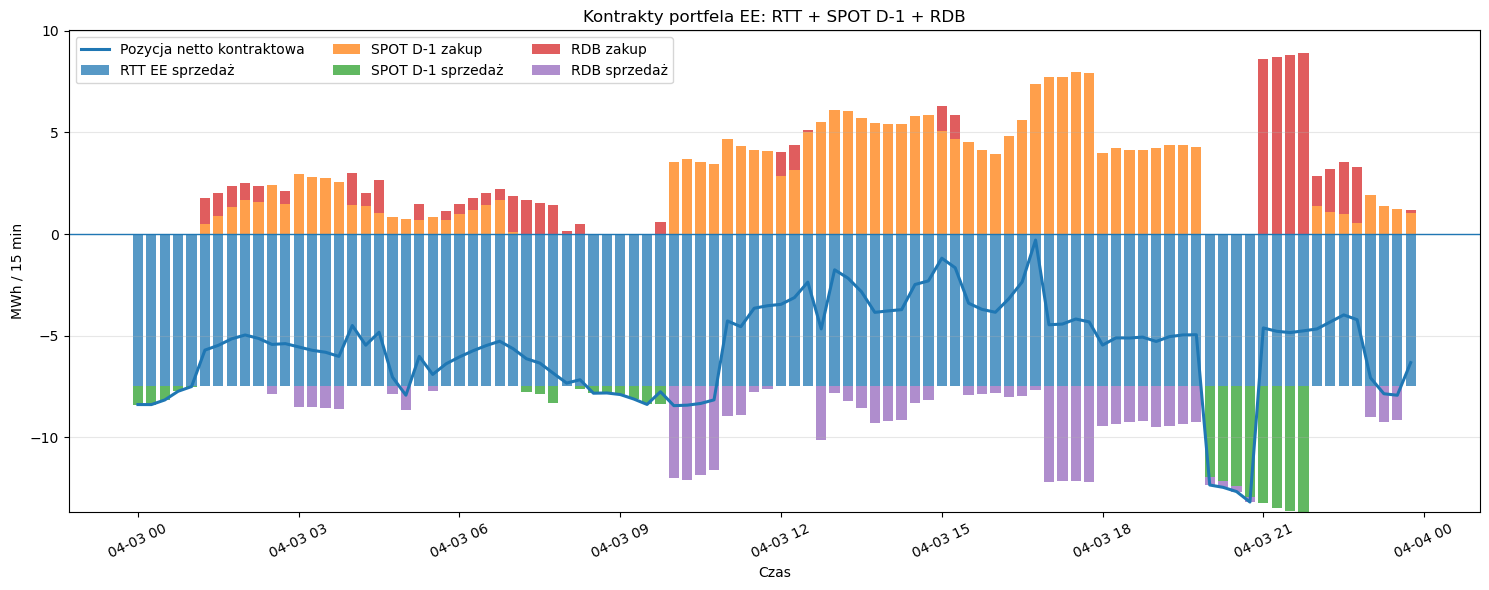

In [189]:
# =========================================================
# WYKRES KONTRAKTÓW PORTFELA: RTT + SPOT D-1 + RDB
# =========================================================
# Konwencja znaku:
#   +MWh = zakup energii / zmniejszenie pozycji short,
#   -MWh = sprzedaż energii / zobowiązanie dostawy.
# Dzięki temu na jednym wykresie widać, jak pozycja portfela składa się z RTT,
# transakcji SPOT D-1 oraz korekty RDB w rolling horizon.

contract_base_cols = [
    "timestamp",
    "rtt_ee_sell_MWh",
    "market_buy_MWh",
    "market_sell_MWh",
]
contract_base_cols = [c for c in contract_base_cols if c in results.columns]

portfolio_contracts_ts = results[contract_base_cols].copy()
portfolio_contracts_ts["timestamp"] = pd.to_datetime(portfolio_contracts_ts["timestamp"])

rdb_contract_cols = [
    "timestamp",
    "rdb_buy_MWh",
    "rdb_sell_MWh",
    "rdb_net_position_MWh",
]
rdb_contract_cols = [c for c in rdb_contract_cols if c in redispatch_results.columns]

portfolio_contracts_ts = portfolio_contracts_ts.merge(
    redispatch_results[rdb_contract_cols].copy(),
    on="timestamp",
    how="left",
)

for col in [
    "rtt_ee_sell_MWh",
    "market_buy_MWh",
    "market_sell_MWh",
    "rdb_buy_MWh",
    "rdb_sell_MWh",
    "rdb_net_position_MWh",
]:
    if col not in portfolio_contracts_ts.columns:
        portfolio_contracts_ts[col] = 0.0
    portfolio_contracts_ts[col] = pd.to_numeric(portfolio_contracts_ts[col], errors="coerce").fillna(0.0)

portfolio_contracts_ts["RTT_EE_sell_signed_MWh"] = -portfolio_contracts_ts["rtt_ee_sell_MWh"]
portfolio_contracts_ts["SPOT_D1_buy_signed_MWh"] = portfolio_contracts_ts["market_buy_MWh"]
portfolio_contracts_ts["SPOT_D1_sell_signed_MWh"] = -portfolio_contracts_ts["market_sell_MWh"]
portfolio_contracts_ts["RDB_buy_signed_MWh"] = portfolio_contracts_ts["rdb_buy_MWh"]
portfolio_contracts_ts["RDB_sell_signed_MWh"] = -portfolio_contracts_ts["rdb_sell_MWh"]

portfolio_contracts_ts["net_contract_position_MWh"] = (
    portfolio_contracts_ts["RTT_EE_sell_signed_MWh"]
    + portfolio_contracts_ts["SPOT_D1_buy_signed_MWh"]
    + portfolio_contracts_ts["SPOT_D1_sell_signed_MWh"]
    + portfolio_contracts_ts["RDB_buy_signed_MWh"]
    + portfolio_contracts_ts["RDB_sell_signed_MWh"]
)

portfolio_contracts_summary = pd.DataFrame([{
    "RTT_sell_MWh": portfolio_contracts_ts["rtt_ee_sell_MWh"].sum(),
    "SPOT_D1_buy_MWh": portfolio_contracts_ts["market_buy_MWh"].sum(),
    "SPOT_D1_sell_MWh": portfolio_contracts_ts["market_sell_MWh"].sum(),
    "RDB_buy_MWh": portfolio_contracts_ts["rdb_buy_MWh"].sum(),
    "RDB_sell_MWh": portfolio_contracts_ts["rdb_sell_MWh"].sum(),
    "RDB_net_MWh": portfolio_contracts_ts["rdb_net_position_MWh"].sum(),
    "net_contract_position_MWh": portfolio_contracts_ts["net_contract_position_MWh"].sum(),
}])

maybe_display(portfolio_contracts_summary)

fig, ax = plt.subplots(figsize=(15, 6))
width = 0.008

series_cols = [
    ("RTT_EE_sell_signed_MWh", "RTT EE sprzedaż"),
    ("SPOT_D1_buy_signed_MWh", "SPOT D-1 zakup"),
    ("SPOT_D1_sell_signed_MWh", "SPOT D-1 sprzedaż"),
    ("RDB_buy_signed_MWh", "RDB zakup"),
    ("RDB_sell_signed_MWh", "RDB sprzedaż"),
]

positive_bottom = np.zeros(len(portfolio_contracts_ts))
negative_bottom = np.zeros(len(portfolio_contracts_ts))

for col, label in series_cols:
    values = portfolio_contracts_ts[col].to_numpy(dtype=float)
    pos_values = np.where(values > 0, values, 0.0)
    neg_values = np.where(values < 0, values, 0.0)

    if np.any(pos_values != 0):
        ax.bar(
            portfolio_contracts_ts["timestamp"],
            pos_values,
            width=width,
            bottom=positive_bottom,
            label=label,
            alpha=0.75,
        )
        positive_bottom += pos_values

    if np.any(neg_values != 0):
        ax.bar(
            portfolio_contracts_ts["timestamp"],
            neg_values,
            width=width,
            bottom=negative_bottom,
            label=label,
            alpha=0.75,
        )
        negative_bottom += neg_values

ax.plot(
    portfolio_contracts_ts["timestamp"],
    portfolio_contracts_ts["net_contract_position_MWh"],
    label="Pozycja netto kontraktowa",
    linewidth=2.2,
)
ax.axhline(0, linewidth=1)
ax.set_title("Kontrakty portfela EE: RTT + SPOT D-1 + RDB")
ax.set_ylabel("MWh / 15 min")
ax.set_xlabel("Czas")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="upper left", ncol=3)
plt.xticks(rotation=25)
plt.tight_layout()
show_intermediate_plot()


## 37B. WYKRESY PORÓWNAWCZE — EX-POST VS ROLLING HORIZON

Ta sekcja pokazuje różnicę między trzema podejściami:
- **bez redispatch** — portfel realizuje plan D-1 i przyjmuje całe niezbilansowanie,
- **redispatch ex-post / perfect foresight** — wariant teoretyczny z pełną wiedzą o całej dobie,
- **redispatch rolling horizon** — wariant realistyczny, w którym decyzje są podejmowane sekwencyjnie.


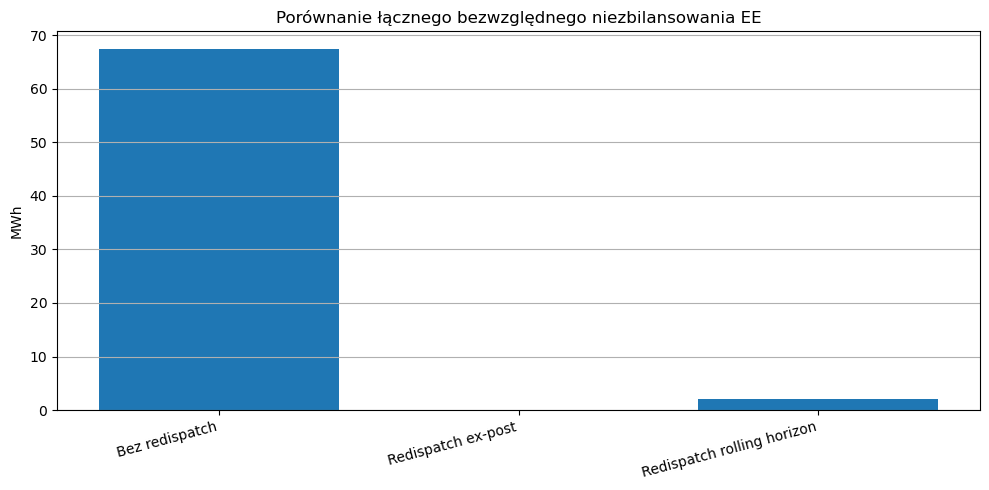

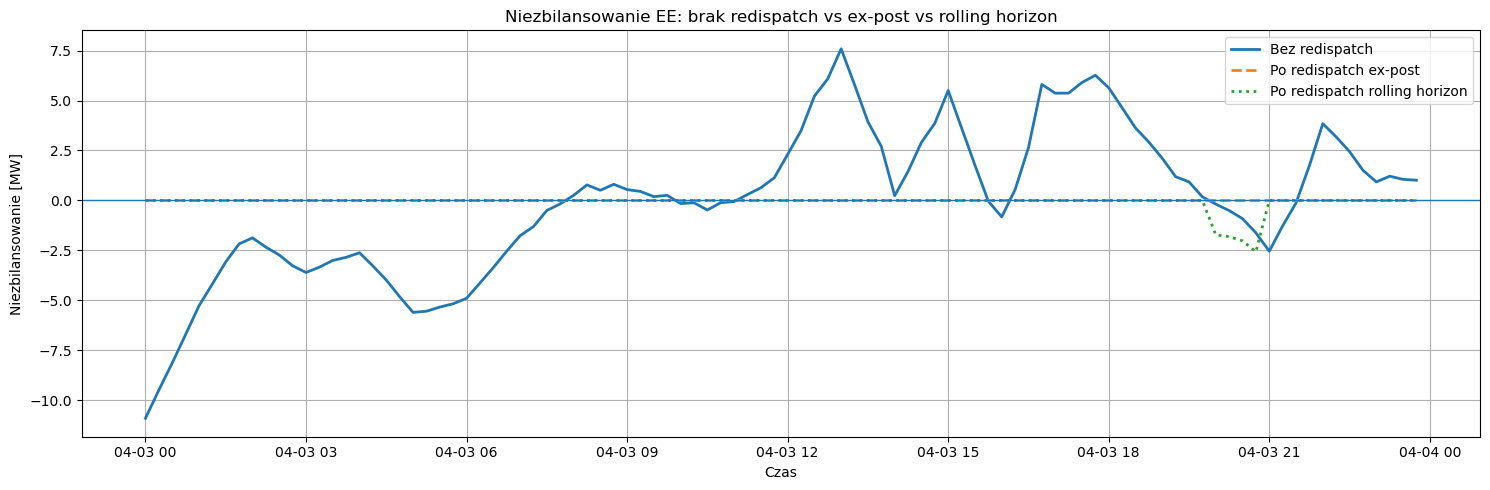

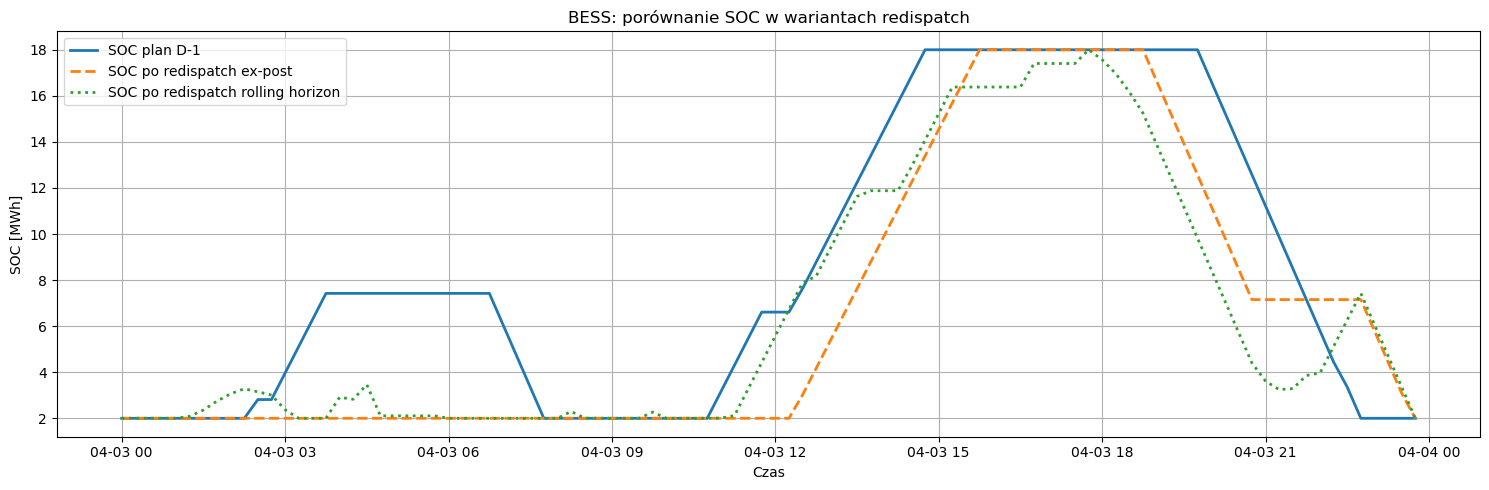

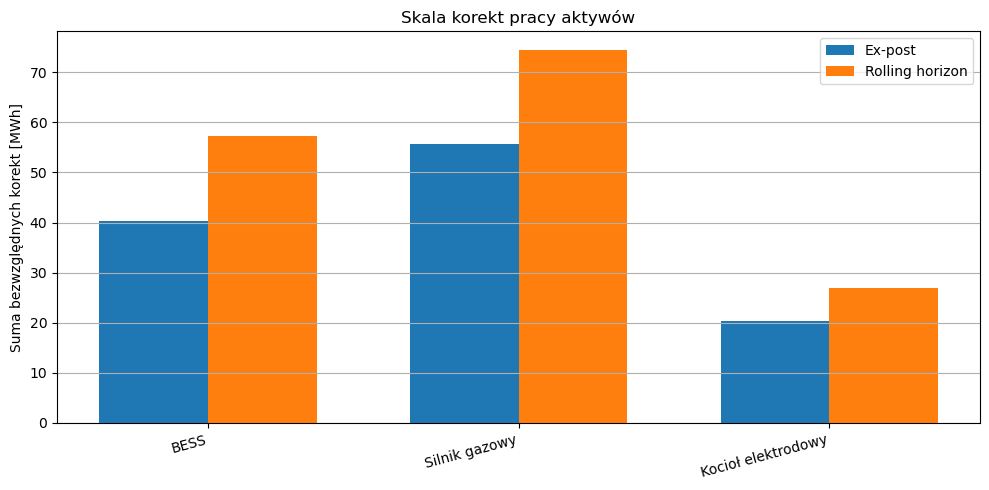

In [191]:
# =========================================================
# WYKRESY PORÓWNAWCZE: BRAK REDISPATCH VS EX-POST VS ROLLING HORIZON
# =========================================================
import numpy as np


def _prepare_variant_for_comparison(df, label, no_redispatch=False):
    """Ujednolica kolumny do porównania wariantów redispatch."""
    out = df.copy().reset_index(drop=True)
    out["timestamp"] = pd.to_datetime(out["timestamp"])
    out["wariant"] = label

    if "ee_imbalance_before_MWh" not in out.columns:
        raise ValueError(f"W wariancie {label} brakuje kolumny ee_imbalance_before_MWh.")

    if no_redispatch:
        out["ee_imbalance_after_MWh_compare"] = out["ee_imbalance_before_MWh"]
    elif "ee_imbalance_after_MWh" in out.columns:
        out["ee_imbalance_after_MWh_compare"] = out["ee_imbalance_after_MWh"]
    else:
        out["ee_imbalance_after_MWh_compare"] = out["ee_imbalance_before_MWh"]

    out["ee_imbalance_before_MW_compare"] = out["ee_imbalance_before_MWh"] / dt_h
    out["ee_imbalance_after_MW_compare"] = out["ee_imbalance_after_MWh_compare"] / dt_h

    return out


no_redispatch_compare = _prepare_variant_for_comparison(
    redispatch_df,
    "Bez redispatch",
    no_redispatch=True,
)

expost_compare = _prepare_variant_for_comparison(
    redispatch_results_expost,
    "Redispatch ex-post",
)

rolling_compare = _prepare_variant_for_comparison(
    redispatch_rolling_results,
    "Redispatch rolling horizon",
)

redispatch_variant_frames = [
    no_redispatch_compare,
    expost_compare,
    rolling_compare,
]

redispatch_comparison_summary = pd.DataFrame([
    {
        "wariant": df["wariant"].iloc[0],
        "abs_imbalance_before_MWh": df["ee_imbalance_before_MWh"].abs().sum(),
        "abs_imbalance_after_MWh": df["ee_imbalance_after_MWh_compare"].abs().sum(),
        "reduction_MWh": (
            df["ee_imbalance_before_MWh"].abs().sum()
            - df["ee_imbalance_after_MWh_compare"].abs().sum()
        ),
        "reduction_pct": (
            1
            - df["ee_imbalance_after_MWh_compare"].abs().sum()
            / df["ee_imbalance_before_MWh"].abs().sum()
        ) * 100 if df["ee_imbalance_before_MWh"].abs().sum() > 0 else np.nan,
        "max_abs_imbalance_after_MW": df["ee_imbalance_after_MW_compare"].abs().max(),
        "mean_abs_imbalance_after_MW": df["ee_imbalance_after_MW_compare"].abs().mean(),
    }
    for df in redispatch_variant_frames
])

maybe_display(redispatch_comparison_summary)

# -------------------------
# 1. Łączny wolumen niezbilansowania po danym wariancie
# -------------------------
plt.figure(figsize=(10, 5))
plt.bar(
    redispatch_comparison_summary["wariant"],
    redispatch_comparison_summary["abs_imbalance_after_MWh"],
)
plt.title("Porównanie łącznego bezwzględnego niezbilansowania EE")
plt.ylabel("MWh")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y")
show_intermediate_plot()

# -------------------------
# 2. Przebieg niezbilansowania w czasie
# -------------------------
plt.figure(figsize=(15, 5))

plt.plot(
    no_redispatch_compare["timestamp"],
    no_redispatch_compare["ee_imbalance_after_MW_compare"],
    label="Bez redispatch",
    linewidth=2,
)

plt.plot(
    expost_compare["timestamp"],
    expost_compare["ee_imbalance_after_MW_compare"],
    label="Po redispatch ex-post",
    linewidth=2,
    linestyle="--",
)

plt.plot(
    rolling_compare["timestamp"],
    rolling_compare["ee_imbalance_after_MW_compare"],
    label="Po redispatch rolling horizon",
    linewidth=2,
    linestyle=":",
)

plt.axhline(0, linewidth=1)
plt.title("Niezbilansowanie EE: brak redispatch vs ex-post vs rolling horizon")
plt.xlabel("Czas")
plt.ylabel("Niezbilansowanie [MW]")
plt.legend()
plt.grid(True)
show_intermediate_plot()

# -------------------------
# 3. SOC BESS: plan D-1 vs ex-post vs rolling horizon
# -------------------------
plt.figure(figsize=(15, 5))

if "battery_soc_MWh" in rolling_compare.columns:
    plt.plot(
        rolling_compare["timestamp"],
        rolling_compare["battery_soc_MWh"],
        label="SOC plan D-1",
        linewidth=2,
    )

if "bess_soc_actual_MWh" in expost_compare.columns:
    plt.plot(
        expost_compare["timestamp"],
        expost_compare["bess_soc_actual_MWh"],
        label="SOC po redispatch ex-post",
        linewidth=2,
        linestyle="--",
    )

if "bess_soc_actual_MWh" in rolling_compare.columns:
    plt.plot(
        rolling_compare["timestamp"],
        rolling_compare["bess_soc_actual_MWh"],
        label="SOC po redispatch rolling horizon",
        linewidth=2,
        linestyle=":",
    )

plt.title("BESS: porównanie SOC w wariantach redispatch")
plt.xlabel("Czas")
plt.ylabel("SOC [MWh]")
plt.legend()
plt.grid(True)
show_intermediate_plot()

# -------------------------
# 4. Skala korekt według aktywa
# -------------------------
def _sum_abs_or_zero(df, col):
    if col in df.columns:
        return df[col].abs().sum()
    return 0.0


def _ensure_correction_columns(df):
    out = df.copy()

    if "bess_net_delta_MWh" not in out.columns:
        required = [
            "bess_discharge_actual_MWh",
            "battery_discharge_MWh",
            "bess_charge_actual_MWh",
            "battery_charge_MWh",
        ]
        if all(col in out.columns for col in required):
            out["bess_net_delta_MWh"] = (
                out["bess_discharge_actual_MWh"]
                - out["battery_discharge_MWh"]
                - out["bess_charge_actual_MWh"]
                + out["battery_charge_MWh"]
            )
        else:
            out["bess_net_delta_MWh"] = 0.0

    if "engine_el_delta_MWh" not in out.columns:
        if {"engine_el_actual_MWh", "engine_el_MWh"}.issubset(out.columns):
            out["engine_el_delta_MWh"] = out["engine_el_actual_MWh"] - out["engine_el_MWh"]
        else:
            out["engine_el_delta_MWh"] = 0.0

    if "boiler_el_delta_MWh" not in out.columns:
        if {"boiler_el_actual_MWh", "boiler_el_MWh"}.issubset(out.columns):
            out["boiler_el_delta_MWh"] = out["boiler_el_actual_MWh"] - out["boiler_el_MWh"]
        else:
            out["boiler_el_delta_MWh"] = 0.0

    return out


expost_corr = _ensure_correction_columns(expost_compare)
rolling_corr = _ensure_correction_columns(rolling_compare)

redispatch_correction_summary = pd.DataFrame([
    {
        "aktywo": "BESS",
        "expost_MWh": _sum_abs_or_zero(expost_corr, "bess_net_delta_MWh"),
        "rolling_MWh": _sum_abs_or_zero(rolling_corr, "bess_net_delta_MWh"),
    },
    {
        "aktywo": "Silnik gazowy",
        "expost_MWh": _sum_abs_or_zero(expost_corr, "engine_el_delta_MWh"),
        "rolling_MWh": _sum_abs_or_zero(rolling_corr, "engine_el_delta_MWh"),
    },
    {
        "aktywo": "Kocioł elektrodowy",
        "expost_MWh": _sum_abs_or_zero(expost_corr, "boiler_el_delta_MWh"),
        "rolling_MWh": _sum_abs_or_zero(rolling_corr, "boiler_el_delta_MWh"),
    },
])

maybe_display(redispatch_correction_summary)

x = np.arange(len(redispatch_correction_summary))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(
    x - width / 2,
    redispatch_correction_summary["expost_MWh"],
    width,
    label="Ex-post",
)
plt.bar(
    x + width / 2,
    redispatch_correction_summary["rolling_MWh"],
    width,
    label="Rolling horizon",
)
plt.xticks(x, redispatch_correction_summary["aktywo"], rotation=15, ha="right")
plt.title("Skala korekt pracy aktywów")
plt.ylabel("Suma bezwzględnych korekt [MWh]")
plt.legend()
plt.grid(axis="y")
show_intermediate_plot()


## 38. NIEZBILANSOWANIE EE PRZED I PO REDISPATCH


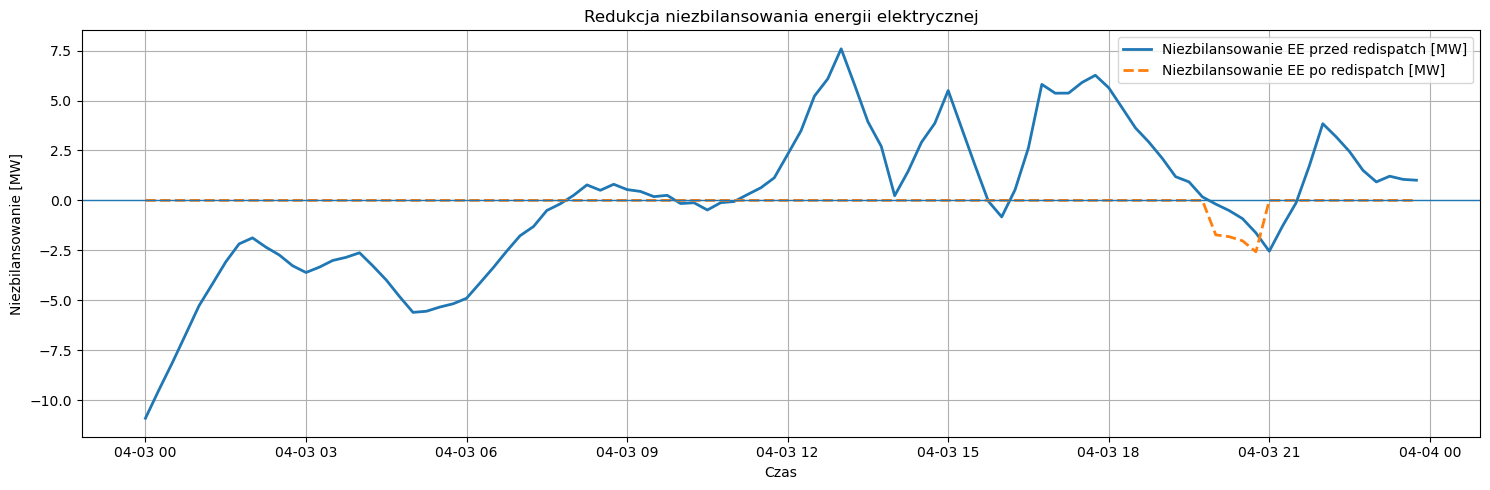

In [193]:
plt.figure(figsize=(15, 5))

plt.plot(
    redispatch_results["timestamp"],
    redispatch_results["ee_imbalance_before_MW"],
    label="Niezbilansowanie EE przed redispatch [MW]",
    linewidth=2
)

plt.plot(
    redispatch_results["timestamp"],
    redispatch_results["ee_imbalance_after_MW"],
    label="Niezbilansowanie EE po redispatch [MW]",
    linewidth=2,
    linestyle="--"
)

plt.axhline(0, linewidth=1)

plt.title("Redukcja niezbilansowania energii elektrycznej")
plt.xlabel("Czas")
plt.ylabel("Niezbilansowanie [MW]")
plt.legend()
plt.grid(True)
show_intermediate_plot()


## 39. BESS — PLAN D-1 VS REDISPATCH


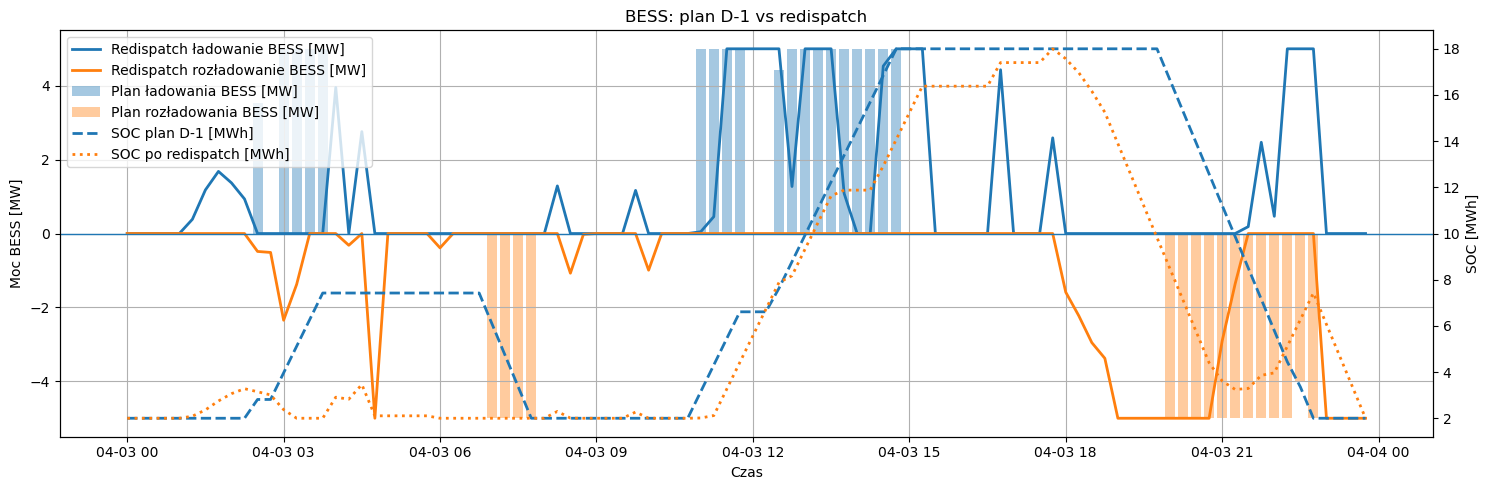

In [195]:
fig, ax1 = plt.subplots(figsize=(15, 5))

ax1.bar(
    redispatch_results["timestamp"],
    redispatch_results["battery_charge_MWh"] / dt_h,
    width=0.008,
    label="Plan ładowania BESS [MW]",
    alpha=0.4
)

ax1.bar(
    redispatch_results["timestamp"],
    -redispatch_results["battery_discharge_MWh"] / dt_h,
    width=0.008,
    label="Plan rozładowania BESS [MW]",
    alpha=0.4
)

ax1.plot(
    redispatch_results["timestamp"],
    redispatch_results["bess_charge_actual_MW"],
    label="Redispatch ładowanie BESS [MW]",
    linewidth=2
)

ax1.plot(
    redispatch_results["timestamp"],
    -redispatch_results["bess_discharge_actual_MW"],
    label="Redispatch rozładowanie BESS [MW]",
    linewidth=2
)

ax1.axhline(0, linewidth=1)
ax1.set_xlabel("Czas")
ax1.set_ylabel("Moc BESS [MW]")
ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(
    redispatch_results["timestamp"],
    redispatch_results["battery_soc_MWh"],
    label="SOC plan D-1 [MWh]",
    linewidth=2,
    linestyle="--"
)

ax2.plot(
    redispatch_results["timestamp"],
    redispatch_results["bess_soc_actual_MWh"],
    label="SOC po redispatch [MWh]",
    linewidth=2,
    linestyle=":"
)

ax2.set_ylabel("SOC [MWh]")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left"
)

plt.title("BESS: plan D-1 vs redispatch")
show_intermediate_plot()


## 40. SILNIK GAZOWY — PLAN D-1 VS REDISPATCH


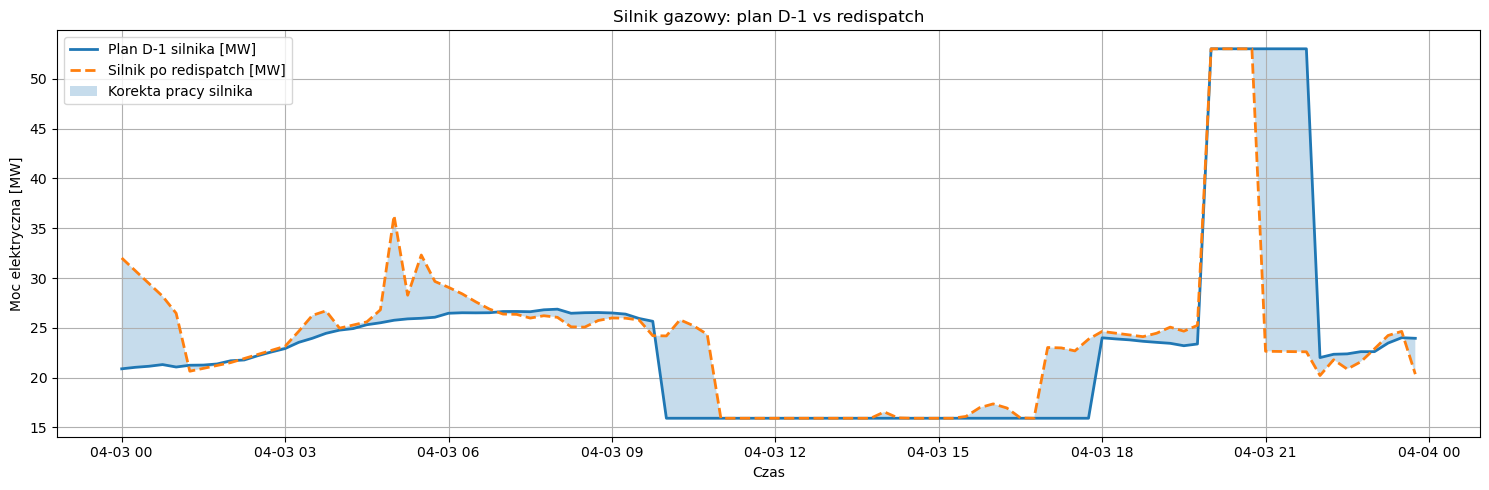

In [197]:
plt.figure(figsize=(15, 5))

plt.plot(
    redispatch_results["timestamp"],
    redispatch_results["engine_el_MWh"] / dt_h,
    label="Plan D-1 silnika [MW]",
    linewidth=2
)

plt.plot(
    redispatch_results["timestamp"],
    redispatch_results["engine_el_actual_MW"],
    label="Silnik po redispatch [MW]",
    linewidth=2,
    linestyle="--"
)

plt.fill_between(
    redispatch_results["timestamp"],
    redispatch_results["engine_el_MWh"] / dt_h,
    redispatch_results["engine_el_actual_MW"],
    alpha=0.25,
    label="Korekta pracy silnika"
)

plt.title("Silnik gazowy: plan D-1 vs redispatch")
plt.xlabel("Czas")
plt.ylabel("Moc elektryczna [MW]")
plt.legend()
plt.grid(True)
show_intermediate_plot()


## 41. ŹRÓDŁA KOREKTY NIEZBILANSOWANIA


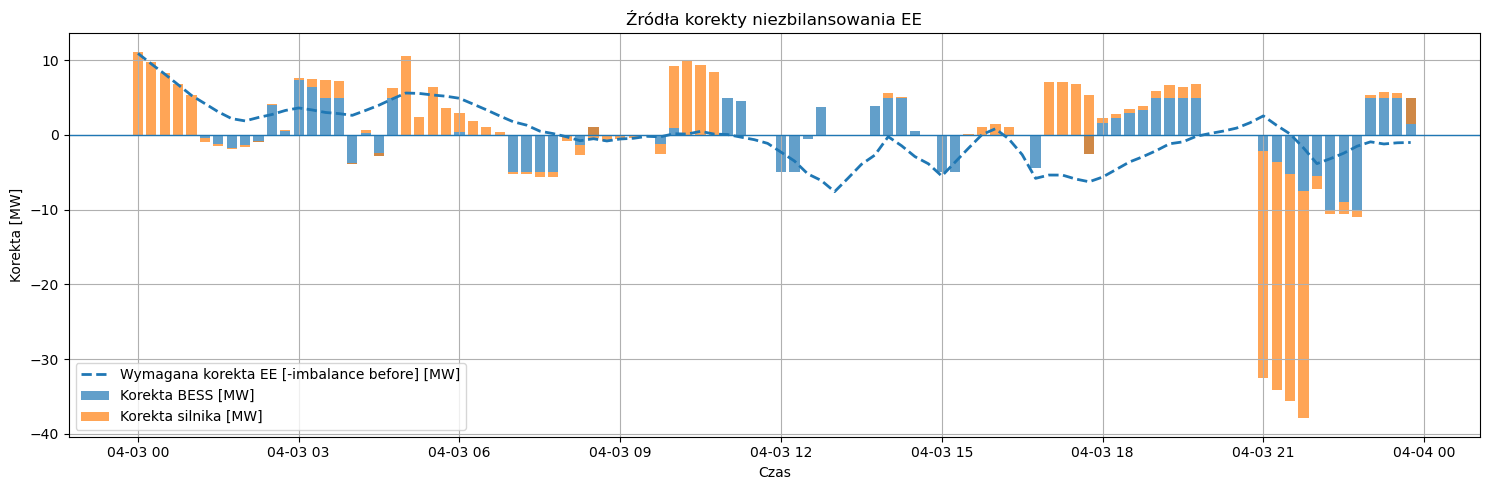

In [199]:
redispatch_results["bess_correction_MWh"] = redispatch_results["bess_net_delta_MWh"]
redispatch_results["engine_correction_MWh"] = redispatch_results["engine_el_delta_MWh"]

plt.figure(figsize=(15, 5))

plt.bar(
    redispatch_results["timestamp"],
    redispatch_results["bess_correction_MWh"] / dt_h,
    width=0.008,
    label="Korekta BESS [MW]",
    alpha=0.7
)

plt.bar(
    redispatch_results["timestamp"],
    redispatch_results["engine_correction_MWh"] / dt_h,
    width=0.008,
    bottom=redispatch_results["bess_correction_MWh"] / dt_h,
    label="Korekta silnika [MW]",
    alpha=0.7
)

plt.plot(
    redispatch_results["timestamp"],
    -redispatch_results["ee_imbalance_before_MW"],
    label="Wymagana korekta EE [-imbalance before] [MW]",
    linewidth=2,
    linestyle="--"
)

plt.axhline(0, linewidth=1)

plt.title("Źródła korekty niezbilansowania EE")
plt.xlabel("Czas")
plt.ylabel("Korekta [MW]")
plt.legend()
plt.grid(True)
show_intermediate_plot()


## 42. CIEPŁO W REDISPATCH: RZECZYWISTY POBÓR I ZRZUT


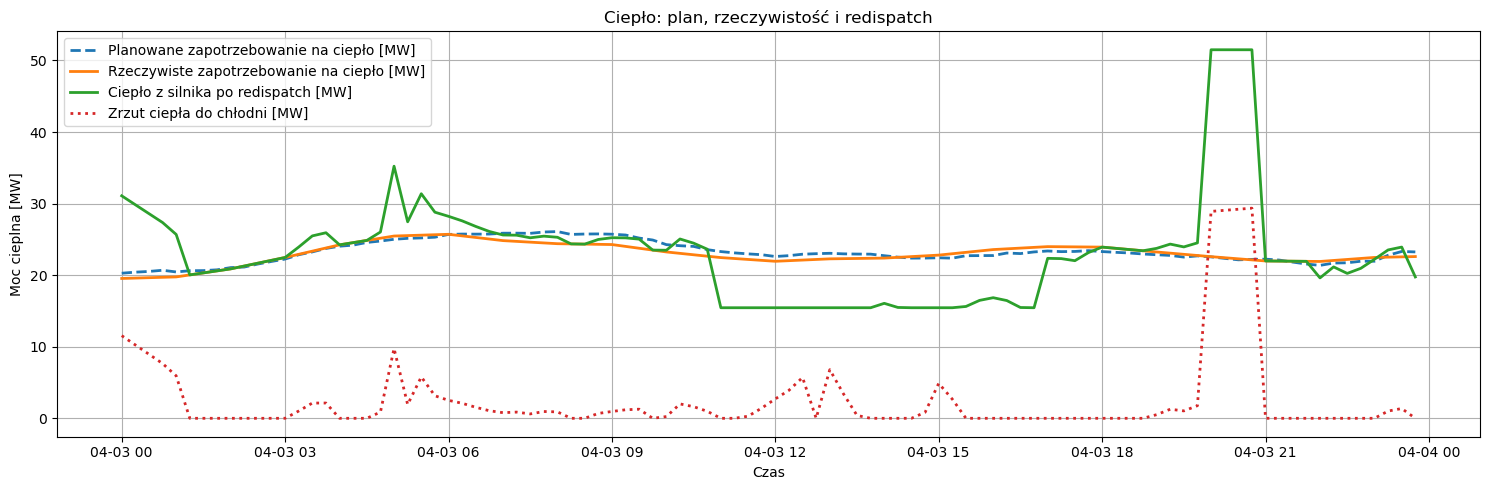

In [201]:
plt.figure(figsize=(15, 5))

plt.plot(
    redispatch_results["timestamp"],
    redispatch_results["heat_demand_MWh"] / dt_h,
    label="Planowane zapotrzebowanie na ciepło [MW]",
    linewidth=2,
    linestyle="--"
)

plt.plot(
    redispatch_results["timestamp"],
    redispatch_results["heat_demand_actual_MWh"] / dt_h,
    label="Rzeczywiste zapotrzebowanie na ciepło [MW]",
    linewidth=2
)

plt.plot(
    redispatch_results["timestamp"],
    redispatch_results["engine_heat_actual_MW"],
    label="Ciepło z silnika po redispatch [MW]",
    linewidth=2
)

plt.plot(
    redispatch_results["timestamp"],
    redispatch_results["heat_dump_actual_MWh"] / dt_h,
    label="Zrzut ciepła do chłodni [MW]",
    linewidth=2,
    linestyle=":"
)

plt.title("Ciepło: plan, rzeczywistość i redispatch")
plt.xlabel("Czas")
plt.ylabel("Moc cieplna [MW]")
plt.legend()
plt.grid(True)
show_intermediate_plot()


## 43. REDUKCJA NIEZBILANSOWANIA — PODSUMOWANIE


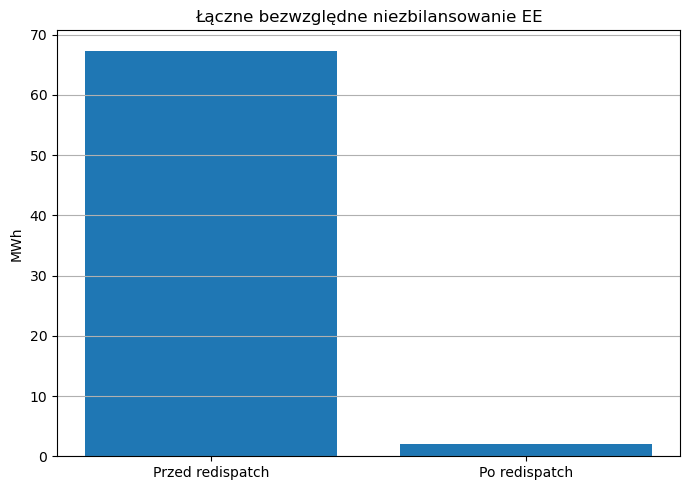

,etap,abs_imbalance_MWh
0,Przed redispatch,67.338676
1,Po redispatch,2.034859


In [203]:
imbalance_reduction_summary = pd.DataFrame({
    "etap": ["Przed redispatch", "Po redispatch"],
    "abs_imbalance_MWh": [
        redispatch_results["ee_imbalance_before_MWh"].abs().sum(),
        redispatch_results["ee_imbalance_after_MWh"].abs().sum()
    ]
})

plt.figure(figsize=(7, 5))

plt.bar(
    imbalance_reduction_summary["etap"],
    imbalance_reduction_summary["abs_imbalance_MWh"]
)

plt.title("Łączne bezwzględne niezbilansowanie EE")
plt.ylabel("MWh")
plt.grid(axis="y")
show_intermediate_plot()

imbalance_reduction_summary


## 46. ZAPIS WYNIKÓW REDISPATCH DO EXCELA


In [205]:
OUTPUT_REDISPATCH_PATH = f"wyniki_redispatch_{FORECAST_DATE}.xlsx"

with pd.ExcelWriter(OUTPUT_REDISPATCH_PATH, engine="openpyxl") as writer:

    # Wyniki szczegółowe 15-min
    redispatch_results.to_excel(
        writer,
        sheet_name="Redispatch_15min",
        index=False
    )

    # Podsumowanie redispatch
    summary_redispatch.to_excel(
        writer,
        sheet_name="Podsumowanie",
        index=False
    )

    # Podsumowanie niezbilansowania przed/po
    imbalance_reduction_summary.to_excel(
        writer,
        sheet_name="Redukcja_MWh",
        index=False
    )

    # Dla porównania: plan D-1
    results.to_excel(
        writer,
        sheet_name="Plan_D_1",
        index=False
    )

print(f"Zapisano wyniki redispatch do pliku: {OUTPUT_REDISPATCH_PATH}")


Zapisano wyniki redispatch do pliku: wyniki_redispatch_2026-04-03.xlsx


## 60. WCZYTANIE CEN NIEZBILANSOWANIA CEN Z EXCELA


In [207]:
# =========================================================
# RZECZYWISTA CEN I DANE RYNKU BILANSUJĄCEGO
# =========================================================
# Plik może obejmować jedną lub wiele dób. Jeżeli wskazany plik nie istnieje,
# kod wyszukuje pliki zaczynające się od „Ceny i niezbilansowanie na RB”
# i wybiera ten, który zawiera FORECAST_DATE.

from pathlib import Path

CEN_FILE_PATH = (
    "Ceny i niezbilansowanie na RB.xlsx"
)
CEN_SHEET_NAME = "ag-grid"


def _resolve_cen_file(
    preferred_path=CEN_FILE_PATH,
    sheet_name=CEN_SHEET_NAME,
):
    """Zwraca plik RB zawierający dane dla FORECAST_DATE."""
    preferred = Path(preferred_path)
    target_day = pd.Timestamp(FORECAST_DATE).normalize()

    def _contains_target_day(candidate):
        try:
            preview = pd.read_excel(
                candidate,
                sheet_name=sheet_name,
                usecols=lambda col: str(col).strip() == "Doba",
            )
            if "Doba" not in preview.columns:
                return False

            days = pd.to_datetime(
                preview["Doba"], errors="coerce"
            ).dt.normalize()
            return bool((days == target_day).any())
        except Exception:
            return False

    if preferred.exists() and _contains_target_day(preferred):
        return preferred

    candidates = sorted(
        Path(".").glob("Ceny i niezbilansowanie na RB*.xlsx")
    )
    matching = [
        candidate for candidate in candidates
        if _contains_target_day(candidate)
    ]

    if len(matching) == 1:
        print(f"Automatycznie wybrano plik RB: {matching[0]}")
        return matching[0]

    if len(matching) > 1:
        raise ValueError(
            "Znaleziono kilka plików RB zawierających FORECAST_DATE. "
            "Ustaw jednoznacznie CEN_FILE_PATH. Pliki: "
            + ", ".join(str(path) for path in matching)
        )

    raise FileNotFoundError(
        "Nie znaleziono pliku RB zawierającego dane dla "
        f"{FORECAST_DATE}. Ustaw poprawną wartość CEN_FILE_PATH."
    )


CEN_FILE_PATH_RESOLVED = _resolve_cen_file()

cen_raw = pd.read_excel(
    CEN_FILE_PATH_RESOLVED,
    sheet_name=CEN_SHEET_NAME,
)

print(f"Wczytano plik RB: {CEN_FILE_PATH_RESOLVED}")
maybe_display(cen_raw.head())
print(cen_raw.columns.tolist())

Wczytano plik RB: Ceny i niezbilansowanie na RB.xlsx
['Doba', 'Jednostka czasu [od - do]', 'CEN\n[zł/MWh]', 'COR\n[zł/MW-h]', 'CKOEB\n[zł/MWh]', 'CEBśr\n[zł/MWh]', 'Stan zakontraktowania KSE (status)', 'Energia niezbilansowania\n[MWh]']


## 61. PRZYGOTOWANIE CEN CEN DO ROZLICZENIA


In [209]:
cen_prices = cen_raw.copy()

required_rb_cols = [
    "Doba",
    "Jednostka czasu [od - do]",
    "CEN\n[zł/MWh]",
    "Stan zakontraktowania KSE (status)",
    "Energia niezbilansowania\n[MWh]",
]
missing_rb_cols = [
    col for col in required_rb_cols
    if col not in cen_prices.columns
]
if missing_rb_cols:
    raise ValueError(
        "Brakuje wymaganych kolumn w pliku RB: "
        f"{missing_rb_cols}. Dostępne kolumny: "
        f"{cen_prices.columns.tolist()}"
    )

cen_prices["Doba"] = pd.to_datetime(
    cen_prices["Doba"],
    errors="coerce",
)

# Z zapisu np. „00:15 - 00:30” pobierany jest początek interwału.
# Dla ostatniego wiersza „23:45 - 24:00” timestamp wynosi 23:45.
cen_prices["time_start"] = (
    cen_prices["Jednostka czasu [od - do]"]
    .astype(str)
    .str.split(" - ")
    .str[0]
    .str.strip()
)

cen_prices["timestamp"] = (
    pd.to_datetime(
        cen_prices["Doba"].dt.strftime("%Y-%m-%d")
        + " "
        + cen_prices["time_start"],
        errors="coerce",
    )
    .dt.floor("15min")
)

cen_prices = cen_prices.rename(columns={
    "CEN\n[zł/MWh]": "imbalance_price_PLN_MWh",
    "Stan zakontraktowania KSE (status)": "system_status",
    "Energia niezbilansowania\n[MWh]": "system_imbalance_MWh",
})

cen_prices["imbalance_price_PLN_MWh"] = pd.to_numeric(
    cen_prices["imbalance_price_PLN_MWh"],
    errors="coerce",
)
cen_prices["system_imbalance_MWh"] = pd.to_numeric(
    cen_prices["system_imbalance_MWh"],
    errors="coerce",
)

# Wybór wyłącznie analizowanej doby z pliku jedno- lub wielodniowego.
day_start = pd.Timestamp(FORECAST_DATE).normalize()
day_end = day_start + pd.Timedelta(days=1)
cen_prices = cen_prices.loc[
    (cen_prices["timestamp"] >= day_start)
    & (cen_prices["timestamp"] < day_end)
].copy()

invalid_mask = (
    cen_prices["timestamp"].isna()
    | cen_prices["imbalance_price_PLN_MWh"].isna()
)
if invalid_mask.any():
    maybe_display(cen_prices.loc[invalid_mask].head(20))
    raise ValueError(
        "W danych RB występują błędne timestampy lub puste wartości CEN."
    )

duplicate_mask = cen_prices["timestamp"].duplicated(keep=False)
if duplicate_mask.any():
    maybe_display(
        cen_prices.loc[duplicate_mask].sort_values("timestamp")
    )
    raise ValueError(
        "W danych RB występują powtórzone znaczniki czasu "
        f"dla dnia {FORECAST_DATE}."
    )

cen_prices = cen_prices[
    [
        "timestamp",
        "imbalance_price_PLN_MWh",
        "system_status",
        "system_imbalance_MWh",
    ]
].copy()

cen_prices = (
    cen_prices
    .sort_values("timestamp")
    .reset_index(drop=True)
)

# Oś referencyjna pochodzi z wyników modelu, a awaryjnie z pełnej doby 15-min.
if "redispatch_results" in globals() and "timestamp" in redispatch_results.columns:
    expected_timestamps = pd.DatetimeIndex(
        pd.to_datetime(
            redispatch_results["timestamp"],
            errors="coerce",
        )
        .dt.floor("15min")
        .dropna()
        .drop_duplicates()
        .sort_values()
    )
else:
    expected_timestamps = pd.date_range(
        start=day_start,
        periods=96,
        freq="15min",
    )

actual_timestamps = pd.DatetimeIndex(cen_prices["timestamp"])
missing_timestamps = expected_timestamps.difference(actual_timestamps)
unexpected_timestamps = actual_timestamps.difference(expected_timestamps)

if len(missing_timestamps) > 0 or len(unexpected_timestamps) > 0:
    print("Brakujące timestampy RB:", missing_timestamps[:20].tolist())
    print("Nadmiarowe timestampy RB:", unexpected_timestamps[:20].tolist())
    raise ValueError(
        "Dane RB nie pokrywają dokładnie osi czasu modelu dla "
        f"{FORECAST_DATE}. Oczekiwano {len(expected_timestamps)} interwałów, "
        f"znaleziono {len(actual_timestamps)}."
    )

maybe_display(cen_prices.head())
print(
    "OK: rzeczywista CEN i dane RB; "
    f"zakres {cen_prices['timestamp'].min()} -> "
    f"{cen_prices['timestamp'].max()}, "
    f"rekordów: {len(cen_prices)}."
)

OK: rzeczywista CEN i dane RB; zakres 2026-04-03 00:00:00 -> 2026-04-03 23:45:00, rekordów: 96.


## 61. TABELA ROZLICZENIOWA PORTFELA


In [211]:
settlement = redispatch_results.copy()

settlement["timestamp"] = pd.to_datetime(settlement["timestamp"])
results["timestamp"] = pd.to_datetime(results["timestamp"])
cen_prices["timestamp"] = pd.to_datetime(cen_prices["timestamp"])

# -------------------------
# 1. Uzupełnienie danych ekonomicznych z planu D-1
# -------------------------

plan_cols_needed = [
    "timestamp",
    "market_buy_MWh",
    "market_sell_MWh",
    "rtt_ee_sell_MWh",
    "rtt_ee_sell_price",
    "rtt_gas_buy_MWh_HHV",
    "rtt_gas_price",
    "gas_spot_buy_MWh",
    "gas_spot_sell_MWh",
    "cooling_fan_el_MWh",
    "heat_dump_MWh",
    "spot_price_actual"
]

available_plan_cols = [
    col for col in plan_cols_needed
    if col in results.columns
]

settlement = settlement.merge(
    results[available_plan_cols],
    on="timestamp",
    how="left",
    suffixes=("", "_plan")
)

# Porządkujemy ewentualne kolumny z suffixem po merge z planem
for col in plan_cols_needed:
    col_plan = f"{col}_plan"

    if col_plan in settlement.columns:
        if col in settlement.columns:
            settlement[col] = settlement[col].fillna(settlement[col_plan])
            settlement = settlement.drop(columns=[col_plan])
        else:
            settlement = settlement.rename(columns={col_plan: col})

# -------------------------
# 2. Kolumny brakujące uzupełniamy zerami
# -------------------------

zero_cols = [
    "market_buy_MWh",
    "market_sell_MWh",
    "rtt_ee_sell_MWh",
    "rtt_ee_sell_price",
    "rtt_gas_buy_MWh_HHV",
    "rtt_gas_price",
    "gas_spot_buy_MWh",
    "gas_spot_sell_MWh",
    "cooling_fan_el_MWh",
    "heat_dump_MWh"
]

for col in zero_cols:
    if col not in settlement.columns:
        settlement[col] = 0

# -------------------------
# 3. Dołączenie CEN z Excela
# -------------------------

# Usuwamy stare kolumny CEN po wcześniejszych próbach
settlement = settlement.drop(
    columns=[
        "imbalance_price_PLN_MWh",
        "imbalance_price_PLN_MWh_x",
        "imbalance_price_PLN_MWh_y",
        "system_status",
        "system_status_x",
        "system_status_y",
        "system_imbalance_MWh",
        "system_imbalance_MWh_x",
        "system_imbalance_MWh_y"
    ],
    errors="ignore"
)

settlement = settlement.merge(
    cen_prices,
    on="timestamp",
    how="left"
)

if "imbalance_price_PLN_MWh" not in settlement.columns:
    print("Kolumny cen_prices:", cen_prices.columns.tolist())
    print("Kolumny settlement:", settlement.columns.tolist())
    raise ValueError(
        "Po merge nie ma kolumny imbalance_price_PLN_MWh. "
        "Sprawdź przygotowanie cen_prices."
    )

if settlement["imbalance_price_PLN_MWh"].isna().any():
    maybe_display(
        settlement[
            settlement["imbalance_price_PLN_MWh"].isna()
        ][["timestamp"]].head(20)
    )
    raise ValueError("Brakuje cen CEN dla części interwałów.")

# -------------------------
# 4. Cena rzeczywista SPOT EE
# -------------------------

if "price_spot_actual" in settlement.columns:
    settlement["spot_price_real_PLN_MWh"] = settlement["price_spot_actual"]
elif "spot_price_actual" in settlement.columns:
    settlement["spot_price_real_PLN_MWh"] = settlement["spot_price_actual"]
elif "Cena RDN PLN/MWh" in settlement.columns:
    settlement["spot_price_real_PLN_MWh"] = settlement["Cena RDN PLN/MWh"]
else:
    settlement["spot_price_real_PLN_MWh"] = settlement["spot_price_used"]

# Cena prognozowana SPOT EE z planu
settlement["spot_price_forecast_PLN_MWh"] = settlement["spot_price_used"]

# RDB — jeżeli dany wariant nie korzysta z RDB, ustawiamy wolumeny i ceny neutralnie.
for col in ["rdb_buy_MWh", "rdb_sell_MWh", "rdb_net_buy_MWh"]:
    if col not in settlement.columns:
        settlement[col] = 0.0

if "rdb_buy_price_forecast_PLN_MWh" not in settlement.columns:
    settlement["rdb_buy_price_forecast_PLN_MWh"] = settlement["spot_price_real_PLN_MWh"]
if "rdb_sell_price_forecast_PLN_MWh" not in settlement.columns:
    settlement["rdb_sell_price_forecast_PLN_MWh"] = settlement["spot_price_real_PLN_MWh"]


# -------------------------
# 5. Kontrola
# -------------------------

print("Liczba wierszy settlement:", len(settlement))
print("Zakres:", settlement["timestamp"].min(), "->", settlement["timestamp"].max())

maybe_display(
    settlement[
        [
            "timestamp",
            "spot_price_forecast_PLN_MWh",
            "spot_price_real_PLN_MWh",
            "imbalance_price_PLN_MWh",
            "system_status",
            "system_imbalance_MWh",
            "market_buy_MWh",
            "market_sell_MWh",
            "rdb_buy_MWh",
            "rdb_sell_MWh",
            "rtt_ee_sell_MWh",
            "rtt_ee_sell_price"
        ]
    ].head()
)

Liczba wierszy settlement: 96
Zakres: 2026-04-03 00:00:00 -> 2026-04-03 23:45:00


## 62. SCENARIUSZ 1 — PLAN D-1


In [213]:
pnl = settlement.copy()

# PLAN D-1 liczymy po cenach prognozowanych / użytych przez optymalizator

pnl["D1_revenue_rtt_ee_PLN"] = (
    pnl["rtt_ee_sell_MWh"] * pnl["rtt_ee_sell_price"]
)

pnl["D1_revenue_spot_ee_PLN"] = (
    pnl["market_sell_MWh"] * pnl["spot_price_forecast_PLN_MWh"]
)

pnl["D1_cost_spot_ee_PLN"] = (
    pnl["market_buy_MWh"] * pnl["spot_price_forecast_PLN_MWh"]
)

pnl["D1_cost_rtt_gas_PLN"] = (
    pnl["rtt_gas_buy_MWh_HHV"] * pnl["rtt_gas_price"]
)

pnl["D1_cost_spot_gas_PLN"] = (
    pnl["gas_spot_buy_MWh"] * pnl["gas_spot_price"]
)

pnl["D1_revenue_spot_gas_PLN"] = (
    pnl["gas_spot_sell_MWh"] * pnl["gas_spot_price"]
)

pnl["D1_cost_co2_PLN"] = (
    pnl["engine_gas_MWh"] * emission_factor * pnl["co2_price"]
)

pnl["D1_cost_engine_om_PLN"] = (
    pnl["engine_el_MWh"] * engine_variable_om_PLN_MWh_el
)

pnl["D1_cost_bess_PLN"] = (
    (
        pnl["battery_charge_MWh"]
        + pnl["battery_discharge_MWh"]
    )
    * battery_cycle_cost_PLN_MWh
)

# Zużycie energii przez chłodnie jest już ujęte w bilansie EE i wpływa
# na market_buy_MWh / market_sell_MWh. Nie naliczamy go drugi raz w PnL.
pnl["D1_cost_cooling_fans_PLN"] = 0.0

pnl["D1_cost_heat_dump_PLN"] = (
    pnl["heat_dump_MWh"] * heat_dump_cost_PLN_MWh
)

pnl["D1_total_revenue_PLN"] = (
    pnl["D1_revenue_rtt_ee_PLN"]
    + pnl["D1_revenue_spot_ee_PLN"]
    + pnl["D1_revenue_spot_gas_PLN"]
)

pnl["D1_total_cost_PLN"] = (
    pnl["D1_cost_spot_ee_PLN"]
    + pnl["D1_cost_rtt_gas_PLN"]
    + pnl["D1_cost_spot_gas_PLN"]
    + pnl["D1_cost_co2_PLN"]
    + pnl["D1_cost_engine_om_PLN"]
    + pnl["D1_cost_bess_PLN"]
    + pnl["D1_cost_cooling_fans_PLN"]
    + pnl["D1_cost_heat_dump_PLN"]
)

pnl["D1_margin_PLN"] = (
    pnl["D1_total_revenue_PLN"]
    - pnl["D1_total_cost_PLN"]
)

## 63. SCENARIUSZ 2 — ACTUAL BEZ REDISPATCH


In [215]:
# Operacyjnie jednostki pracują wg planu D-1,
# ale rozliczenie SPOT robimy po rzeczywistej cenie SPOT EE.

pnl["ACTUAL_NO_RED_revenue_rtt_ee_PLN"] = pnl["D1_revenue_rtt_ee_PLN"]

pnl["ACTUAL_NO_RED_revenue_spot_ee_PLN"] = (
    pnl["market_sell_MWh"] * pnl["spot_price_real_PLN_MWh"]
)

pnl["ACTUAL_NO_RED_cost_spot_ee_PLN"] = (
    pnl["market_buy_MWh"] * pnl["spot_price_real_PLN_MWh"]
)

pnl["ACTUAL_NO_RED_cost_rtt_gas_PLN"] = pnl["D1_cost_rtt_gas_PLN"]

# W scenariuszu bez redispatch jednostki wykonują plan D-1,
# więc nie powstaje dodatkowa operacyjna korekta zużycia gazu.
pnl["ACTUAL_NO_RED_gas_imbalance_buy_MWh"] = 0.0
pnl["ACTUAL_NO_RED_gas_imbalance_sell_MWh"] = 0.0

pnl["ACTUAL_NO_RED_cost_spot_gas_PLN"] = pnl["D1_cost_spot_gas_PLN"]
pnl["ACTUAL_NO_RED_revenue_spot_gas_PLN"] = pnl["D1_revenue_spot_gas_PLN"]

pnl["ACTUAL_NO_RED_cost_co2_PLN"] = pnl["D1_cost_co2_PLN"]
pnl["ACTUAL_NO_RED_cost_engine_om_PLN"] = pnl["D1_cost_engine_om_PLN"]
pnl["ACTUAL_NO_RED_cost_bess_PLN"] = pnl["D1_cost_bess_PLN"]

# Pobór energii przez chłodnie i kocioł elektrodowy został już uwzględniony
# w pozycji SPOT planu D-1. Oddzielne naliczenie kosztu powodowałoby podwójne
# ujęcie tej samej energii. Kolumny pozostają wyłącznie dla przejrzystości raportu.
pnl["ACTUAL_NO_RED_cost_cooling_fans_PLN"] = 0.0
pnl["ACTUAL_NO_RED_cost_boiler_el_PLN"] = 0.0

pnl["ACTUAL_NO_RED_cost_heat_dump_PLN"] = pnl["D1_cost_heat_dump_PLN"]

# -------------------------
# Rozliczenie niezbilansowania przed redispatch — WDB PSE
# -------------------------
# WDB: NEN = CEN * EN. Nie używamy abs(EN) do rozliczenia finansowego.
# Dodatnie EN -> dodatnie rozliczenie przy dodatniej CEN.
# Ujemne EN -> koszt przy dodatniej CEN.

pnl["imbalance_settlement_before_PLN"] = (
    pnl["ee_imbalance_before_MWh"]
    * pnl["imbalance_price_PLN_MWh"]
)

pnl["imbalance_revenue_before_PLN"] = (
    pnl["imbalance_settlement_before_PLN"].clip(lower=0)
)

pnl["imbalance_cost_before_PLN"] = (
    -pnl["imbalance_settlement_before_PLN"].clip(upper=0)
)

pnl["ACTUAL_NO_RED_total_revenue_without_imbalance_PLN"] = (
    pnl["ACTUAL_NO_RED_revenue_rtt_ee_PLN"]
    + pnl["ACTUAL_NO_RED_revenue_spot_ee_PLN"]
    + pnl["ACTUAL_NO_RED_revenue_spot_gas_PLN"]
)

pnl["ACTUAL_NO_RED_total_cost_without_imbalance_PLN"] = (
    pnl["ACTUAL_NO_RED_cost_spot_ee_PLN"]
    + pnl["ACTUAL_NO_RED_cost_rtt_gas_PLN"]
    + pnl["ACTUAL_NO_RED_cost_spot_gas_PLN"]
    + pnl["ACTUAL_NO_RED_cost_co2_PLN"]
    + pnl["ACTUAL_NO_RED_cost_engine_om_PLN"]
    + pnl["ACTUAL_NO_RED_cost_bess_PLN"]
    + pnl["ACTUAL_NO_RED_cost_cooling_fans_PLN"]
    + pnl["ACTUAL_NO_RED_cost_heat_dump_PLN"]
    + pnl["ACTUAL_NO_RED_cost_boiler_el_PLN"]
)

pnl["ACTUAL_NO_RED_total_revenue_PLN"] = (
    pnl["ACTUAL_NO_RED_total_revenue_without_imbalance_PLN"]
    + pnl["imbalance_revenue_before_PLN"]
)

pnl["ACTUAL_NO_RED_total_cost_PLN"] = (
    pnl["ACTUAL_NO_RED_total_cost_without_imbalance_PLN"]
    + pnl["imbalance_cost_before_PLN"]
)

pnl["ACTUAL_NO_RED_margin_PLN"] = (
    pnl["ACTUAL_NO_RED_total_revenue_PLN"]
    - pnl["ACTUAL_NO_RED_total_cost_PLN"]
)

# -------------------------
# Benchmark: Idealna prognoza D-1 / idealne zakontraktowanie błędu prognozy
# -------------------------
# Ten wariant zakłada, że dzień wcześniej znamy rzeczywisty błąd prognozy
# i kontraktujemy podpisany wolumen EN po cenie SPOT/RDN. Wtedy rozliczenie
# CEN wynosi zero, bo nie ma energii niezbilansowania.

pnl["PERFECT_D1_contract_adjustment_MWh"] = pnl["ee_imbalance_before_MWh"]

pnl["PERFECT_D1_contract_settlement_PLN"] = (
    pnl["PERFECT_D1_contract_adjustment_MWh"]
    * pnl["spot_price_real_PLN_MWh"]
)

pnl["PERFECT_D1_contract_revenue_PLN"] = (
    pnl["PERFECT_D1_contract_settlement_PLN"].clip(lower=0)
)

pnl["PERFECT_D1_contract_cost_PLN"] = (
    -pnl["PERFECT_D1_contract_settlement_PLN"].clip(upper=0)
)

pnl["PERFECT_D1_total_revenue_PLN"] = (
    pnl["ACTUAL_NO_RED_total_revenue_without_imbalance_PLN"]
    + pnl["PERFECT_D1_contract_revenue_PLN"]
)

pnl["PERFECT_D1_total_cost_PLN"] = (
    pnl["ACTUAL_NO_RED_total_cost_without_imbalance_PLN"]
    + pnl["PERFECT_D1_contract_cost_PLN"]
)

pnl["PERFECT_D1_margin_PLN"] = (
    pnl["PERFECT_D1_total_revenue_PLN"]
    - pnl["PERFECT_D1_total_cost_PLN"]
)

pnl["PERFECT_D1_ee_imbalance_MWh"] = 0.0
pnl["PERFECT_D1_imbalance_settlement_PLN"] = 0.0


## 64. SCENARIUSZ 3 — ACTUAL PO REDISPATCH


In [217]:
pnl["ACTUAL_RED_revenue_rtt_ee_PLN"] = pnl["D1_revenue_rtt_ee_PLN"]

# Pozycje SPOT zakontraktowane D-1 zostają,
# a redispatch wpływa na niezbilansowanie i koszty pracy aktywów.
pnl["ACTUAL_RED_revenue_spot_ee_PLN"] = (
    pnl["market_sell_MWh"] * pnl["spot_price_real_PLN_MWh"]
)

pnl["ACTUAL_RED_cost_spot_ee_PLN"] = (
    pnl["market_buy_MWh"] * pnl["spot_price_real_PLN_MWh"]
)

pnl["ACTUAL_RED_cost_rtt_gas_PLN"] = pnl["D1_cost_rtt_gas_PLN"]

# Delta zużycia gazu pozostaje kolumną diagnostyczną. Rozliczenie operacyjnej
# korekty gazowej opiera się na wolumenach i cenach zapisanych przez redispatch.
pnl["delta_engine_gas_MWh"] = (
    pnl["engine_gas_actual_MWh"]
    - pnl["engine_gas_MWh"]
)

for col in ["gas_imbalance_buy_MWh", "gas_imbalance_sell_MWh"]:
    if col not in pnl.columns:
        pnl[col] = 0.0

if "gas_imbalance_buy_price_PLN_MWh" not in pnl.columns:
    pnl["gas_imbalance_buy_price_PLN_MWh"] = (
        pnl["gas_spot_price"] * (1 + gas_imbalance_buy_markup)
    )

if "gas_imbalance_sell_price_PLN_MWh" not in pnl.columns:
    pnl["gas_imbalance_sell_price_PLN_MWh"] = (
        pnl["gas_spot_price"] * (1 - gas_imbalance_sell_discount)
    )

pnl["ACTUAL_RED_cost_spot_gas_PLN"] = (
    pnl["D1_cost_spot_gas_PLN"]
    + pnl["gas_imbalance_buy_MWh"]
    * pnl["gas_imbalance_buy_price_PLN_MWh"]
)

pnl["ACTUAL_RED_revenue_spot_gas_PLN"] = (
    pnl["D1_revenue_spot_gas_PLN"]
    + pnl["gas_imbalance_sell_MWh"]
    * pnl["gas_imbalance_sell_price_PLN_MWh"]
)

pnl["ACTUAL_RED_cost_co2_PLN"] = (
    pnl["engine_gas_actual_MWh"]
    * emission_factor
    * pnl["co2_price"]
)

pnl["ACTUAL_RED_cost_engine_om_PLN"] = (
    pnl["engine_el_actual_MWh"] * engine_variable_om_PLN_MWh_el
)

if "engine_startup_actual" not in pnl.columns:
    pnl["engine_startup_actual"] = 0.0

pnl["ACTUAL_RED_cost_engine_start_PLN"] = (
    pnl["engine_startup_actual"] * ROLLING_ENGINE_START_COST_PLN
)

pnl["ACTUAL_RED_cost_bess_PLN"] = (
    (
        pnl["bess_charge_actual_MWh"]
        + pnl["bess_discharge_actual_MWh"]
    )
    * battery_cycle_cost_PLN_MWh
)

if "cooling_fan_el_actual_MWh" not in pnl.columns:
    pnl["cooling_fan_el_actual_MWh"] = 0.0

# Energia chłodni jest już uwzględniona w bilansie EE i w pozostałym
# niezbilansowaniu / pozycji RDB. Nie naliczamy jej ponownie jako kosztu.
pnl["ACTUAL_RED_cost_cooling_fans_PLN"] = 0.0

pnl["ACTUAL_RED_cost_heat_dump_PLN"] = (
    pnl["heat_dump_actual_MWh"] * heat_dump_cost_PLN_MWh
)

# -------------------------
# RDB — koszt/przychód korekty kontraktowej w dobie bieżącej
# -------------------------
for col in ["rdb_buy_MWh", "rdb_sell_MWh"]:
    if col not in pnl.columns:
        pnl[col] = 0.0

if "rdb_buy_price_forecast_PLN_MWh" not in pnl.columns:
    pnl["rdb_buy_price_forecast_PLN_MWh"] = pnl["spot_price_real_PLN_MWh"]
if "rdb_sell_price_forecast_PLN_MWh" not in pnl.columns:
    pnl["rdb_sell_price_forecast_PLN_MWh"] = pnl["spot_price_real_PLN_MWh"]

pnl["ACTUAL_RED_cost_rdb_ee_PLN"] = (
    pnl["rdb_buy_MWh"] * pnl["rdb_buy_price_forecast_PLN_MWh"]
)

pnl["ACTUAL_RED_revenue_rdb_ee_PLN"] = (
    pnl["rdb_sell_MWh"] * pnl["rdb_sell_price_forecast_PLN_MWh"]
)

# -------------------------
# Rozliczenie niezbilansowania po redispatch — WDB PSE
# -------------------------
# WDB: NEN = CEN * EN, czyli zachowujemy znak wolumenu.

pnl["imbalance_settlement_after_PLN"] = (
    pnl["ee_imbalance_after_MWh"]
    * pnl["imbalance_price_PLN_MWh"]
)

pnl["imbalance_revenue_after_PLN"] = (
    pnl["imbalance_settlement_after_PLN"].clip(lower=0)
)

pnl["imbalance_cost_after_PLN"] = (
    -pnl["imbalance_settlement_after_PLN"].clip(upper=0)
)

pnl["ACTUAL_RED_total_revenue_without_imbalance_PLN"] = (
    pnl["ACTUAL_RED_revenue_rtt_ee_PLN"]
    + pnl["ACTUAL_RED_revenue_spot_ee_PLN"]
    + pnl["ACTUAL_RED_revenue_rdb_ee_PLN"]
    + pnl["ACTUAL_RED_revenue_spot_gas_PLN"]
)

pnl["ACTUAL_RED_total_cost_without_imbalance_PLN"] = (
    pnl["ACTUAL_RED_cost_spot_ee_PLN"]
    + pnl["ACTUAL_RED_cost_rdb_ee_PLN"]
    + pnl["ACTUAL_RED_cost_rtt_gas_PLN"]
    + pnl["ACTUAL_RED_cost_spot_gas_PLN"]
    + pnl["ACTUAL_RED_cost_co2_PLN"]
    + pnl["ACTUAL_RED_cost_engine_om_PLN"]
    + pnl["ACTUAL_RED_cost_engine_start_PLN"]
    + pnl["ACTUAL_RED_cost_bess_PLN"]
    + pnl["ACTUAL_RED_cost_cooling_fans_PLN"]
    + pnl["ACTUAL_RED_cost_heat_dump_PLN"]
)

pnl["ACTUAL_RED_total_revenue_PLN"] = (
    pnl["ACTUAL_RED_total_revenue_without_imbalance_PLN"]
    + pnl["imbalance_revenue_after_PLN"]
)

pnl["ACTUAL_RED_total_cost_PLN"] = (
    pnl["ACTUAL_RED_total_cost_without_imbalance_PLN"]
    + pnl["imbalance_cost_after_PLN"]
)

pnl["ACTUAL_RED_margin_PLN"] = (
    pnl["ACTUAL_RED_total_revenue_PLN"]
    - pnl["ACTUAL_RED_total_cost_PLN"]
)


## 65. PODSUMOWANIE PNL


In [219]:
# =========================================================
# PODSUMOWANIE PnL — warianty forecast / perfect D-1 / actual / rolling / ex-post
# =========================================================


def _build_expost_pnl_from_results(pnl_base, expost_results):
    """Buduje PnL dla wariantu redispatch ex-post na tej samej logice co rolling horizon."""
    if expost_results is None or len(expost_results) == 0:
        return None

    cols = [
        "timestamp",
        "engine_gas_actual_MWh",
        "engine_el_actual_MWh",
        "engine_startup_actual",
        "bess_charge_actual_MWh",
        "bess_discharge_actual_MWh",
        "cooling_fan_el_actual_MWh",
        "heat_dump_actual_MWh",
        "rdb_buy_MWh",
        "rdb_sell_MWh",
        "rdb_buy_price_forecast_PLN_MWh",
        "rdb_sell_price_forecast_PLN_MWh",
        "gas_imbalance_buy_MWh",
        "gas_imbalance_sell_MWh",
        "gas_imbalance_buy_price_PLN_MWh",
        "gas_imbalance_sell_price_PLN_MWh",
        "ee_imbalance_after_MWh",
    ]
    available_cols = [col for col in cols if col in expost_results.columns]
    if "timestamp" not in available_cols or "ee_imbalance_after_MWh" not in available_cols:
        return None

    out = pnl_base.copy()
    out = out.drop(columns=[col for col in available_cols if col != "timestamp"], errors="ignore")

    exp = expost_results[available_cols].copy()
    exp["timestamp"] = pd.to_datetime(exp["timestamp"])
    out["timestamp"] = pd.to_datetime(out["timestamp"])
    out = out.merge(exp, on="timestamp", how="left")

    for col in [
        "engine_gas_actual_MWh",
        "engine_el_actual_MWh",
        "engine_startup_actual",
        "bess_charge_actual_MWh",
        "bess_discharge_actual_MWh",
        "cooling_fan_el_actual_MWh",
        "heat_dump_actual_MWh",
        "rdb_buy_MWh",
        "rdb_sell_MWh",
        "gas_imbalance_buy_MWh",
        "gas_imbalance_sell_MWh",
    ]:
        if col not in out.columns:
            out[col] = 0.0
        out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0.0)

    out["EXPOST_revenue_rtt_ee_PLN"] = out["D1_revenue_rtt_ee_PLN"]
    out["EXPOST_revenue_spot_ee_PLN"] = out["market_sell_MWh"] * out["spot_price_real_PLN_MWh"]
    out["EXPOST_cost_spot_ee_PLN"] = out["market_buy_MWh"] * out["spot_price_real_PLN_MWh"]
    out["EXPOST_cost_rtt_gas_PLN"] = out["D1_cost_rtt_gas_PLN"]

    out["EXPOST_delta_engine_gas_MWh"] = out["engine_gas_actual_MWh"] - out["engine_gas_MWh"]

    if "gas_imbalance_buy_price_PLN_MWh" not in out.columns:
        out["gas_imbalance_buy_price_PLN_MWh"] = (
            out["gas_spot_price"] * (1 + gas_imbalance_buy_markup)
        )
    if "gas_imbalance_sell_price_PLN_MWh" not in out.columns:
        out["gas_imbalance_sell_price_PLN_MWh"] = (
            out["gas_spot_price"] * (1 - gas_imbalance_sell_discount)
        )

    out["EXPOST_cost_spot_gas_PLN"] = (
        out["D1_cost_spot_gas_PLN"]
        + out["gas_imbalance_buy_MWh"]
        * out["gas_imbalance_buy_price_PLN_MWh"]
    )
    out["EXPOST_revenue_spot_gas_PLN"] = (
        out["D1_revenue_spot_gas_PLN"]
        + out["gas_imbalance_sell_MWh"]
        * out["gas_imbalance_sell_price_PLN_MWh"]
    )

    out["EXPOST_cost_co2_PLN"] = out["engine_gas_actual_MWh"] * emission_factor * out["co2_price"]
    out["EXPOST_cost_engine_om_PLN"] = out["engine_el_actual_MWh"] * engine_variable_om_PLN_MWh_el
    out["EXPOST_cost_engine_start_PLN"] = (
        out["engine_startup_actual"] * REDISPATCH_EXPOST_ENGINE_START_COST_PLN
    )
    out["EXPOST_cost_bess_PLN"] = (
        out["bess_charge_actual_MWh"] + out["bess_discharge_actual_MWh"]
    ) * battery_cycle_cost_PLN_MWh
    # Energia chłodni jest już rozliczana przez pozycję EE / niezbilansowanie / RDB.
    out["EXPOST_cost_cooling_fans_PLN"] = 0.0
    out["EXPOST_cost_heat_dump_PLN"] = out["heat_dump_actual_MWh"] * heat_dump_cost_PLN_MWh

    if "rdb_buy_price_forecast_PLN_MWh" not in out.columns:
        out["rdb_buy_price_forecast_PLN_MWh"] = out["spot_price_real_PLN_MWh"]
    if "rdb_sell_price_forecast_PLN_MWh" not in out.columns:
        out["rdb_sell_price_forecast_PLN_MWh"] = out["spot_price_real_PLN_MWh"]

    out["EXPOST_cost_rdb_ee_PLN"] = out["rdb_buy_MWh"] * out["rdb_buy_price_forecast_PLN_MWh"]
    out["EXPOST_revenue_rdb_ee_PLN"] = out["rdb_sell_MWh"] * out["rdb_sell_price_forecast_PLN_MWh"]

    out["imbalance_settlement_expost_PLN"] = (
        out["ee_imbalance_after_MWh"] * out["imbalance_price_PLN_MWh"]
    )
    out["imbalance_revenue_expost_PLN"] = out["imbalance_settlement_expost_PLN"].clip(lower=0)
    out["imbalance_cost_expost_PLN"] = -out["imbalance_settlement_expost_PLN"].clip(upper=0)

    out["EXPOST_total_revenue_without_imbalance_PLN"] = (
        out["EXPOST_revenue_rtt_ee_PLN"]
        + out["EXPOST_revenue_spot_ee_PLN"]
        + out["EXPOST_revenue_rdb_ee_PLN"]
        + out["EXPOST_revenue_spot_gas_PLN"]
    )
    out["EXPOST_total_cost_without_imbalance_PLN"] = (
        out["EXPOST_cost_spot_ee_PLN"]
        + out["EXPOST_cost_rdb_ee_PLN"]
        + out["EXPOST_cost_rtt_gas_PLN"]
        + out["EXPOST_cost_spot_gas_PLN"]
        + out["EXPOST_cost_co2_PLN"]
        + out["EXPOST_cost_engine_om_PLN"]
        + out["EXPOST_cost_engine_start_PLN"]
        + out["EXPOST_cost_bess_PLN"]
        + out["EXPOST_cost_cooling_fans_PLN"]
        + out["EXPOST_cost_heat_dump_PLN"]
    )
    out["EXPOST_total_revenue_PLN"] = (
        out["EXPOST_total_revenue_without_imbalance_PLN"]
        + out["imbalance_revenue_expost_PLN"]
    )
    out["EXPOST_total_cost_PLN"] = (
        out["EXPOST_total_cost_without_imbalance_PLN"]
        + out["imbalance_cost_expost_PLN"]
    )
    out["EXPOST_margin_PLN"] = out["EXPOST_total_revenue_PLN"] - out["EXPOST_total_cost_PLN"]
    return out


pnl_expost = None
if "redispatch_results_expost" in globals():
    pnl_expost = _build_expost_pnl_from_results(pnl, redispatch_results_expost)

summary_rows = [
    {
        "scenariusz": "Plan D-1 forecast",
        "typ": "plan prognozowany",
        "realistyczny": "tak",
        "przychody_PLN": pnl["D1_total_revenue_PLN"].sum(),
        "koszty_PLN": pnl["D1_total_cost_PLN"].sum(),
        "rozliczenie_niezbilansowania_PLN": 0.0,
        "przychod_z_niezbilansowania_PLN": 0.0,
        "koszt_niezbilansowania_PLN": 0.0,
        "kontraktowa_korekta_D1_PLN": 0.0,
        "wolumen_abs_niezbilansowania_MWh": 0.0,
        "marza_PLN": pnl["D1_margin_PLN"].sum(),
    },
    {
        "scenariusz": "Idealna prognoza D-1",
        "typ": "benchmark kontraktowy",
        "realistyczny": "nie",
        "przychody_PLN": pnl["PERFECT_D1_total_revenue_PLN"].sum(),
        "koszty_PLN": pnl["PERFECT_D1_total_cost_PLN"].sum(),
        "rozliczenie_niezbilansowania_PLN": 0.0,
        "przychod_z_niezbilansowania_PLN": 0.0,
        "koszt_niezbilansowania_PLN": 0.0,
        "kontraktowa_korekta_D1_PLN": pnl["PERFECT_D1_contract_settlement_PLN"].sum(),
        "wolumen_abs_niezbilansowania_MWh": 0.0,
        "marza_PLN": pnl["PERFECT_D1_margin_PLN"].sum(),
    },
    {
        "scenariusz": "Actual bez redispatch",
        "typ": "rzeczywistość bez korekty VPP",
        "realistyczny": "tak",
        "przychody_PLN": pnl["ACTUAL_NO_RED_total_revenue_PLN"].sum(),
        "koszty_PLN": pnl["ACTUAL_NO_RED_total_cost_PLN"].sum(),
        "rozliczenie_niezbilansowania_PLN": pnl["imbalance_settlement_before_PLN"].sum(),
        "przychod_z_niezbilansowania_PLN": pnl["imbalance_revenue_before_PLN"].sum(),
        "koszt_niezbilansowania_PLN": pnl["imbalance_cost_before_PLN"].sum(),
        "kontraktowa_korekta_D1_PLN": 0.0,
        "wolumen_abs_niezbilansowania_MWh": pnl["ee_imbalance_before_MWh"].abs().sum(),
        "marza_PLN": pnl["ACTUAL_NO_RED_margin_PLN"].sum(),
    },
    {
        "scenariusz": "Actual + RDB + redispatch RT",
        "typ": "rolling horizon / real-time",
        "realistyczny": "tak",
        "przychody_PLN": pnl["ACTUAL_RED_total_revenue_PLN"].sum(),
        "koszty_PLN": pnl["ACTUAL_RED_total_cost_PLN"].sum(),
        "rozliczenie_niezbilansowania_PLN": pnl["imbalance_settlement_after_PLN"].sum(),
        "przychod_z_niezbilansowania_PLN": pnl["imbalance_revenue_after_PLN"].sum(),
        "koszt_niezbilansowania_PLN": pnl["imbalance_cost_after_PLN"].sum(),
        "kontraktowa_korekta_D1_PLN": 0.0,
        "rdb_buy_MWh": pnl.get("rdb_buy_MWh", pd.Series(0, index=pnl.index)).sum(),
        "rdb_sell_MWh": pnl.get("rdb_sell_MWh", pd.Series(0, index=pnl.index)).sum(),
        "rdb_net_position_MWh": (
            pnl.get("rdb_buy_MWh", pd.Series(0, index=pnl.index)).sum()
            - pnl.get("rdb_sell_MWh", pd.Series(0, index=pnl.index)).sum()
        ),
        "rdb_simultaneous_buy_sell_MWh": np.minimum(
            pnl.get("rdb_buy_MWh", pd.Series(0, index=pnl.index)).abs(),
            pnl.get("rdb_sell_MWh", pd.Series(0, index=pnl.index)).abs()
        ).sum(),
        "rdb_net_cost_PLN": (
            pnl.get("ACTUAL_RED_cost_rdb_ee_PLN", pd.Series(0, index=pnl.index)).sum()
            - pnl.get("ACTUAL_RED_revenue_rdb_ee_PLN", pd.Series(0, index=pnl.index)).sum()
        ),
        "wolumen_abs_niezbilansowania_MWh": pnl["ee_imbalance_after_MWh"].abs().sum(),
        "marza_PLN": pnl["ACTUAL_RED_margin_PLN"].sum(),
    },
]

if pnl_expost is not None:
    summary_rows.append({
        "scenariusz": "Redispatch ex-post",
        "typ": "benchmark techniczny",
        "realistyczny": "nie",
        "przychody_PLN": pnl_expost["EXPOST_total_revenue_PLN"].sum(),
        "koszty_PLN": pnl_expost["EXPOST_total_cost_PLN"].sum(),
        "rozliczenie_niezbilansowania_PLN": pnl_expost["imbalance_settlement_expost_PLN"].sum(),
        "przychod_z_niezbilansowania_PLN": pnl_expost["imbalance_revenue_expost_PLN"].sum(),
        "koszt_niezbilansowania_PLN": pnl_expost["imbalance_cost_expost_PLN"].sum(),
        "kontraktowa_korekta_D1_PLN": 0.0,
        "rdb_buy_MWh": pnl_expost.get("rdb_buy_MWh", pd.Series(0, index=pnl_expost.index)).sum(),
        "rdb_sell_MWh": pnl_expost.get("rdb_sell_MWh", pd.Series(0, index=pnl_expost.index)).sum(),
        "rdb_net_position_MWh": (
            pnl_expost.get("rdb_buy_MWh", pd.Series(0, index=pnl_expost.index)).sum()
            - pnl_expost.get("rdb_sell_MWh", pd.Series(0, index=pnl_expost.index)).sum()
        ),
        "rdb_simultaneous_buy_sell_MWh": np.minimum(
            pnl_expost.get("rdb_buy_MWh", pd.Series(0, index=pnl_expost.index)).abs(),
            pnl_expost.get("rdb_sell_MWh", pd.Series(0, index=pnl_expost.index)).abs()
        ).sum(),
        "rdb_net_cost_PLN": (
            pnl_expost.get("EXPOST_cost_rdb_ee_PLN", pd.Series(0, index=pnl_expost.index)).sum()
            - pnl_expost.get("EXPOST_revenue_rdb_ee_PLN", pd.Series(0, index=pnl_expost.index)).sum()
        ),
        "wolumen_abs_niezbilansowania_MWh": pnl_expost["ee_imbalance_after_MWh"].abs().sum(),
        "marza_PLN": pnl_expost["EXPOST_margin_PLN"].sum(),
    })

summary_pnl = pd.DataFrame(summary_rows)

# Flaga pomocnicza: pierwsze dwa warianty są kontraktowo zbilansowane,
# więc ich wolumen niezbilansowania wynosi zero z definicji, ale nadal liczymy dla nich PnL/marżę.
summary_pnl["wariant_kontraktowo_zbilansowany"] = summary_pnl["scenariusz"].isin([
    "Plan D-1 forecast",
    "Idealna prognoza D-1",
])

plan_margin = summary_pnl.loc[
    summary_pnl["scenariusz"] == "Plan D-1 forecast",
    "marza_PLN",
].iloc[0]

perfect_margin = summary_pnl.loc[
    summary_pnl["scenariusz"] == "Idealna prognoza D-1",
    "marza_PLN",
].iloc[0]

actual_no_red_margin = summary_pnl.loc[
    summary_pnl["scenariusz"] == "Actual bez redispatch",
    "marza_PLN",
].iloc[0]

summary_pnl["zmiana_vs_plan_D1_forecast_PLN"] = summary_pnl["marza_PLN"] - plan_margin
summary_pnl["utrata_vs_idealna_prognoza_D1_PLN"] = perfect_margin - summary_pnl["marza_PLN"]
summary_pnl["poprawa_vs_actual_bez_redispatch_PLN"] = summary_pnl["marza_PLN"] - actual_no_red_margin

settlement_improvement_rt = (
    pnl["imbalance_settlement_after_PLN"].sum()
    - pnl["imbalance_settlement_before_PLN"].sum()
)

redispatch_value = (
    pnl["ACTUAL_RED_margin_PLN"].sum()
    - pnl["ACTUAL_NO_RED_margin_PLN"].sum()
)

summary_extra = pd.DataFrame([{
    "rozliczenie_niezbilansowania_przed_PLN": pnl["imbalance_settlement_before_PLN"].sum(),
    "rozliczenie_niezbilansowania_po_RT_PLN": pnl["imbalance_settlement_after_PLN"].sum(),
    "poprawa_rozliczenia_niezbilansowania_RT_PLN": settlement_improvement_rt,
    "wartosc_RDB_plus_redispatch_RT_PLN": redispatch_value,
    "rdb_buy_RT_MWh": pnl.get("rdb_buy_MWh", pd.Series(0, index=pnl.index)).sum(),
    "rdb_sell_RT_MWh": pnl.get("rdb_sell_MWh", pd.Series(0, index=pnl.index)).sum(),
    "rdb_net_cost_RT_PLN": (
        pnl.get("ACTUAL_RED_cost_rdb_ee_PLN", pd.Series(0, index=pnl.index)).sum()
        - pnl.get("ACTUAL_RED_revenue_rdb_ee_PLN", pd.Series(0, index=pnl.index)).sum()
    ),
    "koszt_bledu_prognozy_vs_idealna_D1_PLN": perfect_margin - actual_no_red_margin,
    "wolumen_niezbilansowania_przed_MWh": pnl["ee_imbalance_before_MWh"].abs().sum(),
    "wolumen_niezbilansowania_po_RT_MWh": pnl["ee_imbalance_after_MWh"].abs().sum(),
    "redukcja_wolumenu_niezbilansowania_RT_MWh": (
        pnl["ee_imbalance_before_MWh"].abs().sum()
        - pnl["ee_imbalance_after_MWh"].abs().sum()
    ),
    "pogorszenie_abs_niezbilansowania_RT_MWh": (
        pnl["ee_imbalance_after_MWh"].abs()
        - pnl["ee_imbalance_before_MWh"].abs()
    ).clip(lower=0).sum(),
    "pogorszenie_abs_niezbilansowania_expost_MWh": (
        pnl_expost["ee_imbalance_after_MWh"].abs()
        - pnl["ee_imbalance_before_MWh"].abs()
    ).clip(lower=0).sum() if pnl_expost is not None else np.nan,
}])

maybe_display(summary_pnl)
maybe_display(summary_extra)


## 66. WYKRESY PNL


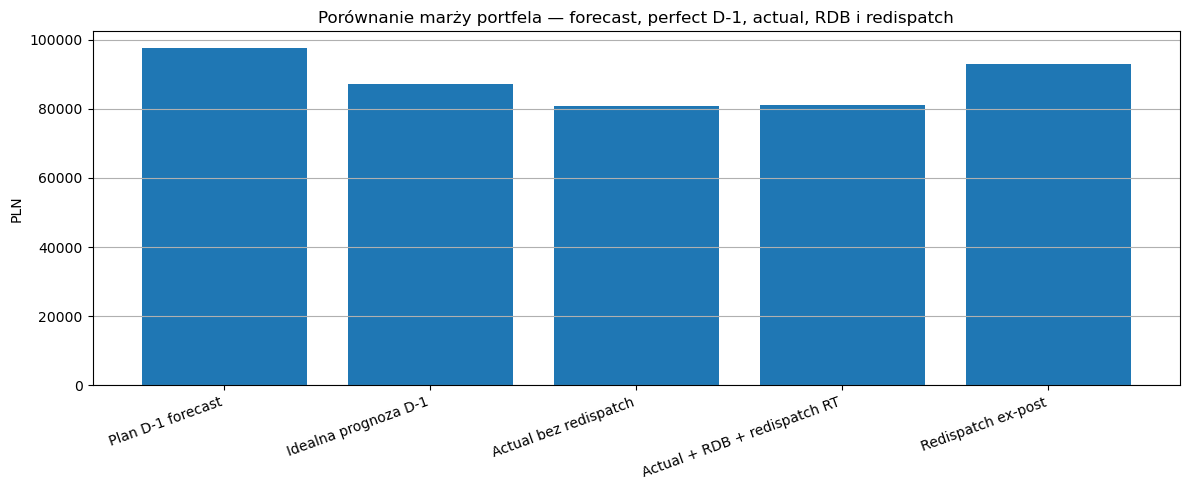

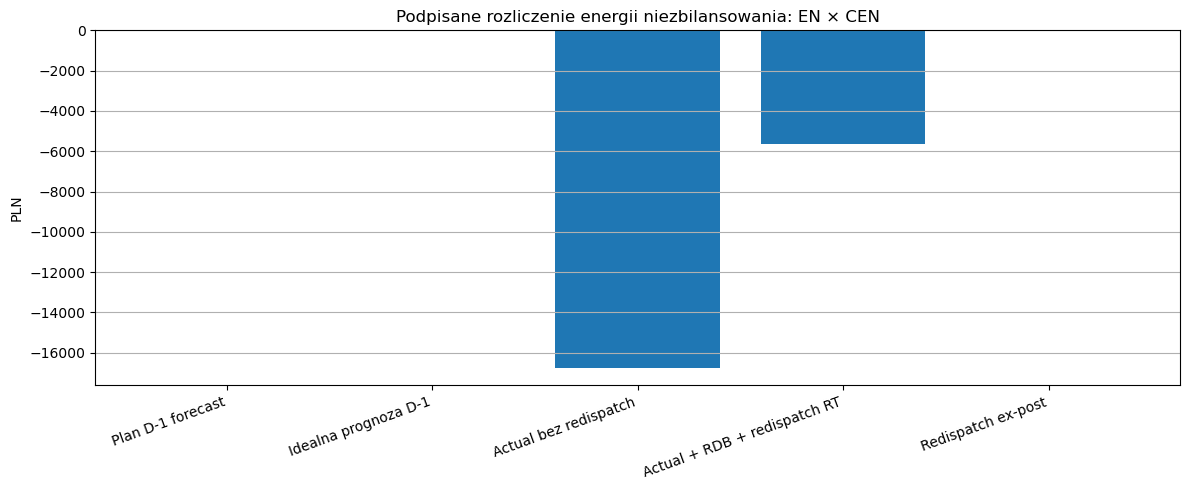

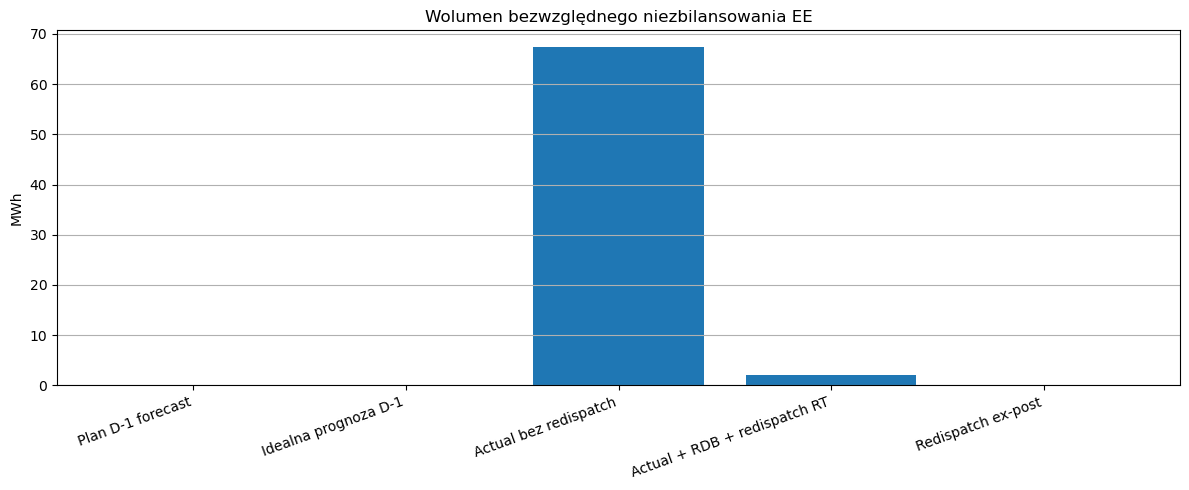

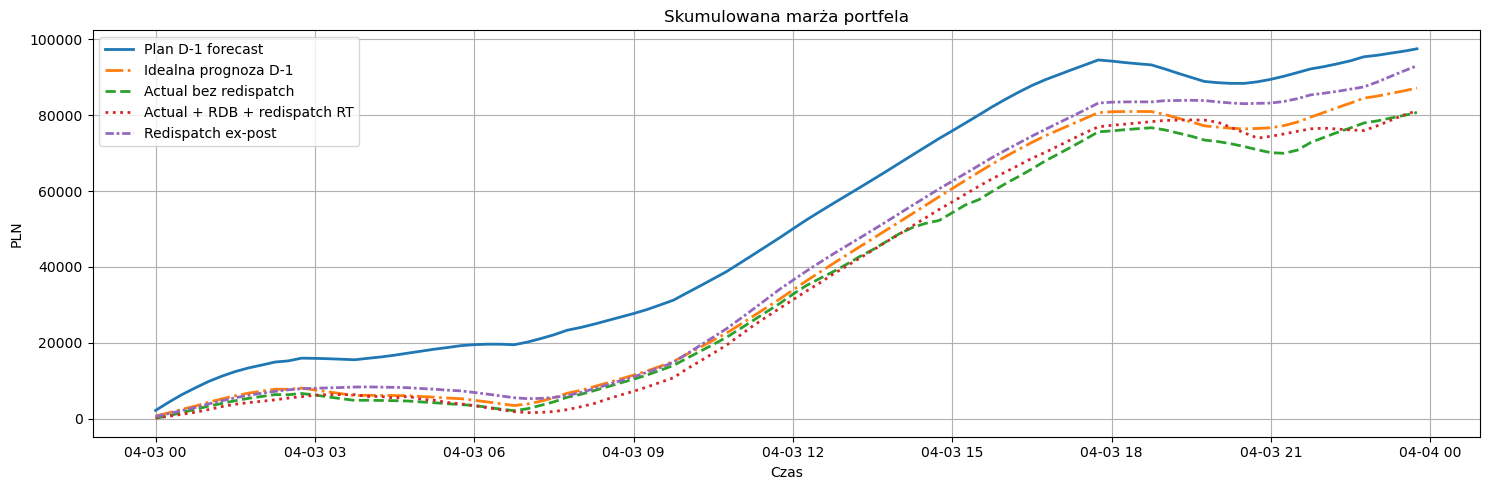

In [221]:
plt.figure(figsize=(12, 5))

plt.bar(
    summary_pnl["scenariusz"],
    summary_pnl["marza_PLN"]
)

plt.title("Porównanie marży portfela — forecast, perfect D-1, actual, RDB i redispatch")
plt.ylabel("PLN")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
show_intermediate_plot()


plt.figure(figsize=(12, 5))

plt.bar(
    summary_pnl["scenariusz"],
    summary_pnl["rozliczenie_niezbilansowania_PLN"]
)

plt.title("Podpisane rozliczenie energii niezbilansowania: EN × CEN")
plt.ylabel("PLN")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
show_intermediate_plot()


plt.figure(figsize=(12, 5))

plt.bar(
    summary_pnl["scenariusz"],
    summary_pnl["wolumen_abs_niezbilansowania_MWh"]
)

plt.title("Wolumen bezwzględnego niezbilansowania EE")
plt.ylabel("MWh")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
show_intermediate_plot()


pnl["cum_D1_margin_PLN"] = pnl["D1_margin_PLN"].cumsum()
pnl["cum_PERFECT_D1_margin_PLN"] = pnl["PERFECT_D1_margin_PLN"].cumsum()
pnl["cum_ACTUAL_NO_RED_margin_PLN"] = pnl["ACTUAL_NO_RED_margin_PLN"].cumsum()
pnl["cum_ACTUAL_RED_margin_PLN"] = pnl["ACTUAL_RED_margin_PLN"].cumsum()

plt.figure(figsize=(15, 5))

plt.plot(
    pnl["timestamp"],
    pnl["cum_D1_margin_PLN"],
    label="Plan D-1 forecast",
    linewidth=2
)

plt.plot(
    pnl["timestamp"],
    pnl["cum_PERFECT_D1_margin_PLN"],
    label="Idealna prognoza D-1",
    linewidth=2,
    linestyle="-."
)

plt.plot(
    pnl["timestamp"],
    pnl["cum_ACTUAL_NO_RED_margin_PLN"],
    label="Actual bez redispatch",
    linewidth=2,
    linestyle="--"
)

plt.plot(
    pnl["timestamp"],
    pnl["cum_ACTUAL_RED_margin_PLN"],
    label="Actual + RDB + redispatch RT",
    linewidth=2,
    linestyle=":"
)

if "pnl_expost" in globals() and pnl_expost is not None:
    pnl_expost["cum_EXPOST_margin_PLN"] = pnl_expost["EXPOST_margin_PLN"].cumsum()
    plt.plot(
        pnl_expost["timestamp"],
        pnl_expost["cum_EXPOST_margin_PLN"],
        label="Redispatch ex-post",
        linewidth=2,
        linestyle=(0, (3, 1, 1, 1))
    )

plt.title("Skumulowana marża portfela")
plt.xlabel("Czas")
plt.ylabel("PLN")
plt.legend()
plt.grid(True)
show_intermediate_plot()


## 66A. PORÓWNANIE KOSZTU NIEZBILANSOWANIA — BEZ REDISPATCH VS EX-POST VS ROLLING HORIZON

Ten wykres wykorzystuje ceny CEN i porównuje wyłącznie koszt niezbilansowania EE. Nie jest to pełny PnL ex-post, tylko czyste porównanie efektu redukcji niezbilansowania.


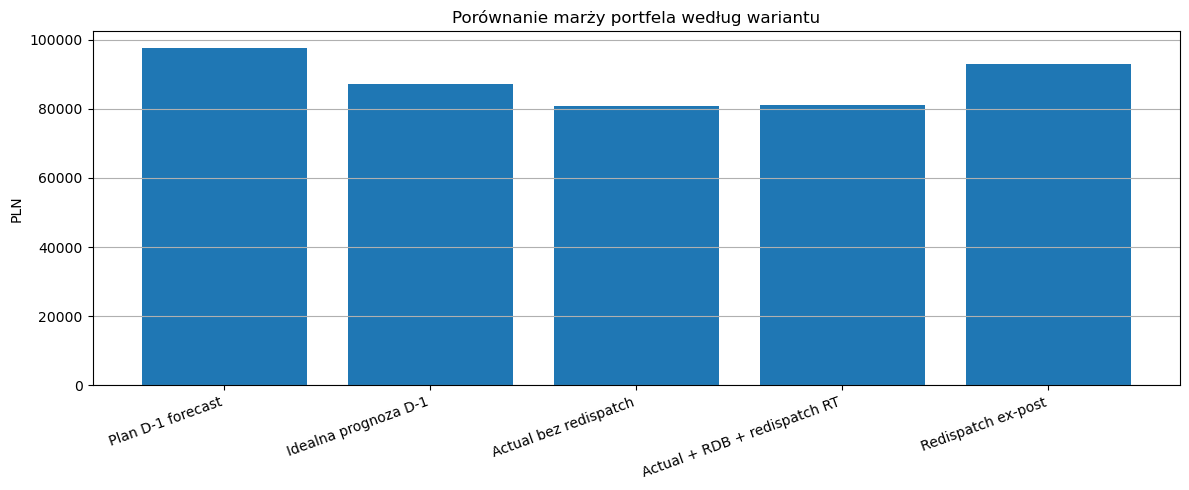

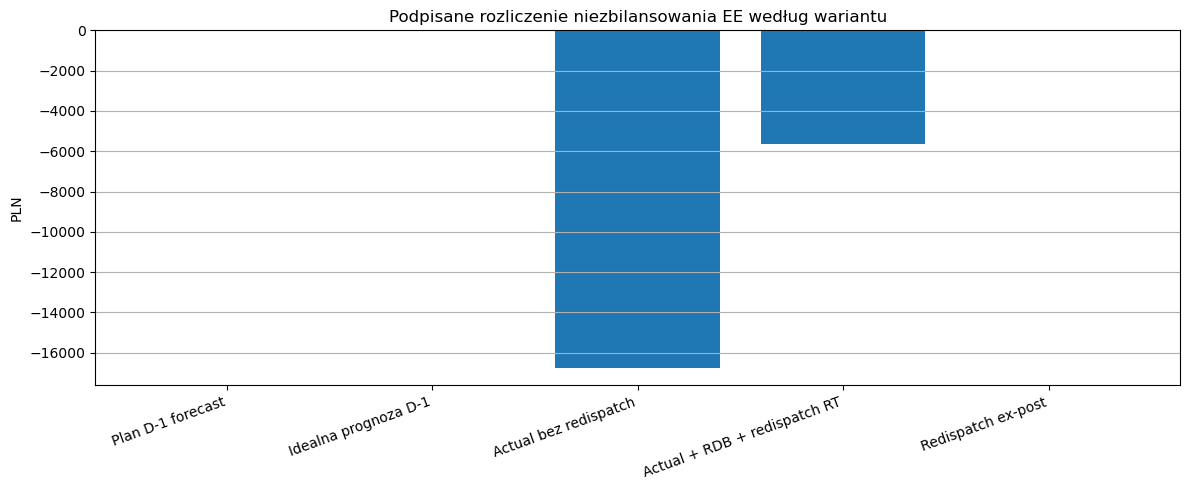

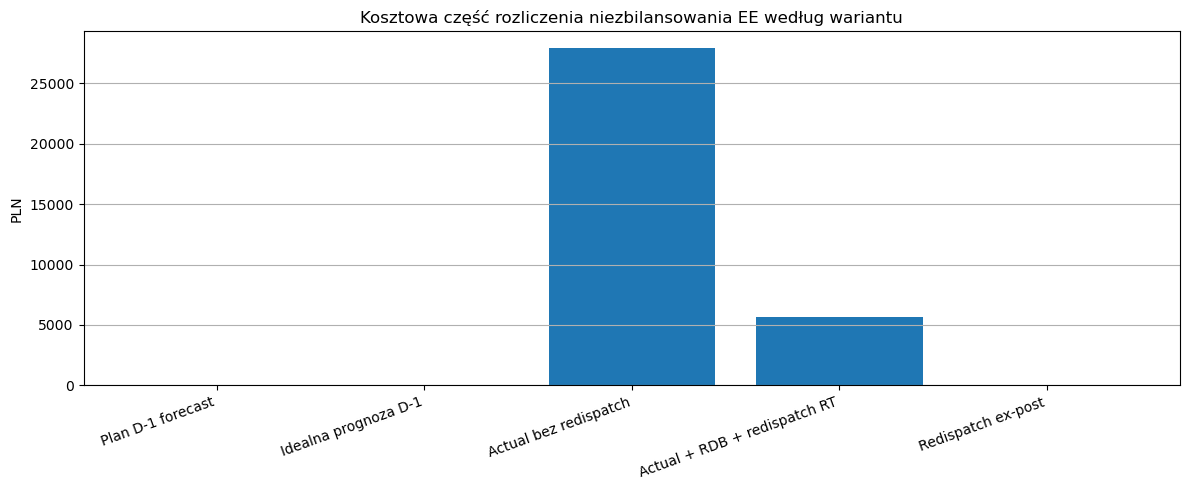

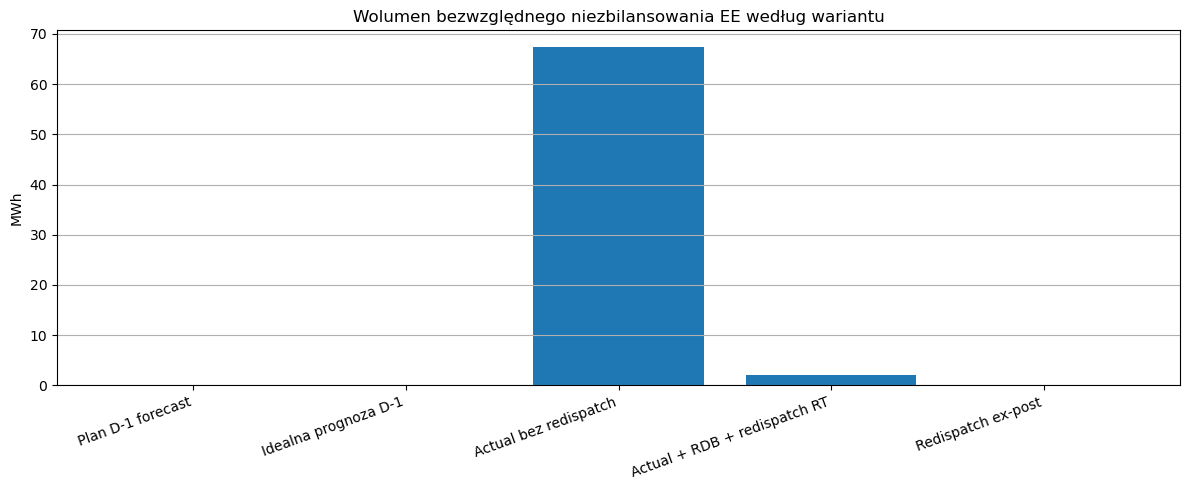

In [223]:
# =========================================================
# PORÓWNANIE NIEZBILANSOWANIA: FORECAST / PERFECT D-1 / BRAK REDISPATCH / RT / EX-POST
# =========================================================

imbalance_variant_compare = summary_pnl[[
    "scenariusz",
    "typ",
    "realistyczny",
    "rozliczenie_niezbilansowania_PLN",
    "przychod_z_niezbilansowania_PLN",
    "koszt_niezbilansowania_PLN",
    "wolumen_abs_niezbilansowania_MWh",
    "marza_PLN",
    "zmiana_vs_plan_D1_forecast_PLN",
    "utrata_vs_idealna_prognoza_D1_PLN",
    "poprawa_vs_actual_bez_redispatch_PLN",
]].rename(columns={"scenariusz": "wariant"})

# Zachowujemy starą nazwę obiektu dla kompatybilności z dalszym raportem Excel.
imbalance_cost_variant_compare = imbalance_variant_compare.copy()

maybe_display(imbalance_variant_compare)

# Dwa pierwsze warianty mają zerowy wolumen niezbilansowania z definicji,
# ale są liczone finansowo w kolumnie marza_PLN.
plt.figure(figsize=(12, 5))
plt.bar(
    imbalance_variant_compare["wariant"],
    imbalance_variant_compare["marza_PLN"],
)
plt.title("Porównanie marży portfela według wariantu")
plt.ylabel("PLN")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
show_intermediate_plot()

plt.figure(figsize=(12, 5))
plt.bar(
    imbalance_variant_compare["wariant"],
    imbalance_variant_compare["rozliczenie_niezbilansowania_PLN"],
)
plt.title("Podpisane rozliczenie niezbilansowania EE według wariantu")
plt.ylabel("PLN")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
show_intermediate_plot()

plt.figure(figsize=(12, 5))
plt.bar(
    imbalance_variant_compare["wariant"],
    imbalance_variant_compare["koszt_niezbilansowania_PLN"],
)
plt.title("Kosztowa część rozliczenia niezbilansowania EE według wariantu")
plt.ylabel("PLN")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
show_intermediate_plot()

plt.figure(figsize=(12, 5))
plt.bar(
    imbalance_variant_compare["wariant"],
    imbalance_variant_compare["wolumen_abs_niezbilansowania_MWh"],
)
plt.title("Wolumen bezwzględnego niezbilansowania EE według wariantu")
plt.ylabel("MWh")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
show_intermediate_plot()


## 67. ZAPIS PNL DO EXCELA


In [225]:
OUTPUT_PNL_PATH = f"wyniki_pnl_portfela_{delivery_day}.xlsx"

with pd.ExcelWriter(OUTPUT_PNL_PATH, engine="openpyxl") as writer:

    pnl.to_excel(
        writer,
        sheet_name="PnL_15min",
        index=False
    )

    if "pnl_expost" in globals() and pnl_expost is not None:
        pnl_expost.to_excel(
            writer,
            sheet_name="PnL_expost_15min",
            index=False
        )

    summary_pnl.to_excel(
        writer,
        sheet_name="Podsumowanie",
        index=False
    )

    summary_extra.to_excel(
        writer,
        sheet_name="Efekt_redispatch",
        index=False
    )

    if "imbalance_variant_compare" in globals():
        imbalance_variant_compare.to_excel(
            writer,
            sheet_name="Warianty_niezbilansowania",
            index=False
        )

    cen_prices.to_excel(
        writer,
        sheet_name="Ceny_CEN_PSE",
        index=False
    )

print(f"Zapisano PnL portfela do pliku: {OUTPUT_PNL_PATH}")


Zapisano PnL portfela do pliku: wyniki_pnl_portfela_2026-04-03.xlsx


## 68. DIAGNOSTYKA: CZY REDISPATCH OPŁACA SIĘ EKONOMICZNIE?


In [227]:
diagnostic_pnl = pnl.copy()

# 1. Zmiana podpisanego rozliczenia niezbilansowania
# Dodatnia wartość oznacza poprawę wyniku dzięki redispatch.
diagnostic_pnl["imbalance_settlement_delta_PLN"] = (
    diagnostic_pnl["imbalance_settlement_after_PLN"]
    - diagnostic_pnl["imbalance_settlement_before_PLN"]
)

diagnostic_pnl["abs_imbalance_reduction_MWh"] = (
    diagnostic_pnl["ee_imbalance_before_MWh"].abs()
    - diagnostic_pnl["ee_imbalance_after_MWh"].abs()
)

# 2. Dodatkowe koszty/przychody wynikające z redispatch
diagnostic_pnl["delta_spot_gas_cost_PLN"] = (
    diagnostic_pnl["ACTUAL_RED_cost_spot_gas_PLN"]
    - diagnostic_pnl["ACTUAL_NO_RED_cost_spot_gas_PLN"]
)

diagnostic_pnl["delta_spot_gas_revenue_PLN"] = (
    diagnostic_pnl["ACTUAL_RED_revenue_spot_gas_PLN"]
    - diagnostic_pnl["ACTUAL_NO_RED_revenue_spot_gas_PLN"]
)

diagnostic_pnl["delta_co2_cost_PLN"] = (
    diagnostic_pnl["ACTUAL_RED_cost_co2_PLN"]
    - diagnostic_pnl["ACTUAL_NO_RED_cost_co2_PLN"]
)

diagnostic_pnl["delta_engine_om_cost_PLN"] = (
    diagnostic_pnl["ACTUAL_RED_cost_engine_om_PLN"]
    - diagnostic_pnl["ACTUAL_NO_RED_cost_engine_om_PLN"]
)

diagnostic_pnl["delta_bess_cost_PLN"] = (
    diagnostic_pnl["ACTUAL_RED_cost_bess_PLN"]
    - diagnostic_pnl["ACTUAL_NO_RED_cost_bess_PLN"]
)

diagnostic_pnl["delta_cooling_fans_cost_PLN"] = (
    diagnostic_pnl["ACTUAL_RED_cost_cooling_fans_PLN"]
    - diagnostic_pnl["ACTUAL_NO_RED_cost_cooling_fans_PLN"]
)

diagnostic_pnl["delta_heat_dump_cost_PLN"] = (
    diagnostic_pnl["ACTUAL_RED_cost_heat_dump_PLN"]
    - diagnostic_pnl["ACTUAL_NO_RED_cost_heat_dump_PLN"]
)

diagnostic_pnl["delta_rdb_cost_PLN"] = (
    diagnostic_pnl["ACTUAL_RED_cost_rdb_ee_PLN"]
)

diagnostic_pnl["delta_rdb_revenue_PLN"] = (
    diagnostic_pnl["ACTUAL_RED_revenue_rdb_ee_PLN"]
)

diagnostic_pnl["delta_engine_start_cost_PLN"] = (
    diagnostic_pnl["ACTUAL_RED_cost_engine_start_PLN"]
)

# 3. Łączny koszt netto redispatch
# Koszty zwiększają wartość dodatnią.
# Dodatkowy przychód ze sprzedaży gazu zmniejsza koszt netto.
diagnostic_pnl["redispatch_net_cost_PLN"] = (
    diagnostic_pnl["delta_spot_gas_cost_PLN"]
    - diagnostic_pnl["delta_spot_gas_revenue_PLN"]
    + diagnostic_pnl["delta_rdb_cost_PLN"]
    - diagnostic_pnl["delta_rdb_revenue_PLN"]
    + diagnostic_pnl["delta_co2_cost_PLN"]
    + diagnostic_pnl["delta_engine_om_cost_PLN"]
    + diagnostic_pnl["delta_engine_start_cost_PLN"]
    + diagnostic_pnl["delta_bess_cost_PLN"]
    + diagnostic_pnl["delta_heat_dump_cost_PLN"]
)

# 4. Wartość netto redispatch
# = poprawa podpisanego rozliczenia CEN minus dodatkowy koszt pracy aktywów.
diagnostic_pnl["redispatch_net_value_PLN"] = (
    diagnostic_pnl["imbalance_settlement_delta_PLN"]
    - diagnostic_pnl["redispatch_net_cost_PLN"]
)

# 5. Kontrola względem różnicy marży
diagnostic_pnl["margin_delta_check_PLN"] = (
    diagnostic_pnl["ACTUAL_RED_margin_PLN"]
    - diagnostic_pnl["ACTUAL_NO_RED_margin_PLN"]
)

diagnostic_pnl["check_difference_PLN"] = (
    diagnostic_pnl["redispatch_net_value_PLN"]
    - diagnostic_pnl["margin_delta_check_PLN"]
)

# -------------------------
# Podsumowanie
# -------------------------

redispatch_economics_check = pd.DataFrame([{
    "poprawa_rozliczenia_niezbilansowania_PLN":
        diagnostic_pnl["imbalance_settlement_delta_PLN"].sum(),

    "redukcja_wolumenu_abs_niezbilansowania_MWh":
        diagnostic_pnl["abs_imbalance_reduction_MWh"].sum(),

    "delta_koszt_gazu_spot_PLN":
        diagnostic_pnl["delta_spot_gas_cost_PLN"].sum(),

    "delta_przychod_gazu_spot_PLN":
        diagnostic_pnl["delta_spot_gas_revenue_PLN"].sum(),

    "koszt_zakupu_RDB_PLN":
        diagnostic_pnl["delta_rdb_cost_PLN"].sum(),

    "przychod_sprzedazy_RDB_PLN":
        diagnostic_pnl["delta_rdb_revenue_PLN"].sum(),

    "delta_koszt_CO2_PLN":
        diagnostic_pnl["delta_co2_cost_PLN"].sum(),

    "delta_koszt_OM_silnika_PLN":
        diagnostic_pnl["delta_engine_om_cost_PLN"].sum(),

    "delta_koszt_uruchomien_silnika_PLN":
        diagnostic_pnl["delta_engine_start_cost_PLN"].sum(),

    "delta_koszt_BESS_PLN":
        diagnostic_pnl["delta_bess_cost_PLN"].sum(),

    "delta_koszt_chlodni_PLN_nienaliczany_osobno":
        diagnostic_pnl["delta_cooling_fans_cost_PLN"].sum(),

    "delta_koszt_zrzutu_ciepla_PLN":
        diagnostic_pnl["delta_heat_dump_cost_PLN"].sum(),

    "koszt_netto_redispatch_PLN":
        diagnostic_pnl["redispatch_net_cost_PLN"].sum(),

    "wartosc_netto_redispatch_PLN":
        diagnostic_pnl["redispatch_net_value_PLN"].sum(),

    "roznica_marzy_actual_po_vs_bez_PLN":
        diagnostic_pnl["margin_delta_check_PLN"].sum(),

    "roznica_kontrolna_PLN":
        diagnostic_pnl["check_difference_PLN"].sum()
}])

maybe_display(redispatch_economics_check)

# Czy ekonomicznie się opłaciło?
redispatch_value_total = diagnostic_pnl["redispatch_net_value_PLN"].sum()

if redispatch_value_total > 0:
    print(f"Redispatch poprawił wynik o {redispatch_value_total:,.2f} PLN.")
elif redispatch_value_total < 0:
    print(f"Redispatch pogorszył wynik o {redispatch_value_total:,.2f} PLN.")
else:
    print("Redispatch jest ekonomicznie neutralny.")

# -------------------------
# Najgorsze interwały
# -------------------------

cols_debug = [
    "timestamp",
    "ee_imbalance_before_MWh",
    "ee_imbalance_after_MWh",
    "imbalance_price_PLN_MWh",
    "imbalance_settlement_before_PLN",
    "imbalance_settlement_after_PLN",
    "imbalance_settlement_delta_PLN",
    "abs_imbalance_reduction_MWh",
    "delta_spot_gas_cost_PLN",
    "delta_spot_gas_revenue_PLN",
    "delta_rdb_cost_PLN",
    "delta_rdb_revenue_PLN",
    "delta_co2_cost_PLN",
    "delta_engine_om_cost_PLN",
    "delta_engine_start_cost_PLN",
    "delta_bess_cost_PLN",
    "delta_cooling_fans_cost_PLN",
    "delta_heat_dump_cost_PLN",
    "redispatch_net_cost_PLN",
    "redispatch_net_value_PLN"
]

cols_debug = [col for col in cols_debug if col in diagnostic_pnl.columns]

maybe_display(
    diagnostic_pnl[cols_debug]
    .sort_values("redispatch_net_value_PLN")
    .head(20)
)


Redispatch poprawił wynik o 432.28 PLN.



## 90. RAPORT KOŃCOWY — uporządkowana prezentacja wyników

Ta sekcja zbiera najważniejsze wykresy w jednym miejscu, bez rozbijania prezentacji po całym notebooku. Wykresy pośrednie w poprzednich sekcjach są domyślnie ukryte przez `SHOW_INTERMEDIATE_PLOTS = False`.

Zakres raportu:

1. koszt niezbilansowania według wariantu,
2. wolumen bezwzględnego niezbilansowania według wariantu,
3. przebieg niezbilansowania EE w czasie,
4. praca i SOC BESS,
5. pokrycie zapotrzebowania na ciepło oraz zrzut ciepła z silnika,
6. porównanie forecastu CEN z ceną rozliczeniową CEN,
7. diagnostyka ekonomiczna redispatch.


Uwaga: Plan D-1 forecast i Idealna prognoza D-1 mają zerowe niezbilansowanie z definicji; ich wpływ jest widoczny w marza_PLN / koszcie błędu prognozy, a nie w wykresie wolumenu niezbilansowania.


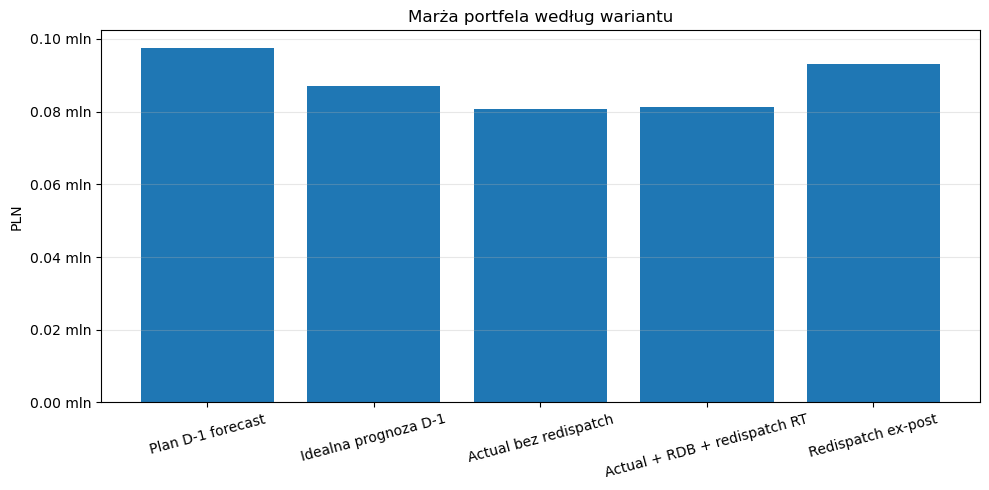

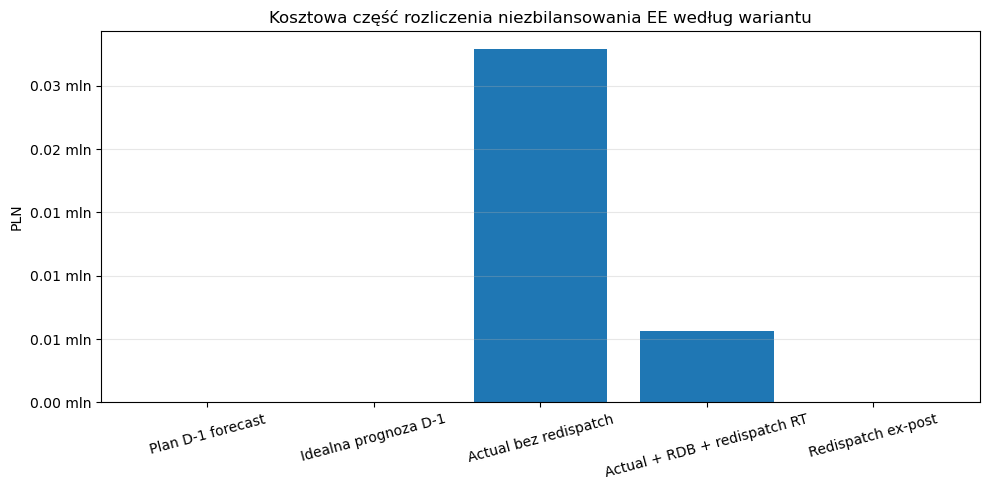

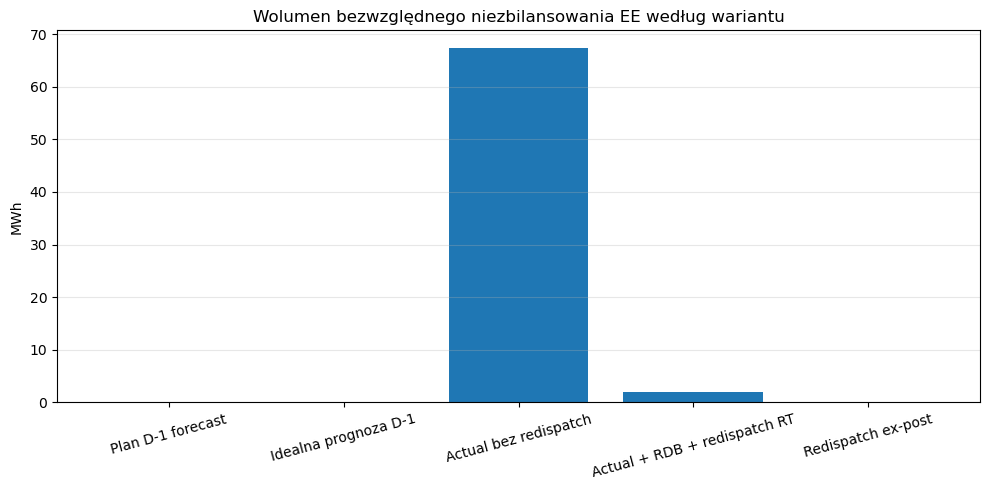

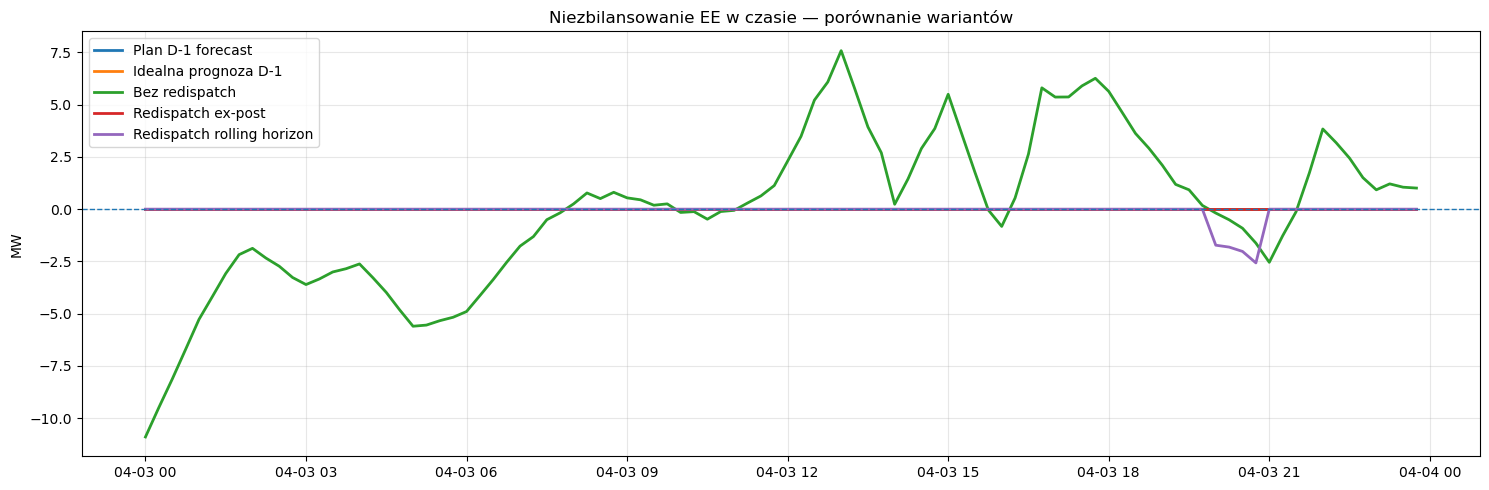

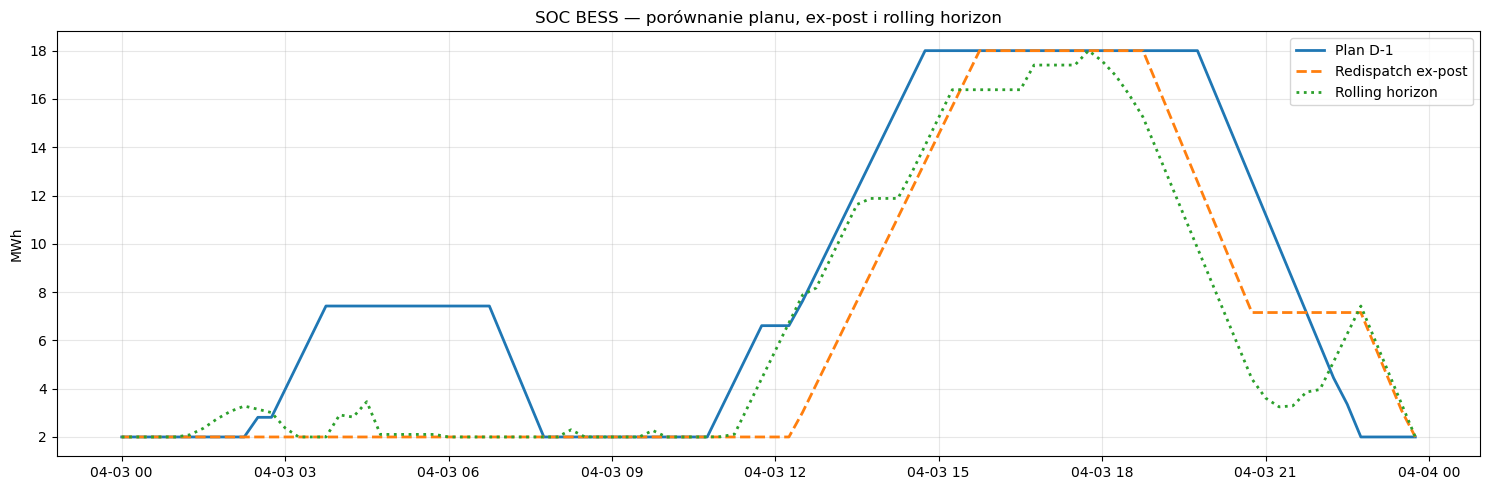

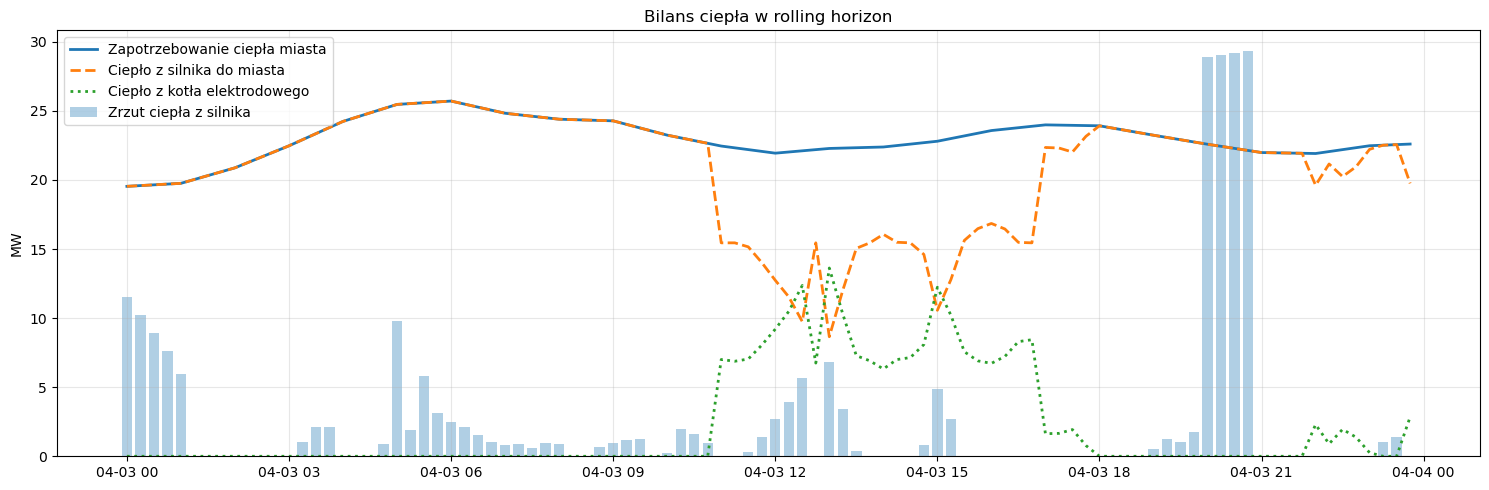

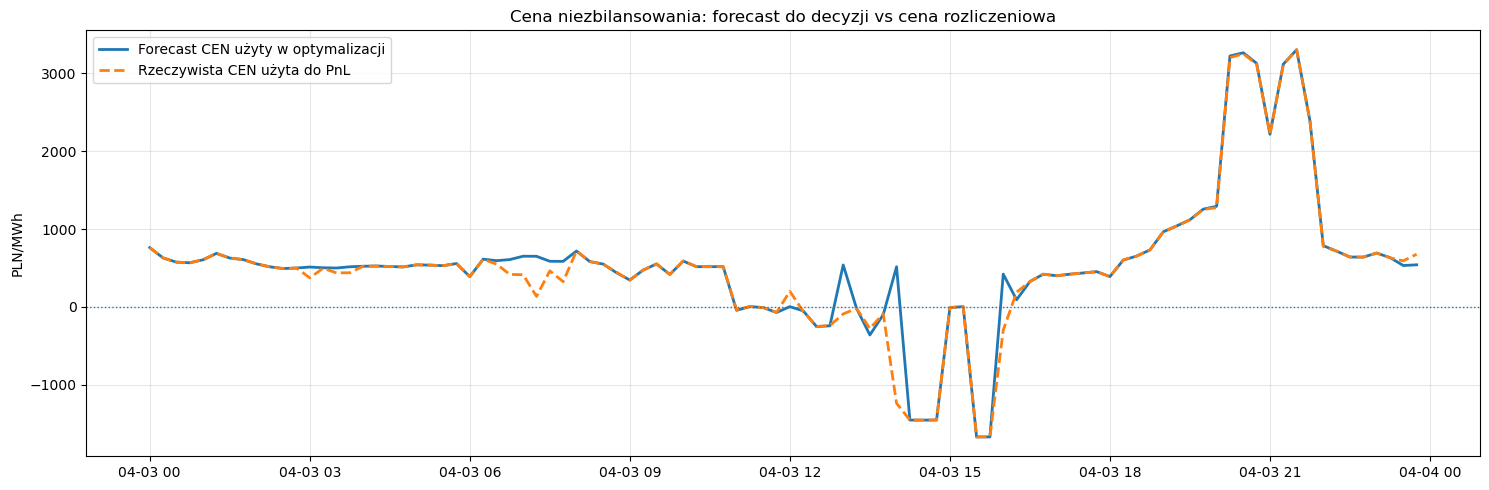

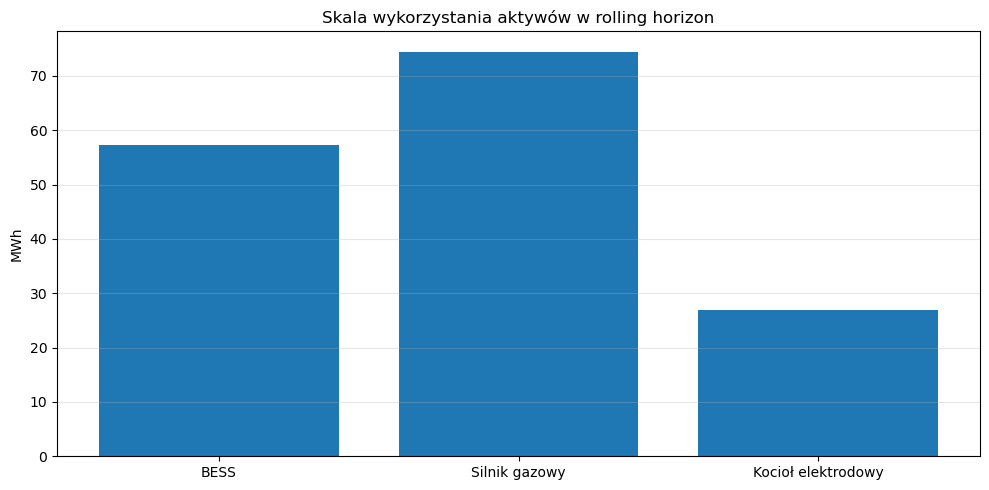

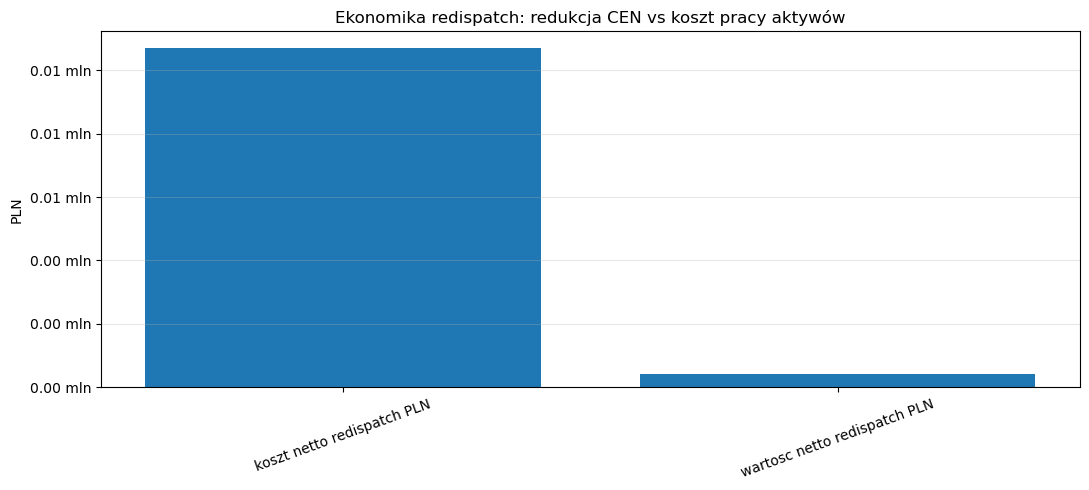

Raport końcowy wygenerowany. Kluczowe ramki danych:
- final_variant_summary
- final_correction_summary
- redispatch_economics_check


In [229]:

# =========================================================
# RAPORT KOŃCOWY — WYKRESY I PODSUMOWANIE
# =========================================================

if RUN_FINAL_REPORT:

    import matplotlib.ticker as mticker

    def _require_object(name):
        if name not in globals():
            raise RuntimeError(f"Brakuje obiektu {name}. Uruchom wcześniejsze sekcje notebooka.")
        return globals()[name]

    def _to_time(df):
        out = df.copy()
        out["timestamp"] = pd.to_datetime(out["timestamp"])
        return out

    def _series_or_zero(df, col):
        if col in df.columns:
            return pd.to_numeric(df[col], errors="coerce").fillna(0)
        return pd.Series(0.0, index=df.index)

    def _money_axis(ax):
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, pos: f"{x/1_000_000:.2f} mln")
        )
        ax.set_ylabel("PLN")

    def _mwh_axis(ax):
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", " "))
        )
        ax.set_ylabel("MWh")

    def _make_variant_timeseries():
        rr = _to_time(redispatch_results)
        exp = _to_time(redispatch_results_expost)
        roll = _to_time(redispatch_rolling_results)

        out = pd.DataFrame({
            "timestamp": rr["timestamp"],
            "Plan D-1 forecast": 0.0,
            "Idealna prognoza D-1": 0.0,
            "Bez redispatch": rr["ee_imbalance_before_MWh"].values,
        })

        out = out.merge(
            exp[["timestamp", "ee_imbalance_after_MWh"]].rename(
                columns={"ee_imbalance_after_MWh": "Redispatch ex-post"}
            ),
            on="timestamp",
            how="left",
        )

        out = out.merge(
            roll[["timestamp", "ee_imbalance_after_MWh"]].rename(
                columns={"ee_imbalance_after_MWh": "Redispatch rolling horizon"}
            ),
            on="timestamp",
            how="left",
        )

        return out

    def _calc_signed_settlement_with_actual_cen(df, imbalance_col):
        tmp = _to_time(df[["timestamp", imbalance_col]].copy())

        if "cen_prices" in globals() and "imbalance_price_PLN_MWh" in cen_prices.columns:
            prices = _to_time(cen_prices[["timestamp", "imbalance_price_PLN_MWh"]].copy())
            tmp = tmp.merge(prices, on="timestamp", how="left")
            if tmp["imbalance_price_PLN_MWh"].isna().any():
                # Awaryjnie: jeżeli CEN nie pokrywa wszystkich interwałów, użyj forecastu z df.
                if "imbalance_price_forecast_PLN_MWh" in df.columns:
                    tmp["imbalance_price_PLN_MWh"] = tmp["imbalance_price_PLN_MWh"].fillna(
                        pd.to_numeric(df["imbalance_price_forecast_PLN_MWh"], errors="coerce")
                    )
        elif "imbalance_price_forecast_PLN_MWh" in df.columns:
            tmp["imbalance_price_PLN_MWh"] = pd.to_numeric(
                df["imbalance_price_forecast_PLN_MWh"],
                errors="coerce",
            )
        else:
            tmp["imbalance_price_PLN_MWh"] = DEFAULT_IMBALANCE_PRICE_FORECAST_PLN_MWh

        tmp["imbalance_settlement_PLN"] = (
            pd.to_numeric(tmp[imbalance_col], errors="coerce").fillna(0)
            * pd.to_numeric(tmp["imbalance_price_PLN_MWh"], errors="coerce").fillna(0)
        )
        return {
            "rozliczenie_niezbilansowania_PLN": tmp["imbalance_settlement_PLN"].sum(),
            "przychod_z_niezbilansowania_PLN": tmp["imbalance_settlement_PLN"].clip(lower=0).sum(),
            "koszt_niezbilansowania_PLN": (-tmp["imbalance_settlement_PLN"].clip(upper=0)).sum(),
        }

    # -------------------------
    # 1. Dane bazowe raportu
    # -------------------------
    _require_object("redispatch_results")
    _require_object("redispatch_results_expost")
    _require_object("redispatch_rolling_results")

    redispatch_results = drop_duplicate_columns_keep_first(redispatch_results, "redispatch_results")
    redispatch_results_expost = drop_duplicate_columns_keep_first(redispatch_results_expost, "redispatch_results_expost")
    redispatch_rolling_results = drop_duplicate_columns_keep_first(redispatch_rolling_results, "redispatch_rolling_results")

    variant_ts = _make_variant_timeseries()

    if "summary_pnl" in globals() and not summary_pnl.empty:
        final_variant_summary = summary_pnl.rename(columns={"scenariusz": "wariant"}).copy()
    else:
        no_red_metrics = _calc_signed_settlement_with_actual_cen(redispatch_results, "ee_imbalance_before_MWh")
        expost_metrics = _calc_signed_settlement_with_actual_cen(redispatch_results_expost, "ee_imbalance_after_MWh")
        rolling_metrics = _calc_signed_settlement_with_actual_cen(redispatch_rolling_results, "ee_imbalance_after_MWh")

        final_variant_summary = pd.DataFrame([
            {
                "wariant": "Plan D-1 forecast",
                "rozliczenie_niezbilansowania_PLN": 0.0,
                "przychod_z_niezbilansowania_PLN": 0.0,
                "koszt_niezbilansowania_PLN": 0.0,
                "wolumen_abs_niezbilansowania_MWh": 0.0,
            },
            {
                "wariant": "Idealna prognoza D-1",
                "rozliczenie_niezbilansowania_PLN": 0.0,
                "przychod_z_niezbilansowania_PLN": 0.0,
                "koszt_niezbilansowania_PLN": 0.0,
                "wolumen_abs_niezbilansowania_MWh": 0.0,
            },
            {
                "wariant": "Bez redispatch",
                **no_red_metrics,
                "wolumen_abs_niezbilansowania_MWh": variant_ts["Bez redispatch"].abs().sum(),
            },
            {
                "wariant": "Redispatch ex-post",
                **expost_metrics,
                "wolumen_abs_niezbilansowania_MWh": variant_ts["Redispatch ex-post"].abs().sum(),
            },
            {
                "wariant": "Redispatch rolling horizon",
                **rolling_metrics,
                "wolumen_abs_niezbilansowania_MWh": variant_ts["Redispatch rolling horizon"].abs().sum(),
            },
        ])

    if "Bez redispatch" in final_variant_summary["wariant"].values:
        base_label = "Bez redispatch"
    else:
        base_label = "Actual bez redispatch"

    base_cost = final_variant_summary.loc[
        final_variant_summary["wariant"].isin([base_label]),
        "koszt_niezbilansowania_PLN",
    ].iloc[0]

    base_volume = final_variant_summary.loc[
        final_variant_summary["wariant"].isin([base_label]),
        "wolumen_abs_niezbilansowania_MWh",
    ].iloc[0]

    final_variant_summary["redukcja_kosztowej_czesci_vs_bez_redispatch_PLN"] = (
        base_cost - final_variant_summary["koszt_niezbilansowania_PLN"]
    )
    final_variant_summary["redukcja_wolumenu_vs_bez_redispatch_MWh"] = (
        base_volume - final_variant_summary["wolumen_abs_niezbilansowania_MWh"]
    )

    if SHOW_FINAL_TABLES:
        display(final_variant_summary)

    print(
        "Uwaga: Plan D-1 forecast i Idealna prognoza D-1 mają zerowe niezbilansowanie z definicji; "
        "ich wpływ jest widoczny w marza_PLN / koszcie błędu prognozy, a nie w wykresie wolumenu niezbilansowania."
    )

    # -------------------------
    # 2. Marża / wynik portfela według wariantu
    # -------------------------
    if "marza_PLN" in final_variant_summary.columns:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(
            final_variant_summary["wariant"],
            final_variant_summary["marza_PLN"],
        )
        ax.set_title("Marża portfela według wariantu")
        _money_axis(ax)
        ax.grid(axis="y", alpha=0.3)
        ax.tick_params(axis="x", rotation=15)
        plt.tight_layout()
        plt.show()

    # -------------------------
    # 3. Kosztowa część rozliczenia niezbilansowania według wariantu
    # -------------------------
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(
        final_variant_summary["wariant"],
        final_variant_summary["koszt_niezbilansowania_PLN"],
    )
    ax.set_title("Kosztowa część rozliczenia niezbilansowania EE według wariantu")
    _money_axis(ax)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.show()

    # -------------------------
    # 3. Wolumen bezwzględnego niezbilansowania według wariantu
    # -------------------------
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(
        final_variant_summary["wariant"],
        final_variant_summary["wolumen_abs_niezbilansowania_MWh"],
    )
    ax.set_title("Wolumen bezwzględnego niezbilansowania EE według wariantu")
    _mwh_axis(ax)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.show()

    # -------------------------
    # 4. Profil niezbilansowania EE w czasie
    # -------------------------
    fig, ax = plt.subplots(figsize=(15, 5))
    for col in [
        "Plan D-1 forecast",
        "Idealna prognoza D-1",
        "Bez redispatch",
        "Redispatch ex-post",
        "Redispatch rolling horizon",
    ]:
        ax.plot(
            variant_ts["timestamp"],
            variant_ts[col] / dt_h,
            linewidth=2,
            label=col,
        )
    ax.axhline(0, linewidth=1, linestyle="--")
    ax.set_title("Niezbilansowanie EE w czasie — porównanie wariantów")
    ax.set_ylabel("MW")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # -------------------------
    # 5. Kontrola: czy redispatch zwiększa bezwzględne niezbilansowanie
    # -------------------------
    final_no_worsening_check = []
    for _label, _df, _after_col in [
        ("Redispatch ex-post", redispatch_results_expost, "ee_imbalance_after_MWh"),
        ("Redispatch rolling horizon", redispatch_rolling_results, "ee_imbalance_after_MWh"),
    ]:
        _tmp = _to_time(_df[["timestamp", "ee_imbalance_before_MWh", _after_col]].copy())
        _tmp["abs_before_MWh"] = _tmp["ee_imbalance_before_MWh"].abs()
        _tmp["abs_after_MWh"] = _tmp[_after_col].abs()
        _tmp["abs_increase_MWh"] = (_tmp["abs_after_MWh"] - _tmp["abs_before_MWh"]).clip(lower=0)
        final_no_worsening_check.append({
            "wariant": _label,
            "pogorszenie_abs_niezbilansowania_MWh": _tmp["abs_increase_MWh"].sum(),
            "liczba_interwalow_z_pogorszeniem": int((_tmp["abs_increase_MWh"] > 1e-6).sum()),
            "max_pogorszenie_w_interwale_MWh": _tmp["abs_increase_MWh"].max(),
        })
    final_no_worsening_check = pd.DataFrame(final_no_worsening_check)
    if SHOW_FINAL_TABLES:
        display(final_no_worsening_check)

    # -------------------------
    # 6. SOC BESS: plan D-1 vs ex-post vs rolling horizon
    # -------------------------
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(
        redispatch_results["timestamp"],
        redispatch_results["battery_soc_MWh"],
        linewidth=2,
        label="Plan D-1",
    )

    if "bess_soc_actual_MWh" in redispatch_results_expost.columns:
        ax.plot(
            redispatch_results_expost["timestamp"],
            redispatch_results_expost["bess_soc_actual_MWh"],
            linewidth=2,
            linestyle="--",
            label="Redispatch ex-post",
        )

    if "bess_soc_actual_MWh" in redispatch_rolling_results.columns:
        ax.plot(
            redispatch_rolling_results["timestamp"],
            redispatch_rolling_results["bess_soc_actual_MWh"],
            linewidth=2,
            linestyle=":",
            label="Rolling horizon",
        )

    ax.set_title("SOC BESS — porównanie planu, ex-post i rolling horizon")
    ax.set_ylabel("MWh")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # -------------------------
    # 6. Ciepło w rolling horizon: miasto vs zrzut silnika
    # -------------------------
    heat_cols = [
        "heat_demand_actual_MWh",
        "engine_heat_to_city_actual_MWh",
        "boiler_heat_actual_MWh",
        "heat_dump_actual_MWh",
    ]

    if all(col in redispatch_rolling_results.columns for col in heat_cols):
        fig, ax = plt.subplots(figsize=(15, 5))
        ax.plot(
            redispatch_rolling_results["timestamp"],
            redispatch_rolling_results["heat_demand_actual_MWh"] / dt_h,
            linewidth=2,
            label="Zapotrzebowanie ciepła miasta",
        )
        ax.plot(
            redispatch_rolling_results["timestamp"],
            redispatch_rolling_results["engine_heat_to_city_actual_MWh"] / dt_h,
            linewidth=2,
            linestyle="--",
            label="Ciepło z silnika do miasta",
        )
        ax.plot(
            redispatch_rolling_results["timestamp"],
            redispatch_rolling_results["boiler_heat_actual_MWh"] / dt_h,
            linewidth=2,
            linestyle=":",
            label="Ciepło z kotła elektrodowego",
        )
        ax.bar(
            redispatch_rolling_results["timestamp"],
            redispatch_rolling_results["heat_dump_actual_MWh"] / dt_h,
            width=0.008,
            alpha=0.35,
            label="Zrzut ciepła z silnika",
        )
        ax.set_title("Bilans ciepła w rolling horizon")
        ax.set_ylabel("MW")
        ax.grid(alpha=0.3)
        ax.legend(loc="upper left")
        plt.tight_layout()
        plt.show()

    # -------------------------
    # 7. Forecast CEN vs rzeczywista CEN
    # -------------------------
    if "imbalance_price_forecast_PLN_MWh" in redispatch_results.columns:
        cen_plot = redispatch_results[["timestamp", "imbalance_price_forecast_PLN_MWh"]].copy()
        cen_plot["timestamp"] = pd.to_datetime(cen_plot["timestamp"])

        if "cen_prices" in globals() and "imbalance_price_PLN_MWh" in cen_prices.columns:
            cen_plot = cen_plot.merge(
                cen_prices[["timestamp", "imbalance_price_PLN_MWh"]],
                on="timestamp",
                how="left",
            )

        fig, ax = plt.subplots(figsize=(15, 5))
        ax.plot(
            cen_plot["timestamp"],
            cen_plot["imbalance_price_forecast_PLN_MWh"],
            linewidth=2,
            label="Forecast CEN użyty w optymalizacji",
        )

        if "imbalance_price_PLN_MWh" in cen_plot.columns:
            ax.plot(
                cen_plot["timestamp"],
                cen_plot["imbalance_price_PLN_MWh"],
                linewidth=2,
                linestyle="--",
                label="Rzeczywista CEN użyta do PnL",
            )

        ax.axhline(0, linewidth=1, linestyle=":")
        ax.set_title("Cena niezbilansowania: forecast do decyzji vs cena rozliczeniowa")
        ax.set_ylabel("PLN/MWh")
        ax.grid(alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

    # -------------------------
    # 8. Źródła korekty w rolling horizon
    # -------------------------
    correction_cols = {
        "BESS": "bess_net_delta_MWh",
        "Silnik gazowy": "engine_el_delta_MWh",
        "Kocioł elektrodowy": "boiler_el_delta_MWh",
    }

    correction_summary = []
    for label, col in correction_cols.items():
        if col in redispatch_rolling_results.columns:
            correction_summary.append({
                "aktywo": label,
                "korekta_abs_MWh": redispatch_rolling_results[col].abs().sum(),
                "korekta_netto_MWh": redispatch_rolling_results[col].sum(),
            })

    final_correction_summary = pd.DataFrame(correction_summary)

    if not final_correction_summary.empty:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(
            final_correction_summary["aktywo"],
            final_correction_summary["korekta_abs_MWh"],
        )
        ax.set_title("Skala wykorzystania aktywów w rolling horizon")
        _mwh_axis(ax)
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

    # -------------------------
    # 9. Diagnostyka ekonomiczna redispatch
    # -------------------------
    if "redispatch_economics_check" in globals():
        economic_cols = [
            "redukcja_kosztu_niezbilansowania_PLN",
            "koszt_netto_redispatch_PLN",
            "wartosc_netto_redispatch_PLN",
        ]
        available_economic_cols = [
            col for col in economic_cols
            if col in redispatch_economics_check.columns
        ]

        if available_economic_cols:
            econ_plot = redispatch_economics_check[available_economic_cols].T.reset_index()
            econ_plot.columns = ["skladnik", "wartosc_PLN"]
            econ_plot["skladnik"] = econ_plot["skladnik"].str.replace("_", " ")

            fig, ax = plt.subplots(figsize=(11, 5))
            ax.bar(econ_plot["skladnik"], econ_plot["wartosc_PLN"])
            ax.set_title("Ekonomika redispatch: redukcja CEN vs koszt pracy aktywów")
            _money_axis(ax)
            ax.grid(axis="y", alpha=0.3)
            ax.tick_params(axis="x", rotation=20)
            plt.tight_layout()
            plt.show()

    print("Raport końcowy wygenerowany. Kluczowe ramki danych:")
    print("- final_variant_summary")
    print("- final_correction_summary")
    if "redispatch_economics_check" in globals():
        print("- redispatch_economics_check")
